<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_spatial_panel_driver_gam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/winam_wh_spatial_panel_driver_gam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf water hyacinth spatial-panel — inferential driver GAM (Track B)

> **One of a pair.** This notebook was split from `winam_wh_spatial_panel_test_model.ipynb` so the two model families can run in parallel and save wall-clock time. It carries the **shared panel build** (Drive → classified GeoTIFFs → grid → Earth Engine covariates → feature engineering, §1–§12) followed by the **one-stage spatial driver GAM (Track B) only**. The predictive ML workhorse (Track A) lives in the sibling notebook `winam_wh_spatial_panel_predictive_ml.ipynb`. Build the panel once (both notebooks share the same Drive checkpoints, e.g. `PANEL_RAW_FROM_CHECKPOINT`), then run the two model sections concurrently.

This notebook builds a **spatially explicit monthly panel dataset** from already-classified water hyacinth GeoTIFFs in Google Drive, then fits the interpretable **driver** model.

It is designed as a **test-period prototype**, not the final dissertation model. It:

1. mounts Google Drive;
2. finds classified WH GeoTIFFs for a chosen period;
3. creates fixed 500 m or 1 km grid cells over Winam Gulf;
4. aggregates each classified raster to `grid cell × month`;
5. pulls environmental driver covariates directly from **Google Earth Engine** — rainfall (CHIRPS), wind and air temperature (ERA5 / ERA5-Land), water-surface temperature (MODIS LST), turbidity and chlorophyll-a proxies (Sentinel-2 / Sentinel-3 / MODIS), distance to rivers and shore, and catchment pressure (ESA WorldCover / WorldPop / GHSL) — and optionally merges CSV covariates for layers that have no EE asset (lake level, ENSO/IOD, bathymetry, in-situ nutrients);
6. audits and names every merged covariate (§9c), then creates lagged terms;
7. fits the **Track B inferential driver model** — a one-stage spatial **Beta (logit-link)** GAM (`mgcv::bam` via `rpy2`) on an **exogenous forcing set only**, with a cyclic seasonal term, one spatial structure (MRF or `te(x, y)`) and a within-cell AR1 correction — and reports effect sizes, concurvity, residual dependence, blocked cross-validation, a model-family comparison, robustness checks and a set of workflow checks;
8. exports panel tables, grid outputs and the driver-model diagnostics, each labelled with the kind of evidence it is.

The intended response variable is **monthly WH proportional cover per spatial unit**, not pixel-level WH occurrence.

## What this notebook is careful about

These are the rules the modelling sections enforce in code, not just in prose:

- **The forcing model is genuinely exogenous.** No `wh_*` term (focal or neighbouring, current or lagged) and no contemporaneous optical proxy (turbidity, chlorophyll-a, reflectance) may enter any forcing formula; `assert_forcing_formula_exogenous` (§4d) raises if one does. Lagged-response terms live only in a **separately labelled predictive specification**, which answers a forecasting question.
- **Classifier confidence is used once.** Either the response is the confidence-weighted (soft) cover *or* confidence enters as likelihood weights — never both (`GAM_CONFIDENCE_MODE`). Absence rows are never assigned full confidence just because WH-pixel confidence is undefined there.
- **Every covariate is identified.** Earth Engine names single-band reductions after the *reducer*, so anonymous `mean` / `mean_x` / `mean_y` columns previously reached the model. §9c renames them where a physical signature identifies them and drops them otherwise, along with constant and near-constant columns.
- **The run says which sensors it used.** Requesting an S1 gap-fill does not make one happen. §7c reports what actually occurred, labels the export, drops the constant sensor indicator on a single-sensor panel and states the cloud-related MNAR limitation that remains.
- **The driver set is parsimonious and pre-specified**, one representation per mechanism with an expected sign (`GAM_FORCING_TERMS`), instead of a data-driven sweep of every covariate in current and lagged form.
- **Preprocessing happens inside folds.** Imputation and the collinearity screen are fitted on training rows only.
- **Validation is dependence-aware and covers the record.** Shared spatial-block and rolling-origin temporal folds, with persistence and seasonal-climatology baselines, reporting Spearman, RMSE, MAE, calibration, area recovery and upper-tail skill.
- **Residual dependence gates inference.** If residual Moran's *I* or the within-cell lag-1 correlation stays large, §13b blocks the inferential reading and the fit is reported as descriptive.

> **Results status.** The cells below were revised and have **not yet been re-run end to end in Colab**. Stale outputs from the previous configuration were cleared; any narrative figures that survive are explicitly labelled as belonging to the superseded run. Do not quote a number from this notebook until the cell that produces it has been executed.

The Earth Engine layers, assets and project (`ee-bmillwardsadler1`) match those already used in `Batch_Export.ipynb` and `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`, so the same authenticated Colab runtime can run all three notebooks.


## 1. Install packages

Run this once at the start of a fresh Colab runtime.

In [29]:
# In Colab, uncomment and run this if packages are missing.
# This can take a few minutes.

# earthengine-api and geemap are needed for the Earth Engine covariate extraction
# in section 8. They match the dependencies of the classifier/export notebooks.
!pip -q install rasterio geopandas pyproj shapely fiona pyogrio statsmodels scikit-learn pygam tqdm earthengine-api geemap libpysal esda lightgbm

# The §13d ordered-Beta cross-check (change 1) needs an R package (mgcv/rpy2 are already set up
# in Colab). Install one of these into the R runtime, e.g. from Python:
#   import rpy2.robjects as ro
#   ro.r('install.packages("glmmTMB", repos="https://cloud.r-project.org")')     # fast; family=ordbeta()
#   ro.r('install.packages("ordbetareg", repos="https://cloud.r-project.org")')  # reference impl (brms/Stan; slow to compile)

## 2. Imports and Google Drive mount

In [30]:
from pathlib import Path
import re
import hashlib
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import box
from tqdm.auto import tqdm

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import from_bounds, Window

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

import matplotlib.pyplot as plt

# Import the earthengine-api library
import ee

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive was not mounted automatically. If running outside Colab, this is expected.")
    print(e)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)

EE_PROJECT = 'ee-bmillwardsadler1'
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. User configuration

Edit this cell first.

Important assumptions:

- By default this notebook now reads the **classified GeoTIFFs and run logs produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`**.
- `WH_CLASS_VALUES` is set to `[2]`, matching the classifier notebook's `FLOATING_CLASS_CODE` for floating plants / water hyacinth.
- Classified rasters are selected from **one exact classifier run**, `ACTIVE_CLASSIFIER_VERSION`, via the run log named for it (`CLASSIFIER_RUN_LOG_PATH`). The run log is never chosen by modification time or by a `winam_full_stack_run_log_*.csv` wildcard.
- The **batch-export token** (`REQUIRED_EXPORT_TOKEN_BY_SENSOR`) and the **classifier version** are separate provenance fields. The token identifies the predictor schema a snapshot was exported with, so on its own it is not evidence that the raster came from the active classifier run; both must hold.
- `REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR` is matched with an exact `startswith()`, so rasters from superseded export schemas are excluded rather than averaged in.
- `SUPPLEMENT_RUN_LOG_WITH_FOLDER = False` and there is **no directory-scan fallback**. A missing or incomplete run-log record raises rather than being filled in from `classified_geotiffs/`.
- `CLASSIFIER_SENSOR_FILTER` chooses the sensors; `CLASSIFIER_PRODUCT_FILTER` must stay `"model"`, so rule, probability, diagnostic and tiled-intermediate rasters can never become the response.
- The default grid CRS is **EPSG:32736**, UTM Zone 36S, which is suitable for the Winam Gulf area south of the equator.
- The default AOI is the same broad Winam Gulf rectangle used in your previous GEE workflow.


In [31]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

# These defaults match Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
#   DRIVE_ROOT / "outputs" / "full_stack_batch"
CLASSIFIER_BATCH_OUTPUT_DIR = Path("/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch")
CLASSIFIER_TABLE_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "tables"
CLASSIFIED_TIF_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "classified_geotiffs"

# ---------------------------------------------------------------------
# Classifier provenance: one exact classifier run, explicit export tokens
# ---------------------------------------------------------------------

# The single classifier run this panel is built from. It is the CLASSIFIER_VERSION
# assembled in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
# 'route_b_s1_scc_spatialcv_proba_v4_whlev_temporal' plus the manual-correction
# suffix '_corr_' + MANUAL_CORRECTION_VERSION ('v1'). Outputs of any other run
# must not enter the response.
ACTIVE_CLASSIFIER_VERSION = (
    "route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1"
)

# The run log of that exact run, addressed by name. Never selected by
# modification time and never through a 'winam_full_stack_run_log_*.csv'
# wildcard: "newest on disk" quietly promotes a partial rerun of a different
# classifier version into the panel response.
CLASSIFIER_RUN_LOG_PATH = (
    CLASSIFIER_TABLE_DIR
    / f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
)

# Batch-export schema tokens, from S1_EXPORT_SCHEMA_VERSION /
# S2_EXPORT_SCHEMA_VERSION in Batch_Export.ipynb. These identify the PREDICTOR
# SCHEMA a snapshot was exported with -- which bands exist and in what order --
# and say nothing about which classifier later consumed it. Export token and
# classifier version are therefore two SEPARATE provenance fields: a matching
# token is never treated as proof of the classifier version on its own.
REQUIRED_EXPORT_TOKEN_BY_SENSOR = {
    "S1": "s1_scc_temporal_v1",
    "S2": "s2_whlev_temporal_v1",
}

# Batch_Export.ipynb (section 7) builds each snapshot prefix as
#   S1: f"winam_{S1_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
#   S2: f"winam_s2_predictors_{S2_EXPORT_SCHEMA_VERSION}_{start}_to_{end}"
# so a classified raster from the current schema starts with exactly these.
# Superseded exports (winam_s1_scc_predictors_..., s2_whlev_texture_v1) fail the
# startswith() test and are excluded instead of being averaged in unnoticed.
REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR = {
    "S1": "winam_s1_scc_temporal_v1_",
    "S2": "winam_s2_predictors_s2_whlev_temporal_v1_",
}

OUTPUT_DIR = Path("/content/drive/MyDrive/WH_spatial_panel_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The run log named for ACTIVE_CLASSIFIER_VERSION is the ONLY inventory source.
USE_CLASSIFIER_RUN_LOG = True
# Directory supplementation is off and the folder-scan fallback has been removed.
# Scanning CLASSIFIED_TIF_DIR pulled in rasters from earlier classifier runs and
# earlier batch-export schemas -- exactly the mixed inventory this configuration
# exists to prevent. A missing or incomplete run-log record now raises a clear
# error so the classifier notebook is rerun, instead of being papered over with
# unrelated files.
SUPPLEMENT_RUN_LOG_WITH_FOLDER = False

# Classifier-output selection. To use Sentinel-1 as a cloud-gap-fill for the
# Sentinel-2 response (Task 1), BOTH sensors are discovered here; the S1/S2
# fusion (prefer-S2, gap-fill-S1) happens in Section 7b, NOT by raw concatenation.
# Set CLASSIFIER_SENSOR_FILTER = ["S2"] to restore the single-sensor (S2) panel.
CLASSIFIER_SENSOR_FILTER = ["S2", "S1"] # None, ["S2"], ["S1"], or ["S2", "S1"]
# Must stay "model": the panel response is defined as the final
# model-classification product. Rule rasters are a different product and are not
# interchangeable with it, so they are never mixed into the same response.
CLASSIFIER_PRODUCT_FILTER = "model"
# The S1 patch filter writes '<model raster>_patch_cleaned.tif' beside its input.
# Where both exist for one acquisition the patch-cleaned raster is the final
# product and wins; competing outputs that are NOT a raw/cleaned pair raise.
PREFER_PATCH_CLEANED_S1 = True

# --- Sentinel-1 cloud-gap-fill fusion (Task 1) -------------------------------
# Sentinel-2 is cloud-limited: cloudy months drop out of the classified response,
# and that missingness correlates with rainfall (MNAR). Sentinel-1 SAR sees
# through cloud, so it is harmonised onto the S2 measurement scale and used to
# GAP-FILL S2 (never concatenated raw). S1 cover is calibrated to S2 from their
# overlap, then used ONLY where S2 is missing for a given cell-month. A `sensor`
# indicator is carried into the model so any residual cross-sensor offset is
# absorbed rather than attributed to ecology. See Section 7b / 9b.
ENABLE_S1_GAPFILL = True                  # build the S1 panel and gap-fill S2 cloud gaps
PRIMARY_SENSOR = "S2"                     # preferred sensor; the other fills its gaps
S1_CALIBRATION_METHOD = "robust_linear"  # "robust_linear" (Theil-Sen), "isotonic", or "none"
SENSOR_FEATURE_ENABLED = True            # add the sensor indicator (sensor_is_s1) to the feature set
S1_CALIBRATION_MAX_POINTS = 50000        # cap on S1/S2 overlap points used to FIT the S1->S2 calibration. TheilSen RAM/time scale with the point count, so fitting the full ~10^6-row overlap at 500 m exhausts memory; None or 0 = use all.

# Optional monthly environmental covariates.
# Expected format: one row per month, with a column called 'month'.
# Example columns:
# month,rainfall_mm,wind_speed_ms,lake_level_m,turbidity,chl_a
# Lake level from Schwatke, C., Dettmering, D., Bosch, W., and Seitz, F.:
# DAHITI - an innovative approach for estimating water level time series over inland waters using multi-mission satellite altimetry:
# Hydrol. Earth Syst. Sci., 19, 4345-4364, doi:10.5194/hess-19-4345-2015, 2015

ENV_MONTHLY_CSV = None
ENV_MONTHLY_CSV = Path("/content/drive/MyDrive/WH_drivers/lake_level_monthly.csv")

# Optional spatial covariates by grid_id.
# Expected format: one row per grid_id, with a column called 'grid_id'.
# Example columns:
# grid_id,dist_river_m,fetch_m,depth_m,shelter_index
SPATIAL_COVARIATES_CSV = None
# SPATIAL_COVARIATES_CSV = Path("/content/drive/MyDrive/WH_drivers/grid_spatial_covariates.csv")

# ---------------------------------------------------------------------
# Test period
# ---------------------------------------------------------------------

TEST_START = "2017-01-01"
TEST_END = "2026-12-31"

# ---------------------------------------------------------------------
# Spatial design
# ---------------------------------------------------------------------

# Use 500 for a more detailed panel, or 1000 for a simpler/coarser test.
# 1000 m is recommended when USE_EARTH_ENGINE is True, because the per-cell
# Earth Engine reductions scale with the number of grid cells.
CELL_SIZE_M = 500

# UTM Zone 36S. Suitable for Winam Gulf because it is just south of the equator.
PANEL_CRS = "EPSG:32736"

# Broad Winam Gulf AOI in WGS84: min_lon, min_lat, max_lon, max_lat
# This matches the `winam` rectangle used in Batch_Export.ipynb.
AOI_BBOX_WGS84 = (34.0, -0.55, 34.9, 0.0)

# ---------------------------------------------------------------------
# Classified raster settings
# ---------------------------------------------------------------------

# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes floating plants /
# WH-like vegetation as class code 2 (FLOATING_CLASS_CODE = 2). This is the
# response class aggregated into WH cover by the panel model.
WH_CLASS_VALUES = [2]

# The classifier notebook writes NODATA_VALUE = 255. Keep it here even if a
# GeoTIFF's nodata metadata is missing.
EXTRA_NODATA_VALUES = [255]

# Valid classifier classes. S2 uses 0-3; S1/SCC uses 0-2. Including 3 is safe for
# S1 because it simply will not occur.
VALID_CLASS_VALUES = [0, 1, 2, 3]

# Minimum valid pixels in a cell-month for that observation to be retained.
MIN_VALID_PIXELS_PER_CELL_MONTH = 10

# How to combine duplicate classified GeoTIFFs in the same month.
# With the default classifier filters, duplicates usually mean multiple snapshots
# in the same month. Options: "mean", "max"
DUPLICATE_MONTH_METHOD = "mean"

# ---------------------------------------------------------------------
# Model settings
# ---------------------------------------------------------------------

TRAIN_FRACTION = 0.75
RANDOM_STATE = 42

# Fraction of the TRAIN months held out as a validation block used only to tune
# the presence probability threshold. The final TEST months are never used here.
VALIDATION_FRACTION = 0.25

# --- WH presence (Stage 1) target definition ---------------------------------
# Define WH "present" using an ecologically meaningful threshold rather than any
# non-zero pixel. If PRESENCE_AREA_HA_THRESHOLD is set it takes precedence;
# otherwise a fractional-cover threshold is used.
PRESENCE_COVER_THRESHOLD = 0.02      # >= 2% of valid cell area (~0.5 ha at 500 m); raised from 0.01 to cut label noise from near-zero cells flipping on classifier noise. See the presence-threshold sensitivity grid below.
PRESENCE_AREA_HA_THRESHOLD = None    # e.g. 0.5 to require >= 0.5 ha of WH instead

# Presence probability-threshold tuning. With "prevalence_match" the threshold
# whose predicted positive rate is closest to the observed WH prevalence on the
# validation block is selected; combined with calibrated probabilities this keeps
# total predicted WH extent roughly unbiased (rather than the F1-optimal point,
# which over-predicts presence). Other options: "f1", "precision", "recall".
PRESENCE_THRESHOLD_METRIC = "prevalence_match"
# A higher-recall threshold is also reported if its precision stays above this.
PRESENCE_MIN_PRECISION_FOR_RECALL = 0.5

# Probability calibration for the presence model. The base logistic regression is
# fit WITHOUT class balancing and its probabilities are calibrated on the held-out
# validation months so their sum matches the true number of present cells.
# "isotonic" (flexible, needs plenty of data) or "sigmoid" (Platt; safer when the
# validation block is small).
PRESENCE_CALIBRATION_METHOD = "isotonic"

# --- Habitat / valid-cell filters (applied before modelling) -----------------
# MIN_VALID_PIXELS_PER_CELL_MONTH is defined above with the raster settings.
MIN_VALID_FRACTION_PER_CELL_MONTH = None   # e.g. 0.5 to require >=50% valid cell area
REQUIRE_EVER_WET_OR_EVER_OBSERVED = True   # keep only cells ever validly observed

# ---------------------------------------------------------------------
# Earth Engine environmental covariates
# ---------------------------------------------------------------------

# Master switch. When True, section 8 pulls environmental driver covariates
# directly from Google Earth Engine for each grid cell / month. When False, the
# notebook keeps its original behaviour and uses only the optional CSVs above.
USE_EARTH_ENGINE = True

# Cloud project used for ee.Initialize. Matches Batch_Export.ipynb and
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb.
EE_PROJECT = "ee-bmillwardsadler1"

# Run ee.Authenticate() automatically if ee.Initialize fails the first time on a
# fresh runtime. Set False if you authenticate Earth Engine some other way.
EE_AUTHENTICATE = True

# Per-driver switches. Turn heavy collections (Sentinel-2/3) off for a quick
# test while keeping the cheap climate layers. Each maps to a row of the
# recommended environmental-driver table.
EE_LAYERS = {
    "rainfall_chirps":    True,   # CHIRPS daily -> monthly total + antecedent sums
    "rainfall_era5":      False,  # ERA5 hourly total precipitation (secondary)
    "wind_era5":          True,   # ERA5 hourly 10 m u/v wind -> speed/direction/axis
    "air_temp_era5":      True,   # ERA5 hourly 2 m air temperature
    "water_temp_modis":   True,   # MODIS LST (MOD11A2) day LST over water
    "chl_modis":          False,  # OFF: chlorophyll-a is sourced from Sentinel-3 OLCI
    "waterquality_s2":    True,   # Sentinel-2 turbidity (NDTI + red); chl-a -> Sentinel-3
    "waterquality_s3":    True,   # Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020)
    "river_distance":     True,   # distance to HydroSHEDS rivers
    "shore_distance":     True,   # distance to shore + openness (JRC GSW)
    "catchment_pressure": True,   # ESA WorldCover fractions, WorldPop, GHSL built-up
    "gsw_water_fraction": True,   # JRC GSW water fraction per cell (for the "gsw"/"both" water mask)
}

# Which Sentinel-2 water-quality proxies to produce (subset of {"chla", "turbidity"}).
# Chlorophyll-a is retrieved from Sentinel-3 OLCI (see below), so the Sentinel-2 layer
# is limited to turbidity. Add "chla" to also produce the Sentinel-2 NDCI chl-a proxy.
EE_S2_PRODUCTS = {"turbidity"}

# Antecedent rainfall windows (days) summed up to the end of each month.
EE_RAIN_ANTECEDENT_DAYS = [30, 90]

# Rainfall-intensity ("spike") metrics from the CHIRPS daily series, added to
# the rainfall covariates when True. Mechanism: heavy downpours drive
# wave action and runoff pulses that can fragment and disperse floating hyacinth
# mats, so the FREQUENCY and INTENSITY of downpours carry signal a monthly total
# hides.
#   rain_spikes_<X>mm_cnt : days in the month with >= X mm (heavy-rain "spikes")
#   rain_max_1d_mm        : wettest single day (peak daily intensity, Rx1day)
#   rain_wet_days         : days with >= EE_RAIN_WET_DAY_MM (a wet day)
#   rain_sdii_mm          : mean rain per wet day (rainfall concentration; derived)
# CHIRPS is DAILY, so a "spike" is a heavy-rain day; for true sub-daily intensity
# (mm/hour) swap in an hourly product (GPM IMERG ~0.1 deg, or ERA5 precip).
EE_RAIN_INTENSITY = True
EE_RAIN_SPIKE_THRESHOLDS_MM = [20, 40]
EE_RAIN_WET_DAY_MM = 1.0

# CHIRPS rainfall resolution. CHIRPS daily is ~5.5 km, so over the ~100x61 km
# gulf an AOI mean discards a genuine within-gulf rainfall gradient (~18x11
# native pixels). With this True, ALL rainfall bands above (total, antecedent
# sums, and the intensity metrics) are reduced per grid cell and month instead --
# the same per-cell path as MODIS/Sentinel -- so they carry local structure and
# sharpen the rain-driven interactions (e.g. nutrient_pulse_idx). False = AOI mean.
EE_RAIN_PER_CELL = True

# Bay-axis bearing (degrees clockwise from north) used to resolve the monthly
# wind vector into along-axis and cross-axis components. Winam Gulf opens to the
# main lake roughly to the west/south-west, so its long axis is approximately
# E-W; positive along-axis wind points eastward, into the gulf.
EE_BAY_AXIS_BEARING_DEG = 90.0

# JRC Global Surface Water occurrence threshold (%) used to define water for the
# water-quality reductions and the shoreline geometry. Higher = more permanent
# water. (Batch_Export.ipynb uses 5 for an inclusive export mask; a higher value
# here keeps water-quality proxies over genuinely open water.)
EE_WATER_OCCURRENCE_THRESHOLD = 30

# Sentinel-2 granule cloud prefilter (CLOUDY_PIXEL_PERCENTAGE) before SCL masking.
EE_S2_CLOUD_PCT = 70

# Single scale (m) for the AOI-mean monthly climate reductions. The climate
# datasets are coarse (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1-4 km) relative to the
# gulf, so an AOI mean at 1 km is appropriate and fast.
EE_CLIMATE_AOI_SCALE = 1000

# Air-temperature source for the AOI-mean climate series. ERA5-Land
# (ECMWF/ERA5_LAND/HOURLY, 0.1 deg ~ 11 km) is ~2.5x finer than ERA5
# (0.25 deg ~ 28 km) and applies an elevation/lapse-rate correction to the 2 m
# temperature field, so it adds genuine spatial detail (mainly near the
# shoreline). ERA5-Land masks open ocean but resolves large lakes, so it covers
# Lake Victoria; extract_ee_covariates verifies AOI coverage at run time and
# falls back to ERA5 if the gulf is masked. Wind deliberately stays on ERA5:
# ERA5-Land does NOT downscale wind (its 10 m u/v is ERA5 bilinearly
# interpolated, no new information), so switching would imply spatial precision
# the data does not have.
EE_AIR_TEMP_USE_ERA5_LAND = True

# Resolution for the MODIS LST water-surface-temperature covariate. MOD11A2 is
# a 1 km product, so over the ~100x61 km gulf an AOI mean collapses ~100x60
# native pixels of real within-gulf temperature structure to one monthly value.
# With this True, water-surface temperature is reduced per grid cell and month
# (like the Sentinel-2/3 water-quality proxies), preserving that structure; the
# covariate then lands in the per-cell/month table instead of the AOI-mean
# monthly table. Set False to keep the AOI-mean monthly series.
EE_WATER_TEMP_PER_CELL = True
EE_CLIMATE_PER_CELL = True     # change 3a: reduce ERA5(-Land) wind + air-temp PER GRID CELL
                               # (reduceRegions) instead of AOI-mean, so the coarse reanalysis
                               # gradient across the gulf enters the panel and those drivers are
                               # no longer spatially constant (which perfectly confounds them
                               # with the seasonal/trend terms). ERA5 ~28 km / ERA5-Land ~11 km,
                               # so only a few pixels span Winam Gulf -- the added signal is
                               # modest and the per-cell reduction is heavier. Set False to
                               # restore the AOI-mean monthly wind/temp series.

# Buffer (m) around each grid cell used for the catchment-pressure layers
# (land cover, population, built-up), representing local catchment influence.
EE_CATCHMENT_BUFFER_M = 2000

# Discharge-weighted river proximity. When True, add dist_majriver_m = distance
# to MAJOR rivers only (HydroSHEDS RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD; RIV_ORD is
# the discharge-based river order, so LOWER = LARGER river). Water hyacinth is
# N/P-limited and the big inflows (Nzoia, Sondu-Miriu, Nyando, Yala) carry most
# of the nutrient load, so proximity to a MAJOR river is a better nutrient-
# delivery proxy than distance to any stream (kept as dist_river_m). Check the
# major set is non-empty for your AOI; raise the cutoff to include smaller rivers.
EE_RIVER_DISCHARGE_WEIGHTED = True
EE_RIVER_MAJOR_MAX_ORD = 7

# Representative year for WorldPop (annual; available 2000-2021).
EE_STATIC_YEAR = 2020

# reduceRegions tiling. Larger tileScale reduces "User memory limit exceeded".
EE_TILE_SCALE = 4

# Upper bound for the adaptive tileScale escalation in reduce_image_over_cells.
# When a per-cell reduceRegions chunk hits a capacity error ("User memory limit
# exceeded" / computation timed out), the reducer retries with a progressively
# doubled tileScale up to this cap and then splits the chunk, so a heavy group
# (e.g. Sentinel-3 OLCI chl-a) completes instead of failing the whole group.
EE_TILE_SCALE_MAX = 16

# Grid cells per getInfo request for the per-cell reductions. Lower this if
# requests time out; raise it to issue fewer, larger requests.
EE_MAX_CELLS_PER_REQUEST = 1500

# Sentinel-3 OLCI chl-a is by far the heaviest per-cell reduction: each granule
# is converted to TOA reflectance with a per-pixel solar-geometry term and is
# reprojected before the monthly median, so the default reduceRegions budget is
# exhausted ("User memory limit exceeded"). It therefore starts from a higher
# tileScale and fewer cells per request than the other per-cell groups; the
# adaptive fallback in reduce_image_over_cells escalates/splits further if even
# these are not enough. These are pure performance knobs (not part of the cache
# signature), so changing them re-attempts only Sentinel-3 without rebuilding the
# groups that already cached.
EE_S3_TILE_SCALE = 8
EE_S3_MAX_CELLS_PER_REQUEST = 300

# --- Sentinel-3 OLCI chlorophyll-a (Kravitz et al. 2020) ---
# Kravitz, J., Matthews, M., Bernard, S., Griffith, D. (2020). Application of
# Sentinel 3 OLCI for chl-a retrieval over small inland water targets: successes
# and challenges. Remote Sensing of Environment, 237, 111562.
# https://doi.org/10.1016/j.rse.2019.111562
#
# GEE's COPERNICUS/S3/OLCI carries only TOA radiances + quality_flags; the
# per-pixel observation geometry and meteorology are absent (Warren et al. 2021,
# Remote Sensing 13:1098), so the paper's BRR and 6SV1 atmospheric corrections
# cannot be run inside GEE. Kravitz et al. show their MCI/MPH band-difference
# algorithms are robust to atmospheric correction and give TOA-reflectance
# calibrations (their Table B.1). The notebook computes OLCI TOA reflectance and
# applies:
#   - MCI on TOA reflectance (their best TOA method, R2 = 0.53);
#   - MPH (best overall, R2 = 0.55; only a BRR calibration exists, applied to TOA
#     reflectance here as a documented approximation).
# Use {"mci"} for the single most defensible product, or {"mci", "mph"} for both.
EE_S3_PRODUCTS = {"mci", "mph"}

# Quadratic chl-a calibrations chl = a0*X^2 + a1*X + a2 (Kravitz et al. 2020, Table B.1).
EE_S3_CALIB = {
    "mci": (-93927.30, 7700.85, 16.62),    # Source "TOA Ref", model MCI
    "mph": (-169671.35, 10815.89, 7.54),   # Source "BRR", model MPH (best overall)
}

# Plausible range (mg/m3) used to clamp the retrieved chl-a.
EE_S3_CHLA_CLAMP = (0.0, 1000.0)

# Nominal OLCI top-of-atmosphere solar irradiance E0 (W m-2 um-1; Thuillier 2003)
# for the radiance->reflectance conversion (GEE lacks per-pixel solar flux).
EE_OLCI_E0 = {"Oa08": 1523.6, "Oa10": 1480.0, "Oa11": 1403.0, "Oa12": 1294.0, "Oa18": 935.0}

# Per-band OLCI radiance scale factors (gee:scale in the GEE COPERNICUS/S3/OLCI
# catalogue). The OLCI images carry no per-band "*_radiance_scale" property, so
# these published constants convert the stored DN bands to TOA radiance.
EE_OLCI_RADIANCE_SCALE = {"Oa08": 0.00876539, "Oa10": 0.00773378, "Oa11": 0.00675523,
                          "Oa12": 0.0071996, "Oa18": 0.00549962}

# ---------------------------------------------------------------------
# Earth Engine covariate caching (Drive)
# ---------------------------------------------------------------------

# Earth Engine extraction (section 8) is the slow part of this notebook. After
# the first successful run the covariate tables are written to Drive, and later
# runs reload them from disk instead of re-querying Earth Engine.
#
#   USE_EE_CACHE     - reload cached covariate tables when they are available.
#   EE_FORCE_REFRESH - ignore any cache and re-query Earth Engine, then rewrite
#                      the cache (use after editing the cached tables by hand).
#   EE_CACHE_DIR     - folder holding the cached tables and their manifest.
#                      Defaults to OUTPUT_DIR, so they are the same files that
#                      section 17 exports.
#
# The cache is keyed by a fingerprint of the settings that change the covariate
# values (cell size, AOI, test period, the panel's month set and the EE_*
# parameters below), so changing any of them rebuilds the cache automatically.
USE_EE_CACHE = True
EE_FORCE_REFRESH = False
EE_CACHE_DIR = OUTPUT_DIR

# ---------------------------------------------------------------------
# Raster-to-grid cache (Drive)
# ---------------------------------------------------------------------

# The classified GeoTIFF -> grid-cell reduction is deterministic for a given
# raster, grid, CRS and class-code setup, but it is expensive at 500 m because
# every notebook run otherwise reprojects/rasterizes each source GeoTIFF again.
# With this cache enabled, each reduced raster is saved once as a gridded
# 500 m table in Drive and later runs reload it directly. Delete the cache
# folder or set GRIDDED_RASTER_FORCE_REFRESH = True after changing class-code,
# nodata, grid, probability-response or raster-selection settings.
USE_GRIDDED_RASTER_CACHE = True
GRIDDED_RASTER_FORCE_REFRESH = False
GRIDDED_RASTER_CACHE_DIR = OUTPUT_DIR / f"gridded_raster_cache_{CELL_SIZE_M}m"

# =====================================================================
# Methodological additions: bathymetry, water mask, probabilistic response,
# neighbour spatial-lag terms, and structure-aware cross-validation.
# =====================================================================

# --- Bathymetry (Lake Victoria analytical bathymetry raster) -----------------
# Per-cell mean depth (m) as a static habitat covariate. The supplied raster is
# depth-positive-down (0 at the shoreline, deeper offshore), 100 m, ESRI:102024,
# and is clipped to the lake shoreline so it also defines the water mask below.
# Upload Lake_Victoria_Analytical_ras.tif to Drive and point this at it.
BATHYMETRY_RASTER = Path("/content/drive/MyDrive/WH_drivers/Lake_Victoria_Analytical_ras.tif")
BATHYMETRY_DEPTH_POSITIVE_DOWN = True   # True for this raster (values increase with depth)
BATHYMETRY_RESAMPLING = "bilinear"      # continuous surface -> bilinear

# --- Water / littoral habitat mask (Priority 1) ------------------------------
# Restrict the panel to plausibly-wettable cells instead of the full bounding
# box, so "absence" means open water without WH rather than dry land.
#   "bathymetry" : fraction of the cell covered by valid lake-bathymetry pixels
#                  (no Earth Engine needed);
#   "gsw"        : JRC Global Surface Water occurrence fraction per cell (computed
#                  in the Earth Engine static extraction; needs USE_EARTH_ENGINE);
#   "both"       : require both; "none" : disable the mask.
WATER_MASK_SOURCE = "bathymetry"
MIN_WATER_FRACTION = 0.5

# --- Probabilistic (confidence-weighted) response (Priority 2) ---------------
# Use the classifier's per-pixel winning-class confidence raster to build a
# confidence-weighted WH cover that propagates classification uncertainty into
# the response. Falls back to hard-class cover automatically when no probability
# raster is available. The hard-class cover is always retained as wh_cover_hard.
USE_PROBABILITY_RESPONSE = True
PROBA_NODATA_VALUE = 255
PROBA_SCALE = 100.0                      # rasters store 0-100 -> divide to 0-1
WEIGHT_COVER_BY_CONFIDENCE = True        # weight Stage-2 cover rows by mean cell confidence

# --- Neighbourhood spatial-lag terms (Priority 3) ----------------------------
# Last month's mean WH cover/presence in adjacent cells. WH drifts with wind and
# spreads by fragmentation, so neighbour state is a mechanistic colonisation
# predictor (an autologistic-style term; Augustin et al. 1996).
NEIGHBOUR_LAG_ENABLED = True
NEIGHBOUR_CONTIGUITY = "queen"           # "queen" (8) or "rook" (4)

# --- Structure-aware cross-validation (Priority 4) ---------------------------
# SUPERSEDED for the driver GAM: the fold design it configured tested only the final
# four months. The shared design actually used by §13-CV, §13e and §13f is set in the
# "Methodological corrections" block below (GAM_N_TEMPORAL_FOLDS,
# GAM_TEMPORAL_HORIZON_MONTHS, GAM_TEMPORAL_MIN_TRAIN_MONTHS, GAM_N_SPATIAL_FOLDS,
# GAM_SPATIAL_BLOCK_KM, GAM_FOLD_SEED). These names are kept only for the presence
# diagnostics that still read them.
CV_TEMPORAL_ENABLED = True
CV_TEMPORAL_N_FOLDS = 4                   # rolling-origin (expanding-window) folds
CV_TEMPORAL_MIN_TRAIN_MONTHS = 6
CV_SPATIAL_ENABLED = True
CV_SPATIAL_BLOCK_KM = 10.0                # block size for leave-block-out spatial CV
CV_SPATIAL_N_FOLDS = 5
BOYCE_N_BINS = 10

# =====================================================================
# Methodological corrections to the driver GAM (see §4d, §9c, §12, §13)
# =====================================================================
# These settings replace behaviour that made the previous driver model
# indefensible as an inferential model. Each one is a decision, not a tuning
# knob, so the defaults below are the defensible choice and the alternatives are
# documented next to them.

# --- (i) Classifier confidence: exactly ONE use ------------------------------
# The previous run used the confidence-weighted (soft) cover as the RESPONSE *and*
# per-cell confidence as bam() likelihood weights -- the same information twice --
# and gave every absence row weight 1.0 because wh_conf_mean (computed over WH
# pixels only) is missing there, i.e. absences were declared perfectly certain.
#   "soft_response"      : response = confidence-weighted cover, unit weights (default)
#   "likelihood_weights" : response = HARD-class cover, weights = per-cell mean
#                          confidence over ALL valid pixels (needs wh_conf_all_mean,
#                          which requires PROBA_CELL_MEAN_CONFIDENCE + a §7 rebuild)
#   "none"               : hard-class response, unit weights
GAM_CONFIDENCE_MODE = "soft_response"
# Allow the flagged partial variant of "likelihood_weights" when only WH-pixel
# confidence exists: absence rows take the OBSERVED median (never 1.0) and are
# marked by conf_observed. Sensitivity only -- never the primary specification.
GAM_CONFIDENCE_ALLOW_PARTIAL = False
# Also aggregate the mean winning-class confidence over ALL valid pixels
# (wh_conf_all_mean), so "likelihood_weights" has a value for absence rows too.
# Changing this changes the §7 gridded-raster schema: set
# GRIDDED_RASTER_FORCE_REFRESH = True and PANEL_RAW_FORCE_REFRESH = True once.
PROBA_CELL_MEAN_CONFIDENCE = False
# Report the hard-vs-soft response sensitivity (§13f). Cheap: reuses the shared folds.
GAM_RUN_RESPONSE_SENSITIVITY = True

# --- (ii) Parsimonious, scientifically justified forcing set ------------------
# The previous driver set was data-driven: ~30 covariates, every time-varying one
# in BOTH current and lagged form, screened only by a linear VIF pass fitted on the
# full panel. Concurvity then sat at ~1 and nothing was interpretable. The set below
# is chosen from WH ecology, ONE representation per mechanism, with an a-priori sign.
#   "parsimonious" : the 8-term mechanism set below (default)
#   "extended"     : + secondary rainfall-intensity and thermal terms
#   "legacy"       : the old data-driven set (kept only to reproduce the old run)
GAM_FORCING_SET_MODE = "parsimonious"

# term -> (mechanism, expected sign). One representation per mechanism: a driver is
# entered EITHER contemporaneously OR lagged, never both, according to whether the
# mechanism acts within the month or with a delay.
GAM_FORCING_TERMS = {
    "rain_chirps_30d_mm_lag1": ("antecedent rainfall -> catchment runoff and "
                                "nutrient delivery, acting with a delay", "+"),
    "air_temp_c":              ("thermal control on growth rate (contemporaneous)", "+"),
    "wind_onshore_ms":         ("shore-normal wind -> leeward drift and mat "
                                "accumulation (contemporaneous)", "+"),
    "wave_exposure_idx":       ("fetch x wind^2 -> wave disturbance and mat "
                                "fragmentation (contemporaneous)", "-"),
    "effective_depth_m":       ("bathymetric depth + lake-level anomaly -> shallow "
                                "littoral habitat", "-"),
    "dist_majriver_m":         ("distance to a MAJOR inflow -> nutrient-delivery "
                                "proxy (static)", "-"),
    "dist_shore_m":            ("distance to shore -> sheltered littoral habitat "
                                "(static)", "-"),
    "frac_cropland":           ("catchment cropland fraction -> nutrient pressure "
                                "(static)", "+"),
}
# Optional second tier, added when GAM_FORCING_SET_MODE = "extended".
GAM_FORCING_TERMS_EXTENDED = {
    "rain_max_1d_mm":  ("peak daily rainfall intensity -> runoff/disturbance pulse", "?"),
    "water_temp_c":    ("MODIS water-surface temperature (used INSTEAD of air_temp_c "
                        "when identified by the §9c audit)", "+"),
    "pop_count":       ("catchment population -> point-source nutrient pressure", "+"),
}
# Substitutes used when a preferred term is unavailable in the built panel. A term
# with no available substitute is dropped and reported -- never silently replaced.
GAM_FORCING_FALLBACKS = {
    "rain_chirps_30d_mm_lag1": ["rain_chirps_mm_lag1", "rain_chirps_90d_mm_lag1"],
    "wind_onshore_ms":         ["wind_cross_comp_ms", "wind_axis_comp_ms"],
    "air_temp_c":              ["water_temp_c"],
    "effective_depth_m":       ["depth_m"],
    "dist_majriver_m":         ["dist_river_m"],
}
# Response-derived predictors (focal + neighbour lags). These are legitimate for a
# PREDICTIVE specification and are excluded from every forcing specification.
GAM_PREDICTIVE_LAG_TERMS = ["wh_cover_lag1", "wh_cover_neigh_lag1"]
# Fit the separately-labelled predictive specification alongside the forcing model.
GAM_RUN_PREDICTIVE_SPEC = True

# --- (iii) Covariate identification and constancy screening ------------------
# Earth Engine names a single-band reduceRegions output after the REDUCER ("mean"),
# so single-band groups arrive as `mean` and collide into `mean_x` / `mean_y`. The
# §9c audit renames them where a physical signature identifies them uniquely and
# drops them otherwise; nothing anonymous reaches the model.
EE_COLUMN_AUDIT_ENABLED = True
EE_DROP_UNIDENTIFIED_COLUMNS = True
COVARIATE_MIN_UNIQUE = 3            # fewer distinct values -> constant / degenerate
COVARIATE_NEAR_CONSTANT_FRAC = 0.99  # one value covering >= this share -> near-constant
COVARIATE_MAX_MISSING_FRAC = 0.95    # more missing than this -> unusable

# --- (iv) Fold design shared by every cross-validated section ----------------
# The old temporal CV tested only the FINAL FOUR months of a 96-month record (4%).
# Rolling-origin folds now cover the last 24 months in 8 blocks of 3, each trained
# on every month before it, with a 24-month minimum training window.
GAM_N_TEMPORAL_FOLDS = 8
GAM_TEMPORAL_HORIZON_MONTHS = 3
GAM_TEMPORAL_MIN_TRAIN_MONTHS = 24
GAM_N_SPATIAL_FOLDS = 5
GAM_SPATIAL_BLOCK_KM = 10.0
GAM_FOLD_SEED = 42                  # seeds the block -> fold shuffle
# Fold-internal preprocessing: impute and collinearity-screen INSIDE each training
# fold, so no test-fold information reaches the imputer or the screen.
GAM_FOLD_INTERNAL_PREP = True
GAM_FOLD_VIF_THRESHOLD = 5.0
MFC_HIGH_COVER_THRESHOLD = 0.20     # observed cover defining the dense-mat subset

# --- (v) Residual dependence gates inferential claims ------------------------
# Judged on MAGNITUDE: with ~6,000 cells every non-zero Moran's I is "significant",
# so a p-value can neither license nor block an inferential claim. Above these
# limits the fit is reported as descriptive and no effect is read as a driver effect.
RESID_MORAN_I_MAX = 0.20
RESID_LAG1_MAX = 0.10

# --- (vi) Spatial structure comparison ---------------------------------------
# Compare feasible MRF ranks against the te(x_km, y_km) surface on the same rows
# instead of asserting one is better. Ranks are capped by the cell count.
GAM_SPATIAL_STRUCTURE_COMPARE = True
GAM_MRF_K_GRID = [100, 200, 400]
GAM_SPATIAL_COMPARE_MAX_ROWS = 150000   # subsample used for the comparison fits only

# --- (vii) Robustness checks --------------------------------------------------
GAM_RUN_ROBUSTNESS = True
ROBUST_COVER_THRESHOLD_GRID = [0.01, 0.02, 0.05]   # presence/coverage threshold sweep
ROBUST_MIN_VALID_FRACTION_GRID = [0.0, 0.5, 0.8]   # spatial-support sweep
ROBUST_CONF_ACCURACY_GRID = [0.6, 0.8, 1.0]        # assumed classifier accuracy (measurement error)


## 4. Helper functions

In [32]:
def parse_month_from_filename(path):
    """
    Extract a monthly timestamp from a GeoTIFF filename.

    Handles common patterns:
    - YYYY-MM-DD
    - YYYY_MM_DD
    - YYYY-MM
    - YYYY_MM
    - YYYYMMDD
    - YYYYMM

    If the name contains a date range, the first date is used.
    """
    name = Path(path).stem

    patterns = [
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})[-_](?P<day>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})(?P<day>\d{2})",
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})",
    ]

    for pat in patterns:
        m = re.search(pat, name)
        if m:
            year = int(m.group("year"))
            month = int(m.group("month"))
            return pd.Timestamp(year=year, month=month, day=1)

    return pd.NaT


def _normalise_classifier_sensor(sensor):
    if sensor is None:
        return None
    if isinstance(sensor, float) and pd.isna(sensor):
        return None
    sensor = str(sensor).strip().upper()
    if sensor == "":
        return None
    if sensor in {"S1", "S1_SCC", "SCC"}:
        return "S1"
    if sensor == "S2":
        return "S2"
    return sensor


# =====================================================================
# Classified-raster selection: ONE exact classifier run, EXPLICIT tokens
#
# Two provenance fields are tracked SEPARATELY, and both must hold for a raster
# to enter the panel response:
#
#   1. ACTIVE_CLASSIFIER_VERSION -- which classifier RUN produced the raster.
#      It is carried by the run-log filename. The run log is opened by that
#      exact name (never by mtime, never through a wildcard), so every record
#      read out of it belongs to that run by construction.
#
#   2. REQUIRED_EXPORT_TOKEN_BY_SENSOR -- which Batch_Export.ipynb predictor
#      SCHEMA the underlying snapshot was exported with. It is carried by the
#      filename prefix. It states which predictor bands went in, NOT which
#      classifier came out, so it is never accepted as evidence of the
#      classifier version on its own.
#
# A file that satisfies only one of the two is excluded, not merged.
# =====================================================================

_PROBABILITY_SUFFIX = "_proba"
_RULE_SUFFIX = "_local_rules"
_PATCH_CLEANED_SUFFIX = "_patch_cleaned"
_MODEL_SEGMENT = "_local_"
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes per-tile
# intermediates as '<final stem>_tile_000.tif' before mosaicking them.
_TILE_INTERMEDIATE_RE = re.compile(r"_tile_\d+$")
_GEOTIFF_SUFFIXES = {".tif", ".tiff"}


def required_classified_prefix(sensor):
    """Required filename prefix for `sensor`, or None when it is unconfigured."""
    return REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(_normalise_classifier_sensor(sensor))


def required_export_token(sensor):
    """Required batch-export schema token for `sensor`, or None."""
    return REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(_normalise_classifier_sensor(sensor))


def _check_prefix_token_consistency():
    """Fail fast if a required prefix does not carry its sensor's export token.

    Batch_Export.ipynb builds every snapshot prefix around the schema token, so
    the two settings must agree. Checking it here means the token test below can
    be a parsed comparison against the prefix rather than a substring scan of
    the whole filename.
    """
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor)
        if token is None:
            raise ValueError(
                f"REQUIRED_EXPORT_TOKEN_BY_SENSOR has no entry for sensor {sensor!r}, "
                f"but REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR does ({prefix!r})."
            )
        if f"_{token}_" not in f"_{prefix}":
            raise ValueError(
                f"Configuration mismatch for {sensor}: required export token {token!r} is not "
                f"a token of the required prefix {prefix!r}. Check S1_EXPORT_SCHEMA_VERSION / "
                "S2_EXPORT_SCHEMA_VERSION and the section 7 prefixes in Batch_Export.ipynb."
            )


def _classifier_sensor_from_path(path):
    """Sensor implied by an EXACT prefix match, or None.

    Uses startswith() against the configured prefixes only. A loose substring
    search would let, for example, a re-exported file that merely mentions
    's1_scc_temporal_v1' somewhere in its name claim to be a current S1 product.
    """
    name = Path(path).name
    for sensor, prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
        if name.startswith(prefix):
            return sensor
    return None


def _export_token_from_path(path, sensor):
    """Parse the batch-export token `path` actually carries, or None.

    The token is read back out of the prefix the file is required to start with,
    so this is a parsed-token comparison rather than an 'is this string anywhere
    in the name' test.
    """
    sensor = _normalise_classifier_sensor(sensor)
    prefix = REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(sensor)
    token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor)
    if prefix is None or token is None:
        return None
    if not Path(path).name.startswith(prefix):
        return None
    return token


def _classifier_product_from_path(path):
    """Classify a filename into the product it represents.

    Returns 'model', 'probability', 'rules', 'tile_intermediate' or 'unknown'.
    Only 'model' is the intended final model-classification product; everything
    else is a probability surface, a paper-rule raster, a pre-mosaic tile or an
    unrecognised diagnostic, and must stay out of the hard-class response.
    """
    stem = Path(path).stem
    if _TILE_INTERMEDIATE_RE.search(stem):
        return "tile_intermediate"
    base = stem[: -len(_PATCH_CLEANED_SUFFIX)] if stem.endswith(_PATCH_CLEANED_SUFFIX) else stem
    if base.endswith(_PROBABILITY_SUFFIX):
        return "probability"
    if base.endswith(_RULE_SUFFIX):
        return "rules"
    if _MODEL_SEGMENT in base:
        return "model"
    return "unknown"


def _path_is_final_model_classification(path):
    """True only for the intended final model-classification GeoTIFF."""
    return (
        Path(path).suffix.lower() in _GEOTIFF_SUFFIXES
        and _classifier_product_from_path(path) == "model"
    )


def _patch_clean_base_stem(path):
    """Stem with the S1 patch-filter suffix removed, so raw and cleaned pair up."""
    stem = Path(path).stem
    if stem.endswith(_PATCH_CLEANED_SUFFIX):
        return stem[: -len(_PATCH_CLEANED_SUFFIX)]
    return stem


def _blank_run_log_value(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    return str(value).strip() in {"", "nan", "None"}


def read_active_classifier_run_log(run_log_path=None):
    """Load THE run log of ACTIVE_CLASSIFIER_VERSION, addressed by exact name.

    Selecting a run log by modification time or through a
    'winam_full_stack_run_log_*.csv' wildcard silently promotes whichever run
    happened to finish last -- including a partial rerun of a different
    classifier version -- into the panel response. The run log is therefore
    pinned to one filename, and a missing one is an error with no fallback.
    """
    run_log_path = Path(CLASSIFIER_RUN_LOG_PATH if run_log_path is None else run_log_path)
    expected_name = f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"

    if run_log_path.name != expected_name:
        raise ValueError(
            "The classifier run log must be addressed by the exact name of the active run.\n"
            f"  ACTIVE_CLASSIFIER_VERSION : {ACTIVE_CLASSIFIER_VERSION}\n"
            f"  expected filename         : {expected_name}\n"
            f"  configured filename       : {run_log_path.name}"
        )
    if not run_log_path.exists():
        raise FileNotFoundError(
            "The classifier run log for the active classifier run was not found:\n"
            f"  {run_log_path}\n"
            f"  ACTIVE_CLASSIFIER_VERSION = {ACTIVE_CLASSIFIER_VERSION!r}\n"
            "Run Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb for this exact version, "
            "or correct ACTIVE_CLASSIFIER_VERSION. There is deliberately no directory-scan "
            f"fallback: supplementing from {CLASSIFIED_TIF_DIR} would mix other classifier "
            "runs and other batch-export schemas into a single response."
        )

    log = pd.read_csv(run_log_path)
    required = {"sensor", "start_date", "end_date", "status", "model_classification_tif"}
    missing = required.difference(log.columns)
    if missing:
        raise ValueError(
            f"Classifier run log is missing required columns {sorted(missing)}: {run_log_path}"
        )
    return run_log_path, log.reset_index(drop=True)


def _records_from_classifier_run_log(run_log_path, log):
    """Strictly filtered classification records from the active run log.

    Returns (records, excluded). A record is retained only when it
    (a) is a completed classification of the active run, (b) is a sensor the
    panel asked for, (c) starts with that sensor's required prefix, (d) carries
    that sensor's required batch-export token, and (e) is the intended final
    model-classification product -- not a rule, probability, diagnostic or
    tiled-intermediate raster.
    """
    records = []
    excluded = []

    def drop(reason, path="", sensor=None, start_date="", end_date=""):
        excluded.append({
            "reason": reason,
            "path": "" if _blank_run_log_value(path) else str(path),
            "file_name": "" if _blank_run_log_value(path) else Path(str(path)).name,
            "sensor": "" if sensor is None else str(sensor),
            "start_date": "" if _blank_run_log_value(start_date) else str(start_date),
            "end_date": "" if _blank_run_log_value(end_date) else str(end_date),
        })

    requested_sensors = None
    if CLASSIFIER_SENSOR_FILTER is not None:
        requested_sensors = {_normalise_classifier_sensor(s) for s in CLASSIFIER_SENSOR_FILTER}

    for _, row in log.iterrows():
        sensor = _normalise_classifier_sensor(row.get("sensor"))
        start_date = row.get("start_date", "")
        end_date = row.get("end_date", "")
        raw_path = row.get("model_classification_tif", "")
        status = "" if _blank_run_log_value(row.get("status")) else str(row.get("status")).strip().lower()

        # (a) completed classifications only.
        if status != "completed":
            drop(f"status_{status or 'blank'}", raw_path, sensor, start_date, end_date)
            continue

        # (b) sensors this panel asked for.
        if requested_sensors is not None and sensor not in requested_sensors:
            drop("sensor_not_requested", raw_path, sensor, start_date, end_date)
            continue

        # A completed row with no model-classification path is an incomplete
        # record, not an invitation to go and find the file on disk.
        if _blank_run_log_value(raw_path):
            drop("completed_row_without_model_classification_path", "", sensor, start_date, end_date)
            continue
        path = Path(str(raw_path).strip())

        # (c) exact sensor-specific prefix.
        prefix = REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(sensor)
        if prefix is None:
            drop("sensor_has_no_configured_prefix", path, sensor, start_date, end_date)
            continue
        if not path.name.startswith(prefix):
            drop(f"prefix_mismatch_expected_{prefix}", path, sensor, start_date, end_date)
            continue

        # (d) required batch-export token, parsed from that prefix.
        token = _export_token_from_path(path, sensor)
        if token is None or token != REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(sensor):
            drop("export_token_mismatch", path, sensor, start_date, end_date)
            continue

        # (e) the intended final model-classification product only.
        if path.suffix.lower() not in _GEOTIFF_SUFFIXES:
            drop("not_a_geotiff", path, sensor, start_date, end_date)
            continue
        product = _classifier_product_from_path(path)
        if product != "model":
            drop(f"not_final_model_product_{product}", path, sensor, start_date, end_date)
            continue

        if _blank_run_log_value(start_date):
            drop("missing_start_date", path, sensor, start_date, end_date)
            continue
        month = pd.Timestamp(start_date).to_period("M").to_timestamp()

        # The probability raster is a SEPARATE confidence field used by the
        # confidence-weighted response. It is never a classification, so it is
        # held in its own column and validated on its own terms.
        proba_path = None
        raw_proba = row.get("model_probability_tif", "") if "model_probability_tif" in log.columns else ""
        if not _blank_run_log_value(raw_proba):
            cand = Path(str(raw_proba).strip())
            if (
                cand.name.startswith(prefix)
                and _classifier_product_from_path(cand) == "probability"
                and cand.exists()
            ):
                proba_path = str(cand)
            else:
                drop("probability_raster_rejected_as_confidence_field", cand, sensor, start_date, end_date)

        records.append({
            "path": path,
            "month": month,
            "sensor": sensor,
            "product": "model",
            "proba_path": proba_path,
            "start_date": str(start_date),
            "end_date": "" if _blank_run_log_value(end_date) else str(end_date),
            "export_token": token,
            "classifier_version": ACTIVE_CLASSIFIER_VERSION,
            "source_run_log": str(run_log_path),
            "from_directory_scan": False,
            "is_patch_cleaned": Path(path).stem.endswith(_PATCH_CLEANED_SUFFIX),
        })

    return records, excluded


def _resolve_canonical_records(records):
    """Reduce to ONE canonical classified raster per sensor and acquisition.

    An acquisition is the (sensor, start_date, end_date) export window, so two
    genuine acquisitions inside the same month both survive here and are averaged
    later by the Section 7 duplicate-month step. What must not survive is two
    competing rasters of the SAME acquisition. The only competition that has a
    defined winner is the S1 patch filter, which writes
    '<model raster>_patch_cleaned.tif' beside its input: the cleaned raster is
    the final product. Anything else is ambiguous and raises.
    """
    deduped = {}
    for rec in records:
        deduped[(rec["sensor"], rec["start_date"], rec["end_date"], str(rec["path"]))] = rec

    grouped = {}
    for rec in deduped.values():
        grouped.setdefault((rec["sensor"], rec["start_date"], rec["end_date"]), []).append(rec)

    kept = []
    superseded = []
    ambiguous = []

    for key, group in sorted(grouped.items()):
        if len(group) == 1:
            kept.append(group[0])
            continue

        by_base = {}
        for rec in group:
            by_base.setdefault(_patch_clean_base_stem(rec["path"]), []).append(rec)

        cleaned = [r for r in group if r["is_patch_cleaned"]]
        raw = [r for r in group if not r["is_patch_cleaned"]]

        if len(by_base) > 1 or len(cleaned) > 1 or len(raw) > 1:
            ambiguous.append((key, group))
            continue

        if PREFER_PATCH_CLEANED_S1 and cleaned:
            chosen, dropped = cleaned[0], raw
            reason = "superseded_by_patch_cleaned_raster"
        elif raw:
            chosen, dropped = raw[0], cleaned
            reason = "patch_cleaned_raster_disabled_by_PREFER_PATCH_CLEANED_S1"
        else:
            chosen, dropped = cleaned[0], []
            reason = "superseded_by_patch_cleaned_raster"

        kept.append(chosen)
        for rec in dropped:
            superseded.append({
                "reason": reason,
                "path": str(rec["path"]),
                "file_name": Path(rec["path"]).name,
                "sensor": rec["sensor"],
                "start_date": rec["start_date"],
                "end_date": rec["end_date"],
            })

    if ambiguous:
        lines = []
        for (sensor, start_date, end_date), group in ambiguous:
            lines.append(f"  {sensor} {start_date} to {end_date}:")
            for rec in sorted(group, key=lambda r: str(r["path"])):
                lines.append(f"    - {rec['path']}")
        raise ValueError(
            "Competing classified rasters remain for the same sensor and acquisition after "
            "provenance filtering, so the canonical product is ambiguous:\n"
            + "\n".join(lines)
            + "\n\nEvery sensor/acquisition must resolve to exactly one classified raster. "
            "Only a raw/patch-cleaned S1 pair is resolved automatically (the patch-cleaned "
            "raster wins). Remove or re-run the duplicates in "
            f"{CLASSIFIER_RUN_LOG_PATH.name} before rebuilding the panel."
        )

    return kept, superseded


def find_classified_tifs(folder, start, end):
    """Select the classified GeoTIFFs that make up the panel response.

    Selection comes from ONE run log -- the one named for
    ACTIVE_CLASSIFIER_VERSION -- and from nothing else. `folder` is reported for
    context only; it is never scanned, because supplementing the run log from
    the classified_geotiffs directory is what previously mixed several classifier
    runs and export schemas into one response.

    Also populates CLASSIFIED_SELECTION_AUDIT with the provenance audit.
    """
    global CLASSIFIED_SELECTION_AUDIT

    if CLASSIFIER_PRODUCT_FILTER != "model":
        raise ValueError(
            "CLASSIFIER_PRODUCT_FILTER must be 'model'. The panel response is defined as the "
            "final model-classification product; rule rasters are a separate product and are "
            f"not interchangeable with it (got {CLASSIFIER_PRODUCT_FILTER!r})."
        )
    if globals().get("SUPPLEMENT_RUN_LOG_WITH_FOLDER", False):
        raise ValueError(
            "SUPPLEMENT_RUN_LOG_WITH_FOLDER must be False. Directory supplementation was "
            "removed: it added classified rasters from other classifier runs and other "
            "batch-export schemas that the active run log deliberately excludes."
        )
    if not USE_CLASSIFIER_RUN_LOG:
        raise ValueError(
            "USE_CLASSIFIER_RUN_LOG must be True. The exact run log for "
            f"{ACTIVE_CLASSIFIER_VERSION!r} is the only supported inventory source."
        )
    _check_prefix_token_consistency()

    folder = Path(folder)
    start = pd.Timestamp(start).to_period("M").to_timestamp()
    end = pd.Timestamp(end).to_period("M").to_timestamp()

    run_log_path, log = read_active_classifier_run_log()
    print(f"Classifier run           : {ACTIVE_CLASSIFIER_VERSION}")
    print(f"Classifier run log       : {run_log_path}")
    print(f"Run-log rows             : {len(log):,}")

    records, excluded = _records_from_classifier_run_log(run_log_path, log)

    in_window = []
    for rec in records:
        if start <= rec["month"] <= end:
            in_window.append(rec)
        else:
            excluded.append({
                "reason": "outside_test_period",
                "path": str(rec["path"]),
                "file_name": Path(rec["path"]).name,
                "sensor": rec["sensor"],
                "start_date": rec["start_date"],
                "end_date": rec["end_date"],
            })

    kept, superseded = _resolve_canonical_records(in_window)
    excluded.extend(superseded)

    # Every retained record must point at a file that is actually there. A
    # dangling run-log record is an incomplete record and fails loudly instead of
    # being replaced by whatever else happens to be in the directory.
    missing = [rec for rec in kept if not Path(rec["path"]).exists()]
    if missing:
        listing = "\n".join(
            f"  {rec['sensor']} {rec['start_date']} to {rec['end_date']}: {rec['path']}"
            for rec in sorted(missing, key=lambda r: (r["sensor"], r["start_date"]))
        )
        raise FileNotFoundError(
            f"{len(missing)} classified raster(s) recorded as completed in {run_log_path.name} "
            f"are missing from disk:\n{listing}\n\n"
            "Re-run those datasets in Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb. The "
            "panel will not substitute other files for them."
        )

    out = pd.DataFrame(kept)
    if len(out) == 0:
        reason_counts = pd.Series([e["reason"] for e in excluded]).value_counts().to_dict()
        raise FileNotFoundError(
            f"No classified GeoTIFFs from classifier run {ACTIVE_CLASSIFIER_VERSION!r} survived "
            f"selection between {start.date()} and {end.date()} for sensor filter "
            f"{CLASSIFIER_SENSOR_FILTER}.\n"
            f"  run log        : {run_log_path}\n"
            f"  rasters live in: {folder}\n"
            f"  exclusions     : {reason_counts}"
        )

    out = out.sort_values(["month", "sensor", "start_date", "path"]).reset_index(drop=True)

    CLASSIFIED_SELECTION_AUDIT = _build_selection_audit(out, run_log_path, log, excluded, start, end, folder)
    return out


def _build_selection_audit(tif_index, run_log_path, log, excluded, start, end, folder):
    """Provenance audit for the selected classified rasters.

    Every value is JSON-serialisable except 'excluded_records', which is a
    DataFrame the Section 5 audit cell writes out as its own CSV.
    """
    excluded_df = pd.DataFrame(
        excluded, columns=["reason", "path", "file_name", "sensor", "start_date", "end_date"]
    )
    excluded_reasons = (
        excluded_df["reason"].value_counts().sort_index().to_dict() if len(excluded_df) else {}
    )

    by_sensor = {}
    for sensor, grp in tif_index.groupby("sensor"):
        months = pd.to_datetime(grp["month"])
        by_sensor[str(sensor)] = {
            "n_classified_rasters": int(len(grp)),
            "n_acquisitions": int(grp[["start_date", "end_date"]].drop_duplicates().shape[0]),
            "n_months": int(months.dt.to_period("M").nunique()),
            "first_month": months.min().strftime("%Y-%m"),
            "last_month": months.max().strftime("%Y-%m"),
            "n_patch_cleaned": int(grp["is_patch_cleaned"].sum()),
            "n_with_probability_raster": int(grp["proba_path"].notna().sum()),
            "required_prefix": REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(str(sensor)),
            "required_export_token": REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(str(sensor)),
        }

    months = pd.to_datetime(tif_index["month"])
    covered = sorted({m.strftime("%Y-%m") for m in months})
    expected = pd.period_range(start.to_period("M"), end.to_period("M"), freq="M")
    expected = [str(p) for p in expected]
    missing_months = [m for m in expected if m not in set(covered)]

    dup_keys = (
        tif_index.groupby(["sensor", "start_date", "end_date"]).size().rename("n").reset_index()
    )
    duplicate_acquisitions = dup_keys[dup_keys["n"] > 1]

    month_counts = tif_index.groupby(["sensor", tif_index["month"]]).size()
    multi_acq_months = {
        f"{s}:{pd.Timestamp(m).strftime('%Y-%m')}": int(n)
        for (s, m), n in month_counts.items() if n > 1
    }

    return {
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
        "classifier_run_log_path": str(run_log_path),
        "classifier_run_log_name": run_log_path.name,
        "classified_tif_dir": str(folder),
        "run_log_rows_total": int(len(log)),
        "required_export_token_by_sensor": dict(REQUIRED_EXPORT_TOKEN_BY_SENSOR),
        "required_classified_prefix_by_sensor": dict(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR),
        "product_filter": CLASSIFIER_PRODUCT_FILTER,
        "sensor_filter": list(CLASSIFIER_SENSOR_FILTER) if CLASSIFIER_SENSOR_FILTER else None,
        "prefer_patch_cleaned_s1": bool(PREFER_PATCH_CLEANED_S1),
        "supplement_run_log_with_folder": bool(globals().get("SUPPLEMENT_RUN_LOG_WITH_FOLDER", False)),
        "n_from_directory_supplementation": int(tif_index["from_directory_scan"].astype(bool).sum()),
        "test_period_months": {"start": start.strftime("%Y-%m"),
                               "end": end.strftime("%Y-%m")},
        "n_selected_total": int(len(tif_index)),
        "n_selected_by_sensor": {str(k): int(v) for k, v in tif_index["sensor"].value_counts().items()},
        "by_sensor": by_sensor,
        "date_coverage": {
            "months_covered": len(covered),
            "first_month": covered[0] if covered else None,
            "last_month": covered[-1] if covered else None,
            "months_without_any_raster": missing_months,
        },
        "months_with_multiple_acquisitions": multi_acq_months,
        "duplicate_sensor_acquisitions": duplicate_acquisitions.to_dict("records"),
        "n_excluded_total": int(len(excluded_df)),
        "excluded_reasons": excluded_reasons,
        "excluded_records": excluded_df,
    }


# Provenance and metadata carried from each selected raster onto its panel rows.
# Names are 'source_' + the tif_index column, EXCEPT for columns that are already
# prefixed (source_run_log), which would otherwise become source_source_run_log.
PANEL_SOURCE_METADATA_COLUMNS = [
    "sensor", "product", "start_date", "end_date", "source_run_log",
    "classifier_version", "export_token", "from_directory_scan",
]


def panel_source_column(column):
    """Panel column name for a tif_index metadata column."""
    return column if column.startswith("source_") else f"source_{column}"


def stamp_source_metadata(df, row_dict, columns=None):
    """Copy the selected raster's metadata onto every row it produced."""
    columns = PANEL_SOURCE_METADATA_COLUMNS if columns is None else columns
    for column in columns:
        if column in row_dict:
            df[panel_source_column(column)] = row_dict[column]
    return df


def validate_panel_provenance(panel_df, context="panel"):
    """Re-validate the provenance fields carried on an already-built panel.

    Section 7 stamps each panel row with source_classifier_version,
    source_export_token, source_run_log and source_from_directory_scan. This
    check runs both when the panel is built and when a prebuilt panel_raw is
    reloaded from its Drive checkpoint, so a panel produced by an older, mixed
    inventory cannot be consumed as if it were the corrected one.
    """
    required_cols = [
        "sensor",
        "source_classifier_version",
        "source_export_token",
        "source_run_log",
        "source_from_directory_scan",
    ]
    missing_cols = [c for c in required_cols if c not in panel_df.columns]
    if missing_cols:
        raise ValueError(
            f"{context}: missing provenance column(s) {missing_cols}.\n"
            f"  columns present: {sorted(panel_df.columns)}\n"
            "A panel RELOADED from a checkpoint that is missing these predates the "
            "pinned-classifier selection: rebuild it with PANEL_RAW_FORCE_REFRESH = True. "
            "A panel just BUILT from the rasters should already carry them via "
            "stamp_source_metadata(), so this means Section 7 and "
            "PANEL_SOURCE_METADATA_COLUMNS have drifted apart."
        )

    versions = set(panel_df["source_classifier_version"].astype(str).unique())
    if versions != {ACTIVE_CLASSIFIER_VERSION}:
        raise ValueError(
            f"{context}: classifier version(s) {sorted(versions)} do not match "
            f"ACTIVE_CLASSIFIER_VERSION {ACTIVE_CLASSIFIER_VERSION!r}."
        )

    logs = set(panel_df["source_run_log"].astype(str).unique())
    expected_log = str(CLASSIFIER_RUN_LOG_PATH)
    if logs != {expected_log}:
        raise ValueError(
            f"{context}: rows came from run log(s) {sorted(logs)}; expected only {expected_log!r}."
        )

    scanned = panel_df["source_from_directory_scan"].astype(str).str.lower()
    if not scanned.isin({"false", "0", "0.0"}).all():
        raise ValueError(
            f"{context}: contains rows sourced by scanning the classified_geotiffs directory."
        )

    bad_tokens = {}
    for sensor, grp in panel_df.groupby("sensor"):
        expected_token = REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(_normalise_classifier_sensor(sensor))
        found = set(grp["source_export_token"].astype(str).unique())
        if found != {str(expected_token)}:
            bad_tokens[str(sensor)] = (expected_token, sorted(found))
    if bad_tokens:
        raise ValueError(f"{context}: export-token mismatch by sensor: {bad_tokens}")

    return True


# Populated by find_classified_tifs; consumed by the Section 5 audit cell.
CLASSIFIED_SELECTION_AUDIT = None


def create_grid_from_bbox(aoi_bbox_wgs84, cell_size_m, panel_crs):
    """
    Create square grid cells over the AOI bounding box.

    The grid is generated in a projected CRS so each cell has a meaningful metric area.
    """
    aoi_wgs84 = gpd.GeoDataFrame(
        {"name": ["aoi"]},
        geometry=[box(*aoi_bbox_wgs84)],
        crs="EPSG:4326",
    )

    aoi_proj = aoi_wgs84.to_crs(panel_crs)
    xmin, ymin, xmax, ymax = aoi_proj.total_bounds

    xmin = np.floor(xmin / cell_size_m) * cell_size_m
    ymin = np.floor(ymin / cell_size_m) * cell_size_m
    xmax = np.ceil(xmax / cell_size_m) * cell_size_m
    ymax = np.ceil(ymax / cell_size_m) * cell_size_m

    xs = np.arange(xmin, xmax, cell_size_m)
    ys = np.arange(ymin, ymax, cell_size_m)

    cells = []
    for x in xs:
        for y in ys:
            geom = box(x, y, x + cell_size_m, y + cell_size_m)
            if geom.intersects(aoi_proj.geometry.iloc[0]):
                cells.append(geom)

    grid = gpd.GeoDataFrame(
        {"grid_id": np.arange(len(cells), dtype=np.int32)},
        geometry=cells,
        crs=panel_crs,
    )

    # Retain simple centroid-based spatial controls.
    cent = grid.geometry.centroid
    grid["x_km"] = cent.x / 1000.0
    grid["y_km"] = cent.y / 1000.0
    grid["cell_area_m2"] = grid.geometry.area

    return grid


def clamp_window(win, width, height):
    """
    Clamp a rasterio window to raster bounds.
    """
    col_off = max(0, int(np.floor(win.col_off)))
    row_off = max(0, int(np.floor(win.row_off)))
    col_max = min(width, int(np.ceil(win.col_off + win.width)))
    row_max = min(height, int(np.ceil(win.row_off + win.height)))

    if col_max <= col_off or row_max <= row_off:
        return None

    return Window(col_off, row_off, col_max - col_off, row_max - row_off)


def aggregate_one_raster_to_grid(
    tif_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
):
    """
    Aggregate one classified WH GeoTIFF to the fixed grid.

    The raster is read through a WarpedVRT in the panel CRS, so pixel area is
    approximately metric and consistent across rasters.
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(tif_path) as src:
        vrt_kwargs = {
            "crs": panel_crs,
            "resampling": Resampling.nearest,
        }

        if src.nodata is not None:
            vrt_kwargs["nodata"] = src.nodata

        with WarpedVRT(src, **vrt_kwargs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            raw_win = from_bounds(*grid_bounds, transform=vrt.transform)
            win = clamp_window(raw_win, vrt.width, vrt.height)

            if win is None:
                return pd.DataFrame()

            arr = vrt.read(1, window=win)
            transform = vrt.window_transform(win)

            # Rasterize grid IDs onto the same raster grid.
            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(
                shapes=shapes,
                out_shape=arr.shape,
                transform=transform,
                fill=-1,
                dtype="int32",
            )

            valid = id_arr >= 0

            if src.nodata is not None:
                valid &= arr != src.nodata

            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(arr, np.array(extra_nodata_values))

            if valid_class_values is not None:
                valid &= np.isin(arr, np.array(valid_class_values))

            wh = valid & np.isin(arr, wh_class_values)

            valid_ids = id_arr[valid].astype(np.int32)
            wh_ids = id_arr[wh].astype(np.int32)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(valid_ids, minlength=n_cells)
            wh_counts = np.bincount(wh_ids, minlength=n_cells)

            pixel_area_m2 = abs(transform.a * transform.e)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "month": pd.Timestamp(month),
                "valid_pixels": valid_counts.astype(np.int64),
                "wh_pixels": wh_counts.astype(np.int64),
            })

            df = df[df["valid_pixels"] > 0].copy()
            df["valid_area_m2"] = df["valid_pixels"] * pixel_area_m2
            df["wh_area_m2"] = df["wh_pixels"] * pixel_area_m2
            df["wh_cover"] = df["wh_area_m2"] / df["valid_area_m2"]
            df["source_file"] = Path(tif_path).name

            return df


def _gridded_raster_cache_key(tif_path, proba_path=None):
    """Stable cache key for one classified raster reduced onto the current grid."""
    tif_path = Path(tif_path)
    payload = {
        "tif_path": str(tif_path),
        "tif_mtime_ns": tif_path.stat().st_mtime_ns if tif_path.exists() else None,
        "tif_size": tif_path.stat().st_size if tif_path.exists() else None,
        "proba_path": None if proba_path in (None, "", "None", "nan") else str(proba_path),
        "proba_mtime_ns": None,
        "proba_size": None,
        "cell_size_m": CELL_SIZE_M,
        "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()) if "grid" in globals() else None,
        "grid_bounds": [float(x) for x in grid.total_bounds] if "grid" in globals() else None,
        "wh_class_values": list(WH_CLASS_VALUES),
        "extra_nodata_values": list(EXTRA_NODATA_VALUES),
        "valid_class_values": list(VALID_CLASS_VALUES),
        "use_probability_response": bool(USE_PROBABILITY_RESPONSE),
        "proba_nodata_value": PROBA_NODATA_VALUE,
        "proba_scale": PROBA_SCALE,
        # Only recorded when ON, so existing caches stay valid while the flag is off.
        # Turning it on changes the cached SCHEMA (adds wh_conf_all_mean) and therefore
        # must change the key: an old cache must not be reloaded as if it had it.
        **({"proba_cell_mean_confidence": True}
           if globals().get("PROBA_CELL_MEAN_CONFIDENCE", False) else {}),
    }
    if payload["proba_path"]:
        pp = Path(payload["proba_path"])
        if pp.exists():
            payload["proba_mtime_ns"] = pp.stat().st_mtime_ns
            payload["proba_size"] = pp.stat().st_size
    blob = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()[:20]


def _gridded_raster_cache_path(tif_path, month, sensor=None, proba_path=None):
    """CSV path for the cached 500 m grid reduction of one source raster."""
    tag = _gridded_raster_cache_key(tif_path, proba_path=proba_path)
    sensor_part = _normalise_classifier_sensor(sensor) or "unknown"
    month_part = pd.Timestamp(month).strftime("%Y%m")
    stem = Path(tif_path).stem.replace("/", "_")
    return Path(GRIDDED_RASTER_CACHE_DIR) / f"{month_part}_{sensor_part}_{stem}_{tag}.csv"


def load_cached_gridded_raster(cache_path):
    """Load a cached raster-to-grid reduction table, if available."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return None
    df = pd.read_csv(cache_path)
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def save_cached_gridded_raster(df, cache_path):
    """Persist one reduced classified raster as a 500 m gridded table."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return cache_path



def load_monthly_covariates(csv_path):
    """
    Load monthly covariates from CSV.

    Required column:
    - month

    The month column can be YYYY-MM, YYYY-MM-DD, or another pandas-parseable date.
    """
    df = pd.read_csv(csv_path)
    if "month" not in df.columns:
        raise ValueError("ENV_MONTHLY_CSV must contain a 'month' column.")

    df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def clean_feature_columns(df, candidate_cols):
    """
    Keep numeric feature columns that are not entirely missing and not constant.
    """
    keep = []
    for col in candidate_cols:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        non_missing = df[col].dropna()
        if len(non_missing) == 0:
            continue
        if non_missing.nunique() <= 1:
            continue
        keep.append(col)
    return keep


In [33]:
# =====================================================================
# Earth Engine covariate helpers
# =====================================================================
# These functions pull the environmental driver layers that have usable
# Google Earth Engine assets and reduce them onto the spatial-panel grid.
#
# Coverage of the recommended environmental-driver table:
#   Rainfall ............ CHIRPS daily (UCSB-CHG/CHIRPS/DAILY), per cell when
#                         EE_RAIN_PER_CELL else AOI mean; optional ERA5
#   Wind ................ ERA5 hourly 10 m u/v (ECMWF/ERA5/HOURLY)
#   Air temperature ..... ERA5-Land 2 m where it covers the AOI (ECMWF/ERA5_LAND/HOURLY,
#                         ~11 km, lapse-rate corrected), else ERA5 (ECMWF/ERA5/HOURLY)
#   Water temperature ... MODIS LST 8-day day (MODIS/061/MOD11A2), water-masked;
#                         per grid cell when EE_WATER_TEMP_PER_CELL, else AOI mean
#   Turbidity/TSS ....... Sentinel-2 NDTI + red reflectance (water-masked)
#   Chlorophyll-a ....... Sentinel-2 NDCI (water-masked) and MODIS-Aqua chlor_a;
#                         optional Sentinel-3 OLCI MCI bloom index
#   River influence ..... distance to HydroSHEDS rivers (WWF/HydroSHEDS/v1/FreeFlowingRivers)
#   Shoreline retention . distance to shore + openness (JRC/GSW1_4/GlobalSurfaceWater)
#   Catchment pressure .. ESA WorldCover v200, WorldPop GP 100m, GHSL P2023A built-up
#
# Layers WITHOUT a standard EE asset are still handled by the optional CSVs in
# section 9: lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD
# indices, bathymetry/depth, and in-situ nutrients.
# =====================================================================

try:
    import ee
except Exception:
    ee = None

try:
    from shapely.geometry import mapping as _shapely_mapping
except Exception:
    _shapely_mapping = None

_EE_STATE = {"initialised": False}


def initialize_earth_engine(project=None, authenticate=None):
    """Initialise Earth Engine, authenticating on first use if needed."""
    if ee is None:
        raise ImportError("earthengine-api is not installed. Run the install cell first.")
    project = project or EE_PROJECT
    if authenticate is None:
        authenticate = EE_AUTHENTICATE
    if _EE_STATE["initialised"]:
        return ee
    try:
        ee.Initialize(project=project)
    except Exception:
        if authenticate:
            ee.Authenticate()
        ee.Initialize(project=project)
    _EE_STATE["initialised"] = True
    print(f"Earth Engine initialised on project: {project}")
    return ee


def ee_aoi_geometry(bbox=None):
    """AOI as an ee.Geometry rectangle in EPSG:4326 (matches AOI_BBOX_WGS84)."""
    bbox = AOI_BBOX_WGS84 if bbox is None else bbox
    return ee.Geometry.Rectangle(list(bbox), proj="EPSG:4326", geodesic=False)


def ee_water_mask01(aoi):
    """Mask that keeps water (JRC GSW occurrence >= threshold) and drops land."""
    return (
        ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
        .select("occurrence")
        .gte(EE_WATER_OCCURRENCE_THRESHOLD)
        .selfMask()
        .clip(aoi)
    )


def mask_s2_sr(img):
    """Sentinel-2 SCL cloud/shadow/snow mask (same logic as Batch_Export.ipynb)."""
    scl = img.select("SCL")
    mask = (
        scl.neq(3)     # cloud shadow
        .And(scl.neq(8))    # medium-probability cloud
        .And(scl.neq(9))    # high-probability cloud
        .And(scl.neq(10))   # thin cirrus
        .And(scl.neq(11))   # snow/ice
    )
    return img.updateMask(mask)


def _masked_band_template(band_names):
    """A fully masked multi-band image, used so monthly composites always carry
    their band schema even when a month has no imagery (keeps reduceRegions from
    failing on a zero-band image)."""
    n = len(band_names)
    return (
        ee.Image.constant([0] * n).rename(band_names).toFloat()
        .updateMask(ee.Image.constant(0))
    )


# ---------------------------------------------------------------------
# AOI-mean monthly climate covariates (rainfall, wind, temperature, chl-a)
# ---------------------------------------------------------------------

# Resolved by _resolve_air_temp_collection() at extraction time (coverage-checked).
_EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"


def _resolve_air_temp_collection(aoi):
    """Pick the 2 m air-temperature source, preferring ERA5-Land when it covers
    the AOI.

    ERA5-Land (0.1 deg ~ 11 km) is finer than ERA5 (0.25 deg ~ 28 km) and
    lapse-rate corrected, but it masks open water. Large lakes are resolved, so
    this checks that ERA5-Land actually has unmasked pixels over the AOI at the
    reduction scale and falls back to ERA5 if not. Sets and returns the module
    global _EE_AIR_TEMP_COLLECTION that climate_image_for_month() reads.
    """
    global _EE_AIR_TEMP_COLLECTION
    if not globals().get("EE_AIR_TEMP_USE_ERA5_LAND", False):
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"
        return _EE_AIR_TEMP_COLLECTION
    n = None
    try:
        sample = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").select("temperature_2m").first()
        n = sample.reduceRegion(
            reducer=ee.Reducer.count(), geometry=aoi, scale=EE_CLIMATE_AOI_SCALE,
            maxPixels=int(1e13), tileScale=EE_TILE_SCALE, bestEffort=True,
        ).get("temperature_2m").getInfo()
    except Exception as exc:
        print(f"  Air temperature: ERA5-Land coverage check failed "
              f"({type(exc).__name__}: {exc}); using ERA5.")
    if n:
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5_LAND/HOURLY"
        print(f"  Air temperature: ERA5-Land 0.1 deg (~11 km), {int(n)} valid AOI "
              f"pixels at {EE_CLIMATE_AOI_SCALE} m.")
    else:
        _EE_AIR_TEMP_COLLECTION = "ECMWF/ERA5/HOURLY"
        if n is not None:
            print("  Air temperature: ERA5 0.25 deg (~28 km); ERA5-Land has no AOI coverage.")
    return _EE_AIR_TEMP_COLLECTION


def climate_image_for_month(month_start):
    """Multi-band monthly climate image for an ee.Date month start."""
    start = ee.Date(month_start)
    end = start.advance(1, "month")
    aoi = ee_aoi_geometry()
    bands = []

    if EE_LAYERS.get("rainfall_chirps") and not globals().get("EE_RAIN_PER_CELL", False):
        # AOI-mean path (EE_RAIN_PER_CELL is False). When True, the same rainfall
        # bands are built per cell/month by chirps_rain_image (see extract_ee_covariates).
        chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
        bands.append(chirps.filterDate(start, end).sum().rename("rain_chirps_mm"))
        for d in EE_RAIN_ANTECEDENT_DAYS:
            d = int(d)
            bands.append(
                chirps.filterDate(end.advance(-d, "day"), end).sum().rename(f"rain_chirps_{d}d_mm")
            )
        if globals().get("EE_RAIN_INTENSITY", False):
            # Daily-intensity / "spike" metrics within the month. CHIRPS is DAILY,
            # so a "spike" is a heavy-rain DAY; for sub-daily downpour intensity
            # (mm/hour) use an hourly product (GPM IMERG / ERA5). Heavy days (wave
            # action, runoff pulses) and rainfall concentration can fragment and
            # disperse hyacinth mats in ways a monthly total cannot express.
            month_chirps = chirps.filterDate(start, end)
            for x in EE_RAIN_SPIKE_THRESHOLDS_MM:
                bands.append(
                    month_chirps.map(lambda im, t=float(x): im.gte(t)).sum()
                    .rename(f"rain_spikes_{int(x)}mm_cnt")
                )
            bands.append(month_chirps.max().rename("rain_max_1d_mm"))
            bands.append(
                month_chirps.map(lambda im, t=float(EE_RAIN_WET_DAY_MM): im.gte(t)).sum()
                .rename("rain_wet_days")
            )

    if EE_LAYERS.get("rainfall_era5"):
        era5p = ee.ImageCollection("ECMWF/ERA5/HOURLY").select("total_precipitation_hourly")
        bands.append(
            era5p.filterDate(start, end).sum().multiply(1000.0).rename("rain_era5_mm")
        )

    if EE_LAYERS.get("wind_era5") and not globals().get("EE_CLIMATE_PER_CELL", False):
        # AOI-mean path. When EE_CLIMATE_PER_CELL is True the same wind bands are built per
        # cell/month by climate_cell_image (change 3a), so they are gated out here.
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end)
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (
            era5.map(lambda im: im.expression(
                "sqrt(u*u + v*v)",
                {"u": im.select("u_component_of_wind_10m"),
                 "v": im.select("v_component_of_wind_10m")},
            ).rename("s")).mean().rename("wind_speed_ms")
        )
        bands.extend([u, v, spd])

    if EE_LAYERS.get("air_temp_era5") and not globals().get("EE_CLIMATE_PER_CELL", False):
        # AOI-mean path (per-cell via climate_cell_image when EE_CLIMATE_PER_CELL, change 3a).
        # Source resolved by _resolve_air_temp_collection(): ERA5-Land if it covers
        # the AOI (finer, lapse-rate corrected), else ERA5. Both expose temperature_2m
        # in kelvin with the same hourly semantics, so the reduction is unchanged.
        era5t = ee.ImageCollection(_EE_AIR_TEMP_COLLECTION).filterDate(start, end).select("temperature_2m")
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))

    if EE_LAYERS.get("water_temp_modis") and not globals().get("EE_WATER_TEMP_PER_CELL", False):
        # AOI-mean path, used only when EE_WATER_TEMP_PER_CELL is False. When True,
        # water-surface temperature is extracted per grid cell/month instead (see
        # modis_water_temp_image and extract_ee_covariates), keeping the 1 km signal.
        lst = (
            ee.ImageCollection("MODIS/061/MOD11A2").filterDate(start, end)
            .select("LST_Day_1km").mean().multiply(0.02).subtract(273.15)
            .updateMask(ee_water_mask01(aoi)).rename("water_temp_c")
        )
        bands.append(lst)

    if EE_LAYERS.get("chl_modis"):
        # MODIS-Aqua ocean colour ends 2022-02-28; covers the default 2021 test.
        chl = (
            ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI").filterDate(start, end)
            .select("chlor_a").mean().rename("chl_modis_mg_m3")
        )
        bands.append(chl)

    return ee.Image.cat(bands)


def climate_cell_image(month_start, aoi):
    """Per-cell ERA5(-Land) wind + air-temperature image for a month (change 3a).

    The per-cell counterpart to the wind/air-temp bands of climate_image_for_month. When
    EE_CLIMATE_PER_CELL is True these bands are reduced per grid cell (via
    reduce_image_over_cells in extract_ee_covariates) instead of AOI-mean, so the coarse
    reanalysis gradient across the gulf enters the panel. ERA5 is ~28 km / ERA5-Land ~11 km,
    so only a few pixels span Winam Gulf -- the added spatial signal is modest but it stops the
    wind/temp drivers being spatially constant (which perfectly confounds them with the
    seasonal/trend terms). ``aoi`` is accepted for the image_for_month(month, aoi) signature.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if EE_LAYERS.get("wind_era5"):
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(str(start.date()), str(end.date()))
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (era5.map(lambda im: im.expression(
                    "sqrt(u*u + v*v)",
                    {"u": im.select("u_component_of_wind_10m"),
                     "v": im.select("v_component_of_wind_10m")}).rename("s"))
               .mean().rename("wind_speed_ms"))
        bands.extend([u, v, spd])
    if EE_LAYERS.get("air_temp_era5"):
        era5t = (ee.ImageCollection(_EE_AIR_TEMP_COLLECTION)
                 .filterDate(str(start.date()), str(end.date())).select("temperature_2m"))
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))
    return ee.Image.cat(bands)


def aoi_monthly_dataframe(image_for_month, months, scale, aoi):
    """AOI-mean of a per-month image, returned as a month-indexed DataFrame."""
    month_millis = [int(pd.Timestamp(m).value // 10**6) for m in months]

    def per_month(ms):
        ms = ee.Number(ms)
        img = image_for_month(ee.Date(ms))
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e13,
            tileScale=EE_TILE_SCALE,
            bestEffort=True,
        )
        return ee.Feature(None, stats).set("month_millis", ms)

    fc = ee.FeatureCollection(ee.List(month_millis).map(per_month))
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        ms = props.pop("month_millis")
        props["month"] = pd.Timestamp(int(ms), unit="ms").to_period("M").to_timestamp()
        rows.append(props)
    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)


def add_wind_components(monthly_df):
    """Derive wind direction and bay-axis components from monthly mean u/v."""
    if monthly_df is None or not {"wind_u_ms", "wind_v_ms"}.issubset(monthly_df.columns):
        return monthly_df
    theta = np.radians(EE_BAY_AXIS_BEARING_DEG)
    u = monthly_df["wind_u_ms"]
    v = monthly_df["wind_v_ms"]
    # Direction the wind blows TOWARDS, degrees clockwise from north.
    monthly_df["wind_dir_to_deg"] = np.degrees(np.arctan2(u, v)) % 360
    # Components relative to the bay axis (positive along-axis = towards bearing).
    monthly_df["wind_axis_comp_ms"] = u * np.sin(theta) + v * np.cos(theta)
    monthly_df["wind_cross_comp_ms"] = u * np.cos(theta) - v * np.sin(theta)
    return monthly_df


def add_rain_intensity(monthly_df):
    """Derive rainfall-concentration indices that need division (kept out of EE).

    SDII (simple daily intensity index) = monthly total / wet days = the mean
    rainfall on rainy days. It separates a month whose rain fell in a few intense
    bursts (high SDII -- more mat-breaking wave/runoff energy) from one of equal
    total spread as steady drizzle (low SDII).
    """
    if monthly_df is None or not {"rain_chirps_mm", "rain_wet_days"}.issubset(monthly_df.columns):
        return monthly_df
    wet = monthly_df["rain_wet_days"].astype(float)
    monthly_df["rain_sdii_mm"] = np.where(wet > 0, monthly_df["rain_chirps_mm"] / wet, 0.0)
    return monthly_df


# ---------------------------------------------------------------------
# Per grid cell / month water-quality covariates (Sentinel-2 / Sentinel-3)
# ---------------------------------------------------------------------

def gdf_to_ee_fc(gdf_wgs84):
    """Build an ee.FeatureCollection from a WGS84 GeoDataFrame chunk."""
    feats = []
    for row in gdf_wgs84.itertuples(index=False):
        geom = ee.Geometry(_shapely_mapping(row.geometry), proj="EPSG:4326", geodesic=False)
        feats.append(ee.Feature(geom, {"grid_id": int(row.grid_id)}))
    return ee.FeatureCollection(feats)


def _is_ee_capacity_error(exc):
    """True for the Earth Engine errors a smaller / more finely tiled request can
    fix: the per-query memory limit, too many concurrent aggregations, or a
    computation timeout. Other errors (missing band, bad geometry) are NOT
    retried, because shrinking the request would not help and we want them to
    surface."""
    msg = str(exc).lower()
    return any(s in msg for s in (
        "user memory limit", "memory limit exceeded", "out of memory",
        "too many", "computation timed out", "timed out",
    ))


def _reduce_fc_chunk(image, chunk, reducer, scale, buffer_m, extra_props,
                     tile_scale, max_tile_scale):
    """reduceRegions one chunk of cells, self-recovering from capacity errors.

    On an Earth Engine memory/timeout error the same chunk is retried with a
    doubled tileScale up to ``max_tile_scale``; once that is reached the chunk is
    split in half and each half retried, down to a single cell. This lets a heavy
    group (Sentinel-3 OLCI chl-a) finish instead of aborting the whole group. A
    genuine (non-capacity) error, or a single cell still failing at the maximum
    tileScale, is re-raised."""
    fc = gdf_to_ee_fc(chunk)
    if buffer_m and buffer_m > 0:
        fc = fc.map(lambda f: f.buffer(buffer_m))
    try:
        reduced = image.reduceRegions(
            collection=fc, reducer=reducer, scale=scale, crs="EPSG:4326",
            tileScale=tile_scale,
        )
        info = reduced.getInfo()
    except Exception as exc:
        if not _is_ee_capacity_error(exc):
            raise
        if tile_scale < max_tile_scale:
            new_tile_scale = min(max_tile_scale, tile_scale * 2)
            print(f"    capacity error at tileScale={tile_scale} for {len(chunk)} "
                  f"cell(s); retrying at tileScale={new_tile_scale}.")
            return _reduce_fc_chunk(image, chunk, reducer, scale, buffer_m,
                                    extra_props, new_tile_scale, max_tile_scale)
        if len(chunk) > 1:
            mid = len(chunk) // 2
            print(f"    capacity error at tileScale={tile_scale}; splitting "
                  f"{len(chunk)} cells into {mid}+{len(chunk) - mid} and retrying.")
            left = _reduce_fc_chunk(image, chunk.iloc[:mid], reducer, scale,
                                    buffer_m, extra_props, tile_scale, max_tile_scale)
            right = _reduce_fc_chunk(image, chunk.iloc[mid:], reducer, scale,
                                     buffer_m, extra_props, tile_scale, max_tile_scale)
            return left + right
        raise

    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        props.pop("system:index", None)
        if extra_props:
            props.update(extra_props)
        rows.append(props)
    return rows


_GENERIC_REDUCER_COLUMNS = ("mean", "median", "sum", "min", "max", "first",
                            "stdDev", "mode", "count")


def _single_band_name(image):
    """Band name of a SINGLE-band image, else None (best effort, never raises).

    Earth Engine names a single-band reduceRegions output after the REDUCER
    ("mean"), not after the band, so such a group arrives as an anonymous `mean`
    column and collides into `mean_x` / `mean_y` when several are merged. Knowing
    the band name lets reduce_image_over_cells restore it."""
    try:
        names = image.bandNames().getInfo()
    except Exception:
        return None
    return str(names[0]) if names and len(names) == 1 else None


def reduce_image_over_cells(image, grid_wgs84, reducer, scale, buffer_m=0,
                            extra_props=None, tile_scale=None, max_cells=None,
                            max_tile_scale=None, band_name=None):
    """reduceRegions an image over grid cells, chunked, returned as a DataFrame.

    ``tile_scale`` / ``max_cells`` default to EE_TILE_SCALE / EE_MAX_CELLS_PER_REQUEST
    but can be overridden per group (the Sentinel-3 chl-a group uses heavier
    settings). Each chunk is reduced through _reduce_fc_chunk, which escalates the
    tileScale and finally splits the chunk on an Earth Engine capacity error, so a
    memory-hungry group completes rather than failing outright."""
    tile_scale = EE_TILE_SCALE if tile_scale is None else tile_scale
    max_cells = EE_MAX_CELLS_PER_REQUEST if max_cells is None else max_cells
    if max_tile_scale is None:
        max_tile_scale = max(tile_scale, globals().get("EE_TILE_SCALE_MAX", 16))
    rows = []
    n = len(grid_wgs84)
    for start in range(0, n, max_cells):
        chunk = grid_wgs84.iloc[start:start + max_cells]
        rows.extend(_reduce_fc_chunk(image, chunk, reducer, scale, buffer_m,
                                     extra_props, tile_scale, max_tile_scale))
    df = pd.DataFrame(rows)
    # Restore the band name on a single-band reduction, so every covariate that
    # leaves this function is identifiable from its name alone. Without this a
    # single-band group (MODIS LST, JRC water fraction) arrives as `mean` and two
    # of them merge into the unidentifiable `mean_x` / `mean_y` pair that §9c has
    # to audit out of panels built from the older cache.
    if len(df):
        generic = [c for c in df.columns if c in _GENERIC_REDUCER_COLUMNS]
        if len(generic) == 1:
            band = band_name if band_name is not None else _single_band_name(image)
            if band and band not in df.columns:
                df = df.rename(columns={generic[0]: band})
    return df


def s2_waterquality_image(month_start, aoi):
    """Monthly median Sentinel-2 water-quality proxies, masked to water.

    EE_S2_PRODUCTS selects which proxies are produced:
      - "turbidity": NDTI + red reflectance
      - "chla":      NDCI (red-edge chlorophyll-a proxy)
    Chlorophyll-a is sourced from Sentinel-3 OLCI by default, so "chla" is off.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if "chla" in EE_S2_PRODUCTS:
        bands.append("chl_ndci_s2")
    if "turbidity" in EE_S2_PRODUCTS:
        bands += ["turb_ndti_s2", "red_reflectance_s2"]
    coll = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", EE_S2_CLOUD_PCT))
        .map(mask_s2_sr)
    )

    def add_wq(img):
        b = img.select(["B3", "B4", "B5"]).multiply(0.0001)
        out = []
        if "chla" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B5", "B4"]).rename("chl_ndci_s2"))     # red-edge chl-a proxy
        if "turbidity" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B4", "B3"]).rename("turb_ndti_s2"))     # turbidity proxy
            out.append(b.select("B4").rename("red_reflectance_s2"))                     # turbidity magnitude
        return ee.Image.cat(out)

    # Prepend a fully masked template so the composite always carries its band
    # schema, even for a month with no usable Sentinel-2 imagery.
    wq_coll = ee.ImageCollection([_masked_band_template(bands)]).merge(coll.map(add_wq))
    return wq_coll.median().updateMask(ee_water_mask01(aoi)).clip(aoi)


def _olci_cos_solar_zenith(img):
    """Per-pixel cos(solar zenith) for an OLCI image, from acquisition time and
    pixel location (NOAA approximation). GEE's OLCI asset has no geometry
    tie-points, so the solar geometry needed to convert radiance to reflectance
    is reconstructed here."""
    date = ee.Date(img.get("system:time_start"))
    doy = ee.Number(date.getRelative("day", "year")).add(1)
    hour = ee.Number(date.get("hour")).add(ee.Number(date.get("minute")).divide(60.0))
    gamma = doy.subtract(1).add(hour.subtract(12).divide(24.0)).multiply(2.0 * np.pi / 365.0)
    cg, sg = gamma.cos(), gamma.sin()
    c2g, s2g = gamma.multiply(2).cos(), gamma.multiply(2).sin()
    c3g, s3g = gamma.multiply(3).cos(), gamma.multiply(3).sin()
    decl = (ee.Number(0.006918)
            .subtract(cg.multiply(0.399912)).add(sg.multiply(0.070257))
            .subtract(c2g.multiply(0.006758)).add(s2g.multiply(0.000907))
            .subtract(c3g.multiply(0.002697)).add(s3g.multiply(0.00148)))
    eqtime = ee.Number(229.18).multiply(
        ee.Number(0.000075).add(cg.multiply(0.001868)).subtract(sg.multiply(0.032077))
        .subtract(c2g.multiply(0.014615)).subtract(s2g.multiply(0.040849)))
    lonlat = ee.Image.pixelLonLat()
    lat = lonlat.select("latitude").multiply(np.pi / 180.0)
    lon = lonlat.select("longitude")
    tst = lon.multiply(4).add(hour.multiply(60)).add(eqtime)            # true solar time (min)
    ha = tst.divide(4).subtract(180).multiply(np.pi / 180.0)            # hour angle (rad)
    cosz = (lat.sin().multiply(decl.sin())
            .add(lat.cos().multiply(ha.cos()).multiply(decl.cos())))
    return cosz.clamp(0.05, 1.0)


def s3_chla_image(month_start, aoi):
    """Monthly Sentinel-3 OLCI chlorophyll-a (mg/m3) from band-difference
    algorithms, following Kravitz et al. (2020), Remote Sensing of Environment
    237:111562, https://doi.org/10.1016/j.rse.2019.111562.

    GEE's COPERNICUS/S3/OLCI provides only TOA radiances + quality_flags (no
    observation geometry or meteorology), so the paper's best atmospheric
    corrections (BRR, 6SV1) cannot be reproduced here. Kravitz et al. show the
    MCI and MPH band-difference algorithms are robust to atmospheric correction
    (baseline subtraction removes the smooth atmospheric signal) and publish
    TOA-reflectance calibrations (their Table B.1). We therefore compute OLCI TOA
    reflectance and apply MCI (their best TOA method) and MPH (best overall; its
    only calibration is BRR, applied here to TOA reflectance as an approximation).
    The MPH peak-switching index originates with Matthews et al. (2012), RSE
    124:637-652. Per-band GEE radiance scaling is used as published, which is
    known to deviate slightly from the original product (Warren et al. 2021,
    Remote Sensing 13:1098), so the mg/m3 values are indicative.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    # OLCI bands used: Oa08=665, Oa10=681.25, Oa11=708.75, Oa12=753.75, Oa18=885 nm.
    bands = ["Oa08", "Oa10", "Oa11", "Oa12", "Oa18"]

    def to_reflectance(img):
        # OLCI granules are full ~1270 km swaths; reprojecting and median-
        # compositing them at full extent (below) is what exhausts the Earth
        # Engine per-query memory budget ("User memory limit exceeded"), even
        # for a single cell. Clip to the small AOI first so the heavy resample/
        # reproject/cos(SZA)/median steps run on the AOI only; values inside the
        # AOI are unchanged (the composite is clipped to the same AOI at the end).
        img = img.clip(aoi)
        # Put each granule on a fixed WGS84 grid BEFORE the cos(SZA) division: cosz
        # comes from pixelLonLat() (abstract EPSG:4326), and dividing the native
        # UTM-projected radiance by it triggers the projection-intersection error.
        img = img.resample("bilinear").reproject(crs="EPSG:4326", scale=300)
        cosz = _olci_cos_solar_zenith(img)
        out = []
        for b in bands:
            rad = img.select(b + "_radiance").multiply(ee.Number(EE_OLCI_RADIANCE_SCALE[b]))
            refl = rad.multiply(np.pi).divide(ee.Number(EE_OLCI_E0[b])).divide(cosz).rename(b)
            out.append(refl)
        return ee.Image.cat(out)

    coll = (
        ee.ImageCollection("COPERNICUS/S3/OLCI")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .map(to_reflectance)
    )
    # Monthly median reflectance; masked template keeps the band schema if empty.
    refl = ee.ImageCollection([_masked_band_template(bands)]).merge(coll).median()
    R665, R681, R709, R754, R885 = (refl.select(b) for b in bands)

    out_bands = []
    if "mci" in EE_S3_PRODUCTS:
        # MCI: peak at 709, baseline 681<->754 (Kravitz et al. 2020, eq. 3).
        mci = R709.subtract(R681).subtract(
            R754.subtract(R681).multiply((708.75 - 681.25) / (753.75 - 681.25)))
        a0, a1, a2 = EE_S3_CALIB["mci"]
        out_bands.append(
            mci.pow(2).multiply(a0).add(mci.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mci_s3"))
    if "mph" in EE_S3_PRODUCTS:
        # MPH: peak switches among 681/709/754, baseline 665<->885 (Matthews et al. 2012).
        peak = R681.max(R709).max(R754)
        lam = ee.Image(753.75).where(peak.eq(R709), 708.75).where(peak.eq(R681), 681.25)
        mph = peak.subtract(R665).subtract(
            R885.subtract(R665).multiply(lam.subtract(665.0).divide(885.0 - 665.0)))
        a0, a1, a2 = EE_S3_CALIB["mph"]
        out_bands.append(
            mph.pow(2).multiply(a0).add(mph.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mph_s3"))

    # Reproject the OLCI monthly composite before intersecting it with the WGS84
    # water mask/AOI. Some OLCI granules expose native swath projections far from
    # Winam (for example EPSG:32621), and clipping/masking those directly against
    # EPSG:4326 geometries can raise an Earth Engine projection-intersection error.
    # For the panel we only need 300 m cell means, so force a stable WGS84 grid and
    # let reduceRegions use the same CRS.
    img = ee.Image.cat(out_bands).resample("bilinear").reproject(crs="EPSG:4326", scale=300)
    water = ee_water_mask01(aoi).reproject(crs="EPSG:4326", scale=300)
    return img.updateMask(water).clip(aoi)


def chirps_rain_image(month_start, aoi):
    """All CHIRPS rainfall bands for one month, built as a single image for
    reduce_image_over_cells so CHIRPS's ~5.5 km within-gulf gradient is kept per
    cell instead of collapsed to an AOI mean. Mirrors the rainfall_chirps bands in
    climate_image_for_month: monthly total, antecedent sums, and (when
    EE_RAIN_INTENSITY) the heavy-day spike counts, Rx1day and wet-day count.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
    month_chirps = chirps.filterDate(str(start.date()), str(end.date()))
    bands = [month_chirps.sum().rename("rain_chirps_mm")]
    for d in EE_RAIN_ANTECEDENT_DAYS:
        d = int(d)
        ante_start = (end - pd.Timedelta(days=d)).date()
        bands.append(
            chirps.filterDate(str(ante_start), str(end.date())).sum().rename(f"rain_chirps_{d}d_mm")
        )
    if globals().get("EE_RAIN_INTENSITY", False):
        for x in EE_RAIN_SPIKE_THRESHOLDS_MM:
            bands.append(
                month_chirps.map(lambda im, t=float(x): im.gte(t)).sum()
                .rename(f"rain_spikes_{int(x)}mm_cnt")
            )
        bands.append(month_chirps.max().rename("rain_max_1d_mm"))
        bands.append(
            month_chirps.map(lambda im, t=float(EE_RAIN_WET_DAY_MM): im.gte(t)).sum()
            .rename("rain_wet_days")
        )
    return ee.Image.cat(bands).clip(aoi)


def modis_water_temp_image(month_start, aoi):
    """Monthly mean MODIS LST day water-surface temperature (deg C), water-masked.

    MOD11A2 is an 8-day day-LST composite at 1 km. This image is built for
    reduce_image_over_cells so the ~1 km within-gulf temperature structure is kept
    per cell instead of collapsed to an AOI mean. A fully masked template is merged
    first so the image always carries the water_temp_c band, even for a month with
    no MODIS imagery.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    coll = (
        ee.ImageCollection("MODIS/061/MOD11A2")
        .filterDate(str(start.date()), str(end.date()))
        .select("LST_Day_1km")
        .map(lambda im: im.multiply(0.02).subtract(273.15).rename("water_temp_c"))
    )
    lst = ee.ImageCollection([_masked_band_template(["water_temp_c"])]).merge(coll).mean()
    return lst.updateMask(ee_water_mask01(aoi)).clip(aoi)


# ---------------------------------------------------------------------
# Static per grid cell covariates (river/shore geometry, catchment pressure)
# ---------------------------------------------------------------------

def static_cell_mean_image(aoi):
    """Image of cell-mean static layers: distances and shoreline openness."""
    bands = []
    if EE_LAYERS.get("river_distance"):
        rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers").filterBounds(aoi.buffer(50000))
        bands.append(rivers.distance(50000).rename("dist_river_m"))
        if globals().get("EE_RIVER_DISCHARGE_WEIGHTED", False):
            # Discharge-weighted river proximity: distance to MAJOR rivers only.
            # RIV_ORD is HydroSHEDS' discharge-based order (lower = larger river),
            # so RIV_ORD <= EE_RIVER_MAJOR_MAX_ORD keeps the high-discharge inflows
            # that carry most of the N/P load and drops the minor streams a flat
            # distance-to-any-river weights equally.
            major = rivers.filter(ee.Filter.lte("RIV_ORD", EE_RIVER_MAJOR_MAX_ORD))
            bands.append(major.distance(50000).rename("dist_majriver_m"))
    if EE_LAYERS.get("shore_distance"):
        occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
        land01 = occ.gte(EE_WATER_OCCURRENCE_THRESHOLD).Not()
        bands.append(land01.distance(ee.Kernel.euclidean(20000, "meters")).rename("dist_shore_m"))
        bands.append(
            occ.reduceNeighborhood(reducer=ee.Reducer.mean(), kernel=ee.Kernel.circle(5000, "meters"))
            .rename("openness_index")
        )
    if not bands:
        return None
    return ee.Image.cat(bands).clip(aoi)


def gsw_water_fraction_image(aoi):
    """Binary water(1)/non-water(0) from JRC GSW occurrence, so a cell-mean
    reduction gives the fraction of the cell that is water. Land / never-water
    pixels are unmasked to 0 (matching the shore-distance layer), so every cell
    gets a defined 0-1 value used by the "gsw"/"both" water mask."""
    occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
    return (occ.gte(EE_WATER_OCCURRENCE_THRESHOLD)
            .rename("gsw_water_fraction").toFloat().clip(aoi))


def landcover_fraction_image(aoi):
    """ESA WorldCover binary class layers; reduced with mean over a buffer -> fraction."""
    wc = ee.ImageCollection("ESA/WorldCover/v200").filterBounds(aoi).mosaic().select("Map")
    crop = wc.eq(40).rename("frac_cropland")
    urban = wc.eq(50).rename("frac_urban")
    wetland = wc.eq(90).rename("frac_wetland")
    return ee.Image.cat([crop, urban, wetland]).toFloat().clip(aoi)


def population_builtup_image(aoi):
    """WorldPop population and GHSL built-up surface; reduced with sum over a buffer."""
    pop = (
        ee.ImageCollection("WorldPop/GP/100m/pop")
        .filter(ee.Filter.eq("year", int(EE_STATIC_YEAR)))
        .filterBounds(aoi).mosaic().select("population").rename("pop_count")
    )
    built = (
        ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_S")
        .filterDate("2020-01-01", "2021-01-01").first().select("built_surface").rename("ghsl_built_m2")
    )
    return ee.Image.cat([pop, built]).clip(aoi)


# ---------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------


# Covariate groups are the units this orchestrator builds and the cache layer
# stores / re-attempts independently. Each group is extracted inside its own
# try/except, so a failure or transient Earth Engine error in one group (for
# example a Sentinel-3 projection error after Sentinel-2 has already been built)
# no longer aborts the whole extraction and discards the groups that succeeded.
EE_COVARIATE_GROUPS = (
    "monthly_climate",   # AOI-mean climate     -> monthly table
    "waterquality_s2",   # Sentinel-2 NDCI/NDTI  -> cell/month table
    "waterquality_s3",   # Sentinel-3 OLCI chl-a -> cell/month table
    "water_temp_cell",   # MODIS LST per cell    -> cell/month table
    "rainfall_cell",     # CHIRPS per cell       -> cell/month table
    "climate_cell",      # ERA5 wind/temp per cell -> cell/month table (change 3a)
    "static",            # river/shore/catchment -> static table
)


def _ee_enabled_groups():
    """(enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell) for the current
    EE_LAYERS / product configuration. ``enabled`` is the set of covariate-group
    keys (from EE_COVARIATE_GROUPS) the configuration asks the extractor to build."""
    water_temp_per_cell = bool(EE_LAYERS.get("water_temp_modis")) and bool(
        globals().get("EE_WATER_TEMP_PER_CELL", False))
    rain_per_cell = bool(EE_LAYERS.get("rainfall_chirps")) and bool(
        globals().get("EE_RAIN_PER_CELL", False))
    climate_per_cell = (bool(EE_LAYERS.get("wind_era5")) or bool(EE_LAYERS.get("air_temp_era5"))) \
        and bool(globals().get("EE_CLIMATE_PER_CELL", False))   # change 3a
    climate_keys = ["rainfall_chirps", "rainfall_era5", "wind_era5",
                    "air_temp_era5", "water_temp_modis", "chl_modis"]
    if water_temp_per_cell:
        climate_keys = [k for k in climate_keys if k != "water_temp_modis"]
    if rain_per_cell:
        climate_keys = [k for k in climate_keys if k != "rainfall_chirps"]
    if climate_per_cell:
        climate_keys = [k for k in climate_keys if k not in ("wind_era5", "air_temp_era5")]
    enabled = set()
    if any(EE_LAYERS.get(k) for k in climate_keys):
        enabled.add("monthly_climate")
    if EE_LAYERS.get("waterquality_s2") and EE_S2_PRODUCTS:
        enabled.add("waterquality_s2")
    if EE_LAYERS.get("waterquality_s3") and EE_S3_PRODUCTS:
        enabled.add("waterquality_s3")
    if water_temp_per_cell:
        enabled.add("water_temp_cell")
    if rain_per_cell:
        enabled.add("rainfall_cell")
    if climate_per_cell:
        enabled.add("climate_cell")
    if any(EE_LAYERS.get(k) for k in ("river_distance", "shore_distance",
                                      "gsw_water_fraction", "catchment_pressure")):
        enabled.add("static")
    return enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell


def extract_ee_covariates(grid_gdf, months, only_groups=None):
    """Extract the enabled Earth Engine covariates onto the panel grid, group by group.

    Returns (monthly_df, cellmonth_df, static_df, registry, status) where:
      - monthly_df is keyed by 'month' (AOI-mean climate),
      - cellmonth_df is keyed by ['grid_id', 'month'] (S2/S3 water quality, and
        per-cell MODIS temperature / CHIRPS rainfall when enabled),
      - static_df is keyed by 'grid_id' (river/shore/catchment),
      - registry lists the covariate columns in each group, and
      - status is {"enabled","attempted","present","failed"} sets of group keys.

    Each covariate group builds inside its own try/except: a failure in one group
    is recorded in status["failed"] while the remaining groups still build and
    return, so the caller can cache everything that succeeded and re-attempt only
    the failed groups on a later run instead of rebuilding all of them.
    ``only_groups`` restricts the build to a subset of EE_COVARIATE_GROUPS (used by
    the cache layer to fill in groups missing from an earlier partial cache).
    """
    initialize_earth_engine()
    aoi = ee_aoi_geometry()
    grid_wgs84 = grid_gdf[["grid_id", "geometry"]].to_crs("EPSG:4326")
    months = sorted(
        pd.to_datetime(pd.Series(list(months))).dt.to_period("M").dt.to_timestamp().unique()
    )

    enabled, climate_keys, water_temp_per_cell, rain_per_cell, climate_per_cell = _ee_enabled_groups()
    attempted = enabled if only_groups is None else (enabled & set(only_groups))
    present, failed = set(), set()

    def _run_group(name, build):
        """Build one covariate group, recording success/failure without aborting."""
        if name not in attempted:
            return None
        try:
            result = build()
            present.add(name)
            return result
        except Exception as exc:
            failed.add(name)
            print(f"  [{name}] Earth Engine extraction failed; keeping the other "
                  f"covariate groups and retrying this one on a later run.")
            print(f"    Reason: {type(exc).__name__}: {exc}")
            return None

    monthly_df = cellmonth_df = static_df = None

    # --- AOI-mean monthly climate ---
    def _build_climate():
        if EE_LAYERS.get("air_temp_era5"):
            _resolve_air_temp_collection(aoi)
        print("Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...")
        df = aoi_monthly_dataframe(climate_image_for_month, months, EE_CLIMATE_AOI_SCALE, aoi)
        df = add_wind_components(df)
        df = add_rain_intensity(df)
        print("  monthly climate columns:", [c for c in df.columns if c != "month"])
        return df
    monthly_df = _run_group("monthly_climate", _build_climate)

    # --- Per cell / month water quality, temperature and rainfall ---
    def _cellmonth_source(desc, image_for_month, reducer, scale,
                          tile_scale=None, max_cells=None):
        print(f"Extracting {desc} ...")
        frames = []
        # Resolve the band name once (not per month): a single-band group would
        # otherwise come back as an anonymous `mean` column -- see §9c.
        band_name = _single_band_name(image_for_month(months[0], aoi)) if len(months) else None
        for m in tqdm(months, desc=desc):
            img = image_for_month(m, aoi)
            frames.append(
                reduce_image_over_cells(img, grid_wgs84, reducer, scale,
                                        extra_props={"month": m},
                                        tile_scale=tile_scale, max_cells=max_cells,
                                        band_name=band_name))
        return pd.concat(frames, ignore_index=True)

    cm_parts = []
    s2 = _run_group("waterquality_s2", lambda: _cellmonth_source(
        "Sentinel-2 water-quality proxies per cell and month",
        s2_waterquality_image, ee.Reducer.median(), 20))
    if s2 is not None:
        cm_parts.append(s2)
    s3 = _run_group("waterquality_s3", lambda: _cellmonth_source(
        "Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month",
        s3_chla_image, ee.Reducer.mean(), 300,
        tile_scale=globals().get("EE_S3_TILE_SCALE", 8),
        max_cells=globals().get("EE_S3_MAX_CELLS_PER_REQUEST", 300)))
    if s3 is not None:
        cm_parts.append(s3)
    wt = _run_group("water_temp_cell", lambda: _cellmonth_source(
        "MODIS LST water-surface temperature per cell and month",
        modis_water_temp_image, ee.Reducer.mean(), 1000))
    if wt is not None:
        cm_parts.append(wt)
    rn = _run_group("rainfall_cell", lambda: _cellmonth_source(
        "CHIRPS rainfall (total / antecedent / intensity) per cell and month",
        chirps_rain_image, ee.Reducer.mean(), 5566))
    if rn is not None:
        cm_parts.append(rn)
    def _build_climate_cell():
        if EE_LAYERS.get("air_temp_era5"):
            _resolve_air_temp_collection(aoi)   # set _EE_AIR_TEMP_COLLECTION before the per-month loop
        return _cellmonth_source(
            "ERA5(-Land) wind / air-temp per cell and month (change 3a)",
            climate_cell_image, ee.Reducer.mean(), EE_CLIMATE_AOI_SCALE)
    cc = _run_group("climate_cell", _build_climate_cell)
    if cc is not None:
        cm_parts.append(cc)
    if cm_parts:
        cellmonth_df = cm_parts[0]
        for part in cm_parts[1:]:
            cellmonth_df = cellmonth_df.merge(part, on=["grid_id", "month"], how="outer")
        cellmonth_df["month"] = pd.to_datetime(cellmonth_df["month"]).dt.to_period("M").dt.to_timestamp()
        cellmonth_df = add_rain_intensity(cellmonth_df)
        cellmonth_df = add_wind_components(cellmonth_df)   # per-cell wind dir/axis/cross (change 3a)
        print("  per-cell/month columns:", [c for c in cellmonth_df.columns if c not in ("grid_id", "month")])

    # --- Static per cell ---
    def _build_static():
        static_parts = []
        cell_img = static_cell_mean_image(aoi)
        if cell_img is not None:
            print("Extracting static distance/openness covariates per cell ...")
            static_parts.append(reduce_image_over_cells(cell_img, grid_wgs84, ee.Reducer.mean(), 90))
        if EE_LAYERS.get("gsw_water_fraction"):
            print("Extracting JRC GSW water fraction per cell (water mask) ...")
            gsw_img = gsw_water_fraction_image(aoi)
            static_parts.append(reduce_image_over_cells(
                gsw_img, grid_wgs84, ee.Reducer.mean(), 30,
                band_name="gsw_water_fraction"))
        if EE_LAYERS.get("catchment_pressure"):
            print("Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...")
            frac_img = landcover_fraction_image(aoi)
            static_parts.append(
                reduce_image_over_cells(frac_img, grid_wgs84, ee.Reducer.mean(), 10, buffer_m=EE_CATCHMENT_BUFFER_M))
            count_img = population_builtup_image(aoi)
            static_parts.append(
                reduce_image_over_cells(count_img, grid_wgs84, ee.Reducer.sum(), 100, buffer_m=EE_CATCHMENT_BUFFER_M))
        if not static_parts:
            return None
        df = static_parts[0]
        for part in static_parts[1:]:
            df = df.merge(part, on="grid_id", how="outer")
        df = df.groupby("grid_id", as_index=False).first()
        print("  static columns:", [c for c in df.columns if c != "grid_id"])
        return df
    static_df = _run_group("static", _build_static)

    registry = {
        "monthly":   [] if monthly_df is None else [c for c in monthly_df.columns if c != "month"],
        "cellmonth": [] if cellmonth_df is None else [c for c in cellmonth_df.columns if c not in ("grid_id", "month")],
        "static":    [] if static_df is None else [c for c in static_df.columns if c != "grid_id"],
    }
    status = {"enabled": set(enabled), "attempted": set(attempted),
              "present": set(present), "failed": set(failed)}
    return monthly_df, cellmonth_df, static_df, registry, status


## 4b. Helpers for the methodological additions

In [34]:
# =====================================================================
# Helpers for the methodological additions
#   - confidence-weighted (probabilistic) WH response   (Priority 2)
#   - per-cell bathymetry sampling + water/littoral mask (bathymetry + Priority 1)
#   - queen/rook neighbour graph + neighbour spatial-lag (Priority 3)
#   - Boyce index for presence evaluation                (Priority 4)
# These are additive; the original hard-classification path is unchanged.
# =====================================================================
try:
    from scipy.stats import spearmanr as _spearmanr
except Exception:
    _spearmanr = None


def aggregate_one_proba_raster_to_grid(
    class_path,
    proba_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
    proba_nodata_value=255,
    proba_scale=100.0,
    cell_mean_confidence=False,
):
    """Confidence-weighted WH cover from a classification + max-class proba raster.

    The classifier writes a per-pixel *winning-class* confidence (0-100, nodata
    255). Where the winning class is WH that confidence IS P(WH), so a
    confidence-weighted WH cover -- sum(P(WH)) over WH pixels / valid pixels --
    down-weights low-confidence WH pixels and propagates classification
    uncertainty into the response. The class and proba rasters share the
    classifier's profile, so they are read through identical WarpedVRTs.

    Returns a DataFrame[grid_id, wh_cover_soft, wh_conf_mean] for cells with at
    least one valid pixel (no month column; the caller attaches it).

    ``wh_conf_mean`` is the mean winning-class confidence over the cell's WH
    pixels, so it is UNDEFINED for a cell with no WH pixels -- an absence row has
    no WH-pixel confidence, and filling it with 1.0 would declare absences
    perfectly certain. With ``cell_mean_confidence=True`` an additional
    ``wh_conf_all_mean`` is returned: the mean winning-class confidence over ALL
    valid pixels, which IS defined for absence rows and is the only confidence
    column that may be used as a likelihood weight (see GAM_CONFIDENCE_MODE).
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(class_path) as csrc, rasterio.open(proba_path) as psrc:
        ckw = {"crs": panel_crs, "resampling": Resampling.nearest}
        if csrc.nodata is not None:
            ckw["nodata"] = csrc.nodata
        with WarpedVRT(csrc, **ckw) as cvrt, WarpedVRT(psrc, crs=panel_crs,
                                                       resampling=Resampling.nearest) as pvrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=cvrt.transform),
                               cvrt.width, cvrt.height)
            if win is None:
                return pd.DataFrame()

            carr = cvrt.read(1, window=win)
            transform = cvrt.window_transform(win)
            # Force the proba read onto the SAME output grid as the classification.
            pwin = clamp_window(from_bounds(*grid_bounds, transform=pvrt.transform),
                                pvrt.width, pvrt.height)
            parr = pvrt.read(1, window=pwin, out_shape=carr.shape,
                             resampling=Resampling.nearest).astype("float64")

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=carr.shape, transform=transform,
                               fill=-1, dtype="int32")

            valid = id_arr >= 0
            if csrc.nodata is not None:
                valid &= carr != csrc.nodata
            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(carr, np.array(extra_nodata_values))
            if valid_class_values is not None:
                valid &= np.isin(carr, np.array(valid_class_values))
            wh = valid & np.isin(carr, wh_class_values)

            # Confidence (0-1); proba nodata -> treat as full confidence for an
            # already-classified WH pixel (so soft never undercounts a hard WH px).
            conf = np.where(parr == proba_nodata_value, np.nan, parr / proba_scale)
            conf = np.clip(conf, 0.0, 1.0)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(id_arr[valid].astype(np.int64), minlength=n_cells)
            wh_idx = id_arr[wh].astype(np.int64)
            wh_conf = conf[wh]
            wh_conf = np.where(np.isfinite(wh_conf), wh_conf, 1.0)
            conf_sum = np.bincount(wh_idx, weights=wh_conf, minlength=n_cells)
            wh_counts = np.bincount(wh_idx, minlength=n_cells)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "wh_soft_pixels": conf_sum,
                "wh_pixels_hard": wh_counts.astype(np.int64),
                "valid_pixels_p": valid_counts.astype(np.int64),
            })
            out_cols = ["grid_id", "wh_cover_soft", "wh_conf_mean"]
            if cell_mean_confidence:
                # Mean winning-class confidence over ALL valid pixels of the cell --
                # defined for absence rows, unlike the WH-pixel mean above.
                all_conf = conf[valid]
                all_idx = id_arr[valid].astype(np.int64)
                fin = np.isfinite(all_conf)
                conf_all_sum = np.bincount(all_idx[fin], weights=all_conf[fin],
                                           minlength=n_cells)
                conf_all_cnt = np.bincount(all_idx[fin], minlength=n_cells)
                with np.errstate(invalid="ignore", divide="ignore"):
                    df["wh_conf_all_mean"] = np.where(
                        conf_all_cnt > 0, conf_all_sum / np.maximum(conf_all_cnt, 1), np.nan)
                out_cols.append("wh_conf_all_mean")
            df = df[df["valid_pixels_p"] > 0].copy()
            df["wh_cover_soft"] = df["wh_soft_pixels"] / df["valid_pixels_p"]
            with np.errstate(invalid="ignore", divide="ignore"):
                df["wh_conf_mean"] = np.where(
                    df["wh_pixels_hard"] > 0, df["wh_soft_pixels"] / df["wh_pixels_hard"], np.nan)
            return df[out_cols]


def sample_bathymetry_to_grid(grid_gdf, raster_path, panel_crs, depth_positive_down=True,
                              resampling="bilinear"):
    """Mean depth (m) and valid-pixel fraction per grid cell from a bathymetry raster.

    The raster is read through a WarpedVRT in the panel CRS. Because the supplied
    Lake Victoria bathymetry is clipped to the lake shoreline, the fraction of a
    cell covered by valid depth pixels doubles as a water/littoral indicator
    (``bathy_water_fraction``). Returns DataFrame[grid_id, depth_m,
    bathy_water_fraction, n_depth_px].
    """
    raster_path = Path(raster_path)
    rs = getattr(Resampling, str(resampling), Resampling.bilinear)
    with rasterio.open(raster_path) as src:
        with WarpedVRT(src, crs=panel_crs, resampling=rs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=vrt.transform),
                               vrt.width, vrt.height)
            if win is None:
                raise ValueError("Bathymetry raster does not overlap the grid bounds.")
            arr = vrt.read(1, window=win).astype("float64")
            transform = vrt.window_transform(win)

            bad = ~np.isfinite(arr)
            if src.nodata is not None:
                bad |= np.isclose(arr, src.nodata)
            bad |= (arr < -1e30)            # float32 nodata sentinel
            arr[bad] = np.nan
            if not depth_positive_down:
                arr = -arr                  # store depth as positive-down metres

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=arr.shape, transform=transform,
                               fill=-1, dtype="int32")

            in_grid = id_arr >= 0
            has_depth = in_grid & np.isfinite(arr)
            n_cells = int(grid_gdf["grid_id"].max()) + 1

            depth_sum = np.bincount(id_arr[has_depth].astype(np.int64),
                                    weights=arr[has_depth], minlength=n_cells)
            depth_cnt = np.bincount(id_arr[has_depth].astype(np.int64), minlength=n_cells)
            total_cnt = np.bincount(id_arr[in_grid].astype(np.int64), minlength=n_cells)
            with np.errstate(invalid="ignore", divide="ignore"):
                depth_mean = np.where(depth_cnt > 0, depth_sum / depth_cnt, np.nan)
                water_frac = np.where(total_cnt > 0, depth_cnt / total_cnt, np.nan)

    out = pd.DataFrame({
        "grid_id": np.arange(n_cells, dtype=np.int32),
        "depth_m": depth_mean,
        "bathy_water_fraction": water_frac,
        "n_depth_px": depth_cnt.astype(np.int64),
    })
    return out[out["grid_id"].isin(grid_gdf["grid_id"])].reset_index(drop=True)


def build_grid_neighbours(grid_gdf, cell_size_m, contiguity="queen"):
    """Edge list (grid_id, neighbor_id) for a regular grid via integer cell indices.

    O(n) and exact for a regular grid, so it scales to tens of thousands of cells
    without building a full contiguity matrix. ``queen`` = 8-neighbour, ``rook`` =
    4-neighbour.
    """
    cent = grid_gdf.geometry.centroid
    ix = np.round((cent.x.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    iy = np.round((cent.y.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    ids = grid_gdf["grid_id"].values
    coord_to_id = {(int(a), int(b)): int(g) for a, b, g in zip(ix, iy, ids)}
    if contiguity == "rook":
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        offsets = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if not (dx == 0 and dy == 0)]
    edges = []
    for a, b, g in zip(ix, iy, ids):
        for dx, dy in offsets:
            nb = coord_to_id.get((int(a) + dx, int(b) + dy))
            if nb is not None:
                edges.append((int(g), nb))
    return pd.DataFrame(edges, columns=["grid_id", "neighbor_id"])


def add_neighbour_lag(panel_df, edges, value_cols=("wh_cover", "wh_present")):
    """Add the PREVIOUS month's neighbour-mean of each value column.

    For each (cell, month) the neighbour-mean of the current month is computed by
    joining the edge list to the panel, then shifted one month within the cell so
    the feature only uses information available at t-1 (no contemporaneous leakage).
    """
    value_cols = list(value_cols)
    panel_df = panel_df.sort_values(["grid_id", "month"]).reset_index(drop=True)
    base = panel_df[["grid_id", "month"] + value_cols].copy()
    for c in value_cols:
        base[c] = base[c].astype(float)
    merged = edges.merge(
        base.rename(columns={"grid_id": "neighbor_id"}),
        on="neighbor_id", how="left")
    aggd = (merged.groupby(["grid_id", "month"], as_index=False)[value_cols].mean()
            .rename(columns={c: f"{c}_neigh" for c in value_cols}))
    panel_df = panel_df.merge(aggd, on=["grid_id", "month"], how="left")
    for c in value_cols:
        panel_df[f"{c}_neigh_lag1"] = panel_df.groupby("grid_id")[f"{c}_neigh"].shift(1)
    panel_df = panel_df.drop(columns=[f"{c}_neigh" for c in value_cols])
    return panel_df


def boyce_index(y_true, y_prob, n_bins=10, window=0.1):
    """Continuous Boyce index (Hirzel et al. 2006): Spearman correlation between the
    predicted-probability bin midpoint and the presence-enrichment ratio
    (observed positive rate in bin / overall positive rate). ~+1 = well ranked,
    ~0 = no better than random. Robust to prevalence, unlike AUC alone."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    pos_rate = y_true.mean()
    if pos_rate <= 0 or pos_rate >= 1:
        return np.nan
    lo = np.linspace(0.0, 1.0 - window, n_bins)
    hi = lo + window
    mids = (lo + hi) / 2.0
    ratios = []
    for a, b in zip(lo, hi):
        inb = (y_prob >= a) & (y_prob <= b) if b >= 1.0 else (y_prob >= a) & (y_prob < b)
        ratios.append(y_true[inb].mean() / pos_rate if inb.sum() > 0 else np.nan)
    ratios = np.array(ratios)
    ok = np.isfinite(ratios)
    if ok.sum() < 3:
        return np.nan
    if _spearmanr is not None:
        return float(_spearmanr(mids[ok], ratios[ok]).correlation)
    # Fallback: Spearman via rank-Pearson.
    xr = pd.Series(mids[ok]).rank().values
    yr = pd.Series(ratios[ok]).rank().values
    return float(np.corrcoef(xr, yr)[0, 1])


## 4c. Helpers for Sentinel-1 cloud-gap-fill fusion (Task 1)

Sentinel-2 is cloud-limited, so cloudy months drop out of the classified WH response and the gaps correlate with rainfall (an MNAR pattern that biases any rainfall effect). Sentinel-1 SAR is cloud-penetrating. The helpers below harmonise the S1 WH-cover panel onto the S2 scale and use it **only to fill S2 cloud gaps** (prefer-S2, gap-fill-S1), rather than concatenating the two sensors:

- `wh_presence_from_cover` — the single source of truth for the WH-present definition (reused by Section 7b and the cross-sensor confusion matrix and the merged panel).
- `sensor_overlap_frame` / `sensor_agreement_stats` — pair the two sensors on shared cell-months and quantify bias and rank/linear agreement.
- `fit_secondary_to_primary_calibration` — calibrate S1 cover onto the S2 scale by **Theil–Sen** robust linear regression (default; outlier-robust, deterministic given `RANDOM_STATE`) or **isotonic** regression (monotone, non-parametric). Falls back to identity when the overlap is too small.

The raster-to-grid aggregation itself is unchanged: the S1 GeoTIFFs are discovered from the same run log (`CLASSIFIER_SENSOR_FILTER` now includes `"S1"`) and aggregated by the existing `aggregate_one_raster_to_grid` / `aggregate_one_proba_raster_to_grid`, so the confidence-weighted (probabilistic) response works for S1 too.


In [35]:
# =====================================================================
# Helpers for Sentinel-1 cloud-gap-fill fusion (Task 1)
# ---------------------------------------------------------------------
# Harmonise the Sentinel-1 (SAR) WH-cover panel onto the Sentinel-2 measurement
# scale and use it ONLY to fill S2 cloud gaps (prefer-S2, gap-fill-S1). These
# helpers add the cross-sensor agreement, calibration and merge logic; the
# raster-to-grid aggregation itself is reused unchanged from Section 7.
# Libraries: Theil-Sen (sklearn.linear_model.TheilSenRegressor) for an
# outlier-robust linear calibration, IsotonicRegression as a monotone
# non-parametric alternative. Both are deterministic given RANDOM_STATE.
# =====================================================================
from sklearn.linear_model import TheilSenRegressor
from sklearn.isotonic import IsotonicRegression
try:
    from scipy.stats import spearmanr as _spearmanr_fusion
except Exception:
    _spearmanr_fusion = globals().get("_spearmanr", None)


def wh_presence_from_cover(cover, area_ha=None):
    """Apply the configured WH-present definition to a cover (and optional area)
    series. Mirrors Section 7 so presence is defined identically wherever it is
    needed (the cross-sensor confusion matrix and the merged panel). Returns a
    boolean numpy array aligned by position."""
    cover = pd.to_numeric(pd.Series(cover).reset_index(drop=True), errors="coerce")
    if PRESENCE_AREA_HA_THRESHOLD is not None and area_ha is not None:
        area_ha = pd.to_numeric(pd.Series(area_ha).reset_index(drop=True), errors="coerce")
        return (area_ha >= PRESENCE_AREA_HA_THRESHOLD).to_numpy()
    return (cover >= PRESENCE_COVER_THRESHOLD).to_numpy()


def sensor_overlap_frame(panel_sensor, cover_col="wh_cover", primary="S2", secondary="S1"):
    """Wide frame of primary/secondary response on shared (grid_id, month) cells.

    Returns one row per cell-month observed by BOTH sensors, carrying each
    sensor's cover, WH area and valid area, for the agreement and calibration
    steps.
    """
    keep = ["grid_id", "month", cover_col, "wh_area_ha", "valid_area_m2"]
    ren = lambda s: {cover_col: f"{cover_col}_{s}", "wh_area_ha": f"wh_area_ha_{s}",
                     "valid_area_m2": f"valid_area_m2_{s}"}
    a = panel_sensor.loc[panel_sensor["sensor"] == primary, keep].rename(columns=ren(primary))
    b = panel_sensor.loc[panel_sensor["sensor"] == secondary, keep].rename(columns=ren(secondary))
    return a.merge(b, on=["grid_id", "month"], how="inner")


def sensor_agreement_stats(primary_cover, secondary_cover):
    """Mean/median bias and Pearson/Spearman correlation on paired cover values
    (non-finite pairs dropped). bias is secondary - primary (i.e. S1 - S2)."""
    p = np.asarray(primary_cover, float)
    s = np.asarray(secondary_cover, float)
    ok = np.isfinite(p) & np.isfinite(s)
    p, s = p[ok], s[ok]
    out = {"n_pairs": int(ok.sum()),
           "mean_sec_minus_prim": float(np.mean(s - p)) if ok.sum() else np.nan,
           "median_sec_minus_prim": float(np.median(s - p)) if ok.sum() else np.nan,
           "pearson_r": np.nan, "spearman_r": np.nan}
    if ok.sum() >= 3 and np.std(p) > 0 and np.std(s) > 0:
        out["pearson_r"] = float(np.corrcoef(p, s)[0, 1])
        if _spearmanr_fusion is not None:
            out["spearman_r"] = float(_spearmanr_fusion(p, s).correlation)
    return out


def fit_secondary_to_primary_calibration(secondary_cover, primary_cover,
                                         method="robust_linear", random_state=None):
    """Calibrate secondary (S1) cover onto the primary (S2) scale.

    Returns (f, info) where f maps S1 cover -> S2-equivalent cover, clipped to
    [0, 1]. method:
      - "robust_linear": Theil-Sen regression of S2 ~ S1 (outlier-robust).
      - "isotonic":      monotone non-parametric fit (order-preserving).
      - "none":          identity (use S1 as-is).
    Falls back to identity when the overlap is too small (< 5 pairs) or S1 is
    constant, so the merge never fails.
    """
    if random_state is None:
        random_state = globals().get("RANDOM_STATE", 42)
    s = np.asarray(secondary_cover, float)
    p = np.asarray(primary_cover, float)
    ok = np.isfinite(s) & np.isfinite(p)
    s, p = s[ok], p[ok]
    if method == "none" or ok.sum() < 5 or np.std(s) == 0:
        return (lambda x: np.clip(np.asarray(x, float), 0.0, 1.0),
                {"method": "identity", "n_overlap": int(ok.sum())})
    if method == "isotonic":
        ir = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(s, p)
        lo, hi = float(s.min()), float(s.max())
        return (lambda x: np.clip(ir.predict(np.clip(np.asarray(x, float), lo, hi)), 0.0, 1.0),
                {"method": "isotonic", "n_overlap": int(ok.sum()), "s1_range": (lo, hi)})
    _n = int(np.size(s))
    _cap = int(S1_CALIBRATION_MAX_POINTS or 0)
    if _cap and _n > _cap:
        # TheilSenRegressor memory and time scale with the number of points
        # (~0.08 GB per 1,000 here), so the full ~10^6-row S1/S2 overlap at
        # 500 m exhausts RAM; the slope+intercept is recovered to within ~1%
        # from tens of thousands of points. Deterministic given random_state.
        _sel = np.random.default_rng(random_state).choice(_n, size=_cap, replace=False)
        s, p = s[_sel], p[_sel]
    ts = TheilSenRegressor(random_state=random_state).fit(s.reshape(-1, 1), p)
    slope, intercept = float(ts.coef_[0]), float(ts.intercept_)
    return (lambda x: np.clip(intercept + slope * np.asarray(x, float), 0.0, 1.0),
            {"method": "robust_linear", "slope": slope, "intercept": intercept,
             "n_overlap": int(ok.sum())})


## 4d. Methodological guardrails (exogeneity · identification · folds · evidence)

Small, dependency-light helpers that the modelling sections enforce rather than merely
document: a **forcing** formula that contains a `wh_*` lag, a neighbour term or a
contemporaneous optical proxy raises; unidentified (`mean`, `mean_x`, …), constant and
near-constant covariates are dropped before the model sees them; classifier confidence is
resolved to **exactly one** use; the spatial and rolling-origin temporal folds are defined
**once** and reused by every cross-validated section; and every exported table has to declare
whether it is *in-sample fit*, *blocked validation* or *environmental association*.

These functions are unit-tested outside Colab in `tests/test_gam_guardrails.py`, which extracts
this cell from the notebook so the tests track the real source.


In [ ]:
# =====================================================================
# 4d. Methodological guardrails for the driver GAM
# =====================================================================
# Pure-Python helpers (numpy/pandas only) that the modelling sections below rely
# on. They are deliberately small and side-effect free so they can be unit-tested
# outside Colab (tests/test_gam_guardrails.py extracts this cell by name).
#
#   1. exogeneity      - classify predictors and REFUSE a forcing formula that
#                        contains any response-derived or endogenous-optical term;
#   2. identification  - name every covariate that reaches the model; drop
#                        constant / near-constant / unidentified columns;
#   3. confidence      - resolve classifier confidence to EXACTLY ONE use
#                        (soft response OR likelihood weights, never both);
#   4. folds           - one shared spatial-block + rolling-origin temporal fold
#                        design, reused by every cross-validated section;
#   5. metrics         - one cover-metric function (rank, error, calibration,
#                        area recovery, upper tail) used everywhere;
#   6. verdicts        - residual-dependence thresholds that gate inferential
#                        claims, and prediction-bound checks.
# =====================================================================
import re as _grd_re

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# 1. Predictor roles and exogeneity
# ---------------------------------------------------------------------
# Anything derived from the WH response itself (focal or neighbouring, current or
# lagged). These are legitimate PREDICTIVE features and illegitimate FORCING ones.
RESPONSE_DERIVED_RE = _grd_re.compile(r"^wh_|_neigh(_|$)|wh_cover|wh_present|wh_conf|wh_pixels")

# Contemporaneous optical/biogeochemical proxies. Turbidity, chlorophyll-a and raw
# reflectance are measured from the same water pixels as the response and can be a
# CONSEQUENCE of a hyacinth mat (shading, senescence, trapped sediment) rather than
# a cause, so they are endogenous to a forcing model. Anchored on word parts so an
# unrelated name (e.g. a "disturbance" index) is not caught by the "turb" fragment.
ENDOGENOUS_OPTICAL_RE = _grd_re.compile(
    r"(^|_)(turb|ndti|ndci|chl|chla|mci|mph)(_|$)|reflect", _grd_re.IGNORECASE)

# Structural terms that are neither drivers nor response-derived.
STRUCTURAL_TERMS = {
    "month_num", "month_sin", "month_cos", "time_index", "time_rank",
    "x_km", "y_km", "grid_id", "month", "fold_sp", "fold_tm", "obs_weight",
    "row_id", "valid_pixels", "valid_area_m2", "valid_fraction",
}


def is_response_derived(name):
    """True when a column is built from the WH response (focal or neighbour)."""
    return bool(RESPONSE_DERIVED_RE.search(str(name)))


def is_endogenous_optical(name):
    """True for contemporaneous spectral / chlorophyll / turbidity proxies."""
    return bool(ENDOGENOUS_OPTICAL_RE.search(str(name)))


def classify_predictor(name):
    """Role of a predictor: 'response_derived', 'endogenous_optical',
    'structural' or 'forcing'."""
    name = str(name)
    if name in STRUCTURAL_TERMS:
        return "structural"
    if is_response_derived(name):
        return "response_derived"
    if is_endogenous_optical(name):
        return "endogenous_optical"
    return "forcing"


def formula_variables(formula, known_columns=None):
    """Data variables referenced by an R model formula.

    Identifiers are matched against ``known_columns`` when supplied, so R helpers
    (``s``, ``te``, ``bs``, ``xt_mrf``, ...) never masquerade as data. Without a
    column list every identifier that is not a call target is returned.
    """
    text = str(formula)
    rhs = text.split("~", 1)[1] if "~" in text else text
    rhs = _grd_re.sub(r"(['\"]).*?\1", " ", rhs)          # strip R string literals
    tokens = _grd_re.findall(r"[A-Za-z_.][A-Za-z0-9_.]*", rhs)
    calls = set(_grd_re.findall(r"([A-Za-z_.][A-Za-z0-9_.]*)\s*\(", rhs))
    kwargs = set(_grd_re.findall(r"([A-Za-z_.][A-Za-z0-9_.]*)\s*=", rhs))
    if known_columns is not None:
        known = set(map(str, known_columns))
        return sorted({t for t in tokens if t in known})
    return sorted({t for t in tokens if t not in calls and t not in kwargs})


def assert_forcing_formula_exogenous(formula, known_columns=None, label="forcing",
                                     allow=()):
    """Raise if a forcing formula carries any response-derived or endogenous term.

    Two independent passes so a renamed column cannot slip through: (a) the
    identifiers that match ``known_columns``, and (b) a raw scan of the formula
    text for the response-derived / optical patterns.
    """
    allow = {str(a) for a in allow}
    offenders = set()
    for var in formula_variables(formula, known_columns):
        if var in allow:
            continue
        role = classify_predictor(var)
        if role in ("response_derived", "endogenous_optical"):
            offenders.add(f"{var} [{role}]")
    rhs = str(formula).split("~", 1)[-1]
    for token in _grd_re.findall(r"[A-Za-z_.][A-Za-z0-9_.]*", rhs):
        if token in allow or token in STRUCTURAL_TERMS:
            continue
        if RESPONSE_DERIVED_RE.search(token):
            offenders.add(f"{token} [response_derived]")
    if offenders:
        raise AssertionError(
            f"{label} formula is not exogenous -- remove: {', '.join(sorted(offenders))}\n"
            f"  formula: {formula}")
    return True


def split_forcing_and_response_terms(cols):
    """(forcing, response_derived, endogenous_optical) partition of ``cols``."""
    forcing, response, optical = [], [], []
    for c in cols:
        role = classify_predictor(c)
        if role == "response_derived":
            response.append(c)
        elif role == "endogenous_optical":
            optical.append(c)
        elif role == "forcing":
            forcing.append(c)
    return forcing, response, optical


# ---------------------------------------------------------------------
# 2. Covariate identification and constancy screening
# ---------------------------------------------------------------------
# Earth Engine's reduceRegions names a SINGLE-band reduction after the reducer
# ("mean"), not after the band, so single-band groups arrive as `mean` and collide
# into `mean_x` / `mean_y` when several are merged. Such a column is unidentified:
# it cannot be attributed to a physical quantity from its name alone. Each entry
# below is a physical signature used to re-attach the name; a column that matches
# no signature, or more than one, is DROPPED rather than modelled anonymously.
AMBIGUOUS_COLUMN_RE = _grd_re.compile(r"^(mean|median|sum|min|max|first|stdDev)(_[xy0-9]+)?$")

DEFAULT_EE_COLUMN_SIGNATURES = {
    # MODIS MOD11A2 day LST over water, degrees C -> a narrow tropical-lake band.
    "water_temp_c": {"scope": "cellmonth", "lo": 12.0, "hi": 45.0,
                     "frac_within": 0.95, "min_unique": 50,
                     "note": "MODIS LST day water-surface temperature (deg C)"},
    # JRC GSW occurrence >= threshold, cell-mean -> a water FRACTION in [0, 1].
    "gsw_water_fraction": {"scope": "static", "lo": 0.0, "hi": 1.0,
                           "frac_within": 0.999, "min_unique": 3,
                           "note": "JRC Global Surface Water fraction per cell"},
}


def is_ambiguous_column(name):
    """True for a reducer-named Earth Engine column (mean, mean_x, median_y...)."""
    return bool(AMBIGUOUS_COLUMN_RE.match(str(name)))


def identify_ambiguous_columns(df, columns, scope, signatures=None):
    """Match reducer-named columns to physical signatures.

    Returns ``(renames, report)`` where ``renames`` maps ambiguous column -> the
    identified physical name and ``report`` is a per-column DataFrame recording
    the decision. A column is renamed ONLY when exactly one signature of the right
    scope matches and that target name is not already present; anything else is
    reported as ``unidentified`` for the caller to drop.
    """
    signatures = DEFAULT_EE_COLUMN_SIGNATURES if signatures is None else signatures
    rows, renames = [], {}
    taken = set(df.columns) | set(renames.values())
    for col in columns:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        finite = s[np.isfinite(s)]
        n_finite = int(finite.size)
        matches = []
        for target, sig in signatures.items():
            if sig.get("scope") not in (None, scope):
                continue
            if target in taken:
                continue
            if n_finite == 0:
                continue
            within = float(((finite >= sig["lo"]) & (finite <= sig["hi"])).mean())
            if within < float(sig.get("frac_within", 0.95)):
                continue
            if finite.nunique() < int(sig.get("min_unique", 1)):
                continue
            matches.append((target, within))
        decision = "unidentified"
        target = None
        if len(matches) == 1:
            target, _ = matches[0]
            renames[col] = target
            taken.add(target)
            decision = "renamed"
        elif len(matches) > 1:
            decision = "ambiguous_multiple_matches"
        rows.append({
            "column": col, "scope": scope, "n_finite": n_finite,
            "min": float(finite.min()) if n_finite else np.nan,
            "max": float(finite.max()) if n_finite else np.nan,
            "n_unique": int(finite.nunique()) if n_finite else 0,
            "decision": decision, "identified_as": target,
            "candidates": ";".join(t for t, _ in matches) or "none",
        })
    report = pd.DataFrame(rows, columns=[
        "column", "scope", "n_finite", "min", "max", "n_unique",
        "decision", "identified_as", "candidates"])
    return renames, report


def screen_covariates(df, columns, min_unique=3, near_constant_frac=0.99,
                      max_missing_frac=0.95, allow_unidentified=False):
    """Keep only usable, identified covariates.

    Drops (with a recorded reason) columns that are all-missing, mostly missing,
    constant, near-constant (a single value dominating ``near_constant_frac`` of
    the finite rows), too coarse (< ``min_unique`` distinct values) or --
    unless ``allow_unidentified`` -- still carrying a reducer name.
    Returns ``(keep, dropped_table)``.
    """
    keep, rows = [], []
    n = len(df)
    for col in columns:
        if col not in df.columns:
            rows.append({"column": col, "reason": "absent_from_panel", "detail": ""})
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        finite = s[np.isfinite(s)]
        miss = 1.0 - (finite.size / n if n else 0.0)
        if finite.size == 0:
            rows.append({"column": col, "reason": "all_missing", "detail": ""})
            continue
        if miss > max_missing_frac:
            rows.append({"column": col, "reason": "mostly_missing",
                         "detail": f"missing_frac={miss:.3f}"})
            continue
        if not allow_unidentified and is_ambiguous_column(col):
            rows.append({"column": col, "reason": "unidentified_reducer_name",
                         "detail": "no physical signature matched"})
            continue
        n_unique = int(finite.nunique())
        if n_unique < int(min_unique):
            rows.append({"column": col, "reason": "constant_or_too_few_levels",
                         "detail": f"n_unique={n_unique}"})
            continue
        top_frac = float(finite.value_counts(normalize=True).iloc[0])
        if top_frac >= float(near_constant_frac):
            rows.append({"column": col, "reason": "near_constant",
                         "detail": f"modal_share={top_frac:.4f}"})
            continue
        keep.append(col)
    dropped = pd.DataFrame(rows, columns=["column", "reason", "detail"])
    return keep, dropped


def assert_all_identified(columns, label="model features"):
    """Raise if any reducer-named / unidentified column survived screening."""
    bad = [c for c in columns if is_ambiguous_column(c)]
    if bad:
        raise AssertionError(
            f"unidentified covariate(s) reached the {label}: {', '.join(bad)}")
    return True


# ---------------------------------------------------------------------
# 3. Classifier confidence: exactly one use
# ---------------------------------------------------------------------
def resolve_confidence_usage(mode, available, allow_partial=False):
    """Decide how classifier confidence enters the model -- once, not twice.

    ``mode`` is one of:
      * ``"soft_response"``      - response = confidence-weighted cover, unit weights;
      * ``"likelihood_weights"`` - response = HARD-class cover, weights = per-cell
        confidence over ALL valid pixels (not only WH pixels);
      * ``"none"``               - hard response, unit weights.

    ``available`` is a mapping of the columns that exist, e.g.
    ``{"soft": True, "hard": True, "conf_all": False, "conf_wh": True}``.

    Returns a dict with ``response_col``, ``weight_col`` (or None), ``mode`` and a
    human-readable ``note``. Raises when the request cannot be honoured without
    either double-counting confidence or inventing confidence for absence rows.
    """
    mode = str(mode).lower()
    if mode not in {"soft_response", "likelihood_weights", "none"}:
        raise ValueError("GAM_CONFIDENCE_MODE must be 'soft_response', "
                         "'likelihood_weights' or 'none'.")
    have = {k: bool(v) for k, v in dict(available).items()}
    if mode == "soft_response":
        if not have.get("soft"):
            raise AssertionError(
                "GAM_CONFIDENCE_MODE='soft_response' needs the confidence-weighted "
                "cover column (USE_PROBABILITY_RESPONSE=True and probability rasters).")
        return {"mode": mode, "response_col": "soft", "weight_col": None,
                "note": "confidence enters ONCE, through the soft (confidence-weighted) "
                        "response; likelihood weights are unity."}
    if mode == "likelihood_weights":
        if not have.get("hard"):
            raise AssertionError("GAM_CONFIDENCE_MODE='likelihood_weights' needs the "
                                 "hard-class cover column wh_cover_hard.")
        if have.get("conf_all"):
            return {"mode": mode, "response_col": "hard", "weight_col": "conf_all",
                    "note": "confidence enters ONCE, as likelihood weights from the "
                            "per-cell mean winning-class confidence over ALL valid "
                            "pixels; the response is hard-class cover."}
        if allow_partial and have.get("conf_wh"):
            return {"mode": mode, "response_col": "hard", "weight_col": "conf_wh_partial",
                    "note": "PARTIAL: confidence is observed only on WH-bearing rows. "
                            "Absence rows take the observed-confidence MEDIAN (never 1.0) "
                            "and are flagged by conf_observed; treat as a sensitivity, "
                            "not the primary specification."}
        raise AssertionError(
            "GAM_CONFIDENCE_MODE='likelihood_weights' requires a per-cell confidence "
            "defined for ABSENCE rows too (wh_conf_all_mean, the mean winning-class "
            "confidence over ALL valid pixels). wh_conf_mean is computed over WH pixels "
            "only, so absence rows have no confidence and must NOT be assigned 1.0. "
            "Rebuild §7 with PROBA_CELL_MEAN_CONFIDENCE=True and "
            "GRIDDED_RASTER_FORCE_REFRESH=True, set GAM_CONFIDENCE_ALLOW_PARTIAL=True to "
            "run the flagged partial variant, or use 'soft_response' / 'none'.")
    return {"mode": mode, "response_col": "hard", "weight_col": None,
            "note": "classifier confidence is not used; hard-class response, unit weights."}


def build_confidence_weights(series, lo=0.1, hi=1.0, fill=None):
    """Clip a confidence column to [lo, hi]; ``fill`` (if given) replaces NaN.

    ``fill`` is never defaulted to 1.0 by this helper -- assigning full confidence
    to rows whose confidence was simply not measured is exactly the failure mode
    the confidence-usage rules above exist to prevent.
    """
    w = pd.to_numeric(pd.Series(series), errors="coerce")
    if fill is not None:
        w = w.fillna(float(fill))
    return w.clip(lower=float(lo), upper=float(hi))


# ---------------------------------------------------------------------
# 4. Shared fold design (one definition, reused by every CV section)
# ---------------------------------------------------------------------
def spatial_block_folds(x_km, y_km, block_km=10.0, n_folds=5, seed=42):
    """Leave-block-out spatial folds: contiguous blocks assigned at random.

    Blocks are shuffled before assignment (rather than dealt in sorted order) so a
    fold is a scattered set of WHOLE blocks instead of an interleaved checkerboard
    whose neighbours all sit in the training set.
    """
    bx = np.floor(np.asarray(x_km, dtype=float) / float(block_km)).astype(np.int64)
    by = np.floor(np.asarray(y_km, dtype=float) / float(block_km)).astype(np.int64)
    keys = pd.Series([f"{a}_{b}" for a, b in zip(bx, by)])
    uniq = sorted(keys.unique())
    rng = np.random.default_rng(int(seed))
    order = rng.permutation(len(uniq))
    mapping = {uniq[int(j)]: int(i % int(n_folds)) + 1 for i, j in enumerate(order)}
    return keys.map(mapping).to_numpy(dtype=np.int64), keys.to_numpy()


def rolling_origin_folds(months, n_folds=8, horizon_months=3, min_train_months=24):
    """Rolling-origin (expanding-window) temporal folds over the LAST months.

    Fold *f* tests ``horizon_months`` consecutive months and trains on every month
    strictly before them, so no fold ever trains on its own future. Folds are
    trimmed (not silently emptied) when the record is too short, and the covered
    span is returned so the notebook can state how much of the record is validated
    instead of implying full coverage.
    """
    months = sorted(pd.to_datetime(pd.Series(list(months))).unique())
    n = len(months)
    horizon = max(1, int(horizon_months))
    n_folds = max(0, int(n_folds))
    starts = []
    for f in range(n_folds):
        start = n - (n_folds - f) * horizon
        if start >= max(1, int(min_train_months)):
            starts.append(start)
    rows = []
    for i, start in enumerate(starts, start=1):
        test_months = months[start:start + horizon]
        if not len(test_months):
            continue
        rows.append({"fold": i, "cut_index": int(start),
                     "train_months": int(start),
                     "test_months": int(len(test_months)),
                     "test_start": pd.Timestamp(test_months[0]),
                     "test_end": pd.Timestamp(test_months[-1])})
    design = pd.DataFrame(rows, columns=["fold", "cut_index", "train_months",
                                         "test_months", "test_start", "test_end"])
    covered = int(design["test_months"].sum()) if len(design) else 0
    meta = {"n_months": n, "n_folds": len(design), "horizon_months": horizon,
            "months_validated": covered,
            "fraction_validated": (covered / n) if n else 0.0,
            "requested_folds": n_folds,
            "min_train_months": int(min_train_months)}
    return design, meta


def assign_temporal_folds(time_rank, design):
    """Map an integer month rank onto the rolling-origin fold ids (0 = unused)."""
    tr = np.asarray(time_rank, dtype=np.int64)
    out = np.zeros(tr.shape, dtype=np.int64)
    for row in design.itertuples(index=False):
        end = row.cut_index + row.test_months
        out[(tr >= row.cut_index) & (tr < end)] = int(row.fold)
    return out


def fold_coverage_table(df, fold_cols=("fold_sp", "fold_tm"), cell_col="grid_id",
                        time_col="time_rank"):
    """Rows / cells / months held out by every fold of every blocking scheme."""
    rows = []
    for kind, col in (("spatial", fold_cols[0]), ("temporal", fold_cols[1])):
        if col not in df.columns:
            continue
        for fold in sorted(int(f) for f in pd.unique(df[col]) if int(f) > 0):
            te = df[df[col] == fold]
            if kind == "spatial":
                tr = df[df[col] != fold]
            else:
                cut = int(te[time_col].min())
                tr = df[df[time_col] < cut]
            rows.append({
                "kind": kind, "fold": fold,
                "n_train": int(len(tr)), "n_test": int(len(te)),
                "cells_test": int(te[cell_col].nunique()) if cell_col in te else np.nan,
                "months_test": int(te[time_col].nunique()) if time_col in te else np.nan,
                "months_train": int(tr[time_col].nunique()) if time_col in tr else np.nan,
            })
    return pd.DataFrame(rows, columns=["kind", "fold", "n_train", "n_test",
                                       "cells_test", "months_test", "months_train"])


def assert_folds_scored(metrics, expected, kind_col="kind", fold_col="fold",
                        metric_cols=("spearman", "rmse"), label="cross-validation"):
    """Raise unless every requested (kind, fold) returned finite metrics."""
    if metrics is None or not len(metrics):
        raise AssertionError(f"{label}: no fold metrics were produced at all.")
    m = pd.DataFrame(metrics).copy()
    missing, degenerate = [], []
    for kind, folds in dict(expected).items():
        for fold in folds:
            sel = m[(m[kind_col].astype(str) == str(kind))
                    & (m[fold_col].astype(int) == int(fold))]
            if not len(sel):
                missing.append(f"{kind}:{fold}")
                continue
            for mc in metric_cols:
                if mc in sel.columns and not np.isfinite(
                        pd.to_numeric(sel[mc], errors="coerce")).any():
                    degenerate.append(f"{kind}:{fold}:{mc}")
    if missing or degenerate:
        raise AssertionError(
            f"{label}: folds without metrics -> missing={missing or 'none'}; "
            f"non-finite={degenerate or 'none'}")
    return True


# ---------------------------------------------------------------------
# 5. Cover metrics (one definition for GAM, baselines and family comparison)
# ---------------------------------------------------------------------
def _spearman(a, b):
    """Rank correlation via ranks + Pearson (no SciPy dependency)."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if a.size < 3 or np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    if np.std(ra) == 0 or np.std(rb) == 0:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])


def cover_metrics(obs, pred, high_threshold=0.20, bounds=(0.0, 1.0)):
    """Rank, error, calibration, area-recovery and upper-tail skill for cover."""
    obs = np.asarray(obs, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ok = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[ok], pred[ok]
    out = {"n": int(obs.size), "n_pos": 0, "n_high": 0,
           "spearman": np.nan, "rmse": np.nan, "mae": np.nan,
           "cal_intercept": np.nan, "cal_slope": np.nan,
           "area_recovery": np.nan, "spearman_pos": np.nan, "rmse_pos": np.nan,
           "mae_pos": np.nan, "spearman_high": np.nan, "rmse_high": np.nan,
           "pred_min": np.nan, "pred_max": np.nan, "pred_q99": np.nan,
           "obs_q99": np.nan, "out_of_bounds_frac": np.nan}
    if obs.size == 0:
        return out
    lo, hi = bounds
    out["out_of_bounds_frac"] = float(np.mean((pred < lo - 1e-9) | (pred > hi + 1e-9)))
    pred_c = np.clip(pred, lo, hi)
    pos = obs > 0
    high = obs >= float(high_threshold)
    out.update({
        "n_pos": int(pos.sum()), "n_high": int(high.sum()),
        "spearman": _spearman(obs, pred_c),
        "rmse": float(np.sqrt(np.mean((obs - pred_c) ** 2))),
        "mae": float(np.mean(np.abs(obs - pred_c))),
        "area_recovery": float(pred_c.sum() / obs.sum()) if obs.sum() > 0 else np.nan,
        "pred_min": float(pred_c.min()), "pred_max": float(pred_c.max()),
        "pred_q99": float(np.quantile(pred_c, 0.99)),
        "obs_q99": float(np.quantile(obs, 0.99)),
    })
    if np.unique(pred_c).size > 1:
        slope, intercept = np.polyfit(pred_c, obs, 1)
        out["cal_slope"] = float(slope)
        out["cal_intercept"] = float(intercept)
    if pos.any():
        out["spearman_pos"] = _spearman(obs[pos], pred_c[pos])
        out["rmse_pos"] = float(np.sqrt(np.mean((obs[pos] - pred_c[pos]) ** 2)))
        out["mae_pos"] = float(np.mean(np.abs(obs[pos] - pred_c[pos])))
    if high.any():
        out["spearman_high"] = _spearman(obs[high], pred_c[high])
        out["rmse_high"] = float(np.sqrt(np.mean((obs[high] - pred_c[high]) ** 2)))
    return out


def assert_predictions_in_bounds(pred, lo=0.0, hi=1.0, tol=1e-6, label="predictions",
                                 max_violation_frac=0.0):
    """Raise when predictions leave the response support by more than ``tol``."""
    p = np.asarray(pred, dtype=float)
    p = p[np.isfinite(p)]
    if p.size == 0:
        raise AssertionError(f"{label}: no finite predictions to check.")
    bad = (p < lo - tol) | (p > hi + tol)
    frac = float(bad.mean())
    if frac > float(max_violation_frac):
        raise AssertionError(
            f"{label}: {frac:.4%} of predictions fall outside [{lo}, {hi}] "
            f"(min={p.min():.4g}, max={p.max():.4g}).")
    return True


# ---------------------------------------------------------------------
# 6. Residual-dependence verdicts (gate on inferential claims)
# ---------------------------------------------------------------------
def dependence_verdict(moran_i=np.nan, moran_p=np.nan, lag1=np.nan,
                       moran_max=0.20, lag1_max=0.10):
    """Is the fitted model's residual dependence small enough to interpret?

    Judged on MAGNITUDE, not only on the permutation p-value: with thousands of
    cells any non-zero Moran's I is 'significant', so a p-value alone can neither
    license nor block an inferential claim.
    """
    reasons = []
    if np.isfinite(moran_i) and abs(float(moran_i)) > float(moran_max):
        reasons.append(f"residual Moran's I = {float(moran_i):+.3f} "
                       f"(|I| > {moran_max:.2f})")
    if np.isfinite(lag1) and abs(float(lag1)) > float(lag1_max):
        reasons.append(f"residual within-cell lag-1 = {float(lag1):+.3f} "
                       f"(|r| > {lag1_max:.2f})")
    ok = not reasons
    if ok:
        msg = ("Residual spatial and temporal dependence are within the pre-set "
               "limits; effect sizes may be read as environmental associations "
               "(still associations, not causal effects).")
    else:
        msg = ("INFERENCE BLOCKED: " + "; ".join(reasons) + ". Standard errors, "
               "p-values and partial-dependence signs are not trustworthy under this "
               "much residual dependence -- report the fit as descriptive and lead on "
               "blocked out-of-sample skill instead.")
    return {"inference_ok": bool(ok), "moran_i": float(moran_i) if np.isfinite(moran_i) else np.nan,
            "moran_p": float(moran_p) if np.isfinite(moran_p) else np.nan,
            "lag1": float(lag1) if np.isfinite(lag1) else np.nan,
            "moran_max": float(moran_max), "lag1_max": float(lag1_max),
            "verdict": msg}


def residual_moran(resid_df, k=8, permutations=999, by_month=True):
    """Residual Moran's I: cell-mean (large-scale) and, if possible, per-month.

    Returns a dict with ``i_cellmean`` / ``p_cellmean`` and the median per-month
    ``i_month_median``. Per-month Moran's I is the honest number for a panel --
    averaging residuals over time can hide month-to-month clustering entirely.
    Degrades to NaN (never raises) when libpysal/esda are unavailable.
    """
    out = {"i_cellmean": np.nan, "p_cellmean": np.nan, "n_cells": np.nan,
           "i_month_median": np.nan, "n_months_scored": 0}
    try:
        from libpysal.weights import KNN
        from esda.moran import Moran
    except Exception as exc:                                   # pragma: no cover
        out["error"] = f"{type(exc).__name__}: {exc}"
        return out
    try:
        agg = resid_df.groupby("grid_id", as_index=False).agg(
            x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
        if len(agg) >= 10:
            w = KNN.from_array(agg[["x_km", "y_km"]].values, k=min(k, len(agg) - 1))
            w.transform = "r"
            mi = Moran(agg["resid"].values, w, permutations=permutations)
            out["i_cellmean"] = float(mi.I)
            out["p_cellmean"] = float(mi.p_sim)
            out["n_cells"] = int(len(agg))
    except Exception as exc:                                   # pragma: no cover
        out["error"] = f"{type(exc).__name__}: {exc}"
    if by_month and "time_rank" in resid_df.columns:
        vals = []
        for _, g in resid_df.groupby("time_rank"):
            gg = g.groupby("grid_id", as_index=False).agg(
                x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
            if len(gg) < 30:
                continue
            try:
                w = KNN.from_array(gg[["x_km", "y_km"]].values, k=min(k, len(gg) - 1))
                w.transform = "r"
                vals.append(float(Moran(gg["resid"].values, w, permutations=0).I))
            except Exception:                                  # pragma: no cover
                continue
        if vals:
            out["i_month_median"] = float(np.median(vals))
            out["n_months_scored"] = int(len(vals))
    return out


def residual_lag1(resid_df):
    """Within-cell lag-1 residual correlation over CONSECUTIVE months only.

    Pairs are formed only where ``time_rank`` steps by exactly 1, matching the
    segments the bam() AR1 term treats as consecutive (AR.start breaks at cell
    boundaries and at within-cell month gaps). Pairing across gaps re-introduces
    boundaries the AR1 never modelled and reports spurious negative correlation.
    """
    r = resid_df.sort_values(["grid_id", "time_rank"]).copy()
    r["resid_lag1"] = r.groupby("grid_id")["resid"].shift(1)
    r["step"] = r.groupby("grid_id")["time_rank"].diff()
    pair = r[r["step"] == 1].dropna(subset=["resid", "resid_lag1"])
    if len(pair) < 100:
        return np.nan, int(len(pair))
    return float(np.corrcoef(pair["resid"], pair["resid_lag1"])[0, 1]), int(len(pair))


# ---------------------------------------------------------------------
# 7. Evidence labelling for saved summaries
# ---------------------------------------------------------------------
# Every exported table declares WHICH question it answers, so an in-sample fit
# statistic can never be quoted as out-of-sample skill (or as a causal effect).
EVIDENCE_TYPES = ("in_sample_fit", "blocked_validation", "environmental_association")


def tag_evidence(table, evidence_type, model=None, spec=None, notes=None):
    """Return a copy of ``table`` with the evidence-provenance columns attached."""
    if evidence_type not in EVIDENCE_TYPES:
        raise ValueError(f"evidence_type must be one of {EVIDENCE_TYPES}")
    out = pd.DataFrame(table).copy()
    out["evidence_type"] = evidence_type
    if model is not None:
        out["evidence_model"] = str(model)
    if spec is not None:
        out["evidence_spec"] = str(spec)
    if notes is not None:
        out["evidence_notes"] = str(notes)
    return out


def assert_evidence_labelled(tables, label="saved summaries"):
    """Raise unless every saved table carries a recognised evidence_type."""
    bad = []
    for name, tab in dict(tables).items():
        if tab is None or not len(tab):
            continue
        if "evidence_type" not in getattr(tab, "columns", []):
            bad.append(f"{name}: no evidence_type column")
            continue
        vals = set(pd.Series(tab["evidence_type"]).dropna().unique())
        unknown = vals - set(EVIDENCE_TYPES)
        if unknown:
            bad.append(f"{name}: unknown evidence_type {sorted(unknown)}")
    if bad:
        raise AssertionError(f"{label}: " + "; ".join(bad))
    return True


print("Guardrail helpers ready: exogeneity assertions, covariate identification / "
      "screening, single-use confidence, shared fold design, cover metrics, "
      "residual-dependence verdicts and evidence labelling.")


## 5. Select classifier-output GeoTIFFs for the test period

Selection is driven by **one** run log — `winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv` — and by nothing else. `classified_geotiffs/` is never scanned.

A run-log record is retained only when it:

1. belongs to the exact classifier run `ACTIVE_CLASSIFIER_VERSION` (guaranteed by the run-log filename);
2. is a **completed** classification;
3. starts with the required sensor-specific prefix (exact `startswith()`);
4. carries the required batch-export token for that sensor (parsed back out of that prefix);
5. is the intended **final model-classification** product — not a rule, probability, diagnostic, tiled-intermediate (`_tile_000`) or superseded-schema raster.

Each sensor/acquisition must then resolve to exactly one canonical raster. A raw/patch-cleaned S1 pair resolves to the patch-cleaned raster; any other competing pair raises an error listing the files. Several *genuine* acquisitions in one month are kept and averaged later in Section 7.

The cell finishes with hard assertions on all of the above plus file existence, and writes a provenance audit (classifier version, tokens, prefixes, run-log path, per-sensor counts, exclusion reasons, date coverage and duplicate checks) next to the panel outputs.


In [36]:
tif_index = find_classified_tifs(CLASSIFIED_TIF_DIR, TEST_START, TEST_END)
audit = CLASSIFIED_SELECTION_AUDIT

print(f"\nSelected {len(tif_index)} classified GeoTIFF(s) from classifier run "
      f"{ACTIVE_CLASSIFIER_VERSION}.")
display(tif_index.head(20))

# =====================================================================
# Provenance gates. Each of these has failed silently before, so each is an
# assertion rather than a printed warning.
# =====================================================================

# 1. The run log is the one named for the active classifier run -- not the most
#    recently modified winam_full_stack_run_log_*.csv on Drive.
_expected_run_log_name = f"winam_full_stack_run_log_{ACTIVE_CLASSIFIER_VERSION}.csv"
assert audit["classifier_run_log_name"] == _expected_run_log_name, (
    f"Run log {audit['classifier_run_log_name']!r} does not match "
    f"ACTIVE_CLASSIFIER_VERSION ({_expected_run_log_name!r})."
)
assert audit["classifier_version"] == ACTIVE_CLASSIFIER_VERSION

# 2/3. Every path starts with its sensor's configured prefix (exact startswith).
for _sensor, _prefix in REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items():
    _names = [Path(p).name for p, s in zip(tif_index["path"], tif_index["sensor"]) if s == _sensor]
    _bad = [n for n in _names if not n.startswith(_prefix)]
    assert not _bad, f"{_sensor} rasters do not start with {_prefix!r}: {_bad[:10]}"

_unconfigured = sorted(set(tif_index["sensor"]) - set(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR))
assert not _unconfigured, f"Selected rasters for unconfigured sensor(s): {_unconfigured}"

# 4. Every selected record carries the required batch-export token. The token is
#    tracked as its own provenance field: it identifies the PREDICTOR SCHEMA, and
#    on its own it is not evidence of the classifier version (asserted in 1).
_bad_token = [
    f"{Path(r.path).name} (token={r.export_token!r}, expected="
    f"{REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(r.sensor)!r})"
    for r in tif_index.itertuples(index=False)
    if r.export_token != REQUIRED_EXPORT_TOKEN_BY_SENSOR.get(r.sensor)
]
assert not _bad_token, f"Records without the required export token: {_bad_token[:10]}"
assert set(tif_index["classifier_version"]) == {ACTIVE_CLASSIFIER_VERSION}, (
    "Selected records mix classifier versions: "
    f"{sorted(set(tif_index['classifier_version']))}"
)

# 5. Nothing came from directory supplementation.
assert SUPPLEMENT_RUN_LOG_WITH_FOLDER is False, "SUPPLEMENT_RUN_LOG_WITH_FOLDER must be False."
assert not tif_index["from_directory_scan"].astype(bool).any(), (
    "Some classified rasters were added by scanning the classified_geotiffs directory."
)
assert tif_index["source_run_log"].nunique() == 1, (
    f"Records came from more than one run log: {sorted(set(tif_index['source_run_log']))}"
)

# 6. No probability, rule, tiled-intermediate or unrecognised rasters.
_products = {Path(p).name: _classifier_product_from_path(p) for p in tif_index["path"]}
_not_model = {n: k for n, k in _products.items() if k != "model"}
assert not _not_model, f"Non-final-model rasters selected: {list(_not_model.items())[:10]}"
assert set(tif_index["product"]) == {"model"}, sorted(set(tif_index["product"]))

# 7. One canonical raster per sensor and acquisition.
_dupes = tif_index.groupby(["sensor", "start_date", "end_date"]).size()
_dupes = _dupes[_dupes > 1]
assert _dupes.empty, f"Duplicate sensor/acquisition records remain:\n{_dupes}"
assert not tif_index["path"].astype(str).duplicated().any(), "The same raster was selected twice."

# 8. Every selected file exists.
_missing = [str(p) for p in tif_index["path"] if not Path(p).exists()]
assert not _missing, f"Selected classified rasters missing from disk: {_missing[:10]}"

print("Provenance assertions passed.")

# =====================================================================
# Provenance audit -- printed and saved next to the panel outputs.
# =====================================================================
_excluded_records = audit["excluded_records"]
_audit_json = {k: v for k, v in audit.items() if k != "excluded_records"}

print("\n" + "=" * 72)
print("CLASSIFIED-RASTER PROVENANCE AUDIT")
print("=" * 72)
print(f"Classifier version : {audit['classifier_version']}")
print(f"Run log            : {audit['classifier_run_log_path']}")
print(f"                     ({audit['run_log_rows_total']:,} rows; directory supplementation OFF)")
print(f"Raster directory   : {audit['classified_tif_dir']} (never scanned; run log is authoritative)")
print(f"Test period        : {audit['test_period_months']['start']} to "
      f"{audit['test_period_months']['end']} (inclusive months)")
print("\nExport token / prefix by sensor:")
for _sensor in sorted(REQUIRED_EXPORT_TOKEN_BY_SENSOR):
    print(f"  {_sensor}: token={REQUIRED_EXPORT_TOKEN_BY_SENSOR[_sensor]!r}  "
          f"prefix={REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.get(_sensor)!r}")

print(f"\nIncluded classified rasters: {audit['n_selected_total']}")
for _sensor, _info in sorted(audit["by_sensor"].items()):
    print(f"  {_sensor}: {_info['n_classified_rasters']} raster(s), "
          f"{_info['n_acquisitions']} acquisition(s), {_info['n_months']} month(s), "
          f"{_info['first_month']} to {_info['last_month']}, "
          f"{_info['n_patch_cleaned']} patch-cleaned, "
          f"{_info['n_with_probability_raster']} with a probability raster")

print(f"\nExcluded run-log records: {audit['n_excluded_total']}")
for _reason, _n in sorted(audit["excluded_reasons"].items(), key=lambda kv: (-kv[1], kv[0])):
    print(f"  {_n:>5}  {_reason}")

_cov = audit["date_coverage"]
print(f"\nDate coverage: {_cov['months_covered']} month(s) with at least one raster, "
      f"{_cov['first_month']} to {_cov['last_month']}")
if _cov["months_without_any_raster"]:
    _gap = _cov["months_without_any_raster"]
    print(f"  Months in the test period with NO classified raster: {len(_gap)}")
    print(f"  {_gap[:24]}{' ...' if len(_gap) > 24 else ''}")

print("\nDuplicate checks:")
print(f"  duplicate sensor/acquisition records : {len(audit['duplicate_sensor_acquisitions'])}")
print(f"  rasters added by directory scan      : {audit['n_from_directory_supplementation']}")
if audit["months_with_multiple_acquisitions"]:
    print("  months holding several genuine acquisitions (averaged in Section 7 by "
          f"DUPLICATE_MONTH_METHOD={DUPLICATE_MONTH_METHOD!r}):")
    for _k, _n in sorted(audit["months_with_multiple_acquisitions"].items()):
        print(f"    {_k}: {_n}")
else:
    print("  months holding several genuine acquisitions: 0")
print("=" * 72)

_audit_stem = f"classified_provenance_audit_{ACTIVE_CLASSIFIER_VERSION}"
PROVENANCE_AUDIT_JSON = OUTPUT_DIR / f"{_audit_stem}.json"
PROVENANCE_AUDIT_INCLUDED_CSV = OUTPUT_DIR / f"{_audit_stem}_included.csv"
PROVENANCE_AUDIT_EXCLUDED_CSV = OUTPUT_DIR / f"{_audit_stem}_excluded.csv"

PROVENANCE_AUDIT_JSON.write_text(json.dumps(_audit_json, indent=2, default=str))
tif_index.assign(path=tif_index["path"].astype(str)).to_csv(PROVENANCE_AUDIT_INCLUDED_CSV, index=False)
_excluded_records.to_csv(PROVENANCE_AUDIT_EXCLUDED_CSV, index=False)

print("\nSaved provenance audit:")
for _p in (PROVENANCE_AUDIT_JSON, PROVENANCE_AUDIT_INCLUDED_CSV, PROVENANCE_AUDIT_EXCLUDED_CSV):
    print(" ", _p)

if {"sensor", "product"}.issubset(tif_index.columns):
    print("\nClassifier outputs selected for the panel:")
    display(tif_index.groupby(["sensor", "product"]).size().rename("n_geotiffs").reset_index())

dupes = tif_index.groupby("month").size()
dupes = dupes[dupes > 1]
if len(dupes) > 0:
    print("Months with multiple genuine acquisitions. These are combined later using:",
          DUPLICATE_MONTH_METHOD)
    display(dupes)


Classifier run           : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Classifier run log       : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv
Run-log rows             : 372

Selected 372 classified GeoTIFF(s) from classifier run route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.


,path,month,sensor,product,proba_path,start_date,end_date,export_token,classifier_version,source_run_log,from_directory_scan,is_patch_cleaned
0,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-04-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-04-02,2017-04-03,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
1,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-05-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-05-22,2017-05-23,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
2,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-06-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-06-11,2017-06-12,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
3,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-10-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2017-10-04,2017-10-05,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
4,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-05-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-05-12,2018-05-13,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
5,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-23,2018-12-24,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
6,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2018-12-28,2018-12-29,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
7,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-02,2019-01-03,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
8,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-07,2019-01-08,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False
9,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-01,S2,model,/content/drive/MyDrive/Winam_RF_Training_Data/...,2019-01-12,2019-01-13,s2_whlev_temporal_v1,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,/content/drive/MyDrive/Winam_RF_Training_Data/...,False,False


Provenance assertions passed.

CLASSIFIED-RASTER PROVENANCE AUDIT
Classifier version : route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1
Run log            : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v4_whlev_temporal_corr_v1.csv
                     (372 rows; directory supplementation OFF)
Raster directory   : /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs (never scanned; run log is authoritative)
Test period        : 2017-01 to 2026-12 (inclusive months)

Export token / prefix by sensor:
  S1: token='s1_scc_temporal_v1'  prefix='winam_s1_scc_temporal_v1_'
  S2: token='s2_whlev_temporal_v1'  prefix='winam_s2_predictors_s2_whlev_temporal_v1_'

Included classified rasters: 372
  S2: 372 raster(s), 372 acquisition(s), 96 month(s), 2017-04 to 2026-07, 0 patch-cleaned, 372 with a probability raster

Excluded run-log records: 0

Date coverage: 96 mo

,sensor,product,n_geotiffs
0,S2,model,372


Months with multiple genuine acquisitions. These are combined later using: mean


,0
month,
2018-12-01,2
2019-01-01,5
2019-02-01,4
2019-03-01,5
2019-04-01,3
...,...
2026-03-01,3
2026-04-01,2
2026-05-01,7


## 6. Create the spatial grid

This creates the fixed spatial units used in the panel. For a quick test, `CELL_SIZE_M = 1000` is faster. For a more detailed prototype, use `CELL_SIZE_M = 500`.

Created 24,522 grid cells at 500 m resolution.


,grid_id,geometry,x_km,y_km,cell_area_m2
0,0,"POLYGON ((611500 9939000, 611500 9939500, 6110...",611.25,9939.25,250000.0
1,1,"POLYGON ((611500 9939500, 611500 9940000, 6110...",611.25,9939.75,250000.0
2,2,"POLYGON ((611500 9940000, 611500 9940500, 6110...",611.25,9940.25,250000.0
3,3,"POLYGON ((611500 9940500, 611500 9941000, 6110...",611.25,9940.75,250000.0
4,4,"POLYGON ((611500 9941000, 611500 9941500, 6110...",611.25,9941.25,250000.0


Saved grid to:
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.geojson


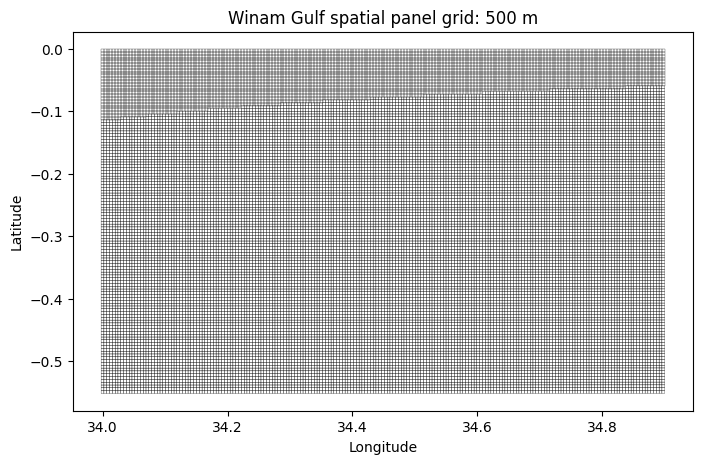

In [37]:
grid = create_grid_from_bbox(AOI_BBOX_WGS84, CELL_SIZE_M, PANEL_CRS)

print(f"Created {len(grid):,} grid cells at {CELL_SIZE_M} m resolution.")
display(grid.head())

grid_path_gpkg = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.gpkg"
grid_path_geojson = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.geojson"

grid.to_file(grid_path_gpkg, layer="grid", driver="GPKG")
grid.to_crs("EPSG:4326").to_file(grid_path_geojson, driver="GeoJSON")

print("Saved grid to:")
print(grid_path_gpkg)
print(grid_path_geojson)

ax = grid.to_crs("EPSG:4326").plot(figsize=(8, 6), facecolor="none", edgecolor="black", linewidth=0.2)
ax.set_title(f"Winam Gulf spatial panel grid: {CELL_SIZE_M} m")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 6b. Bathymetry, water mask, and neighbour graph

Samples per-cell **depth** from the Lake Victoria analytical bathymetry raster (also used as the water/littoral mask, since it is clipped to the lake shoreline) and builds the **queen/rook neighbour graph** used by both the neighbour spatial-lag features and the optional **MRF** spatial basis of the §13 GAM (`GAM_SPATIAL_BASIS="mrf"`, change 2).

In [38]:
# ---------------------------------------------------------------------
# Bathymetry covariate, water/littoral mask inputs, and neighbour graph
# ---------------------------------------------------------------------
# Adds three grid-level structures used downstream:
#   - depth_m / bathy_water_fraction : sampled from the Lake Victoria analytical
#     bathymetry raster. Depth is a static habitat covariate; because the raster
#     is clipped to the lake shoreline, the per-cell valid-pixel fraction is also
#     used as the water/littoral mask (Priority 1).
#   - grid_neighbours : queen/rook contiguity edge list for the neighbour
#     spatial-lag features (Priority 3).
# depth_m and bathy_water_fraction are attached to `grid`, so they flow into the
# panel through the existing grid-attribute merge in section 7.

grid_neighbours = None
if NEIGHBOUR_LAG_ENABLED:
    grid_neighbours = build_grid_neighbours(grid, CELL_SIZE_M, contiguity=NEIGHBOUR_CONTIGUITY)
    _deg = grid_neighbours.groupby("grid_id").size()
    print(f"Neighbour graph ({NEIGHBOUR_CONTIGUITY}): {len(grid_neighbours):,} directed edges, "
          f"mean degree {_deg.mean():.2f} over {grid['grid_id'].nunique():,} cells.")
else:
    print("Neighbour spatial-lag features disabled (NEIGHBOUR_LAG_ENABLED = False).")

# Bathymetry sampling (graceful if the raster is missing, so the notebook still runs).
for _col in ("depth_m", "bathy_water_fraction"):
    if _col in grid.columns:
        grid = grid.drop(columns=_col)

if BATHYMETRY_RASTER is not None and Path(BATHYMETRY_RASTER).exists():
    try:
        bathy_cov = sample_bathymetry_to_grid(
            grid, BATHYMETRY_RASTER, PANEL_CRS,
            depth_positive_down=BATHYMETRY_DEPTH_POSITIVE_DOWN,
            resampling=BATHYMETRY_RESAMPLING,
        )
        grid = grid.merge(bathy_cov[["grid_id", "depth_m", "bathy_water_fraction"]],
                          on="grid_id", how="left")
        _have = grid["depth_m"].notna()
        print(f"\nBathymetry sampled for {int(_have.sum()):,}/{len(grid):,} cells "
              f"({100 * _have.mean():.0f}% contain lake pixels).")
        print(f"  depth_m (m):            min {grid.loc[_have,'depth_m'].min():.1f}, "
              f"median {grid.loc[_have,'depth_m'].median():.1f}, "
              f"max {grid.loc[_have,'depth_m'].max():.1f}")
        print(f"  cells >= MIN_WATER_FRACTION ({MIN_WATER_FRACTION:g}): "
              f"{int((grid['bathy_water_fraction'] >= MIN_WATER_FRACTION).sum()):,}")
    except Exception as exc:
        grid["depth_m"] = np.nan
        grid["bathy_water_fraction"] = np.nan
        print(f"\nBathymetry sampling failed ({type(exc).__name__}: {exc}); "
              "depth_m / bathy_water_fraction set to NaN.")
else:
    grid["depth_m"] = np.nan
    grid["bathy_water_fraction"] = np.nan
    print(f"\nNo bathymetry raster found at BATHYMETRY_RASTER={BATHYMETRY_RASTER}.")
    print("Upload Lake_Victoria_Analytical_ras.tif and point BATHYMETRY_RASTER at it to "
          "enable the depth covariate and the bathymetry water mask.")

display(grid[["grid_id", "x_km", "y_km", "depth_m", "bathy_water_fraction"]].head())


Neighbour graph (queen): 194,242 directed edges, mean degree 7.92 over 24,522 cells.

Bathymetry sampled for 10,337/24,522 cells (42% contain lake pixels).
  depth_m (m):            min 0.0, median 5.5, max 48.0
  cells >= MIN_WATER_FRACTION (0.5): 9,780


,grid_id,x_km,y_km,depth_m,bathy_water_fraction
0,0,611.25,9939.25,35.428781,1.0
1,1,611.25,9939.75,32.503119,1.0
2,2,611.25,9940.25,29.549988,1.0
3,3,611.25,9940.75,26.254183,1.0
4,4,611.25,9941.25,23.285784,1.0


## 7. Aggregate classifier-output WH rasters to the grid

This is the main preprocessing step.

For every selected classifier GeoTIFF, the notebook calculates, for each grid cell:

- valid classified pixel count;
- WH / floating-plant pixel count using `WH_CLASS_VALUES`;
- valid classified area;
- WH area;
- WH proportional cover.

The result is a `grid_id × month` panel with source classifier metadata retained for auditability.


In [39]:
# =====================================================================
# Consolidated panel_raw checkpoint (Drive). Collapses the Section 7
# per-raster reduction loop into one Parquet read on later runs / fresh
# runtimes. Place immediately ABOVE the "## 7. Aggregate ... grid" cell.
# =====================================================================
PANEL_RAW_CHECKPOINT_DIR = OUTPUT_DIR / "panel_checkpoints"
PANEL_RAW_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PANEL_RAW_FORCE_REFRESH = False   # set True to rebuild panel_raw from the rasters

def _panel_raw_fingerprint():
    """Hash everything that defines panel_raw -- and nothing about model tuning."""
    recs = []
    for r in tif_index.itertuples(index=False):
        p = Path(str(r.path))
        pp = getattr(r, "proba_path", None)
        pp = None if (pp is None or (isinstance(pp, float) and pd.isna(pp))
                      or str(pp).strip() in ("", "None", "nan")) else str(pp)
        rec = {"path": str(p),
               "mtime": p.stat().st_mtime_ns if p.exists() else None,
               "size": p.stat().st_size if p.exists() else None,
               "proba": pp}
        if pp and Path(pp).exists():
            rec["proba_mtime"] = Path(pp).stat().st_mtime_ns
            rec["proba_size"] = Path(pp).stat().st_size
        recs.append(rec)
    recs.sort(key=lambda d: d["path"])
    payload = {
        "rasters": recs,
        "cell_size_m": CELL_SIZE_M, "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()),
        "grid_bounds": [float(x) for x in grid.total_bounds],
        "wh_class_values": list(WH_CLASS_VALUES),
        "extra_nodata_values": list(EXTRA_NODATA_VALUES),
        "valid_class_values": list(VALID_CLASS_VALUES),
        "use_probability_response": bool(USE_PROBABILITY_RESPONSE),
        "proba_nodata_value": PROBA_NODATA_VALUE, "proba_scale": PROBA_SCALE,
        # Recorded only when ON, so an existing checkpoint stays valid while it is off.
        **({"proba_cell_mean_confidence": True}
           if globals().get("PROBA_CELL_MEAN_CONFIDENCE", False) else {}),
        "sensor_filter": sorted(CLASSIFIER_SENSOR_FILTER) if CLASSIFIER_SENSOR_FILTER else None,
        # Provenance is part of the identity of panel_raw: a checkpoint built
        # from a different classifier run, export schema or run log must never be
        # reloaded in place of this one.
        "classifier_version": ACTIVE_CLASSIFIER_VERSION,
        "classifier_run_log": str(CLASSIFIER_RUN_LOG_PATH),
        "export_tokens": dict(sorted(REQUIRED_EXPORT_TOKEN_BY_SENSOR.items())),
        "classified_prefixes": dict(sorted(REQUIRED_CLASSIFIED_PREFIX_BY_SENSOR.items())),
        "product_filter": CLASSIFIER_PRODUCT_FILTER,
        "prefer_patch_cleaned_s1": bool(PREFER_PATCH_CLEANED_S1),
        "supplement_run_log_with_folder": bool(SUPPLEMENT_RUN_LOG_WITH_FOLDER),
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()[:20]

PANEL_RAW_CKPT_PATH = PANEL_RAW_CHECKPOINT_DIR / f"panel_raw_{_panel_raw_fingerprint()}.parquet"

PANEL_RAW_FROM_CHECKPOINT = False
if PANEL_RAW_CKPT_PATH.exists() and not PANEL_RAW_FORCE_REFRESH:
    panel_raw = pd.read_parquet(PANEL_RAW_CKPT_PATH)
    panel_raw["month"] = pd.to_datetime(panel_raw["month"])
    validate_panel_provenance(panel_raw, context=f"panel_raw checkpoint {PANEL_RAW_CKPT_PATH.name}")
    PANEL_RAW_FROM_CHECKPOINT = True
    print(f"Loaded panel_raw from checkpoint ({len(panel_raw):,} rows): {PANEL_RAW_CKPT_PATH.name}")
    print(f"-> Provenance validated: {ACTIVE_CLASSIFIER_VERSION}")
    print("-> Skipping the Section 7 raster-to-grid reduction loop.")
else:
    print("No matching panel_raw checkpoint -- the reduction loop will run, then cache its result.")

No matching panel_raw checkpoint -- the reduction loop will run, then cache its result.


In [40]:
if not PANEL_RAW_FROM_CHECKPOINT:
    panel_parts = []
    # Provenance carried onto every panel row as source_* columns, so a built
    # panel can be re-validated without the run log (validate_panel_provenance).
    metadata_cols = PANEL_SOURCE_METADATA_COLUMNS

    for row in tqdm(tif_index.itertuples(index=False), total=len(tif_index)):
        proba_path = getattr(row, "proba_path", None)
        use_proba = (USE_PROBABILITY_RESPONSE and proba_path is not None
                    and not (isinstance(proba_path, float) and pd.isna(proba_path))
                    and str(proba_path).strip() not in ("", "None", "nan")
                    and Path(str(proba_path)).exists())
        cache_path = None
        df = None
        if USE_GRIDDED_RASTER_CACHE and not GRIDDED_RASTER_FORCE_REFRESH:
            cache_path = _gridded_raster_cache_path(
                row.path, row.month, sensor=getattr(row, "sensor", None),
                proba_path=str(proba_path) if use_proba else None,
            )
            df = load_cached_gridded_raster(cache_path)
        if df is None:
            df = aggregate_one_raster_to_grid(
                tif_path=row.path,
                month=row.month,
                grid_gdf=grid,
                panel_crs=PANEL_CRS,
                wh_class_values=WH_CLASS_VALUES,
                extra_nodata_values=EXTRA_NODATA_VALUES,
                valid_class_values=VALID_CLASS_VALUES,
            )
            if len(df) > 0 and use_proba:
                try:
                    soft = aggregate_one_proba_raster_to_grid(
                        class_path=row.path,
                        proba_path=str(proba_path),
                        month=row.month,
                        grid_gdf=grid,
                        panel_crs=PANEL_CRS,
                        wh_class_values=WH_CLASS_VALUES,
                        extra_nodata_values=EXTRA_NODATA_VALUES,
                        valid_class_values=VALID_CLASS_VALUES,
                        proba_nodata_value=PROBA_NODATA_VALUE,
                        proba_scale=PROBA_SCALE,
                        cell_mean_confidence=bool(
                            globals().get("PROBA_CELL_MEAN_CONFIDENCE", False)),
                    )
                    if len(soft) > 0:
                        df = df.merge(soft, on="grid_id", how="left")
                except Exception as exc:
                    print(f"  proba aggregation skipped for {Path(row.path).name}: "
                          f"{type(exc).__name__}: {exc}")
            if len(df) > 0 and USE_GRIDDED_RASTER_CACHE:
                cache_path = _gridded_raster_cache_path(
                    row.path, row.month, sensor=getattr(row, "sensor", None),
                    proba_path=str(proba_path) if use_proba else None,
                )
                save_cached_gridded_raster(df, cache_path)
        if len(df) > 0:
            row_dict = row._asdict()
            stamp_source_metadata(df, row_dict, metadata_cols)
            # Clean per-observation sensor tag (S2/S1) for the Section 7b fusion; the
            # joined-string source_sensor is kept for provenance. Defaults to the
            # primary sensor if discovery could not determine it (folder fallback).
            df["sensor"] = _normalise_classifier_sensor(row_dict.get("sensor")) or PRIMARY_SENSOR
            panel_parts.append(df)

    if len(panel_parts) == 0:
        raise RuntimeError("No panel rows were created. Check raster CRS, AOI, class codes and no-data settings.")

    panel_raw = pd.concat(panel_parts, ignore_index=True)
    validate_panel_provenance(panel_raw, context="panel_raw built from the classified rasters")

    print(f"Raw panel rows before duplicate-month handling: {len(panel_raw):,}")
display(panel_raw.head())


  0%|          | 0/372 [00:00<?, ?it/s]

Raw panel rows before duplicate-month handling: 2,187,740


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,wh_cover_soft,wh_conf_mean,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,sensor
0,20232,2017-04-01,60,0,6000.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
1,20354,2017-04-01,807,0,80700.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
2,20476,2017-04-01,474,0,47400.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
3,21648,2017-04-01,72,0,7200.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2
4,21649,2017-04-01,200,0,20000.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,0.0,NaN,S2,model,2017-04-02,2017-04-03,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,S2


In [41]:
if not PANEL_RAW_FROM_CHECKPOINT:
    panel_raw.to_parquet(PANEL_RAW_CKPT_PATH, index=False)
    print(f"Saved panel_raw checkpoint: {PANEL_RAW_CKPT_PATH}")

Saved panel_raw checkpoint: /content/drive/MyDrive/WH_spatial_panel_test/panel_checkpoints/panel_raw_2de70f7f7cf020db92cb.parquet


### Combine duplicate observations within the same month

If the classifier output has only one selected raster per month, this step will not change much.

If there are multiple selected snapshots in the same month, the default behaviour is to take the **mean** grid-cell WH cover/area across those rasters. You can change this to `max` in the configuration cell.


In [42]:
if DUPLICATE_MONTH_METHOD not in {"mean", "max"}:
    raise ValueError("DUPLICATE_MONTH_METHOD must be either 'mean' or 'max'.")

source_agg = lambda x: "; ".join(sorted(set(map(str, x.dropna()))))
source_metadata_cols = [c for c in panel_raw.columns if c.startswith("source_")]

# Reduce duplicates WITHIN each sensor (e.g. several S2 snapshots in one month),
# but keep S1 and S2 as SEPARATE observations of the same cell-month so they can
# be harmonised -- not blended -- in the Section 7b cloud-gap-fill fusion.
agg_funcs = {
    "valid_pixels": DUPLICATE_MONTH_METHOD,
    "wh_pixels": DUPLICATE_MONTH_METHOD,
    "valid_area_m2": DUPLICATE_MONTH_METHOD,
    "wh_area_m2": DUPLICATE_MONTH_METHOD,
    "wh_cover": DUPLICATE_MONTH_METHOD,
    "source_file": source_agg,
}
for col in source_metadata_cols:
    agg_funcs[col] = source_agg

# Carry the confidence-weighted response columns through the monthly aggregation.
for _soft_col in ["wh_cover_soft", "wh_conf_mean", "wh_conf_all_mean"]:
    if _soft_col in panel_raw.columns:
        agg_funcs[_soft_col] = "mean"

# Ensure every observation carries a sensor tag (defensive for folder fallback).
if "sensor" not in panel_raw.columns:
    panel_raw["sensor"] = PRIMARY_SENSOR
panel_raw["sensor"] = panel_raw["sensor"].fillna(PRIMARY_SENSOR)

panel_sensor = (
    panel_raw
    .groupby(["grid_id", "month", "sensor"], as_index=False)
    .agg(agg_funcs)
)

# Retain only minimally valid cell-months (per sensor).
panel_sensor = panel_sensor[panel_sensor["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()

# Basic response variables (per sensor).
panel_sensor["wh_area_ha"] = panel_sensor["wh_area_m2"] / 10_000
panel_sensor["valid_area_ha"] = panel_sensor["valid_area_m2"] / 10_000
# Fractional valid coverage of the nominal cell area (1.0 == fully observed).
panel_sensor["valid_fraction"] = (panel_sensor["valid_area_m2"] / (CELL_SIZE_M ** 2)).clip(upper=1.0)

# --- Confidence-weighted (probabilistic) response per sensor (Priority 2) -----
# Keep hard-class cover/area for reference, then -- if enabled and available --
# swap the modelling response to the confidence-weighted cover (same rule as
# before, now applied within each sensor so S1 keeps its own soft response).
panel_sensor["wh_cover_hard"] = panel_sensor["wh_cover"]
panel_sensor["wh_area_ha_hard"] = panel_sensor["wh_area_ha"]
if (USE_PROBABILITY_RESPONSE and "wh_cover_soft" in panel_sensor.columns
        and panel_sensor["wh_cover_soft"].notna().any()):
    panel_sensor["wh_cover"] = panel_sensor["wh_cover_soft"].where(
        panel_sensor["wh_cover_soft"].notna(), panel_sensor["wh_cover_hard"])
    panel_sensor["wh_area_m2"] = panel_sensor["wh_cover"] * panel_sensor["valid_area_m2"]
    panel_sensor["wh_area_ha"] = panel_sensor["wh_area_m2"] / 10_000
    print("Response: CONFIDENCE-WEIGHTED WH cover per sensor "
          "(USE_PROBABILITY_RESPONSE=True); hard-class cover retained as wh_cover_hard.")
else:
    print("Response: HARD-CLASS WH cover per sensor (probability rasters unavailable or disabled).")

# Presence-definition label. Presence itself is computed ONCE on the merged panel
# in Section 7b (after the S1 gap-fill), so it is defined in a single place.
if PRESENCE_AREA_HA_THRESHOLD is not None:
    presence_definition = f"wh_area_ha >= {PRESENCE_AREA_HA_THRESHOLD} ha"
else:
    presence_definition = f"wh_cover >= {PRESENCE_COVER_THRESHOLD:g} (fractional cover)"

print(f"\nPer-sensor panel rows (before fusion): {len(panel_sensor):,}")
_per_sensor = panel_sensor.groupby("sensor").agg(
    cell_months=("grid_id", "size"),
    months=("month", "nunique"),
    cells=("grid_id", "nunique"),
    mean_cover=("wh_cover", "mean"),
).reset_index()
display(_per_sensor)
display(panel_sensor.head())

Response: CONFIDENCE-WEIGHTED WH cover per sensor (USE_PROBABILITY_RESPONSE=True); hard-class cover retained as wh_cover_hard.

Per-sensor panel rows (before fusion): 590,737


,sensor,cell_months,months,cells,mean_cover
0,S2,590737,96,6446,0.00653


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0


## 7b. Sentinel-1 cloud-gap-fill fusion (prefer-S2, gap-fill-S1)

> **Conditional.** Steps 1–3 below run only when the classifier run log supplies valid **Sentinel-1** rasters *and* `ENABLE_S1_GAPFILL` is on. With no S1 raster selected nothing is compared, calibrated or filled, and the panel is Sentinel-2 only — §7c reports which of those happened, and §9b's MNAR payoff is then not computed. Do not describe the response as cloud-gap-filled unless §7c says the fill was applied.

When S1 rasters are present, this section turns the per-sensor panel into a single harmonised response:

1. **Agreement (1b):** on cell-months observed by *both* sensors, report mean/median bias `S1 − S2`, Pearson & Spearman correlation, a Bland–Altman plot, and a presence confusion matrix at the current presence definition.
2. **Calibration (1c):** fit `S2_cover ~ S1_cover` on the overlap (Theil–Sen robust-linear by default; isotonic optional) and apply it to S1-only cell-months, so S1 enters on the S2 measurement scale.
3. **Merge (1d):** build `panel` by **preferring S2** and gap-filling with calibrated S1 *only where S2 is missing* for that cell-month. A `sensor` label and a numeric `sensor_is_s1` indicator are carried so any residual cross-sensor offset is absorbed by the model rather than attributed to a driver.

The MNAR payoff (1e) — whether the S1 fills concentrate in high-rainfall months — is reported in Section 9b, once the CHIRPS rainfall covariate has been merged.


In [43]:
# Harmonise the per-sensor panel into a single cloud-gap-filled response.
PRIMARY = PRIMARY_SENSOR
SECONDARY = "S1" if PRIMARY == "S2" else "S2"

available_sensors = sorted(s for s in panel_sensor["sensor"].dropna().unique().tolist())
print("Sensors present in the per-sensor panel:", available_sensors)

prim = panel_sensor[panel_sensor["sensor"] == PRIMARY].copy()
sec = panel_sensor[panel_sensor["sensor"] == SECONDARY].copy()

# Month-coverage BEFORE fusion (primary sensor only) -- the "before" acceptance.
cov_before_cellmonths = int(len(prim))
cov_before_months = int(prim["month"].nunique())

do_fusion = bool(ENABLE_S1_GAPFILL and len(prim) > 0 and len(sec) > 0)
calib_info = {"method": "disabled"}

if not do_fusion:
    base = prim if len(prim) > 0 else panel_sensor.copy()
    panel = base.copy()
    if "sensor" not in panel.columns:
        panel["sensor"] = PRIMARY
    panel["sensor_is_s1"] = (panel["sensor"] == "S1").astype(int)
    panel["wh_cover_raw_sensor"] = panel["wh_cover"]
    print(f"\nS1 gap-fill disabled or unavailable -- using {PRIMARY} only "
          f"({cov_before_cellmonths:,} cell-months, {cov_before_months} months).")
else:
    # ---- (1b) Cross-sensor agreement on overlap cell-months -----------------
    overlap = sensor_overlap_frame(panel_sensor, "wh_cover", PRIMARY, SECONDARY)
    prim_c = overlap[f"wh_cover_{PRIMARY}"]
    sec_c = overlap[f"wh_cover_{SECONDARY}"]
    stats = sensor_agreement_stats(prim_c, sec_c)
    print("\n--- (1b) S1 vs S2 agreement on overlap cell-months ---")
    print(f"Overlap cell-months (both sensors valid): {stats['n_pairs']:,}")
    print(f"mean(S1 - S2) cover = {stats['mean_sec_minus_prim']:+.4f}   "
          f"median = {stats['median_sec_minus_prim']:+.4f}")
    print(f"Pearson r = {stats['pearson_r']:.3f}   Spearman r = {stats['spearman_r']:.3f}")

    if stats["n_pairs"] > 0:
        prim_pres = wh_presence_from_cover(overlap[f"wh_cover_{PRIMARY}"],
                                           overlap[f"wh_area_ha_{PRIMARY}"]).astype(int)
        sec_pres = wh_presence_from_cover(overlap[f"wh_cover_{SECONDARY}"],
                                          overlap[f"wh_area_ha_{SECONDARY}"]).astype(int)
        cm = confusion_matrix(prim_pres, sec_pres, labels=[0, 1])
        print(f"\nPresence confusion (rows = S2 obs, cols = S1 obs; {presence_definition}):")
        display(pd.DataFrame(cm, index=["S2_absent", "S2_present"],
                             columns=["S1_absent", "S1_present"]))
        _agree = float(np.trace(cm) / cm.sum()) if cm.sum() else np.nan
        print(f"Overall presence agreement: {_agree:.3f}")

        # Bland-Altman: difference vs mean of the two sensors' cover.
        m = (prim_c.to_numpy() + sec_c.to_numpy()) / 2.0
        d = sec_c.to_numpy() - prim_c.to_numpy()
        md, sd = float(np.nanmean(d)), float(np.nanstd(d))
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(m, d, s=8, alpha=0.3)
        ax.axhline(md, color="red", label=f"mean {md:+.3f}")
        ax.axhline(md + 1.96 * sd, color="grey", ls="--", label=f"+1.96sd {md + 1.96 * sd:+.3f}")
        ax.axhline(md - 1.96 * sd, color="grey", ls="--", label=f"-1.96sd {md - 1.96 * sd:+.3f}")
        ax.set_xlabel("Mean of S1 and S2 WH cover")
        ax.set_ylabel("S1 - S2 WH cover")
        ax.set_title("Bland-Altman: S1 vs S2 WH cover (overlap cell-months)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.show()

    # ---- (1c) Calibrate S1 cover onto the S2 scale --------------------------
    calib_f, calib_info = fit_secondary_to_primary_calibration(
        sec_c.to_numpy(), prim_c.to_numpy(),
        method=S1_CALIBRATION_METHOD, random_state=RANDOM_STATE)
    print("\n--- (1c) S1 -> S2 cover calibration ---")
    print(f"Calibration: {calib_info}")

    # ---- (1d) Merge: prefer S2, gap-fill with calibrated S1 -----------------
    prim_keep = prim.copy()
    prim_keep["sensor"] = PRIMARY
    prim_keep["sensor_is_s1"] = 0
    prim_keep["wh_cover_raw_sensor"] = prim_keep["wh_cover"]

    sec_idx = sec.set_index(["grid_id", "month"])
    prim_index = prim_keep.set_index(["grid_id", "month"]).index
    sec_fill = sec_idx.loc[~sec_idx.index.isin(prim_index)].reset_index()
    sec_fill["sensor"] = SECONDARY
    sec_fill["sensor_is_s1"] = 1
    sec_fill["wh_cover_raw_sensor"] = sec_fill["wh_cover"]
    # Put S1 cover on the S2 scale and recompute its WH area accordingly.
    sec_fill["wh_cover"] = calib_f(sec_fill["wh_cover"].to_numpy())
    sec_fill["wh_area_m2"] = sec_fill["wh_cover"] * sec_fill["valid_area_m2"]
    sec_fill["wh_area_ha"] = sec_fill["wh_area_m2"] / 10_000

    panel = pd.concat([prim_keep, sec_fill], ignore_index=True)
    print("\n--- (1d) Merged response (prefer S2, gap-fill calibrated S1) ---")
    print(f"S2 cell-months kept:            {len(prim_keep):,}")
    print(f"S1 gap-fill cell-months added:  {len(sec_fill):,} "
          f"(S2-missing cell-months recovered by S1)")

# ---- Finalise the merged panel: grid attributes, presence, coverage ---------
# Re-attach the static grid attributes (coords, depth, water fraction, ...).
panel = panel.drop(
    columns=[c for c in grid.columns if c not in ("grid_id", "geometry") and c in panel.columns],
    errors="ignore")
panel = panel.merge(grid.drop(columns="geometry"), on="grid_id", how="left")
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)
if "sensor_is_s1" not in panel.columns:
    panel["sensor_is_s1"] = 0
panel["wh_present"] = wh_presence_from_cover(panel["wh_cover"], panel.get("wh_area_ha"))

# Month-coverage AFTER fusion -- the "after" acceptance.
cov_after_cellmonths = int(len(panel))
cov_after_months = int(panel["month"].nunique())
print("\n--- Panel month-coverage: BEFORE vs AFTER S1 gap-fill ---")
print(f"Before (S2 only):      {cov_before_cellmonths:,} cell-months, {cov_before_months} months")
print(f"After  (S2 + S1 fill): {cov_after_cellmonths:,} cell-months, {cov_after_months} months")
_gain = cov_after_cellmonths - cov_before_cellmonths
if cov_before_cellmonths:
    print(f"Net cell-months recovered by S1: {_gain:,} "
          f"({_gain / cov_before_cellmonths * 100:.1f}% of the S2-only panel)")
if "sensor" in panel.columns:
    print("\nCell-months by response sensor:")
    display(panel.groupby("sensor").size().rename("n_cell_months").reset_index())

# Per-month coverage comparison (S2 cells vs S1-filled cells vs merged cells).
_cov_by_month = (panel.groupby("month")
                 .agg(merged_cells=("grid_id", "nunique"),
                      s1_filled_cells=("sensor_is_s1", "sum")).reset_index())
_s2_by_month = prim.groupby("month")["grid_id"].nunique().rename("s2_cells")
_cov_by_month = _cov_by_month.merge(_s2_by_month, on="month", how="left")
_cov_by_month["s2_cells"] = _cov_by_month["s2_cells"].fillna(0).astype(int)
_cov_by_month = _cov_by_month[["month", "s2_cells", "s1_filled_cells", "merged_cells"]]
print("\nPer-month coverage (S2 cells vs S1-filled cells vs merged cells):")
display(_cov_by_month)

print(f"\nWH presence defined as: {presence_definition}")
print(f"Overall WH-present prevalence (merged panel): {panel['wh_present'].mean():.4f} "
      f"({int(panel['wh_present'].sum()):,} of {len(panel):,} cell-months)")
display(panel.head())


Sensors present in the per-sensor panel: ['S2']

S1 gap-fill disabled or unavailable -- using S2 only (590,737 cell-months, 96 months).

--- Panel month-coverage: BEFORE vs AFTER S1 gap-fill ---
Before (S2 only):      590,737 cell-months, 96 months
After  (S2 + S1 fill): 590,737 cell-months, 96 months
Net cell-months recovered by S1: 0 (0.0% of the S2-only panel)

Cell-months by response sensor:


,sensor,n_cell_months
0,S2,590737



Per-month coverage (S2 cells vs S1-filled cells vs merged cells):


,month,s2_cells,s1_filled_cells,merged_cells
0,2017-04-01,277,0,277
1,2017-05-01,220,0,220
2,2017-06-01,6246,0,6246
3,2017-10-01,277,0,277
4,2018-05-01,274,0,274
...,...,...,...,...
91,2026-03-01,6446,0,6446
92,2026-04-01,6197,0,6197
93,2026-05-01,6446,0,6446
94,2026-06-01,6446,0,6446



WH presence defined as: wh_cover >= 0.02 (fractional cover)
Overall WH-present prevalence (merged panel): 0.0384 (22,712 of 590,737 cell-months)


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard,sensor_is_s1,wh_cover_raw_sensor,x_km,y_km,cell_area_m2,depth_m,bathy_water_fraction,wh_present
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False


### 7c. Which sensor(s) this run actually used

`ENABLE_S1_GAPFILL` requests a Sentinel-1 cloud-gap-fill; whether one *happened* is a property
of the run. When the active classifier run log yields no valid S1 raster the panel is
**Sentinel-2 only**, and the cell below says so, labels the exported run `S2_only`, drops the
now-constant `sensor_is_s1` indicator, and states the **cloud-related MNAR limitation that
remains unmitigated**. The S1 agreement, calibration and MNAR-mitigation outputs above are then
not produced, and must not be quoted.


In [ ]:
# =====================================================================
# 7c. What sensor(s) does this run ACTUALLY use? -- report, do not imply
# =====================================================================
# ENABLE_S1_GAPFILL asks for a Sentinel-1 cloud-gap-fill. Whether one HAPPENED is a
# property of the run, not of the switch: if the classifier run log contains no
# valid S1 rasters (as in the current provenance audit -- 372 S2, 0 S1), the panel
# is Sentinel-2-only and every downstream label, export and caveat must say so.
# This cell records the outcome, removes the now-constant sensor indicator, and
# states the cloud-related MNAR limitation that remains UNMITIGATED in that case.
import json as _json

_sensors_in_panel = sorted(panel["sensor"].dropna().unique().tolist()) if "sensor" in panel.columns else []
_n_s1_rows = int((panel.get("sensor_is_s1", pd.Series(0, index=panel.index)) == 1).sum())
S1_GAPFILL_REQUESTED = bool(globals().get("ENABLE_S1_GAPFILL", False))
S1_GAPFILL_APPLIED = bool(_n_s1_rows > 0)
PANEL_SENSOR_MODE = "S2_only" if _sensors_in_panel == ["S2"] else "+".join(_sensors_in_panel) or "unknown"
PANEL_IS_S2_ONLY = (PANEL_SENSOR_MODE == "S2_only")

print("=" * 72)
print("RESPONSE SENSOR COMPOSITION")
print("=" * 72)
print(f"S1 gap-fill requested (ENABLE_S1_GAPFILL): {S1_GAPFILL_REQUESTED}")
print(f"S1 gap-fill actually applied             : {S1_GAPFILL_APPLIED}")
print(f"Sensors contributing response rows       : {_sensors_in_panel or 'none'}")
print(f"Run label                                : {PANEL_SENSOR_MODE}")
print(f"Cell-months by sensor                    : S2={len(panel) - _n_s1_rows:,}, S1={_n_s1_rows:,}")

if S1_GAPFILL_REQUESTED and not S1_GAPFILL_APPLIED:
    print("\n*** S1 gap-fill was REQUESTED but did NOT occur. ***")
    print("No Sentinel-1 raster from the active classifier run passed selection, so nothing")
    print("was harmonised, calibrated or filled. This run is Sentinel-2-only and is exported,")
    print("labelled and reported as such. Do not describe it as cloud-gap-filled, and do not")
    print("quote the S1->S2 calibration, the Bland-Altman agreement or the MNAR-mitigation")
    print("verdict: none of them were computed on this panel.")

if PANEL_IS_S2_ONLY:
    print("\nREMAINING LIMITATION (unmitigated, MNAR): Sentinel-2 is cloud-limited. A cell-month")
    print("with no cloud-free observation is ABSENT from the panel rather than recorded as")
    print("zero cover, and that missingness is correlated with rainfall -- one of the drivers")
    print("under study. The response is therefore Missing Not At Random with respect to")
    print("rainfall, so rainfall effects estimated here are conditional on a scene being")
    print("cloud-free, and wet-month WH extent is systematically under-observed. §9b quantifies")
    print("the month-coverage gaps; the S1 route that would mitigate this is unavailable.")
    _obs_months = int(panel['month'].nunique())
    _all_months = len(pd.period_range(pd.Timestamp(TEST_START).to_period('M'),
                                      pd.Timestamp(TEST_END).to_period('M'), freq='M'))
    print(f"  Months observed: {_obs_months} of {_all_months} in the test period "
          f"({_obs_months / _all_months:.0%}).")

# The sensor indicator only carries information when both sensors contribute rows.
# On an S2-only panel it is a constant column: keeping it would put a coefficient in
# the model that is not identified by anything. Drop it here, once.
SENSOR_FEATURE_AVAILABLE = bool(
    "sensor_is_s1" in panel.columns and panel["sensor_is_s1"].nunique(dropna=True) > 1)
if "sensor_is_s1" in panel.columns and not SENSOR_FEATURE_AVAILABLE:
    panel = panel.drop(columns=["sensor_is_s1"])
    print("\nDropped the constant sensor indicator 'sensor_is_s1' (single-sensor panel);")
    print("no sensor coefficient can or should appear in any model of this run.")
SENSOR_FEATURE_ENABLED = bool(globals().get("SENSOR_FEATURE_ENABLED", False)) and SENSOR_FEATURE_AVAILABLE

# Machine-readable run label so the exports cannot drift from the text above.
PANEL_SENSOR_PROVENANCE = {
    "panel_sensor_mode": PANEL_SENSOR_MODE,
    "s1_gapfill_requested": S1_GAPFILL_REQUESTED,
    "s1_gapfill_applied": S1_GAPFILL_APPLIED,
    "sensors_present": _sensors_in_panel,
    "n_cell_months": int(len(panel)),
    "n_cell_months_s1_filled": _n_s1_rows,
    "n_months_observed": int(panel["month"].nunique()),
    "sensor_feature_available": SENSOR_FEATURE_AVAILABLE,
    "cloud_mnar_limitation": (
        "Sentinel-2 cloud gaps remain unmitigated: missing cell-months are absent, not zero, "
        "and missingness correlates with rainfall (MNAR)." if PANEL_IS_S2_ONLY else
        "Sentinel-1 gap-fill applied; residual cross-sensor offset absorbed by sensor_is_s1."),
    "classifier_version": ACTIVE_CLASSIFIER_VERSION,
}
_prov_path = OUTPUT_DIR / f"panel_sensor_provenance_{CELL_SIZE_M}m_{PANEL_SENSOR_MODE}.json"
_prov_path.write_text(_json.dumps(PANEL_SENSOR_PROVENANCE, indent=2, default=str))
print(f"\nSaved run label: {_prov_path}")


### Sensitivity of the WH-present definition to the chosen threshold

The response variable depends strongly on how "present" is defined. The table
below shows how the number of positive cell-months, the positive rate, the mean
WH signal among positives, and the number of months with at least one positive
cell change as the fractional-cover presence threshold is varied. Threshold `0`
reproduces the original "any non-zero WH pixel" definition.


In [44]:
presence_threshold_grid = [0, 0.001, 0.005, 0.01, 0.02, 0.05]

sensitivity_rows = []
for thr in presence_threshold_grid:
    # thr == 0 reproduces the original "any non-zero WH" definition.
    present = panel["wh_cover"] > 0 if thr == 0 else panel["wh_cover"] >= thr
    n_pos = int(present.sum())
    sensitivity_rows.append({
        "cover_threshold": thr,
        "n_positive_cell_months": n_pos,
        "pct_positive": round(100 * present.mean(), 3),
        "mean_cover_among_pos": round(panel.loc[present, "wh_cover"].mean(), 4) if n_pos else np.nan,
        "mean_area_ha_among_pos": round(panel.loc[present, "wh_area_ha"].mean(), 4) if n_pos else np.nan,
        "n_months_with_positive": int(panel.loc[present, "month"].nunique()),
    })

presence_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensitivity of WH-present prevalence to the cover threshold:")
display(presence_sensitivity)


Sensitivity of WH-present prevalence to the cover threshold:


,cover_threshold,n_positive_cell_months,pct_positive,mean_cover_among_pos,mean_area_ha_among_pos,n_months_with_positive
0,0.000,148282,25.101,0.0260,0.5434,96
1,0.001,82154,13.907,0.0467,0.9752,96
2,0.005,44861,7.594,0.0835,1.7449,96
3,0.010,32255,5.460,0.1133,2.3721,95
4,0.020,22712,3.845,0.1550,3.2541,95
5,0.050,14364,2.432,0.2268,4.7816,95


## Classifier accuracy and response measurement error

The response is a classifier output, so its accuracy and per-cell confidence are reported here rather than assumed perfect (Priority 2).

In [45]:
# ---------------------------------------------------------------------
# Classifier accuracy and response measurement-error (Priority 2)
# ---------------------------------------------------------------------
# The panel response is itself a classifier output, so its error should be
# surfaced rather than treated as ground truth. This cell (a) reports any
# cross-validation accuracy metrics the classifier notebook logged, and (b)
# summarises the per-cell classification confidence and the hard-vs-soft cover
# agreement, which quantify the measurement error entering the response.

# (a) Classifier CV accuracy metrics, if the classifier notebook saved a table.
_metric_tables = []
try:
    for _patt in ("*model_selection*metrics*.csv", "*metrics*.csv", "*cv*metrics*.csv",
                  "*_metrics_*.csv"):
        _metric_tables += list(Path(CLASSIFIER_TABLE_DIR).glob(_patt))
except Exception:
    pass
_metric_tables = sorted(set(_metric_tables), key=lambda p: p.stat().st_mtime if p.exists() else 0)
if _metric_tables:
    _mt = _metric_tables[-1]
    print(f"Classifier accuracy metrics from: {_mt.name}")
    try:
        _mdf = pd.read_csv(_mt)
        _show = [c for c in ["sensor", "model", "method", "accuracy", "balanced_accuracy",
                             "kappa", "macro_f1", "weighted_f1"] if c in _mdf.columns]
        display(_mdf[_show] if _show else _mdf.head())
    except Exception as exc:
        print("  could not read metrics table:", exc)
else:
    print("No classifier CV-metrics CSV found in CLASSIFIER_TABLE_DIR.")
    print("  (Look for the model-selection metrics exported by "
          "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; accuracy/kappa/macro-F1 "
          "should be quoted alongside these panel results.)")

# (b) Response confidence + hard-vs-soft agreement, from the panel.
if "wh_conf_mean" in panel.columns and panel["wh_conf_mean"].notna().any():
    _c = panel["wh_conf_mean"].dropna()
    print(f"\nPer-cell WH classification confidence (winning-class P over WH pixels), "
          f"n={len(_c):,}:")
    display(_c.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))
    _low = (_c < 0.6).mean()
    print(f"Share of WH-bearing cell-months with mean confidence < 0.60: {_low:.1%} "
          "(these contribute most of the response measurement error).")
else:
    print("\nNo per-cell confidence available (probability rasters not aggregated).")

if {"wh_cover_hard", "wh_cover_soft"}.issubset(panel.columns) and panel["wh_cover_soft"].notna().any():
    _m = panel[["wh_cover_hard", "wh_cover_soft"]].dropna()
    if len(_m) > 2:
        _corr = _m["wh_cover_hard"].corr(_m["wh_cover_soft"])
        _bias = (_m["wh_cover_soft"] - _m["wh_cover_hard"]).mean()
        print(f"\nHard vs confidence-weighted cover: r={_corr:.3f}, "
              f"mean(soft - hard)={_bias:+.4f} "
              f"(soft is typically slightly lower, having down-weighted low-confidence WH pixels).")
        _ha = panel["valid_area_m2"]
        _area_hard = float((panel["wh_cover_hard"] * _ha / 1e4).sum())
        _area_soft = float((panel["wh_cover_soft"].fillna(panel["wh_cover_hard"]) * _ha / 1e4).sum())
        print(f"Panel-total WH area: hard={_area_hard:,.0f} ha, "
              f"confidence-weighted={_area_soft:,.0f} ha "
              f"({_area_soft / _area_hard:.0%} of hard).")
        print(f"Modelling response in use: "
              f"{'confidence-weighted (soft)' if USE_PROBABILITY_RESPONSE else 'hard-class'} cover.")
else:
    print("\nConfidence-weighted cover not available; the response uses hard-class cover.")


No classifier CV-metrics CSV found in CLASSIFIER_TABLE_DIR.
  (Look for the model-selection metrics exported by Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; accuracy/kappa/macro-F1 should be quoted alongside these panel results.)

Per-cell WH classification confidence (winning-class P over WH pixels), n=148,282:


,wh_conf_mean
count,148282.000
mean,0.564
std,0.144
min,0.260
10%,0.402
25%,0.457
50%,0.534
75%,0.649
90%,0.781
max,1.000


Share of WH-bearing cell-months with mean confidence < 0.60: 66.2% (these contribute most of the response measurement error).

Hard vs confidence-weighted cover: r=0.988, mean(soft - hard)=-0.0018 (soft is typically slightly lower, having down-weighted low-confidence WH pixels).
Panel-total WH area: hard=101,722 ha, confidence-weighted=80,578 ha (79% of hard).
Modelling response in use: confidence-weighted (soft) cover.


## 8. Earth Engine environmental covariate extraction

This step pulls the environmental driver layers that have usable Google Earth Engine assets and reduces them onto the panel. It runs when `USE_EARTH_ENGINE = True` (configured in section 3) and is wrapped in a `try/except` so the notebook still completes if Earth Engine is unavailable.

Three tables are produced:

| Output | Keyed by | Layers |
| --- | --- | --- |
| `ee_monthly_cov` | `month` | Wind and air temperature **only when `EE_CLIMATE_PER_CELL=False`** (ERA5 u/v/speed/direction/bay-axis; ERA5-Land air temp where it covers the AOI, else ERA5); optional MODIS ocean-colour chlorophyll-a (off by default) |
| `ee_cellmonth_cov` | `grid_id`, `month` | **ERA5(-Land) wind + air temperature per cell** (default, `EE_CLIMATE_PER_CELL=True`); Rainfall (CHIRPS ~5 km, per cell by default: total, antecedent sums, spike counts, Rx1day, wet days, SDII); MODIS LST **water-surface temperature** (~1 km, per cell by default); Sentinel-2 **turbidity** (NDTI + red reflectance) proxy; **Sentinel-3 OLCI chlorophyll-a** (mg/m³) via MCI and MPH band-difference algorithms calibrated per Kravitz et al. (2020); all water-masked |
| `ee_static_cov` | `grid_id` | Distance to rivers and to major (discharge-weighted) rivers (HydroSHEDS), distance to shore and openness (JRC GSW), catchment pressure (ESA WorldCover fractions, WorldPop population, GHSL built-up) |

**Resolution strategy.** The reanalysis climate layers (ERA5 wind ~28 km / ERA5-Land air temperature ~11 km) are extracted **per grid cell and month by default** (`EE_CLIMATE_PER_CELL = True`, change 3a), so their coarse cross-gulf gradient enters the panel instead of a single AOI-mean series that would be spatially constant and therefore perfectly confounded with the seasonal/trend terms. Only a few reanalysis pixels span Winam Gulf, so the added spatial signal is modest and the per-cell reduction is heavier; set `EE_CLIMATE_PER_CELL = False` to revert to AOI-mean monthly series. Air temperature defaults to **ERA5-Land** (~11 km, lapse-rate corrected) where it covers the AOI, falling back to ERA5; wind stays on ERA5, whose 10 m field ERA5-Land only interpolates. MODIS LST water-surface temperature (~1 km) and CHIRPS rainfall (~5 km) -- both per cell by default (`EE_WATER_TEMP_PER_CELL`, `EE_RAIN_PER_CELL`) -- and the Sentinel-2 water-quality proxies (~20 m) are likewise extracted **per grid cell and month**. Static layers are extracted **once per cell**.

**Derived mechanistic interactions.** `wave_exposure_idx` (openness x wind^2, a local physical-disturbance force) and `nutrient_pulse_idx` (antecedent rain x cropland, the storm-fertilisation pulse, entered lagged) are computed from the merged covariates so the disturbance and nutrient mechanisms are encoded explicitly, not left to the main effects alone.

**Sentinel-3 OLCI chlorophyll-a.** GEE's OLCI asset provides only TOA radiances (no geometry/meteorology tie-points), so the best atmospheric corrections in Kravitz et al. (2020) — BRR and 6SV1 — cannot be reproduced inside GEE. Their key result is that the **MCI and MPH band-difference algorithms are robust to atmospheric correction**, and they publish TOA-reflectance calibrations (Table B.1). The notebook therefore computes OLCI TOA reflectance (nominal solar irradiance + analytically reconstructed solar zenith) and retrieves chl-a with **MCI** (their best TOA method, R²=0.53) and **MPH** (best overall, R²=0.55; its BRR calibration is applied to TOA reflectance as a documented approximation). For publication-grade chl-a, process BRR/6SV externally (SNAP / Py6S) and ingest via the CSV hook in section 9.

**Layers that need a CSV instead (no standard EE asset):** lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD indices, bathymetry/depth, and in-situ nutrients (TN, TP, DIN, SRP). Supply these through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV` in section 9.

**Caching to Drive.** Earth Engine extraction is the slow step here, so the covariate tables are cached. The first successful run writes them to `EE_CACHE_DIR` (defaults to `OUTPUT_DIR`) alongside a small JSON manifest, and every later run reloads them from Drive instead of querying Earth Engine — so the per-cell reductions only run once per configuration. The cache is keyed by a fingerprint of the settings that change the covariates (cell size, AOI, test period, the panel's month set and the `EE_*` parameters), so it rebuilds automatically when any of those change. Set `EE_FORCE_REFRESH = True` (or delete the `ee_*_covariates_*` files) to force a fresh pull, or `USE_EE_CACHE = False` to bypass the cache entirely.

> The first run on a fresh Colab runtime triggers `ee.Authenticate()`. Per-cell reductions scale with the number of grid cells, so prefer `CELL_SIZE_M = 1000` for Earth Engine test runs, or turn off `waterquality_s2`/`waterquality_s3` in `EE_LAYERS` for the quickest pass.

In [46]:
# Initialise the EE covariate containers so later cells work even when
# USE_EARTH_ENGINE is False or extraction fails.
ee_monthly_cov = None
ee_cellmonth_cov = None
ee_static_cov = None
ee_registry = {"monthly": [], "cellmonth": [], "static": []}

# ---------------------------------------------------------------------
# Drive cache helpers for the Earth Engine covariates
# ---------------------------------------------------------------------
# Earth Engine extraction is the slow step in this notebook. The covariate
# tables are written to EE_CACHE_DIR after the first successful run and reloaded
# on later runs (see USE_EE_CACHE / EE_FORCE_REFRESH in section 3), so the
# per-cell Earth Engine reductions only happen once per configuration. A small
# JSON manifest records which tables exist plus a fingerprint of the settings
# that change the covariates, so the cache is rebuilt automatically when any of
# those settings change.
import hashlib
import json

_EE_CACHE_TAG = f"{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}"
EE_CACHE_PATHS = {
    "monthly":   Path(EE_CACHE_DIR) / f"ee_monthly_covariates_{_EE_CACHE_TAG}.csv",
    "cellmonth": Path(EE_CACHE_DIR) / f"ee_cellmonth_covariates_{_EE_CACHE_TAG}.csv",
    "static":    Path(EE_CACHE_DIR) / f"ee_static_covariates_{_EE_CACHE_TAG}.csv",
}
EE_CACHE_MANIFEST = Path(EE_CACHE_DIR) / f"ee_covariates_cache_manifest_{_EE_CACHE_TAG}.json"


def _ee_cache_signature(months):
    """Fingerprint the configuration that determines the EE covariate values."""
    payload = {
        "cell_size_m": CELL_SIZE_M,
        "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()),
        "months": [str(pd.Timestamp(m).date()) for m in months],
        "ee_layers": {k: bool(v) for k, v in EE_LAYERS.items()},
        "ee_s2_products": sorted(EE_S2_PRODUCTS),
        "ee_s3_products": sorted(EE_S3_PRODUCTS),
        "ee_rain_antecedent_days": list(EE_RAIN_ANTECEDENT_DAYS),
        "ee_rain_intensity": bool(EE_RAIN_INTENSITY),
        "ee_rain_spike_thresholds_mm": list(EE_RAIN_SPIKE_THRESHOLDS_MM),
        "ee_rain_wet_day_mm": EE_RAIN_WET_DAY_MM,
        "ee_rain_per_cell": bool(EE_RAIN_PER_CELL),
        "ee_bay_axis_bearing_deg": EE_BAY_AXIS_BEARING_DEG,
        "ee_water_occurrence_threshold": EE_WATER_OCCURRENCE_THRESHOLD,
        "ee_s2_cloud_pct": EE_S2_CLOUD_PCT,
        "ee_climate_aoi_scale": EE_CLIMATE_AOI_SCALE,
        "ee_air_temp_use_era5_land": bool(EE_AIR_TEMP_USE_ERA5_LAND),
        "ee_water_temp_per_cell": bool(EE_WATER_TEMP_PER_CELL),
        "ee_climate_per_cell": bool(globals().get("EE_CLIMATE_PER_CELL", False)),
        "ee_catchment_buffer_m": EE_CATCHMENT_BUFFER_M,
        "ee_river_discharge_weighted": bool(EE_RIVER_DISCHARGE_WEIGHTED),
        "ee_river_major_max_ord": EE_RIVER_MAJOR_MAX_ORD,
        "ee_static_year": EE_STATIC_YEAR,
        "ee_s3_calib": {k: list(v) for k, v in EE_S3_CALIB.items()},
    }
    blob = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()


def _registry_from_tables(monthly_df, cellmonth_df, static_df):
    """Rebuild the covariate-group registry from cached table columns."""
    return {
        "monthly":   [] if monthly_df is None else [c for c in monthly_df.columns if c != "month"],
        "cellmonth": [] if cellmonth_df is None else [c for c in cellmonth_df.columns if c not in ("grid_id", "month")],
        "static":    [] if static_df is None else [c for c in static_df.columns if c != "grid_id"],
    }


def _read_cached_table(path):
    df = pd.read_csv(path)
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def save_ee_cache(monthly_df, cellmonth_df, static_df, registry, signature,
                  present_groups=None, enabled_groups=None):
    """Write the EE covariate tables and a manifest to EE_CACHE_DIR.

    ``present_groups`` records which covariate groups this cache actually holds
    and ``enabled_groups`` which the configuration asks for. A group that failed
    to build is simply absent from ``present_groups``, so a later run reloads the
    cached groups and re-attempts only the missing ones (see load_ee_cache) rather
    than rebuilding every group. They are omitted from the manifest when unknown
    (legacy caches), which load treats as a complete cache."""
    Path(EE_CACHE_DIR).mkdir(parents=True, exist_ok=True)
    written = {}
    for key, table in (("monthly", monthly_df),
                       ("cellmonth", cellmonth_df),
                       ("static", static_df)):
        path = EE_CACHE_PATHS[key]
        if table is not None and len(table) > 0:
            table.to_csv(path, index=False)
            written[key] = path.name
        elif path.exists():
            path.unlink()  # drop a stale table that no longer applies
    manifest = {
        "signature": signature,
        "tag": _EE_CACHE_TAG,
        "registry": registry,
        "tables": written,
        "created_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    }
    if present_groups is not None:
        manifest["present_groups"] = sorted(present_groups)
    if enabled_groups is not None:
        manifest["enabled_groups"] = sorted(enabled_groups)
    EE_CACHE_MANIFEST.write_text(json.dumps(manifest, indent=2))
    return written


def load_ee_cache(signature):
    """Return (monthly, cellmonth, static, registry, present_groups) or None.

    None means there is no usable cache (no manifest, the configuration changed,
    or a listed file is missing), so the caller re-queries Earth Engine.
    ``present_groups`` is the list of covariate groups the cache holds, or None
    when it is not tracked (legacy caches), in which case the caller treats the
    cache as complete. When an older run exported the CSV tables but not the
    manifest, load those legacy tables instead of re-fetching them; the filenames
    are already scoped by cell size and test period.
    """
    if not EE_CACHE_MANIFEST.exists():
        legacy = {key: (_read_cached_table(path) if path.exists() else None)
                  for key, path in EE_CACHE_PATHS.items()}
        if any(table is not None for table in legacy.values()):
            print("Found cached EE covariate CSVs without a manifest; reusing them and writing a manifest.")
            registry = _registry_from_tables(legacy["monthly"], legacy["cellmonth"], legacy["static"])
            save_ee_cache(legacy["monthly"], legacy["cellmonth"], legacy["static"], registry, signature)
            return legacy["monthly"], legacy["cellmonth"], legacy["static"], registry, None
        return None
    try:
        manifest = json.loads(EE_CACHE_MANIFEST.read_text())
    except (ValueError, OSError):
        return None
    if manifest.get("signature") != signature:
        print("Cached Earth Engine covariates are stale (configuration changed); rebuilding.")
        return None
    tables = manifest.get("tables", {})
    loaded = {"monthly": None, "cellmonth": None, "static": None}
    for key in loaded:
        if key in tables:
            path = EE_CACHE_PATHS[key]
            if not path.exists():
                print(f"Cache manifest lists {path.name} but the file is missing; rebuilding.")
                return None
            loaded[key] = _read_cached_table(path)
    registry = manifest.get("registry") or _registry_from_tables(
        loaded["monthly"], loaded["cellmonth"], loaded["static"])
    present_groups = manifest.get("present_groups")
    return loaded["monthly"], loaded["cellmonth"], loaded["static"], registry, present_groups


def _merge_cached(base, extra, keys):
    """Merge freshly-extracted columns into a cached table without losing rows.

    Used when an earlier run cached some covariate groups but not others: the
    newly built group(s) are joined onto the cached table by ``keys`` (outer), with
    the fresh values winning for any overlapping non-key column."""
    if extra is None or len(extra) == 0:
        return base
    if base is None or len(base) == 0:
        return extra
    keys = list(keys)
    overlap = [c for c in extra.columns if c in base.columns and c not in keys]
    if overlap:
        base = base.drop(columns=overlap)
    return base.merge(extra, on=keys, how="outer")


if USE_EARTH_ENGINE:
    panel_months = sorted(panel["month"].unique())
    ee_cache_signature = _ee_cache_signature(panel_months)
    enabled_groups = _ee_enabled_groups()[0]

    cached = load_ee_cache(ee_cache_signature) if (USE_EE_CACHE and not EE_FORCE_REFRESH) else None

    if cached is not None:
        ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry, present_groups = cached
        missing = (enabled_groups - set(present_groups)) if present_groups is not None else set()
        if missing:
            # The cache holds some covariate groups but not all the enabled ones
            # (an earlier run failed partway -- e.g. Sentinel-3 errored after
            # Sentinel-2 was already built). Reuse the cached groups instead of
            # rebuilding them, and re-attempt ONLY the missing groups.
            print(f"Loaded {len(present_groups)} cached Earth Engine covariate group(s) from "
                  f"{EE_CACHE_DIR}; re-attempting missing group(s): {sorted(missing)}.")
            try:
                m_new, cm_new, st_new, _, status = extract_ee_covariates(
                    grid, panel_months, only_groups=missing)
                ee_monthly_cov = _merge_cached(ee_monthly_cov, m_new, ["month"])
                ee_cellmonth_cov = _merge_cached(ee_cellmonth_cov, cm_new, ["grid_id", "month"])
                ee_static_cov = _merge_cached(ee_static_cov, st_new, ["grid_id"])
                # Re-derive the idempotent cross-source columns after merging.
                ee_monthly_cov = add_rain_intensity(add_wind_components(ee_monthly_cov))
                ee_cellmonth_cov = add_rain_intensity(add_wind_components(ee_cellmonth_cov))
                ee_registry = _registry_from_tables(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov)
                present_groups = sorted(set(present_groups) | status["present"])
                if USE_EE_CACHE:
                    save_ee_cache(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry,
                                  ee_cache_signature, present_groups=present_groups,
                                  enabled_groups=enabled_groups)
                still_missing = enabled_groups - set(present_groups)
                if still_missing:
                    print(f"Still unable to build {sorted(still_missing)}; will retry on the next run.")
                else:
                    print("All enabled Earth Engine covariate groups are now cached.")
            except Exception as exc:
                print("Re-attempt of the missing Earth Engine covariate groups failed; "
                      "using the cached groups only.")
                print(f"Reason: {type(exc).__name__}: {exc}")
        else:
            print(f"Loaded Earth Engine covariates from the Drive cache in {EE_CACHE_DIR}.")
            print("Earth Engine was not queried. Set EE_FORCE_REFRESH = True (or delete the "
                  "ee_*_covariates_* files) to rebuild from Earth Engine.")
        for label, table in (("Monthly climate", ee_monthly_cov),
                             ("Per-cell/month water-quality", ee_cellmonth_cov),
                             ("Static per-cell", ee_static_cov)):
            if table is not None:
                print(f"\n{label} covariates: {table.shape}")
                display(table.head())
    else:
        print(f"Requesting Earth Engine covariates for {len(panel_months)} month(s) "
              f"and {grid['grid_id'].nunique():,} grid cells.")
        if CELL_SIZE_M < 1000:
            print("Note: per-cell Earth Engine reductions scale with cell count. "
                  "If requests are slow or time out, use CELL_SIZE_M = 1000, lower "
                  "EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.")
        try:
            ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry, status = extract_ee_covariates(
                grid, panel_months
            )
            print("\nEarth Engine covariate extraction complete.")
            if status["failed"]:
                print(f"  Note: these covariate group(s) failed and will be retried on the next "
                      f"run (the groups that succeeded are cached): {sorted(status['failed'])}.")
            if USE_EE_CACHE:
                written = save_ee_cache(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov,
                                        ee_registry, ee_cache_signature,
                                        present_groups=status["present"],
                                        enabled_groups=status["enabled"])
                kinds = ", ".join(written) if written else "no tables"
                print(f"Cached Earth Engine covariates to {EE_CACHE_DIR} ({kinds}); "
                      "later runs reload them instead of re-querying Earth Engine.")
            if ee_monthly_cov is not None:
                print(f"\nMonthly climate covariates: {ee_monthly_cov.shape}")
                display(ee_monthly_cov.head())
            if ee_cellmonth_cov is not None:
                print(f"\nPer-cell/month water-quality covariates: {ee_cellmonth_cov.shape}")
                display(ee_cellmonth_cov.head())
            if ee_static_cov is not None:
                print(f"\nStatic per-cell covariates: {ee_static_cov.shape}")
                display(ee_static_cov.head())
        except Exception as exc:
            print("Earth Engine covariate extraction failed; continuing without EE covariates.")
            print(f"Reason: {type(exc).__name__}: {exc}")
            print("Check ee.Authenticate()/EE_PROJECT, your internet connection, or disable "
                  "individual layers in EE_LAYERS, then re-run this cell.")
            ee_monthly_cov = ee_cellmonth_cov = ee_static_cov = None
            ee_registry = {"monthly": [], "cellmonth": [], "static": []}
else:
    print("USE_EARTH_ENGINE is False. Skipping Earth Engine extraction.")
    print("The notebook will use only the optional CSV covariates (if provided) in section 9.")


Cached Earth Engine covariates are stale (configuration changed); rebuilding.
Requesting Earth Engine covariates for 96 month(s) and 24,522 grid cells.
Note: per-cell Earth Engine reductions scale with cell count. If requests are slow or time out, use CELL_SIZE_M = 1000, lower EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.
Earth Engine initialised on project: ee-bmillwardsadler1
Extracting Sentinel-2 water-quality proxies per cell and month ...


Sentinel-2 water-quality proxies per cell and month:   0%|          | 0/96 [00:00<?, ?it/s]

Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...


Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month:   0%|          | 0/96 [00:00<?, ?it/s…

Extracting MODIS LST water-surface temperature per cell and month ...


...

ERA5(-Land) wind / air-temp per cell and month (change 3a):   0%|          | 0/96 [00:00<?, ?it/s]

  per-cell/month columns: ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3', 'mean_x', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'mean_y', 'air_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'rain_sdii_mm', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
Extracting static distance/openness covariates per cell ...
Extracting JRC GSW water fraction per cell (water mask) ...
Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...
  static columns: ['dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'mean', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Earth Engine covariate extraction complete.
Cached Earth Engine covariates to /content/drive/MyDrive/WH_spatial_panel_test (cellmonth, static); later runs reload them instead of re-querying Earth Engine.

Per-cell/month water-qu

,grid_id,red_reflectance_s2,turb_ndti_s2,month,chl_mci_s3,chl_mph_s3,mean_x,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,mean_y,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,rain_sdii_mm,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms
0,0,0.0231,-0.250401,2017-04-01,14.855243,14.805914,24.644409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.207734,3.250107,0.885818,0.634813,0.0,54.373102,0.885818,-0.634813
1,0,0.0093,-0.451297,2017-05-01,14.170790,19.134362,24.810646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.911818,3.023052,-0.120613,0.710446,0.0,350.364717,-0.120613,-0.710446
2,0,0.0175,-0.203661,2017-06-01,14.395315,16.067863,23.299194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.212609,3.139181,0.409665,-0.076044,0.0,100.515855,0.409665,0.076044
3,0,0.0181,-0.288270,2017-10-01,14.787510,9.935841,23.016667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.874474,3.158583,0.659846,-1.066151,0.0,148.246449,0.659846,1.066151
4,0,0.0106,-0.510349,2018-05-01,18.238931,14.599080,23.560645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.143660,2.822544,0.044237,1.053131,0.0,2.405300,0.044237,-1.053131



Static per-cell covariates: (24522, 11)


,grid_id,dist_majriver_m,dist_river_m,dist_shore_m,openness_index,mean,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count
0,0,3793.678025,3793.678025,5859.103448,98.196150,1.0,0.0,0.0,0.0,0.0,0.0
1,1,3403.025457,3403.025457,5455.402397,98.180733,1.0,0.0,0.0,0.0,0.0,0.0
2,2,2907.817495,2907.817495,4955.964765,97.966694,1.0,0.0,0.0,0.0,0.0,0.0
3,3,2406.151524,2406.151524,4450.013955,96.671707,1.0,0.0,0.0,0.0,0.0,0.0
4,4,1902.289913,1902.289913,3941.848739,94.577738,1.0,0.0,0.0,0.0,0.0,0.0


## 9. Merge covariates (Earth Engine + optional CSVs)

This is where the environmental-driver variables enter the panel. The classified GeoTIFFs alone produce the WH response variable, but they cannot explain environmental controls unless these covariates are merged in.

Three things are merged here:

1. **Earth Engine covariates** from section 8 (`ee_monthly_cov` on `month`, `ee_static_cov` on `grid_id`, `ee_cellmonth_cov` on `grid_id` + `month`).
2. **Optional monthly CSV** (`ENV_MONTHLY_CSV`) for month-level drivers without an EE asset — lake level, ENSO/IOD, in-situ nutrients.
3. **Optional spatial CSV** (`SPATIAL_COVARIATES_CSV`) for static per-cell drivers without an EE asset — bathymetry/depth, manually derived fetch/shelter.

The merge also builds three column registries used by the feature-engineering step:

- `MONTHLY_COVARIATE_COLS` and `CELLMONTH_COVARIATE_COLS` — **time-varying**, so they receive one-month lags;
- `STATIC_COVARIATE_COLS` — **time-invariant**, so they are used directly without lags.

CSV columns that duplicate an Earth Engine column are dropped (the CSV is only for drivers EE cannot supply), so providing a CSV never silently overwrites an EE covariate.

In [47]:
# Track covariate groups so feature engineering can lag the time-varying
# covariates but treat static spatial covariates as time-invariant.
MONTHLY_COVARIATE_COLS = []
CELLMONTH_COVARIATE_COLS = []
STATIC_COVARIATE_COLS = []


def _merge_and_record(panel_df, cov_df, on, group_cols):
    """Left-merge a covariate table into the panel and record its new columns."""
    if cov_df is None or len(cov_df) == 0:
        return panel_df
    cov_df = cov_df.copy()
    on_cols = [on] if isinstance(on, str) else list(on)
    if "month" in on_cols and "month" in cov_df.columns:
        cov_df["month"] = pd.to_datetime(cov_df["month"]).dt.to_period("M").dt.to_timestamp()
    new_cols = [c for c in cov_df.columns if c not in on_cols]
    overlap = [c for c in new_cols if c in panel_df.columns]
    if overlap:
        print("  dropping covariate columns already present in the panel:", overlap)
        cov_df = cov_df.drop(columns=overlap)
        new_cols = [c for c in new_cols if c not in overlap]
    panel_df = panel_df.merge(cov_df, on=on_cols, how="left")
    for c in new_cols:
        if c not in group_cols:
            group_cols.append(c)
    return panel_df


# 1) Earth Engine covariates (from section 8).
print("Merging Earth Engine covariates ...")
panel = _merge_and_record(panel, ee_monthly_cov, "month", MONTHLY_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_static_cov, "grid_id", STATIC_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_cellmonth_cov, ["grid_id", "month"], CELLMONTH_COVARIATE_COLS)

# 2) Optional monthly covariates CSV (lake level, ENSO/IOD, nutrients, ...).
if ENV_MONTHLY_CSV is not None:
    env = load_monthly_covariates(ENV_MONTHLY_CSV)
    print("Loaded monthly environmental covariates from CSV:")
    display(env.head())
    panel = _merge_and_record(panel, env, "month", MONTHLY_COVARIATE_COLS)
else:
    print("No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).")

# 3) Optional static spatial covariates CSV (bathymetry/depth, fetch, ...).
if SPATIAL_COVARIATES_CSV is not None:
    spatial_cov = pd.read_csv(SPATIAL_COVARIATES_CSV)
    if "grid_id" not in spatial_cov.columns:
        raise ValueError("SPATIAL_COVARIATES_CSV must contain a 'grid_id' column.")
    print("Loaded spatial covariates from CSV:")
    display(spatial_cov.head())
    panel = _merge_and_record(panel, spatial_cov, "grid_id", STATIC_COVARIATE_COLS)
else:
    print("No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).")

# Derived mechanistic interactions, built from the already-merged covariates so
# each one encodes a stated hypothesis (with an a-priori sign) rather than adding
# a new data source. Both vary by cell and month, so they join the per-cell/month
# group and are lagged like the other time-varying covariates.
# 1) Wave-exposure index (disturbance, expected sign -). Wave energy that
#    fragments and piles floating mats scales with fetch x wind^2; openness_index
#    (per-cell open-water fetch proxy) x wind_speed_ms^2 turns static fetch +
#    regional wind into a local, time-varying disturbance force -- the spatial
#    partner to the regional rainfall spike metrics.
if {"openness_index", "wind_speed_ms"}.issubset(panel.columns):
    panel["wave_exposure_idx"] = panel["openness_index"] * panel["wind_speed_ms"] ** 2
    if "wave_exposure_idx" not in CELLMONTH_COVARIATE_COLS:
        CELLMONTH_COVARIATE_COLS.append("wave_exposure_idx")
    print("  derived wave_exposure_idx = openness_index x wind_speed_ms^2")

# 2) Storm nutrient-pulse (growth, expected sign +, lagged). Heavy rain over
#    fertilised cropland flushes N/P into the gulf and fuels growth weeks later;
#    antecedent rain x catchment cropland fraction, with the one-month lag added
#    in feature engineering supplying the delay.
_ante_rain = "rain_chirps_30d_mm" if "rain_chirps_30d_mm" in panel.columns else "rain_chirps_mm"
if _ante_rain in panel.columns and "frac_cropland" in panel.columns:
    panel["nutrient_pulse_idx"] = panel[_ante_rain] * panel["frac_cropland"]
    if "nutrient_pulse_idx" not in CELLMONTH_COVARIATE_COLS:
        CELLMONTH_COVARIATE_COLS.append("nutrient_pulse_idx")
    print(f"  derived nutrient_pulse_idx = {_ante_rain} x frac_cropland")

if not (MONTHLY_COVARIATE_COLS or CELLMONTH_COVARIATE_COLS or STATIC_COVARIATE_COLS):
    print("\nNo environmental covariates were merged.")
    print("The test model will use seasonality, grid coordinates and lagged WH cover only.")

print("\nCovariate groups assembled:")
print("  Monthly (time-varying):       ", MONTHLY_COVARIATE_COLS)
print("  Per-cell/month (time-varying):", CELLMONTH_COVARIATE_COLS)
print("  Static (time-invariant):      ", STATIC_COVARIATE_COLS)
print(f"\nPanel now has {panel.shape[0]:,} rows and {panel.shape[1]} columns.")
display(panel.head())

Merging Earth Engine covariates ...
Loaded monthly environmental covariates from CSV:


,month,lake_level_m
0,1992-10-01,1134.9965
1,1992-11-01,1135.0603
2,1992-12-01,1135.0743
3,1993-01-01,1135.1830
4,1993-02-01,1135.1460


No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).
  derived wave_exposure_idx = openness_index x wind_speed_ms^2
  derived nutrient_pulse_idx = rain_chirps_30d_mm x frac_cropland

Covariate groups assembled:
  Monthly (time-varying):        ['lake_level_m']
  Per-cell/month (time-varying): ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3', 'mean_x', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'rain_max_1d_mm', 'rain_spikes_20mm_cnt', 'rain_spikes_40mm_cnt', 'rain_wet_days', 'mean_y', 'air_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'rain_sdii_mm', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'wave_exposure_idx', 'nutrient_pulse_idx']
  Static (time-invariant):       ['dist_majriver_m', 'dist_river_m', 'dist_shore_m', 'openness_index', 'mean', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Panel now has 590,737 rows and 66 columns.


,grid_id,month,sensor,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_run_log,source_classifier_version,source_export_token,source_from_directory_scan,wh_cover_soft,wh_conf_mean,wh_area_ha,valid_area_ha,valid_fraction,wh_cover_hard,wh_area_ha_hard,sensor_is_s1,wh_cover_raw_sensor,x_km,y_km,cell_area_m2,depth_m,bathy_water_fraction,wh_present,dist_majriver_m,dist_river_m,dist_shore_m,openness_index,mean,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,mean_x,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,rain_max_1d_mm,rain_spikes_20mm_cnt,rain_spikes_40mm_cnt,rain_wet_days,mean_y,air_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,rain_sdii_mm,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,lake_level_m,wave_exposure_idx,nutrient_pulse_idx
0,5640,2017-06-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2017-...,S2,model,2017-06-11,2017-06-12,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.027457,-0.185820,14.395315,16.067863,25.949365,72.719406,438.112341,72.719406,22.706049,1.0,0.0,6.0,NaN,24.484474,2.396139,0.234898,-0.030626,12.119901,97.428436,0.234898,0.030626,1135.3447,284.020569,2.086977
1,5640,2018-12-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2018-...,S2,model,2018-12-28,2018-12-29,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.024750,-0.299637,14.943100,15.184104,27.430000,175.883603,420.249811,175.883603,29.057718,1.0,0.0,18.0,NaN,23.503637,2.189661,0.723804,0.437410,9.771311,58.854542,0.723804,-0.437410,1135.4130,237.180852,5.047689
2,5640,2019-01-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-01-02; 2019-01-07; 2019-01-12; 2019-01-17...,2019-01-03; 2019-01-08; 2019-01-13; 2019-01-18...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.020650,-0.317431,14.967280,13.315948,27.788095,25.272824,268.697387,25.272824,6.487108,0.0,0.0,5.0,NaN,24.832912,2.662998,0.671720,0.595620,5.054565,48.436324,0.671720,-0.595620,1135.4243,350.806367,0.725306
3,5640,2019-02-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-02-01; 2019-02-26,2019-02-02; 2019-02-27,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.0,0,0.0,634.25,9953.25,250000.0,0.000001,0.15,False,2755.765627,2755.765627,33.048356,49.468163,0.222102,0.028699,0.081812,0.000451,887958.545098,14343.030483,0.025000,-0.249622,15.029559,11.853312,29.054682,75.942937,277.099363,75.942937,11.445775,0.0,0.0,9.0,NaN,25.763188,3.159009,1.098333,0.558779,8.438104,63.035204,1.098333,-0.558779,1135.4150,493.659383,2.179489
4,5640,2019-03-01,S2,368.0,0.0,36800.0,0.0,0.0,winam_s2_predictors_s2_whlev_temporal_v1_2019-...,S2,model,2019-03-03; 2019-03-08; 2019-03-13; 2019-03-18...,2019-03-04; 2019-03-09; 2019-03-14; 2019-03-19...,/content/drive/MyDrive/Winam_RF_Training_Data/...,route_b_s1_scc_spatialcv_proba_v4_whlev_tempor...,s2_whlev_temporal_v1,False,0.0,NaN,0.0,3.68,0.1472,0.0,0.

## 9b. MNAR check: does S1 gap-fill reduce the rainfall confound?

Sentinel-2 gaps are cloud-driven, and cloud correlates with rainfall, so the S2-only missingness
is **missing-not-at-random (MNAR)** with respect to rainfall. If Sentinel-1 fills concentrate in
high-rainfall months, S1 recovers exactly the rain-correlated observations S2 drops — reducing the
confound. The cell below cross-tabulates the S1 fill rate against monthly CHIRPS-rainfall tertiles.

> **This check only has an answer when S1 fills exist.** On a Sentinel-2-only run it prints that it
> was skipped, and the MNAR limitation stands **unmitigated** — as stated in §7c. A skipped check
> is not evidence that the confound is small.


In [48]:
# (1e) Are the Sentinel-1 gap-fills concentrated in high-rainfall months?
_rain_col = "rain_chirps_mm"
if not ("sensor_is_s1" in panel.columns and _rain_col in panel.columns
        and int(panel["sensor_is_s1"].sum()) > 0 and panel[_rain_col].notna().any()):
    print("MNAR check skipped: no S1 gap-fills present, or rain_chirps_mm is unavailable "
          "(Earth Engine rainfall layer off, or EE extraction failed/cached without it).")
else:
    mnar = panel[["grid_id", "month", "sensor_is_s1", _rain_col]].dropna(subset=[_rain_col]).copy()
    month_rain = mnar.groupby("month")[_rain_col].first()
    n_fill = int(mnar["sensor_is_s1"].sum())

    if month_rain.nunique() < 3:
        # Too few distinct monthly-rainfall values for tertiles; report counts only.
        print(f"S2-missing cell-months recovered by S1: {n_fill:,}")
        print("MNAR tertile cross-tab skipped: fewer than 3 distinct monthly-rainfall "
              "values in this panel.")
    else:
        # Month-level rainfall tertiles (one rainfall value per month).
        try:
            month_tertile = pd.qcut(month_rain, 3, labels=["low", "mid", "high"])
        except ValueError:
            # Ties in the rainfall distribution: rank-then-cut as a fallback.
            month_tertile = pd.qcut(month_rain.rank(method="first"), 3,
                                    labels=["low", "mid", "high"])
        mnar["rain_tertile"] = mnar["month"].map(month_tertile)

        tab = mnar.groupby("rain_tertile", observed=True).agg(
            cell_months=("sensor_is_s1", "size"),
            n_s1_filled=("sensor_is_s1", "sum"),
            mean_rain_mm=(_rain_col, "mean"),
        )
        tab["s1_fill_rate"] = tab["n_s1_filled"] / tab["cell_months"]
        print("S1 gap-fill rate by monthly-rainfall tertile:")
        display(tab.round({"mean_rain_mm": 1, "s1_fill_rate": 3}))

        r_s2 = mnar.loc[mnar["sensor_is_s1"] == 0, _rain_col].mean()
        r_s1 = mnar.loc[mnar["sensor_is_s1"] == 1, _rain_col].mean()
        print(f"\nS2-missing cell-months recovered by S1: {n_fill:,}")
        print(f"Mean monthly rainfall: S2-retained cell-months = {r_s2:.1f} mm; "
              f"S1-filled cell-months = {r_s1:.1f} mm")

        hi = tab.loc["high", "s1_fill_rate"] if "high" in tab.index else np.nan
        lo = tab.loc["low", "s1_fill_rate"] if "low" in tab.index else np.nan
        if np.isfinite(hi) and np.isfinite(lo) and hi > lo and r_s1 > r_s2:
            print("\nVerdict: S1 fills concentrate in higher-rainfall months and add wetter-month "
                  "observations, so S1 gap-fill REDUCES the rainfall-driven (MNAR) missingness in "
                  "the S2 response.")
        elif np.isfinite(hi) and np.isfinite(lo) and hi > lo:
            print("\nVerdict: S1 fills lean toward higher-rainfall months (partial MNAR "
                  "mitigation); the mean-rainfall shift is small.")
        else:
            print("\nVerdict: S1 fills are NOT concentrated in high-rainfall months in this panel, "
                  "so gap-fill does not strongly reduce the rainfall confound here.")


MNAR check skipped: no S1 gap-fills present, or rain_chirps_mm is unavailable (Earth Engine rainfall layer off, or EE extraction failed/cached without it).


### 9c. Earth Engine covariate audit — name everything, drop the anonymous

Earth Engine names a **single-band** `reduceRegions` output after the **reducer** (`mean`), not
after the band, so two single-band groups both arrive as `mean` and collide into `mean_x` /
`mean_y` on merge. The previous panel carried `mean`, `mean_x` and `mean_y` as modelled
covariates (and their one-month lags): three drivers whose physical identity is not recoverable
from their names. The static `mean` is in fact the JRC water fraction, so the mask-only
exclusion never matched it and a *water-mask* variable was fitted as an *ecological driver*.

The cell below renames such a column **only** when exactly one physical signature identifies it,
drops it otherwise, then screens every merged covariate for constancy, near-constancy and
excessive missingness. Fresh extractions no longer produce these names (`reduce_image_over_cells`
now restores the band name), so this repairs panels rebuilt from the existing Drive cache.


In [ ]:
# =====================================================================
# 9c. Earth Engine covariate audit: name everything, drop the anonymous
# =====================================================================
# Earth Engine's reduceRegions names a SINGLE-band reduction after the REDUCER
# ("mean"), not after the band. Two single-band groups therefore both arrive as
# `mean` and collide into `mean_x` / `mean_y` on merge. The previous panel carried
# exactly that: a per-cell/month `mean_x` and `mean_y`, and a static `mean` --
# three covariates whose physical identity is not recoverable from their names.
# Two consequences, both fixed here:
#   * they entered the driver set (and their one-month lags) as anonymous terms;
#   * the static `mean` IS the JRC water fraction, so the mask-only exclusion
#     (`_mask_only_static = {"gsw_water_fraction"}`) never matched and a water-mask
#     variable was modelled as an ecological driver.
# Fresh extractions no longer produce these names (reduce_image_over_cells now
# restores the band name); this cell repairs panels built from the existing cache.
# A column is renamed ONLY when exactly one physical signature matches. Anything
# else is dropped, with the reason recorded, rather than modelled anonymously.
import numpy as np
import pandas as pd

EE_COLUMN_AUDIT_TABLE = pd.DataFrame()
EE_COLUMN_AUDIT_RENAMES = {}
EE_COLUMN_AUDIT_DROPPED = pd.DataFrame(columns=["column", "reason", "detail"])

if not globals().get("EE_COLUMN_AUDIT_ENABLED", True):
    print("EE_COLUMN_AUDIT_ENABLED is False; ambiguous Earth Engine columns are left as-is.")
else:
    _groups = {
        "monthly": MONTHLY_COVARIATE_COLS,
        "cellmonth": CELLMONTH_COVARIATE_COLS,
        "static": STATIC_COVARIATE_COLS,
    }
    _reports, _renames = [], {}
    for _scope, _cols in _groups.items():
        _amb = [c for c in _cols if is_ambiguous_column(c) and c in panel.columns]
        if not _amb:
            continue
        # Static columns are per-cell constants: identify them on one row per cell.
        _src = (panel.groupby("grid_id", as_index=False).first()
                if _scope == "static" else panel)
        _ren, _rep = identify_ambiguous_columns(_src, _amb, _scope)
        _renames.update(_ren)
        _reports.append(_rep)

    EE_COLUMN_AUDIT_TABLE = (pd.concat(_reports, ignore_index=True) if _reports
                             else pd.DataFrame(columns=["column", "scope", "n_finite", "min",
                                                        "max", "n_unique", "decision",
                                                        "identified_as", "candidates"]))
    EE_COLUMN_AUDIT_RENAMES = dict(_renames)

    print("=" * 72)
    print("EARTH ENGINE COLUMN AUDIT")
    print("=" * 72)
    if len(EE_COLUMN_AUDIT_TABLE):
        display(EE_COLUMN_AUDIT_TABLE)
    else:
        print("No reducer-named (ambiguous) covariate columns found -- nothing to repair.")

    # 1) Rename the columns a signature identified, in the panel and the registries.
    if EE_COLUMN_AUDIT_RENAMES:
        panel = panel.rename(columns=EE_COLUMN_AUDIT_RENAMES)
        for _lst in (MONTHLY_COVARIATE_COLS, CELLMONTH_COVARIATE_COLS, STATIC_COVARIATE_COLS):
            _lst[:] = [EE_COLUMN_AUDIT_RENAMES.get(c, c) for c in _lst]
        for _old, _new in EE_COLUMN_AUDIT_RENAMES.items():
            print(f"  renamed  {_old:12s} -> {_new}   "
                  f"({DEFAULT_EE_COLUMN_SIGNATURES.get(_new, {}).get('note', '')})")

    # 2) Drop what no signature identified. An anonymous covariate cannot be given a
    #    mechanism, a unit or an expected sign, so it cannot appear in a driver model.
    _unident = [r.column for r in EE_COLUMN_AUDIT_TABLE.itertuples(index=False)
                if r.decision != "renamed" and r.column in panel.columns]
    if _unident and globals().get("EE_DROP_UNIDENTIFIED_COLUMNS", True):
        panel = panel.drop(columns=_unident)
        for _lst in (MONTHLY_COVARIATE_COLS, CELLMONTH_COVARIATE_COLS, STATIC_COVARIATE_COLS):
            _lst[:] = [c for c in _lst if c not in _unident]
        EE_COLUMN_AUDIT_DROPPED = pd.DataFrame(
            [{"column": c, "reason": "unidentified_reducer_name",
              "detail": "no unique physical signature matched"} for c in _unident])
        print(f"  dropped  {len(_unident)} unidentified column(s): {', '.join(_unident)}")
        print("           (re-run the Earth Engine extraction with EE_FORCE_REFRESH = True to "
              "rebuild them under their band names)")
    elif _unident:
        print(f"  WARNING: {len(_unident)} unidentified column(s) kept because "
              f"EE_DROP_UNIDENTIFIED_COLUMNS is False: {', '.join(_unident)}")

    # 3) Constancy / missingness screen over EVERY merged covariate, so a degenerate
    #    column is removed here rather than silently shrunk to zero by select=TRUE.
    _all_cov = [c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS
                            + STATIC_COVARIATE_COLS) if c in panel.columns]
    _keep, _drop = screen_covariates(
        panel, _all_cov,
        min_unique=int(globals().get("COVARIATE_MIN_UNIQUE", 3)),
        near_constant_frac=float(globals().get("COVARIATE_NEAR_CONSTANT_FRAC", 0.99)),
        max_missing_frac=float(globals().get("COVARIATE_MAX_MISSING_FRAC", 0.95)))
    if len(_drop):
        print("\nConstant / near-constant / unusable covariates removed from the covariate "
              "registries (they stay in `panel` for reference):")
        display(_drop)
        EE_COLUMN_AUDIT_DROPPED = pd.concat([EE_COLUMN_AUDIT_DROPPED, _drop], ignore_index=True)
        for _lst in (MONTHLY_COVARIATE_COLS, CELLMONTH_COVARIATE_COLS, STATIC_COVARIATE_COLS):
            _lst[:] = [c for c in _lst if c in _keep]
    else:
        print("\nNo constant, near-constant or mostly-missing covariates found.")

    # 4) Hard gate: nothing anonymous may survive into the covariate registries.
    assert_all_identified(MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS
                          + STATIC_COVARIATE_COLS, label="covariate registries")

    print("\nCovariate registries after the audit:")
    print("  Monthly       :", MONTHLY_COVARIATE_COLS)
    print("  Per-cell/month:", CELLMONTH_COVARIATE_COLS)
    print("  Static        :", STATIC_COVARIATE_COLS)
    print(f"\nPanel now has {panel.shape[0]:,} rows and {panel.shape[1]} columns.")


## 10. Feature engineering

This creates:

- cyclic seasonal terms;
- linear time index;
- lagged WH cover and presence per grid cell;
- one-month lags for the **time-varying** environmental covariates (climate — per-cell or AOI-mean depending on `EE_CLIMATE_PER_CELL` — plus per-cell/month water quality and any monthly CSV), lagged **within each cell**.

Static spatial covariates (distances, land-cover fractions, population, built-up) are time-invariant, so they are kept as-is and not lagged.

Lagging helps because WH extent in a given month may respond to antecedent rainfall, wind, temperature or water-quality conditions, rather than only same-month conditions.

In [ ]:
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)

# Seasonal and time terms.
panel["month_num"] = panel["month"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

month_min = panel["month"].min()
panel["time_index"] = (
    (panel["month"].dt.year - month_min.year) * 12
    + (panel["month"].dt.month - month_min.month)
)

# Lagged WH terms by spatial unit.
panel["wh_cover_lag1"] = panel.groupby("grid_id")["wh_cover"].shift(1)
panel["wh_present_lag1"] = panel.groupby("grid_id")["wh_present"].shift(1).astype("float")

# Neighbour spatial-lag terms (Priority 3): previous month's mean cover/presence
# in adjacent cells (queen/rook contiguity). Already lagged -- not re-lagged.
if NEIGHBOUR_LAG_ENABLED and "grid_neighbours" in globals() and grid_neighbours is not None and len(grid_neighbours):
    panel = add_neighbour_lag(panel, grid_neighbours, value_cols=["wh_cover", "wh_present"])
    neighbour_lag_cols = [c for c in ["wh_cover_neigh_lag1", "wh_present_neigh_lag1"]
                          if c in panel.columns]
    print(f"Neighbour spatial-lag features added: {neighbour_lag_cols}")
else:
    neighbour_lag_cols = []
    print("Neighbour spatial-lag features disabled or no neighbour graph available.")

# Time-varying environmental covariates (monthly climate + per-cell/month water
# quality + any monthly CSV) receive one-month lags. Static spatial covariates do not.
time_varying_cols = [
    c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS)
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
]
# gsw_water_fraction is a water/littoral mask used by the habitat filter, not an
# ecological driver, so it is kept out of the model feature set.
_mask_only_static = {"gsw_water_fraction"}
static_cols = [
    c for c in STATIC_COVARIATE_COLS
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
    and c not in _mask_only_static
]

for col in time_varying_cols:
    panel[f"{col}_lag1"] = panel.groupby("grid_id")[col].shift(1)

# Backwards-compatible alias for the original variable name.
env_candidate_cols = time_varying_cols

print(f"Time-varying covariates lagged ({len(time_varying_cols)}):")
print(time_varying_cols)
print(f"\nStatic spatial covariates ({len(static_cols)}):")
print(static_cols)

display(panel.head())

## 11. Exploratory checks

Before modelling, check whether WH observations are mostly zero, whether the time series looks plausible, and whether some months have poor coverage.

,month,wh_area_ha,valid_area_ha,mean_cover,occurrence_rate,n_cells
0,2017-04-01,346.860300,5485.900000,0.052480,0.169675,277
1,2017-05-01,139.891700,2787.990000,0.027642,0.100000,220
2,2017-06-01,1318.524100,137365.420000,0.011689,0.041787,6246
3,2017-10-01,0.456000,5485.900000,0.000067,0.000000,277
4,2018-05-01,153.849800,5472.490000,0.029848,0.091241,274
...,...,...,...,...,...,...
91,2026-03-01,308.573468,146618.186667,0.002317,0.014738,6446
92,2026-04-01,663.591510,131144.675000,0.005947,0.027917,6197
93,2026-05-01,1100.457808,143967.637857,0.008242,0.066243,6446
94,2026-06-01,966.381220,148296.776667,0.006996,0.051039,6446


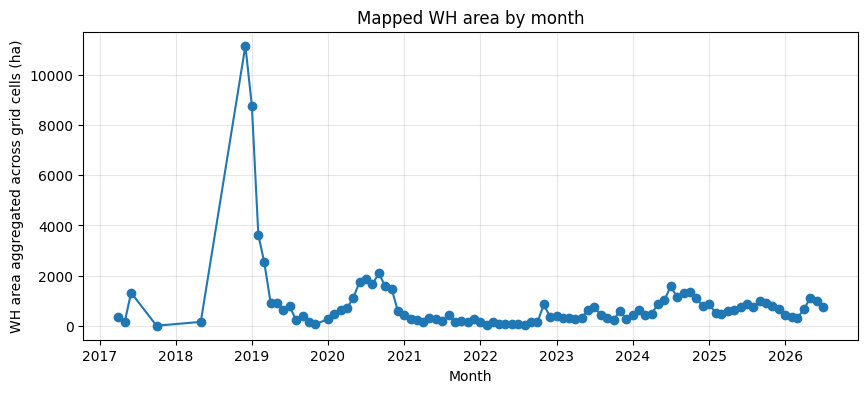

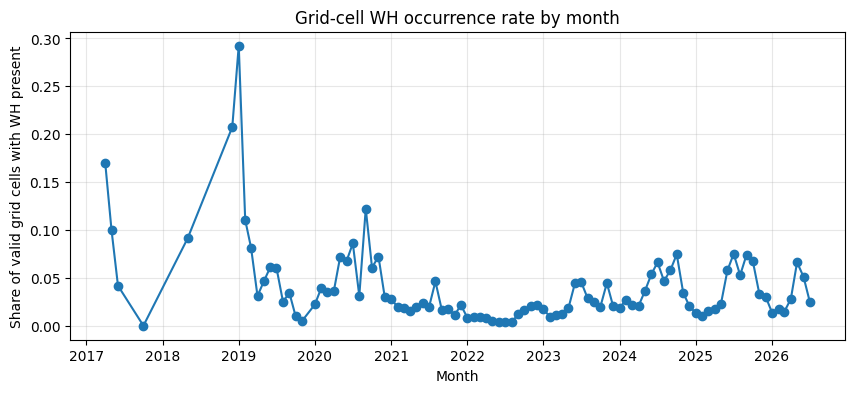

Overall share of cell-months with WH present: 0.0384


In [50]:
monthly_summary = (
    panel.groupby("month", as_index=False)
    .agg(
        wh_area_ha=("wh_area_ha", "sum"),
        valid_area_ha=("valid_area_ha", "sum"),
        mean_cover=("wh_cover", "mean"),
        occurrence_rate=("wh_present", "mean"),
        n_cells=("grid_id", "nunique"),
    )
)

display(monthly_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["wh_area_ha"], marker="o")
ax.set_title("Mapped WH area by month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area aggregated across grid cells (ha)")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["occurrence_rate"], marker="o")
ax.set_title("Grid-cell WH occurrence rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Share of valid grid cells with WH present")
ax.grid(True, alpha=0.3)
plt.show()

print("Overall share of cell-months with WH present:", round(panel["wh_present"].mean(), 4))

## Methodological note: presence definition and probability threshold

The previous model used any non-zero WH area to define presence and used a fixed
0.5 probability threshold. This caused the presence model to be highly
conservative: precision was high but recall was very low, so the model missed
most true WH-present cells and underestimated total WH area. The updated workflow
tests a more ecologically meaningful presence threshold and tunes the probability
threshold using validation data.

Concretely, the changes below:

- define presence with a configurable cover/area threshold instead of "any pixel";
- split the existing training period into fitting and validation months and keep
  the original test months untouched;
- tune the presence probability threshold on the validation months (maximising F1
  by default, with a higher-recall option reported);
- form the final predicted WH area as a two-stage hurdle: the positive-cover model
  is applied only to cells predicted present at the tuned threshold, and zero cover
  is assigned to predicted-absent cells.


## Habitat / valid-cell filter

The panel can contain background cells and cell-months with very few valid
pixels, which dilute presence and push the classifier toward always predicting
absence. The filters below are applied conservatively before modelling:

- the existing minimum valid-pixel filter is retained;
- an optional minimum valid-fraction filter (off by default);
- an optional "ever validly observed" cell filter that keeps only cells with at
  least one valid observation across the panel.

No shoreline/littoral mask is invented here. The number of rows and unique cells
removed by each filter is printed.


In [51]:
n_rows_before_filter = len(panel)
n_cells_before_filter = panel["grid_id"].nunique()
print(f"Before habitat/valid-cell filters: {n_rows_before_filter:,} rows, "
      f"{n_cells_before_filter:,} unique cells")

# 1. Minimum valid pixels per cell-month (already applied in section 7).
#    Re-assert here so the filter is explicit and its effect is reported.
before_rows, before_cells = len(panel), panel["grid_id"].nunique()
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()
print(f"[valid-pixel >= {MIN_VALID_PIXELS_PER_CELL_MONTH}] removed "
      f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")

# 2. Optional minimum valid fraction per cell-month.
if MIN_VALID_FRACTION_PER_CELL_MONTH is not None and "valid_fraction" in panel.columns:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    panel = panel[panel["valid_fraction"] >= MIN_VALID_FRACTION_PER_CELL_MONTH].copy()
    print(f"[valid-fraction >= {MIN_VALID_FRACTION_PER_CELL_MONTH}] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)")

# 3. Optional "ever validly observed" cell filter.
#    Conservative: keep cells with at least one valid observation across the panel.
#    With only a classified/no-data validity flag available this is near-universal;
#    it is a scaffold for a stronger habitat mask if an ever-wet indicator is added.
if REQUIRE_EVER_WET_OR_EVER_OBSERVED:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    ever_valid_cells = (
        panel.loc[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH, "grid_id"].unique()
    )
    panel = panel[panel["grid_id"].isin(ever_valid_cells)].copy()
    print(f"[ever validly observed] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[ever validly observed] filter disabled (REQUIRE_EVER_WET_OR_EVER_OBSERVED is False)")

# 4. Water / littoral habitat mask (Priority 1): keep cells that are mostly water.
if WATER_MASK_SOURCE != "none":
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    wf = None
    if WATER_MASK_SOURCE in ("bathymetry", "both") and "bathy_water_fraction" in panel.columns:
        wf = panel["bathy_water_fraction"].fillna(0.0)
    if WATER_MASK_SOURCE in ("gsw", "both") and "gsw_water_fraction" in panel.columns:
        g = panel["gsw_water_fraction"].fillna(0.0)
        wf = g if wf is None else (np.minimum(wf, g) if WATER_MASK_SOURCE == "both" else g)
    if wf is None:
        print(f"[water mask] source '{WATER_MASK_SOURCE}' requested but no water-fraction "
              "column is available; skipping (provide bathymetry or a GSW fraction).")
    else:
        panel = panel[wf >= MIN_WATER_FRACTION].copy()
        print(f"[water mask: {WATER_MASK_SOURCE} >= {MIN_WATER_FRACTION:g}] removed "
              f"{before_rows - len(panel):,} rows, "
              f"{before_cells - panel['grid_id'].nunique():,} cells "
              f"(kept {panel['grid_id'].nunique():,} water cells)")
else:
    print("[water mask] disabled (WATER_MASK_SOURCE = 'none')")

print(f"After habitat/valid-cell filters: {len(panel):,} rows, "
      f"{panel['grid_id'].nunique():,} unique cells "
      f"(removed {n_rows_before_filter - len(panel):,} rows, "
      f"{n_cells_before_filter - panel['grid_id'].nunique():,} cells overall)")


Before habitat/valid-cell filters: 590,737 rows, 6,446 unique cells
[valid-pixel >= 10] removed 0 rows, 0 cells
[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)
[ever validly observed] removed 0 rows, 0 cells
[water mask: bathymetry >= 0.5] removed 47,742 rows, 519 cells (kept 5,927 water cells)
After habitat/valid-cell filters: 542,995 rows, 5,927 unique cells (removed 47,742 rows, 519 cells overall)


## 11b. Exogenous driver covariates: effective depth & onshore wind

The cell below adds two **response-free** exogenous drivers to `panel` (so they are valid with `GAM_INCLUDE_AR=False`) and registers them in §12 so the §49 GAM-frame builder turns each into a forcing `s()` smooth automatically — **no change to the R formula strings**:

- **`effective_depth_m`** = `depth_m` + `lake_level_anom_m`, where `lake_level_anom_m` = `lake_level_m` − its panel mean. `depth_m` is positive-down (larger = deeper); a rising lake (positive anomaly) deepens the water column. Under the per-cell random intercept `s(grid_id, bs='re')` in §13 the *static* `depth_m` is absorbed by the cell effect (concurvity ≈ 1), so this lake-level interaction is the **only** route by which bathymetry enters — and static `depth_m` is dropped from the candidate features whenever the cell RE is on.
- **`wind_onshore_ms`** = the monthly wind `(wind_u_ms, wind_v_ms)` projected onto each cell's shore-normal unit vector and negated. The shore normal is the least-squares gradient of `dist_shore_m` over the cell's contiguity neighbours (`grid_neighbours`); `dist_shore_m` grows away from land, so its gradient points **lakeward**. Negating the projection makes **`wind_onshore_ms` > 0 ⇒ wind blowing toward the cell's nearest shore ⇒ leeward mat accumulation** (expected sign +).
- One-month lags `effective_depth_m_lag1` and `wind_onshore_ms_lag1` (per-cell `shift(1)`, mirroring §10).

Each block is guarded and skips (with a printed notice) when its inputs are missing: `effective_depth_m` needs a monthly `lake_level_m` (supply via `ENV_MONTHLY_CSV`); `wind_onshore_ms` needs EE `dist_shore_m`, the monthly wind components, and the `grid_neighbours` graph.

### Checks to run in Colab after fitting §13

1. **Partial-dependence signs (§13 effect plots).** `effective_depth_m`: **low** effective depth ⇒ **higher** cover (shallow-water preference). `wind_onshore_ms`: **higher** onshore wind ⇒ **higher** cover (leeward pile-up). A flipped `wind_onshore_ms` curve means the shore gradient points landward instead of lakeward — re-check `shore_gx`/`shore_gy` on `grid` (sign of the `dist_shore_m` gradient).
2. **Worst-case concurvity (§13 concurvity table).** Inspect `effective_depth_m` and `wind_onshore_ms` against **`wave_exposure_idx`** and **`dist_shore_m`** (and `depth_m` if you keep it): worst-case concurvity should stay clear of ~0.8, otherwise the new smooths are not separately identified from the existing exposure/shore geometry.
3. **§49 VIF pre-screen printout.** Confirm neither new driver nor its lag is dropped by the VIF screen. A lag dropped for collinearity with its own level is expected and harmless.
4. **Smooth EDFs (§13 fit summary).** Check the new smooths have EDF > 1 (genuinely used / non-linear) and that `select=TRUE` has not shrunk them toward 0.
5. **Spatial-block vs temporal CV delta (§53–55) — the decider.** A driver that helps temporal CV but collapses under spatial-block CV is fitting spatial structure, not transferable forcing. Keep a new covariate only if spatial-block CV skill does not degrade materially relative to temporal CV.


In [52]:
# =====================================================================
# Exogenous driver covariates (built before §12) -- response-free, so they are
# valid members of the forcing set. Each block is guarded and skips when its
# target column already exists, so this cell is safe to re-run.
#
#   A) effective_depth_m  -- lake-level x bathymetry interaction
#   B) wind_onshore_ms    -- shore-normal wind component (leeward accumulation)
#
# §12 selects them by name from GAM_FORCING_TERMS (effective_depth_m and
# wind_onshore_ms are both in the parsimonious set), so they enter the forcing
# formula as s() smooths without any change to the R formula strings.
# =====================================================================
import numpy as np
from collections import defaultdict

# ---------------------------------------------------------------------
# A) effective_depth_m = depth_m + lake-level anomaly.
# ---------------------------------------------------------------------
# Under the per-cell random intercept s(grid_id, bs='re') used in §13, the static
# per-cell depth_m is fully absorbed by the cell effect (concurvity ~1) and so
# carries no driver signal on its own. Interacting bathymetry with the
# time-varying lake level is the ONLY route by which depth enters the model:
# a rising lake (positive level anomaly) deepens the water column, and water
# hyacinth favours shallow water, so a LOW effective_depth_m should map to
# HIGHER cover. depth_m is stored positive-down (larger = deeper).
LAKE_LEVEL_COL = "lake_level_m"

if {LAKE_LEVEL_COL, "depth_m"}.issubset(panel.columns):
    if "lake_level_anom_m" not in panel.columns:
        _lvl = panel[LAKE_LEVEL_COL].astype(float)
        panel["lake_level_anom_m"] = _lvl - _lvl.mean()
    if "effective_depth_m" not in panel.columns:
        panel["effective_depth_m"] = panel["depth_m"] + panel["lake_level_anom_m"]
        print(f"[effective_depth_m] built = depth_m + (lake level - mean); range "
              f"{panel['effective_depth_m'].min():.2f} .. {panel['effective_depth_m'].max():.2f} m")
    else:
        print("[effective_depth_m] already present; skipping.")
else:
    print(f"[effective_depth_m] needs both '{LAKE_LEVEL_COL}' and 'depth_m' in panel; "
          f"supply lake level via ENV_MONTHLY_CSV (a monthly column named "
          f"'{LAKE_LEVEL_COL}'). Skipping.")

# ---------------------------------------------------------------------
# B) wind_onshore_ms = wind component blowing toward each cell's nearest shore.
# ---------------------------------------------------------------------
# Per-cell shore-normal unit vector (shore_gx, shore_gy) = least-squares gradient
# of dist_shore_m over the cell's contiguity neighbours (grid_neighbours).
# dist_shore_m increases away from land, so its gradient points LAKEWARD. Project
# the monthly wind (wind_u_ms eastward, wind_v_ms northward) onto that vector and
# NEGATE: wind_onshore_ms > 0 means the wind blows toward the nearest shore,
# piling floating mats on the leeward side (directional drift), expected sign +.
_have_wind  = {"wind_u_ms", "wind_v_ms"}.issubset(panel.columns)
_have_shore = "dist_shore_m" in panel.columns
_have_graph = ("grid_neighbours" in globals() and grid_neighbours is not None
               and len(grid_neighbours) and "grid" in globals())

if "wind_onshore_ms" in panel.columns:
    print("[wind_onshore_ms] already present; skipping.")
elif not (_have_wind and _have_shore and _have_graph):
    _missing = []
    if not _have_wind:  _missing.append("wind_u_ms/wind_v_ms")
    if not _have_shore: _missing.append("dist_shore_m")
    if not _have_graph: _missing.append("grid_neighbours/grid")
    print(f"[wind_onshore_ms] missing prerequisites ({', '.join(_missing)}); skipping.")
else:
    # One static dist_shore_m + centroid per cell (dist_shore_m is time-invariant).
    _cell = (panel[["grid_id", "x_km", "y_km", "dist_shore_m"]]
             .dropna(subset=["dist_shore_m"])
             .groupby("grid_id", as_index=False).first())
    _pos = {int(r.grid_id): (float(r.x_km), float(r.y_km)) for r in _cell.itertuples()}
    _ds  = {int(r.grid_id): float(r.dist_shore_m) for r in _cell.itertuples()}

    _adj = defaultdict(list)
    for _g, _n in grid_neighbours[["grid_id", "neighbor_id"]].itertuples(index=False):
        _adj[int(_g)].append(int(_n))

    _gx, _gy = {}, {}
    for _gid in _pos:
        _nbrs = [n for n in _adj.get(_gid, []) if n in _pos]   # neighbour has dist_shore
        if len(_nbrs) < 2:                                     # need >= 2 valid neighbours
            continue
        _A = np.array([[_pos[n][0] - _pos[_gid][0], _pos[n][1] - _pos[_gid][1]]
                       for n in _nbrs], dtype=float)
        _b = np.array([_ds[n] - _ds[_gid] for n in _nbrs], dtype=float)
        _grad, *_ = np.linalg.lstsq(_A, _b, rcond=None)        # lakeward gradient
        _norm = float(np.hypot(_grad[0], _grad[1]))
        if not np.isfinite(_norm) or _norm == 0.0:             # degenerate / zero-norm
            continue
        _gx[_gid], _gy[_gid] = _grad[0] / _norm, _grad[1] / _norm

    # Attach the shore-normal unit vector to `grid` (NaN where undefined).
    for _c in ("shore_gx", "shore_gy"):
        if _c in grid.columns:
            grid = grid.drop(columns=_c)
    grid["shore_gx"] = grid["grid_id"].map(_gx)
    grid["shore_gy"] = grid["grid_id"].map(_gy)

    # Merge onto the panel and project the monthly wind onto the shore normal.
    panel = panel.merge(grid[["grid_id", "shore_gx", "shore_gy"]], on="grid_id", how="left")
    panel["wind_onshore_ms"] = -(panel["wind_u_ms"] * panel["shore_gx"]
                                 + panel["wind_v_ms"] * panel["shore_gy"])
    _n_ok = int(panel["wind_onshore_ms"].notna().sum())
    print(f"[wind_onshore_ms] built for {_n_ok:,} cell-months "
          f"({len(_gx):,}/{grid['grid_id'].nunique():,} cells have a shore normal); "
          f"NaNs (sparse/degenerate neighbours) are median-imputed in §49.")

# ---------------------------------------------------------------------
# One-month lags (mirror §10: sort by [grid_id, month], then per-cell shift(1)).
# ---------------------------------------------------------------------
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)
for _col in ["effective_depth_m", "wind_onshore_ms"]:
    _lag = f"{_col}_lag1"
    if _col in panel.columns and _lag not in panel.columns:
        panel[_lag] = panel.groupby("grid_id")[_col].shift(1)
        print(f"[{_lag}] created.")


[effective_depth_m] built = depth_m + (lake level - mean); range -1.04 .. 42.29 m
[wind_onshore_ms] built for 542,903 cell-months (5,926/24,522 cells have a shore normal); NaNs (sparse/degenerate neighbours) are median-imputed in §49.
[effective_depth_m_lag1] created.
[wind_onshore_ms_lag1] created.


## 12. Prepare model dataset

This model is intentionally simple and robust for a test period.

It uses a **temporally blocked train/test split**, rather than a random split, because random splitting would leak information from adjacent months into the test set.

Feature columns now include the Earth Engine and CSV covariates (and their one-month lags for the time-varying ones). Rows are dropped only when the **response** or the **structural lag features** are missing; missing values in the environmental covariates themselves (for example a cloudy Sentinel-2 month, or a cell that is mostly land) are left in place and imputed inside the model pipeline, so adding many covariates does not shrink the panel.

In [ ]:
# =====================================================================
# 12. Model dataset: a parsimonious FORCING set, and a separate PREDICTIVE set
# =====================================================================
# Two predictor sets, built once and never mixed:
#
#   forcing_cols     - exogenous environmental forcing only. No wh_* term (focal
#                      or neighbour, current or lagged), no contemporaneous
#                      optical/chlorophyll/turbidity proxy, no sensor indicator.
#                      This is what the INFERENTIAL driver model may use.
#   predictive_cols  - forcing_cols + the lagged-response terms. Used only by the
#                      separately-labelled PREDICTIVE specification, which answers
#                      a forecasting question, not a driver question.
#
# The forcing set is chosen from WH ecology (GAM_FORCING_TERMS in §3), one
# representation per mechanism with an a-priori sign, replacing the previous
# data-driven ~30-covariate set in which every time-varying driver appeared in
# BOTH current and lagged form and concurvity sat at ~1.
import numpy as np
import pandas as pd

_forcing_spec = dict(GAM_FORCING_TERMS)
if str(globals().get("GAM_FORCING_SET_MODE", "parsimonious")).lower() == "extended":
    _forcing_spec.update(GAM_FORCING_TERMS_EXTENDED)

# --- Resolve each requested term against what the panel actually holds --------
_resolution_rows = []
_requested = []
for _term, (_mech, _sign) in _forcing_spec.items():
    _used, _how = None, ""
    if _term in panel.columns:
        _used, _how = _term, "requested"
    else:
        for _alt in GAM_FORCING_FALLBACKS.get(_term, []):
            if _alt in panel.columns:
                _used, _how = _alt, f"fallback for {_term}"
                break
    _resolution_rows.append({"requested": _term, "resolved": _used or "(unavailable)",
                             "how": _how or "no substitute available",
                             "mechanism": _mech, "expected_sign": _sign})
    if _used and _used not in _requested:
        _requested.append(_used)

# air_temp_c and water_temp_c are two measurements of the same thermal control, so
# they are never entered together (that is exactly the redundant representation the
# parsimonious set exists to avoid).
if "air_temp_c" in _requested and "water_temp_c" in _requested:
    _requested.remove("water_temp_c")
    _resolution_rows.append({"requested": "water_temp_c", "resolved": "(dropped)",
                             "how": "redundant with air_temp_c (same thermal mechanism)",
                             "mechanism": "thermal control on growth", "expected_sign": "+"})

forcing_resolution = pd.DataFrame(_resolution_rows)
print("Forcing-term resolution (requested -> what the panel supplies):")
display(forcing_resolution)

if str(globals().get("GAM_FORCING_SET_MODE", "parsimonious")).lower() == "legacy":
    # Reproduces the previous data-driven set. Kept only to re-create the old run;
    # it is NOT a defensible forcing specification and is flagged as such wherever
    # it is reported.
    _tv = [c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS)
           if c in panel.columns]
    _requested = list(dict.fromkeys(
        _tv + [f"{c}_lag1" for c in _tv if f"{c}_lag1" in panel.columns]
        + [c for c in STATIC_COVARIATE_COLS if c in panel.columns]
        + [c for c in ["effective_depth_m", "effective_depth_m_lag1",
                       "wind_onshore_ms", "wind_onshore_ms_lag1"] if c in panel.columns]))
    print("\n*** GAM_FORCING_SET_MODE='legacy': reproducing the old data-driven driver set. "
          "Not a defensible forcing specification. ***")

# --- Enforce exogeneity, identification and non-degeneracy -------------------
_exog, _resp, _optical = split_forcing_and_response_terms(_requested)
if _resp or _optical:
    print("\nExcluded from the forcing set (kept for the predictive spec / descriptive use):")
    for _c in _resp:
        print(f"  {_c}: response-derived")
    for _c in _optical:
        print(f"  {_c}: endogenous optical/biogeochemical proxy")

forcing_cols, forcing_dropped = screen_covariates(
    panel, _exog,
    min_unique=int(globals().get("COVARIATE_MIN_UNIQUE", 3)),
    near_constant_frac=float(globals().get("COVARIATE_NEAR_CONSTANT_FRAC", 0.99)),
    max_missing_frac=float(globals().get("COVARIATE_MAX_MISSING_FRAC", 0.95)))
if len(forcing_dropped):
    print("\nForcing terms dropped by the identification / constancy screen:")
    display(forcing_dropped)
assert_all_identified(forcing_cols, label="forcing predictor set")
if not forcing_cols:
    raise RuntimeError("No usable forcing covariates remain -- check §9c and GAM_FORCING_TERMS.")

# --- Endogenous proxies, kept ONLY for the descriptive contrast --------------
proxy_cols = [c for c in (CELLMONTH_COVARIATE_COLS + MONTHLY_COVARIATE_COLS)
              if c in panel.columns and is_endogenous_optical(c)]

# --- Lagged-response terms: the PREDICTIVE specification only ----------------
predictive_lag_cols = [c for c in GAM_PREDICTIVE_LAG_TERMS if c in panel.columns]
predictive_cols = list(dict.fromkeys(forcing_cols + predictive_lag_cols))
feature_cols = list(predictive_cols)      # backwards-compatible alias (widest set)

# --- Hard gates before anything is modelled ----------------------------------
assert not any(is_response_derived(c) for c in forcing_cols), \
    f"response-derived term in the forcing set: {[c for c in forcing_cols if is_response_derived(c)]}"
assert not any(is_endogenous_optical(c) for c in forcing_cols), \
    f"endogenous optical term in the forcing set: {[c for c in forcing_cols if is_endogenous_optical(c)]}"
assert "sensor_is_s1" not in forcing_cols, \
    "sensor indicator must not be a driver; it is a nuisance control and is dropped on an S2-only run"
if globals().get("PANEL_IS_S2_ONLY", True):
    assert "sensor_is_s1" not in panel.columns, \
        "S2-only run still carries sensor_is_s1 -- §7c should have dropped it"

print(f"\nFORCING predictors ({len(forcing_cols)}) -- the inferential driver set:")
for _c in forcing_cols:
    _mech = _forcing_spec.get(_c, ("(substitute; see the resolution table)", "?"))
    print(f"  {_c:26s} {_mech[1]:>2s}  {_mech[0]}")
print(f"\nPREDICTIVE-only additions ({len(predictive_lag_cols)}): {predictive_lag_cols or 'none'}")
print(f"Endogenous proxies excluded from all forcing specs ({len(proxy_cols)}): "
      f"{proxy_cols or 'none'}")

# --- Predictor-role table (exported with the diagnostics in §13g) -------------
_role_rows = []
for _c in dict.fromkeys(forcing_cols + predictive_lag_cols + proxy_cols
                        + ["month_num", "x_km", "y_km", "grid_id", "time_index"]):
    _spec = _forcing_spec.get(_c)
    _role_rows.append({
        "term": _c,
        "role": ("forcing" if _c in forcing_cols else
                 "predictive_lag" if _c in predictive_lag_cols else
                 "endogenous_proxy" if _c in proxy_cols else "structural"),
        "in_forcing_formula": _c in forcing_cols,
        "in_predictive_formula": _c in predictive_cols,
        "mechanism": _spec[0] if _spec else "",
        "expected_sign": _spec[1] if _spec else "",
    })
predictor_roles_table = pd.DataFrame(_role_rows)

# --- Analysis frame ----------------------------------------------------------
# Rows are kept when the RESPONSE and the structural keys are present. Missing
# FORCING covariates are NOT a reason to drop a row: they are imputed inside each
# training fold (§13-CV), never across the whole panel before splitting.
model_df = panel.dropna(subset=["wh_cover", "wh_present"]).copy()
_structural_required = [c for c in ["wh_cover", "wh_present", "grid_id", "month",
                                    "valid_area_m2", "x_km", "y_km"]
                        if c in model_df.columns]
model_df = model_df.dropna(subset=_structural_required).copy()
if len(model_df) == 0:
    raise RuntimeError("No model rows remain after dropping missing response/structural values.")

# The predictive spec additionally needs an observed previous month; those rows are
# dropped for that spec only (reported), not for the forcing model.
model_df["has_response_lag"] = True
for _c in predictive_lag_cols:
    model_df["has_response_lag"] &= model_df[_c].notna()
_n_lag = int(model_df["has_response_lag"].sum())
print(f"\nAnalysis frame: {len(model_df):,} cell-months x {model_df['grid_id'].nunique():,} cells, "
      f"{model_df['month'].nunique()} months "
      f"({pd.Timestamp(model_df['month'].min()).date()} to "
      f"{pd.Timestamp(model_df['month'].max()).date()}).")
print(f"  forcing spec uses all {len(model_df):,} rows; predictive spec uses the "
      f"{_n_lag:,} rows with an observed previous month "
      f"({len(model_df) - _n_lag:,} first-observation rows excluded).")
print(f"  WH-present prevalence: {model_df['wh_present'].mean():.4f} | "
      f"mean cover {model_df['wh_cover'].mean():.4f} | max cover {model_df['wh_cover'].max():.3f}")

# Reference-only chronological split, retained so the panel's coverage is on record.
# NOTE: it is NOT the validation design -- all reported skill comes from the shared
# spatial-block and rolling-origin folds built in §13.
_months_sorted = np.array(sorted(model_df["month"].unique()))
_split_idx = max(1, int(len(_months_sorted) * TRAIN_FRACTION))
_split_month = _months_sorted[_split_idx]
train = model_df[model_df["month"] < _split_month].copy()
test = model_df[model_df["month"] >= _split_month].copy()
print(f"  (reference chronological split at {pd.Timestamp(_split_month).date()}: "
      f"{len(train):,} earlier / {len(test):,} later rows -- not used for any reported metric)")


## 13. One-stage spatial GAM of WH cover (mgcv via rpy2)

This single model **replaces both** the earlier two-stage sklearn hurdle (old §13–§15b) and the
two-part `pygam` GAM (old §14d). Those are kept, commented-out, in the **superseded-models
appendix** at the end of the notebook.

**Why one stage.** WH proportional cover is continuous on \[0, 1] with a large spike of exact
zeros (absent cell-months). Modelling "absent" and "how much cover when present" **together** —
no presence/cover split, no probability threshold to tune — is what lets us *retire* the hurdle
rather than re-implement it. The default response is **`betar`** (Beta, logit link, `GAM_FAMILY`):
predictions stay bounded in \[0, 1] and the exact 0/1 are squeezed just off the boundary
(Smithson & Verkuilen 2006). That squeeze is a workaround, not a model of the boundary mass, so
**§13d** adds an **ordered-Beta** cross-check (Kubinec 2023) and **§13e** scores Beta, Tweedie,
quasi-binomial, ordered-Beta and a hurdle benchmark on identical rows and folds.

### Three specifications, never mixed

| spec | terms | question it answers | where it is reported |
|---|---|---|---|
| **forcing** (primary) | exogenous drivers + cyclic season + one spatial structure + trend | *do environmental conditions covary with WH cover, net of place and season?* | effect sizes, §13b gate, §13c contrast |
| **predictive** | forcing **+** `wh_cover_lag1`, `wh_cover_neigh_lag1` | *can next month's cover be forecast?* | reported separately; **never** as driver evidence |
| **descriptive** (off by default) | forcing **+** turbidity / chlorophyll-a proxies | *how much variance do endogenous optical proxies absorb?* | `GAM_RUN_DESCRIPTIVE_PROXY` |

The lagged-response and optical terms are **excluded from the forcing formula by assertion**
(`assert_forcing_formula_exogenous`), not by convention — a `wh_*` lag, a neighbour term or a
turbidity/chl-a/reflectance proxy in a forcing formula raises before anything is fitted. The same
gate is applied to the §13c contrast, the §13-CV transfer formula, the §13e comparison RHS and the
§13f robustness RHS.

### The driver set

`GAM_FORCING_TERMS` (§3) is a **pre-specified, parsimonious** set: one representation per
mechanism, each with a stated mechanism and expected sign — antecedent rainfall (lagged), air
temperature, onshore wind, wave exposure, effective depth, distance to a major river, distance to
shore and catchment cropland fraction. It replaces the previous data-driven set in which every
time-varying covariate appeared in **both** current and lagged form and the only screen was a
linear VIF pass fitted on the whole panel. A term with no available column falls back to a
documented substitute or is dropped and reported — never silently swapped.

### Engine and structure

**`mgcv` via `rpy2`**, which gives what `pygam` could not: flexible spatial structure
(`GAM_SPATIAL_BASIS` — a thin-plate `te(x_km, y_km)` surface, a random cell intercept
`s(grid_id, bs="re")`, or an **MRF** `s(grid_id, bs="mrf")` on the §6b water-connectivity graph);
proper families (`betar()`, `tw()`, `ocat()`); per-term REML smoothness selection;
`bam(discrete=TRUE)` fitting the full panel in memory; and `concurvity()`, the nonlinear
collinearity diagnostic that is the GAM analogue of VIF.

Exactly **one** spatial structure is kept — the per-cell RE, `te(x, y)` and the MRF are mutually
redundant because every covariate is constant within a cell. **§13a** compares `te(x, y)` against
feasible MRF ranks on the same rows and the same forcing terms, so the choice is made on measured
residual autocorrelation rather than asserted. Repeated observations of the same cell are handled
by that spatial term plus a **within-cell AR1** correction whose ρ is estimated **separately for
every fitted model** from that model's own pilot fit — reusing one model's ρ for another
mis-states its standard errors.

The dependence-aware CV (§13-CV) always uses `te(x_km, y_km)`, since a per-cell MRF or random
effect cannot transfer to held-out cells.

> Requires `rpy2` and R's `mgcv` — both pre-installed in Colab. `glmmTMB` is optional and is used
> by the ordered-Beta cross-check (§13d) and the ordered-Beta family in §13e; both degrade to a
> printed reason if it is missing.


In [54]:
# --- rpy2 + mgcv setup -------------------------------------------------------
# rpy2 and R's mgcv ship with Colab; install rpy2 only if it is missing.
try:
    import rpy2  # noqa: F401
except ImportError:
    !pip install -q rpy2

%load_ext rpy2.ipython

# The %%R magic auto-converts pandas DataFrames passed with -i in modern rpy2.
# If a given runtime does not, run once:
#   from rpy2.robjects import pandas2ri; pandas2ri.activate()
%R if (!requireNamespace("mgcv", quietly=TRUE)) install.packages("mgcv", repos="https://cloud.r-project.org")
%R suppressMessages(library(mgcv)); cat(sprintf("mgcv %s ready\n", as.character(packageVersion("mgcv"))))


mgcv 1.9.4 ready


In [ ]:
# --- Build the GAM modelling frame -------------------------------------------
# Self-contained: depends only on `model_df`, `forcing_cols`, `predictive_cols`
# built in §12 above.
#
# Three specifications, built here and never mixed downstream:
#   forcing      - exogenous drivers + season + spatial structure  (INFERENTIAL)
#   predictive   - forcing + lagged-response terms                 (FORECASTING)
#   descriptive  - forcing + endogenous optical proxies            (DESCRIPTIVE, off by default)
# and a transfer specification (te(x_km, y_km), no per-cell term) used by every
# cross-validated section, because a per-cell MRF/random effect cannot predict a
# held-out cell.
import numpy as np
import pandas as pd

GAM_FAMILY           = "betar"  # response family. "betar" (Beta, logit link) keeps predictions in
                                # (0,1); exact 0/1 are squeezed off the boundary (Smithson &
                                # Verkuilen 2006). "tw" (Tweedie, log link, unbounded) is kept for
                                # the §13e family comparison. betar auto-falls back to tw() if the
                                # mgcv build cannot fit it (see the R cell).
GAM_CLIP_PRED_01     = True     # clip response-scale predictions to [0,1] in diagnostics and CV
GAM_K_DRIVER         = 10       # basis dimension per driver smooth
GAM_K_SEASON         = 8        # basis for the cyclic seasonal smooth
GAM_K_SPATIAL        = 15       # basis per axis of te(x_km, y_km)
GAM_INCLUDE_CELL_RE  = "auto"   # per-cell random intercept; True/False, or "auto" to drop it
GAM_CELL_RE_MAX_LEVELS = 3000   # "auto" guard only: cell count above which the RE is dropped
GAM_SPATIAL_BASIS    = "mrf"    # MAIN-fit spatial term: "te" or "mrf" (§13a compares them)
GAM_MRF_K            = 200      # MRF rank actually used by the main fit (see the §13a comparison)
GAM_SVC_DRIVERS      = []       # optional te(x_km, y_km, by=driver) spatially-varying coefficients
GAM_SVC_K            = 5
GAM_RUN_DESCRIPTIVE_PROXY = False  # also fit forcing + endogenous optical proxies (descriptive only)
GAM_RUN_KCHECK       = True     # mgcv k.check() basis-adequacy diagnostic
GAM_AR1_ENABLED      = True     # AR1 (rho) on within-cell residuals, ESTIMATED PER FITTED MODEL
GAM_AR1_RHO          = None     # None -> estimate per model from its own pilot fit; else a float
GAM_MAX_ROWS         = None     # cap rows passed to R (None = full panel)
GAM_RUN_CV           = True     # spatial + temporal block CV (slow: several refits per fold)
# bam() memory controls (mgcv): fewer threads, a smaller model-matrix chunk and more frequent GC
# lower peak memory without changing the fitted model (see ?bam).
GAM_BAM_NTHREADS     = 1
GAM_BAM_CHUNK        = 5000
GAM_BAM_GCLEVEL      = 2
RANDOM_STATE = int(globals().get("RANDOM_STATE", 42))

RESPONSE     = "wh_cover"
spatial_cols = ["x_km", "y_km"]
season_col   = "month_num"
# `time_index` is a linear calendar trend, not a driver. The sensor indicator is
# gone on a single-sensor run (§7c), so no sensor coefficient can appear.
control_cols = [c for c in ["time_index", "sensor_is_s1"] if c in model_df.columns]

# =====================================================================
# (a) Classifier confidence: resolve it to EXACTLY ONE use
# =====================================================================
_have_soft = bool("wh_cover_soft" in model_df.columns
                  and model_df["wh_cover_soft"].notna().any())
_have_hard = "wh_cover_hard" in model_df.columns
_have_conf_all = bool("wh_conf_all_mean" in model_df.columns
                      and model_df["wh_conf_all_mean"].notna().any())
_have_conf_wh = bool("wh_conf_mean" in model_df.columns
                     and model_df["wh_conf_mean"].notna().any())
CONFIDENCE_USAGE = resolve_confidence_usage(
    globals().get("GAM_CONFIDENCE_MODE", "soft_response"),
    {"soft": _have_soft, "hard": _have_hard,
     "conf_all": _have_conf_all, "conf_wh": _have_conf_wh},
    allow_partial=bool(globals().get("GAM_CONFIDENCE_ALLOW_PARTIAL", False)))
print("Classifier-confidence usage:", CONFIDENCE_USAGE["mode"])
print(" ", CONFIDENCE_USAGE["note"])

_resp_src = ("wh_cover_soft" if (CONFIDENCE_USAGE["response_col"] == "soft" and _have_soft)
             else ("wh_cover_hard" if _have_hard else "wh_cover"))
RESPONSE_KIND = "confidence_weighted_soft" if _resp_src == "wh_cover_soft" else "hard_class"
print(f"  response column: {_resp_src} ({RESPONSE_KIND})")

# =====================================================================
# (b) Assemble the frame -- RAW covariates, imputed inside folds, not before
# =====================================================================
_needed = list(dict.fromkeys(
    [_resp_src, "wh_cover_hard", "wh_cover_soft"] + forcing_cols + predictive_lag_cols
    + proxy_cols + control_cols + spatial_cols
    + [season_col, "grid_id", "month", "wh_present", "has_response_lag",
       "wh_conf_mean", "wh_conf_all_mean", "wh_pixels", "valid_pixels", "valid_fraction"]))
_needed = [c for c in _needed if c in model_df.columns]
gam_src = model_df[_needed].copy()
# The soft column is undefined wherever a probability raster was unavailable; §7 already
# falls back to hard-class cover there, so mirror that here instead of dropping the row.
if {"wh_cover_soft", "wh_cover_hard"}.issubset(gam_src.columns):
    _n_fallback = int(gam_src["wh_cover_soft"].isna().sum())
    gam_src["wh_cover_soft"] = gam_src["wh_cover_soft"].fillna(gam_src["wh_cover_hard"])
    if _n_fallback:
        print(f"  {_n_fallback:,} row(s) have no probability raster -> soft cover falls back "
              f"to hard-class cover there (as in §7).")
gam_src[RESPONSE] = pd.to_numeric(gam_src[_resp_src], errors="coerce").clip(0.0, 1.0)
gam_src = gam_src.dropna(subset=[RESPONSE] + spatial_cols + [season_col]).reset_index(drop=True)

# Observation weights. resolve_confidence_usage has already refused any combination
# that would use confidence twice or invent confidence for absence rows.
if CONFIDENCE_USAGE["weight_col"] is None:
    gam_src["obs_weight"] = 1.0
    gam_src["conf_observed"] = 1
elif CONFIDENCE_USAGE["weight_col"] == "conf_all":
    gam_src["obs_weight"] = build_confidence_weights(gam_src["wh_conf_all_mean"])
    gam_src["conf_observed"] = gam_src["wh_conf_all_mean"].notna().astype(int)
    _n0 = len(gam_src)
    gam_src = gam_src[np.isfinite(gam_src["obs_weight"])].reset_index(drop=True)
    print(f"  dropped {_n0 - len(gam_src):,} rows with no all-pixel confidence.")
else:                                   # flagged partial variant
    _med = float(pd.to_numeric(gam_src["wh_conf_mean"], errors="coerce").median())
    gam_src["conf_observed"] = gam_src["wh_conf_mean"].notna().astype(int)
    gam_src["obs_weight"] = build_confidence_weights(gam_src["wh_conf_mean"], fill=_med)
    print(f"  PARTIAL confidence weights: unobserved rows take the observed median "
          f"({_med:.3f}), never 1.0; {int((gam_src['conf_observed'] == 0).sum()):,} rows flagged.")

RESPONSE_IS_SOFT = (_resp_src == "wh_cover_soft")
WEIGHTS_ARE_CONFIDENCE = CONFIDENCE_USAGE["weight_col"] is not None
assert not (RESPONSE_IS_SOFT and WEIGHTS_ARE_CONFIDENCE), (
    "classifier confidence would be used twice (soft response AND likelihood weights)")

if GAM_MAX_ROWS is not None and len(gam_src) > GAM_MAX_ROWS:
    gam_src = gam_src.sample(GAM_MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"NOTE: capped GAM rows to {GAM_MAX_ROWS:,} (GAM_MAX_ROWS).")

# Full-panel collinearity DIAGNOSTIC (reported, not used to prune). Pruning on the
# full panel leaks test-fold information into the model specification, so the
# screen that actually removes terms runs inside each training fold (§13-CV).
def _vif_table(df, cols):
    sub = df[cols].apply(pd.to_numeric, errors="coerce")
    sub = sub.fillna(sub.median())
    C = np.atleast_2d(np.corrcoef(sub.values, rowvar=False))
    try:
        inv = np.linalg.inv(C)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(C)
    return pd.DataFrame({"term": cols, "vif": np.diag(inv)}).sort_values("vif", ascending=False)

forcing_vif_table = _vif_table(gam_src, forcing_cols) if len(forcing_cols) > 1 else pd.DataFrame()
if len(forcing_vif_table):
    print("\nFull-panel VIF of the forcing set (diagnostic only; fold-internal screening "
          f"at VIF > {globals().get('GAM_FOLD_VIF_THRESHOLD', 5.0)} is what removes terms):")
    display(forcing_vif_table.round(2))

# =====================================================================
# (c) One shared fold design, reused by §13-CV, §13e and §13f
# =====================================================================
_months = np.sort(gam_src["month"].unique())
gam_src["time_rank"] = gam_src["month"].map({m: i for i, m in enumerate(_months)}).astype(int)
gam_src["fold_sp"], _blk = spatial_block_folds(
    gam_src["x_km"].to_numpy(), gam_src["y_km"].to_numpy(),
    block_km=float(globals().get("GAM_SPATIAL_BLOCK_KM", 10.0)),
    n_folds=int(globals().get("GAM_N_SPATIAL_FOLDS", 5)),
    seed=int(globals().get("GAM_FOLD_SEED", 42)))
CV_TEMPORAL_DESIGN, CV_TEMPORAL_META = rolling_origin_folds(
    _months,
    n_folds=int(globals().get("GAM_N_TEMPORAL_FOLDS", 8)),
    horizon_months=int(globals().get("GAM_TEMPORAL_HORIZON_MONTHS", 3)),
    min_train_months=int(globals().get("GAM_TEMPORAL_MIN_TRAIN_MONTHS", 24)))
gam_src["fold_tm"] = assign_temporal_folds(gam_src["time_rank"], CV_TEMPORAL_DESIGN)
CV_SPATIAL_FOLDS = sorted(int(f) for f in np.unique(gam_src["fold_sp"]))
CV_TEMPORAL_FOLDS = [int(f) for f in CV_TEMPORAL_DESIGN["fold"]] if len(CV_TEMPORAL_DESIGN) else []

print(f"\nShared fold design (used by §13-CV, §13e and §13f):")
print(f"  spatial : {len(CV_SPATIAL_FOLDS)} leave-block-out folds, "
      f"{globals().get('GAM_SPATIAL_BLOCK_KM', 10.0):g} km blocks, "
      f"{len(np.unique(_blk)):,} blocks shuffled with seed "
      f"{globals().get('GAM_FOLD_SEED', 42)}")
print(f"  temporal: {CV_TEMPORAL_META['n_folds']} rolling-origin folds x "
      f"{CV_TEMPORAL_META['horizon_months']} month(s) = "
      f"{CV_TEMPORAL_META['months_validated']} of {CV_TEMPORAL_META['n_months']} months "
      f"validated ({CV_TEMPORAL_META['fraction_validated']:.0%} of the record; "
      f"min train window {CV_TEMPORAL_META['min_train_months']} months)")
if CV_TEMPORAL_META["n_folds"] < CV_TEMPORAL_META["requested_folds"]:
    print(f"  NOTE: {CV_TEMPORAL_META['requested_folds']} temporal folds were requested but only "
          f"{CV_TEMPORAL_META['n_folds']} fit the record length at this horizon / minimum "
          f"training window.")
if len(CV_TEMPORAL_DESIGN):
    display(CV_TEMPORAL_DESIGN)

# =====================================================================
# (d) Ship to R
# =====================================================================
gam_df = gam_src.drop(columns=["month"]).copy()
gam_df["grid_id"] = gam_df["grid_id"].astype(str)
_keep_cols = list(dict.fromkeys(
    [RESPONSE, "wh_cover_hard", "wh_cover_soft", "wh_present"] + forcing_cols
    + predictive_lag_cols + proxy_cols + control_cols + spatial_cols
    + [season_col, "grid_id", "fold_sp", "fold_tm", "time_rank", "obs_weight",
       "conf_observed", "has_response_lag", "wh_pixels", "valid_pixels",
       "valid_fraction"]))
gam_df = gam_df[[c for c in _keep_cols if c in gam_df.columns]].copy()
if "has_response_lag" in gam_df.columns:
    gam_df["has_response_lag"] = gam_df["has_response_lag"].astype(int)
# AR1 needs each cell's rows consecutive and time-ordered so R can mark cell
# boundaries (and within-cell month gaps) with AR.start.
gam_df = gam_df.sort_values(["grid_id", "time_rank"]).reset_index(drop=True)
del gam_src
import gc as _gc; _gc.collect()

# =====================================================================
# (e) Formulas
# =====================================================================
def _smooths(cols, k=None):
    k = GAM_K_DRIVER if k is None else k
    return " + ".join(f"s({c}, k={k}, bs='tp')" for c in cols)


_season  = f"s({season_col}, bs='cc', k={GAM_K_SEASON})"
_spatial = f"te(x_km, y_km, k=c({GAM_K_SPATIAL},{GAM_K_SPATIAL}))"
_ctrl    = (" + " + " + ".join(control_cols)) if control_cols else ""
_n_cells = gam_df["grid_id"].nunique()

# --- Spatial structure: MRF on the water-connectivity graph, or te() ----------
_spatial_basis = str(GAM_SPATIAL_BASIS).lower()
GAM_MRF_FALLBACK_SPATIAL = _spatial
GAM_MRF_TERM = ""
gam_mrf_edges = None
if _spatial_basis == "mrf":
    _gn = globals().get("grid_neighbours", None)
    if _gn is not None and len(_gn):
        _present = set(gam_df["grid_id"].unique())
        _e = _gn[["grid_id", "neighbor_id"]].astype(str)
        _e = _e[_e["grid_id"].isin(_present) & _e["neighbor_id"].isin(_present)]
        gam_mrf_edges = _e.reset_index(drop=True)
        print(f"\nMRF spatial basis: {len(gam_mrf_edges):,} edges among {len(_present):,} cells "
              f"({len(_present) - gam_mrf_edges['grid_id'].nunique():,} with no in-panel neighbour).")
    else:
        print("\nGAM_SPATIAL_BASIS='mrf' but grid_neighbours is unavailable; using te(x_km, y_km).")
        _spatial_basis = "te"

# The per-cell random intercept, te(x_km, y_km) and the MRF are mutually redundant
# (every covariate is constant within a cell), so exactly ONE spatial structure is
# kept. Repeated observations of the same cell are handled by that spatial term
# plus the within-cell AR1 correction; the transfer/CV spec below keeps te() so it
# can still predict a held-out cell.
if _spatial_basis == "mrf":
    _use_cell_re = False
elif isinstance(GAM_INCLUDE_CELL_RE, str) and GAM_INCLUDE_CELL_RE.lower() == "auto":
    _use_cell_re = _n_cells <= GAM_CELL_RE_MAX_LEVELS
else:
    _use_cell_re = bool(GAM_INCLUDE_CELL_RE)
_re_term = " + s(grid_id, bs='re')" if _use_cell_re else ""

if _spatial_basis == "mrf":
    _mrf_k = int(GAM_MRF_K) if GAM_MRF_K else 0
    _spatial_term = f" + s(grid_id, bs='mrf', xt=xt_mrf{f', k={_mrf_k}' if _mrf_k else ''})"
    GAM_MRF_TERM = _spatial_term.strip(" +")
    print(f"Spatial structure: MRF s(grid_id, bs='mrf', k="
          f"{_mrf_k if _mrf_k else 'full rank'}) on the water-connectivity graph; "
          f"te(x_km, y_km) is used by the CV/transfer spec. Falls back to te() if the fit errors.")
elif _use_cell_re:
    _spatial_term = ""
    print(f"Spatial structure: per-cell random effect s(grid_id, bs='re') "
          f"({_n_cells:,} cells); te(x_km, y_km) dropped as redundant.")
else:
    _spatial_term = f" + {_spatial}"
    print(f"Spatial structure: te(x_km, y_km) ({_n_cells:,} cells > "
          f"GAM_CELL_RE_MAX_LEVELS={GAM_CELL_RE_MAX_LEVELS}).")


def _svc(cols):
    _k = int(GAM_SVC_K)
    _sel = [d for d in GAM_SVC_DRIVERS if d in cols]
    return "".join(f" + te(x_km, y_km, by={d}, k=c({_k},{_k}))" for d in _sel)


_lag_smooths = _smooths(predictive_lag_cols, k=5) if predictive_lag_cols else ""

# PRIMARY inferential model: exogenous forcing only.
r_formula_forcing = (f"{RESPONSE} ~ {_smooths(forcing_cols)} + {_season}"
                     f"{_spatial_term}{_re_term}{_svc(forcing_cols)}{_ctrl}")
# Separately-labelled PREDICTIVE model: adds the lagged-response terms.
r_formula_predictive = (f"{RESPONSE} ~ {_smooths(forcing_cols)}"
                        f"{' + ' + _lag_smooths if _lag_smooths else ''} + {_season}"
                        f"{_spatial_term}{_re_term}{_ctrl}") if predictive_lag_cols else ""
# DESCRIPTIVE model: forcing + endogenous optical proxies. Off by default.
r_formula_descriptive = ((f"{RESPONSE} ~ {_smooths(forcing_cols + proxy_cols)} + {_season}"
                          f"{_spatial_term}{_re_term}{_ctrl}")
                         if (GAM_RUN_DESCRIPTIVE_PROXY and proxy_cols) else "")
# TRANSFER specs used by every cross-validated section (te(); no per-cell term).
r_formula_cv = f"{RESPONSE} ~ {_smooths(forcing_cols)} + {_season} + {_spatial}{_ctrl}"
r_formula_cv_predictive = (
    f"{RESPONSE} ~ {_smooths(forcing_cols)} + {_lag_smooths} + {_season} + {_spatial}{_ctrl}"
    if predictive_lag_cols else "")

# --- Hard gate: no forcing specification may contain a response-derived or -------
# --- endogenous optical term. This raises rather than warns. ---------------------
_known = list(gam_df.columns)
for _label, _f in [("forcing (primary inferential)", r_formula_forcing),
                   ("forcing transfer/CV", r_formula_cv)]:
    assert_forcing_formula_exogenous(_f, _known, label=_label, allow=("grid_id",))
print("\nExogeneity assertions passed: no wh_* lag, neighbour term or optical proxy "
      "appears in any forcing formula.")
if r_formula_predictive:
    assert any(t in r_formula_predictive for t in predictive_lag_cols), \
        "the predictive spec must actually contain the lagged-response terms"

driver_roles = pd.DataFrame({
    "term": forcing_cols + (proxy_cols if r_formula_descriptive else []),
    "role": (["forcing"] * len(forcing_cols)
             + (["proxy"] * len(proxy_cols) if r_formula_descriptive else []))})
predictive_roles = pd.DataFrame({
    "term": forcing_cols + predictive_lag_cols,
    "role": ["forcing"] * len(forcing_cols) + ["response_lag"] * len(predictive_lag_cols)})

GAM_RUN_CV_R = bool(GAM_RUN_CV)
GAM_RUN_PREDICTIVE_R = bool(globals().get("GAM_RUN_PREDICTIVE_SPEC", True)) and bool(r_formula_predictive)
# rpy2's %%R -i silently skips a Python None, so ship rho as NaN; the R cell treats
# any non-finite value as "estimate rho from this model's own pilot fit".
GAM_AR1_RHO_R = float("nan") if GAM_AR1_RHO is None else float(GAM_AR1_RHO)
# Spatial-structure comparison inputs (§13a).
GAM_MRF_K_GRID_R = [int(k) for k in globals().get("GAM_MRF_K_GRID", [100, 200, 400])
                    if int(k) < _n_cells]
GAM_SPATIAL_COMPARE_R = bool(globals().get("GAM_SPATIAL_STRUCTURE_COMPARE", True))
GAM_SPATIAL_COMPARE_MAX_ROWS_R = int(globals().get("GAM_SPATIAL_COMPARE_MAX_ROWS", 150000))
GAM_FOLD_VIF_THRESHOLD_R = float(globals().get("GAM_FOLD_VIF_THRESHOLD", 5.0))
cv_season_col = season_col
r_rhs_forcing_nospatial = f"{_smooths(forcing_cols)} + {_season}{_ctrl}"
gam_forcing_cols = list(forcing_cols)
gam_lag_cols = list(predictive_lag_cols)

print(f"\nGAM frame: {len(gam_df):,} rows x {gam_df.shape[1]} cols; "
      f"{gam_df['grid_id'].nunique():,} cells; response '{RESPONSE}' ({RESPONSE_KIND})")
print("Forcing (primary inferential) formula:\n ", r_formula_forcing)
if r_formula_predictive:
    print("Predictive (forecasting; labelled separately) formula:\n ", r_formula_predictive)
print("Transfer/CV formula (te(x_km, y_km); no per-cell term):\n ", r_formula_cv)


In [ ]:
%%R -i gam_df -i r_formula_forcing -i r_formula_predictive -i r_formula_descriptive -i driver_roles -i predictive_roles -i gam_forcing_cols -i gam_lag_cols -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -i GAM_AR1_ENABLED -i GAM_AR1_RHO_R -i GAM_RUN_KCHECK -i GAM_FAMILY -i GAM_RUN_PREDICTIVE_R -i gam_mrf_edges -i GAM_MRF_K -i GAM_MRF_TERM -i GAM_MRF_FALLBACK_SPATIAL -i GAM_SPATIAL_COMPARE_R -i GAM_MRF_K_GRID_R -i GAM_SPATIAL_COMPARE_MAX_ROWS_R -i r_rhs_forcing_nospatial -o eff_table_forcing -o eff_table_predictive -o pdep_table -o concurvity_df -o resid_df -o resid_df_predictive -o fit_stats -o kcheck_df -o spatial_compare -o resid_spatial_compare
# One-stage GAM. The PRIMARY model is the exogenous forcing specification; the
# predictive (lagged-response) specification is fitted and reported separately so a
# forecaster is never presented as a driver model. Every model estimates its OWN
# AR1 rho from its OWN pilot fit -- reusing one model's rho for another mis-states
# the temporal correction and therefore the standard errors.
suppressMessages(library(mgcv))
gam_df$grid_id <- factor(gam_df$grid_id)

eff_table_forcing <- data.frame(); eff_table_predictive <- data.frame()
pdep_table <- data.frame(); concurvity_df <- data.frame()
resid_df <- data.frame(); resid_df_predictive <- data.frame()
fit_stats <- data.frame(); kcheck_df <- data.frame()
spatial_compare <- data.frame(); resid_spatial_compare <- data.frame()

forcing_cols_r <- as.character(gam_forcing_cols)
lag_cols_r     <- as.character(gam_lag_cols)
run_pred       <- tryCatch(isTRUE(as.logical(GAM_RUN_PREDICTIVE_R)[1]), error = function(e) FALSE) &&
                  nzchar(as.character(r_formula_predictive)[1])
run_desc       <- nzchar(as.character(r_formula_descriptive)[1])

# --- Full-panel median imputation for the IN-SAMPLE fits only -----------------
# Cross-validated skill is produced in §13-CV, where imputation happens INSIDE each
# training fold. Here the whole panel is in-sample by construction, so a panel-wide
# median leaks nothing; it is recorded in fit_stats so the two are never confused.
impute_cols <- unique(c(forcing_cols_r, lag_cols_r))
impute_cols <- impute_cols[impute_cols %in% names(gam_df)]
n_imputed <- 0L
for (cc in impute_cols) {
  v <- suppressWarnings(as.numeric(gam_df[[cc]]))
  bad <- !is.finite(v)
  if (any(bad)) { v[bad] <- median(v[!bad], na.rm = TRUE); n_imputed <- n_imputed + sum(bad) }
  gam_df[[cc]] <- v
}
cat(sprintf("In-sample fit: median-imputed %s covariate cells over %d column(s).\n",
            format(n_imputed, big.mark = ","), length(impute_cols)))

# --- MRF spatial term --------------------------------------------------------
te_fallback <- function(f) sub(as.character(GAM_MRF_TERM)[1],
                               as.character(GAM_MRF_FALLBACK_SPATIAL)[1], f, fixed = TRUE)
use_mrf <- exists("gam_mrf_edges") && !is.null(gam_mrf_edges) &&
           grepl("bs='mrf'", r_formula_forcing, fixed = TRUE)
xt_mrf <- NULL
if (use_mrf) {
  lev <- levels(gam_df$grid_id)
  gam_mrf_nb <- split(as.character(gam_mrf_edges$neighbor_id),
                      factor(as.character(gam_mrf_edges$grid_id), levels = lev))
  gam_mrf_nb <- lapply(gam_mrf_nb, function(z) as.character(z[!is.na(z)]))
  xt_mrf <- list(nb = gam_mrf_nb)
  mrf_k <- suppressWarnings(as.integer(GAM_MRF_K)[1]); if (is.na(mrf_k) || mrf_k < 1L) mrf_k <- -1L
  ok_mrf <- tryCatch({
    .probe <- gam_df[seq_len(min(2000L, nrow(gam_df))), , drop = FALSE]
    invisible(mgcv::smoothCon(mgcv::s(grid_id, bs = "mrf", xt = xt_mrf, k = mrf_k),
                              data = .probe, absorb.cons = TRUE)); TRUE
  }, error = function(e) { cat("MRF smooth construction failed (", conditionMessage(e),
                               ") -> te(x_km, y_km) fallback\n", sep = ""); FALSE })
  if (ok_mrf) {
    cat(sprintf("MRF spatial term: %d areas (%d with >=1 neighbour), rank k=%s.\n",
                length(gam_mrf_nb), sum(vapply(gam_mrf_nb, length, 1L) > 0L),
                if (mrf_k > 0L) as.character(mrf_k) else "auto"))
  } else {
    r_formula_forcing <- te_fallback(r_formula_forcing)
    if (run_pred) r_formula_predictive <- te_fallback(r_formula_predictive)
    if (run_desc) r_formula_descriptive <- te_fallback(r_formula_descriptive)
    use_mrf <- FALSE
  }
}
if (grepl("bs='mrf'", r_formula_forcing, fixed = TRUE) && !use_mrf) {
  r_formula_forcing <- te_fallback(r_formula_forcing)
  if (run_pred) r_formula_predictive <- te_fallback(r_formula_predictive)
  if (run_desc) r_formula_descriptive <- te_fallback(r_formula_descriptive)
}

nth <- as.integer(GAM_BAM_NTHREADS)[1]
if (is.na(nth) || nth < 1L) nth <- tryCatch(max(1L, parallel::detectCores()), error = function(e) 1L)
chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]

# --- Response family ---------------------------------------------------------
fam_name  <- tryCatch(tolower(as.character(GAM_FAMILY)[1]), error = function(e) "tw")
use_betar <- identical(fam_name, "betar")
if (use_betar) {
  ny <- nrow(gam_df)
  gam_df$wh_cover <- (gam_df$wh_cover * (ny - 1) + 0.5) / ny
  cat(sprintf("Response family: betar (logit); %s rows squeezed off the 0/1 boundary.\n",
              format(ny, big.mark = ",")))
} else cat("Response family: tw (Tweedie, log link).\n")
make_family <- function() {
  if (use_betar) tryCatch(mgcv::betar(link = "logit"),
        error = function(e) { cat("betar() unavailable (", conditionMessage(e),
                                  ") -> tw() fallback\n", sep = ""); tw() })
  else tw()
}
get_tw_p <- function(m) tryCatch(if (grepl("Tweedie", m$family$family))
                                   as.numeric(m$family$getTheta(TRUE)) else NA_real_,
                                 error = function(e) NA_real_)
wcol <- if ("obs_weight" %in% names(gam_df)) as.numeric(gam_df$obs_weight) else NULL

# --- AR1 segmentation: break at cell boundaries AND within-cell month gaps ----
ar1_on   <- isTRUE(as.logical(GAM_AR1_ENABLED)[1])
gid_int  <- as.integer(gam_df$grid_id); tr_int <- as.integer(gam_df$time_rank)
new_cell <- c(TRUE, gid_int[-1] != gid_int[-length(gid_int)])
time_gap <- c(TRUE, (tr_int[-1] - tr_int[-length(tr_int)]) != 1L)
ar_start <- if (ar1_on) (new_cell | time_gap) else NULL
rho_fixed <- suppressWarnings(as.numeric(GAM_AR1_RHO_R)[1])

bam_fit <- function(form_str, dat, rho_use = 0, ars = NULL, label = "") {
  args <- list(formula = as.formula(form_str), data = dat, family = make_family(),
               method = "fREML", select = TRUE, knots = list(month_num = c(0.5, 12.5)),
               nthreads = nth, chunk.size = chunk_sz, gc.level = gc_lvl,
               rho = rho_use, AR.start = ars)
  if (!is.null(wcol) && nrow(dat) == length(wcol)) args$weights <- wcol
  tryCatch(do.call(bam, c(args, list(discrete = TRUE))),
           error = function(e) { cat("  discrete=TRUE failed (", conditionMessage(e),
                                     ") -> retrying discrete=FALSE\n", sep = "")
                                 do.call(bam, c(args, list(discrete = FALSE))) })
}

# Fit one model and estimate ITS OWN AR1 rho (pilot fit -> within-cell lag-1
# residual acf -> refit). Returns list(model, rho).
fit_with_own_ar1 <- function(form_str, label) {
  cat("\n==== fitting", label, "(nthreads =", nth, ", family =",
      if (use_betar) "betar" else "tw", ") ====\n")
  if (!ar1_on) return(list(model = bam_fit(form_str, gam_df, 0, NULL, label), rho = 0))
  if (is.finite(rho_fixed)) {
    r <- max(-0.99, min(0.99, rho_fixed))
    cat(sprintf("  using the fixed AR1 rho = %.3f\n", r))
    return(list(model = bam_fit(form_str, gam_df, r, ar_start, label), rho = r))
  }
  m_pilot <- bam_fit(form_str, gam_df, 0, ar_start, paste(label, "(pilot, rho = 0)"))
  rp <- residuals(m_pilot, type = "deviance"); nbr <- which(!ar_start)
  r <- tryCatch(max(-0.99, min(0.99, cor(rp[nbr - 1], rp[nbr], use = "complete.obs"))),
                error = function(e) 0)
  cat(sprintf("  estimated AR1 rho for %s = %.3f (its own pilot fit)\n", label, r))
  if (abs(r) <= 1e-3) return(list(model = m_pilot, rho = 0))
  rm(m_pilot); gc()
  m <- tryCatch(bam_fit(form_str, gam_df, r, ar_start, label),
                error = function(e) { cat("  AR1 refit failed:", conditionMessage(e),
                                          "-> rho = 0\n"); r <<- 0
                                      bam_fit(form_str, gam_df, 0, NULL, label) })
  list(model = m, rho = r)
}

get_col <- function(mat, tn) if (is.null(dim(mat))) as.numeric(mat) else as.numeric(mat[, tn])
med_row <- gam_df[1, , drop = FALSE]
for (nm in names(gam_df)) if (is.numeric(gam_df[[nm]])) med_row[[nm]] <- median(gam_df[[nm]], na.rm = TRUE)
med_row$grid_id <- factor(levels(gam_df$grid_id)[1], levels = levels(gam_df$grid_id))
ng <- 60

effects_for <- function(model, drivers, roles, want_pdep) {
  el <- list(); pl <- list()
  for (i in seq_along(drivers)) {
    d <- drivers[i]; tn <- paste0("s(", d, ")")
    x <- gam_df[[d]]; q <- quantile(x, c(.01, .1, .9, .99), na.rm = TRUE)
    gx <- seq(q[1], q[4], length = ng); nd <- med_row[rep(1, ng), , drop = FALSE]; nd[[d]] <- gx
    pr <- tryCatch(predict(model, nd, type = "terms", terms = tn, se.fit = TRUE),
                   error = function(e) NULL)
    if (is.null(pr)) next
    fit <- get_col(pr$fit, tn); se <- get_col(pr$se.fit, tn)
    ok <- is.finite(gx) & is.finite(fit)
    ip10 <- if (length(unique(gx[ok])) >= 2) approx(gx[ok], fit[ok], q[2])$y else NA_real_
    ip90 <- if (length(unique(gx[ok])) >= 2) approx(gx[ok], fit[ok], q[3])$y else NA_real_
    el[[length(el) + 1]] <- data.frame(term = d, role = roles[i],
                                       effect_p10_p90_link = ip90 - ip10,
                                       curvature = max(fit) - min(fit))
    if (want_pdep)
      pl[[length(pl) + 1]] <- data.frame(term = d, role = roles[i], x = gx, pdep = fit,
                                         lo = fit - 1.96 * se, hi = fit + 1.96 * se)
  }
  list(eff = if (length(el)) do.call(rbind, el) else data.frame(),
       pdep = if (want_pdep && length(pl)) do.call(rbind, pl) else data.frame())
}

# concurvity() builds the full n x p model matrix, which overflows R's indexing on
# this panel, so it is computed on a random row subsample (concurvity is a property
# of the term design and is stable under subsampling).
concurvity_safe <- function(model, max_n = 20000L) {
  nobs <- tryCatch(nrow(model$model), error = function(e) NA_integer_)
  if (is.finite(nobs) && nobs > max_n) {
    idx <- sort(sample.int(nobs, max_n)); ms <- model
    ms$model <- model$model[idx, , drop = FALSE]; ms$dinfo <- NULL
    gc(); concurvity(ms, full = TRUE)
  } else concurvity(model, full = TRUE)
}
concurvity_for <- function(model, label) {
  cc <- tryCatch(concurvity_safe(model),
                 error = function(e) { cat("concurvity skipped for", label, ":",
                                           conditionMessage(e), "\n"); NULL })
  if (is.null(cc)) data.frame(model = character(0), term = character(0), worst = numeric(0))
  else data.frame(model = label, term = colnames(cc), worst = as.numeric(cc["worst", ]))
}
kcheck_for <- function(model, label) tryCatch({
  if (!isTRUE(as.logical(GAM_RUN_KCHECK)[1])) return(data.frame())
  kc <- k.check(model)
  data.frame(model = label, term = rownames(kc), kprime = kc[, "k'"], edf = kc[, "edf"],
             k_index = kc[, "k-index"], p_value = kc[, "p-value"], row.names = NULL)
}, error = function(e) { cat("k.check skipped for", label, ":", conditionMessage(e), "\n")
                         data.frame() })
resid_for <- function(model, label) {
  whitened <- !is.null(model$std.rsd) && length(model$std.rsd) == nrow(gam_df)
  rv <- if (whitened) as.numeric(model$std.rsd) else as.numeric(residuals(model, type = "deviance"))
  data.frame(model = label, grid_id = as.character(gam_df$grid_id), x_km = gam_df$x_km,
             y_km = gam_df$y_km, time_rank = gam_df$time_rank, resid = rv,
             resid_kind = if (whitened) "AR1_standardized" else "deviance")
}
stats_row <- function(model, label, rho, spec) {
  s <- summary(model); fv <- as.numeric(fitted(model))
  yv <- tryCatch(as.numeric(model$y), error = function(e) as.numeric(gam_df$wh_cover))
  data.frame(model = label, spec = spec, n = s$n, dev_expl = as.numeric(s$dev.expl),
             tweedie_p = get_tw_p(model), edf_total = sum(s$edf), aic = AIC(model),
             rho = rho,
             fitted_min = suppressWarnings(min(fv, na.rm = TRUE)),
             fitted_q50 = as.numeric(quantile(fv, 0.50, na.rm = TRUE)),
             fitted_q90 = as.numeric(quantile(fv, 0.90, na.rm = TRUE)),
             fitted_q99 = as.numeric(quantile(fv, 0.99, na.rm = TRUE)),
             fitted_max = suppressWarnings(max(fv, na.rm = TRUE)),
             obs_q50 = as.numeric(quantile(yv, 0.50, na.rm = TRUE)),
             obs_q90 = as.numeric(quantile(yv, 0.90, na.rm = TRUE)),
             obs_q99 = as.numeric(quantile(yv, 0.99, na.rm = TRUE)),
             obs_max = suppressWarnings(max(yv, na.rm = TRUE)))
}

# ---- (1) PRIMARY: exogenous forcing model -----------------------------------
res_f <- fit_with_own_ar1(r_formula_forcing, "forcing (primary inferential)")
m_forc <- res_f$model
print(summary(m_forc))
fit_stats <- stats_row(m_forc, "forcing_only", res_f$rho, "exogenous forcing + season + space")
kcheck_df <- kcheck_for(m_forc, "forcing_only")
concurvity_df <- concurvity_for(m_forc, "forcing_only")
resid_df <- resid_for(m_forc, "forcing_only")
fo <- effects_for(m_forc, as.character(driver_roles$term[driver_roles$role == "forcing"]),
                  rep("forcing", sum(driver_roles$role == "forcing")), TRUE)
if (nrow(fo$eff)) eff_table_forcing <- fo$eff[order(-abs(fo$eff$effect_p10_p90_link)), ]
pdep_table <- fo$pdep

# ---- (2) Separately-labelled PREDICTIVE model (lagged response) --------------
if (run_pred) {
  if ("has_response_lag" %in% names(gam_df)) {
    n_lag <- sum(as.integer(gam_df$has_response_lag) == 1L)
    cat(sprintf(paste0("\nPredictive spec: %s of %s rows have an observed previous month; the ",
                       "remaining\nfirst-observation rows carry the panel-median lag (0 cover, ",
                       "i.e. an absence prior).\n"),
                format(n_lag, big.mark = ","), format(nrow(gam_df), big.mark = ",")))
  }
  res_p <- fit_with_own_ar1(r_formula_predictive, "predictive (lagged response)")
  m_pred <- res_p$model
  fit_stats <- rbind(fit_stats,
                     stats_row(m_pred, "predictive", res_p$rho,
                               "forcing + lagged response (FORECASTING, not a driver model)"))
  kcheck_df <- rbind(kcheck_df, kcheck_for(m_pred, "predictive"))
  concurvity_df <- rbind(concurvity_df, concurvity_for(m_pred, "predictive"))
  resid_df_predictive <- resid_for(m_pred, "predictive")
  fp <- effects_for(m_pred, as.character(predictive_roles$term),
                    as.character(predictive_roles$role), FALSE)
  if (nrow(fp$eff)) eff_table_predictive <- fp$eff[order(-abs(fp$eff$effect_p10_p90_link)), ]
  rm(m_pred); gc()
}

# ---- (3) Optional DESCRIPTIVE model with endogenous optical proxies ----------
if (run_desc) {
  res_d <- fit_with_own_ar1(r_formula_descriptive, "descriptive (with endogenous proxies)")
  fit_stats <- rbind(fit_stats,
                     stats_row(res_d$model, "descriptive_with_proxies", res_d$rho,
                               "forcing + endogenous optical proxies (DESCRIPTIVE ONLY)"))
  concurvity_df <- rbind(concurvity_df, concurvity_for(res_d$model, "descriptive_with_proxies"))
  rm(res_d); gc()
}

# ---- (4) Spatial-structure comparison: te() vs feasible MRF ranks ------------
# Compared on the SAME rows with the SAME forcing terms, so the difference is the
# spatial basis and nothing else. Residual Moran's I is computed in Python from the
# per-cell mean residuals returned here.
if (isTRUE(as.logical(GAM_SPATIAL_COMPARE_R)[1])) tryCatch({
  max_n <- as.integer(GAM_SPATIAL_COMPARE_MAX_ROWS_R)[1]
  idx <- if (nrow(gam_df) > max_n) sort(sample.int(nrow(gam_df), max_n)) else seq_len(nrow(gam_df))
  d <- gam_df[idx, , drop = FALSE]
  d$grid_id <- droplevels(d$grid_id)
  w_sub <- if (!is.null(wcol)) wcol[idx] else NULL
  base_rhs <- as.character(r_rhs_forcing_nospatial)[1]   # built in Python: no spatial term
  variants <- list(list(name = "te(x_km,y_km) k=15",
                        term = "te(x_km, y_km, k=c(15,15))", k = NA_integer_))
  if (!is.null(xt_mrf)) {
    nb_sub <- xt_mrf$nb[levels(d$grid_id)]
    nb_sub <- lapply(nb_sub, function(z) as.character(z[z %in% levels(d$grid_id)]))
    xt_sub <- list(nb = nb_sub)
    for (kk in as.integer(GAM_MRF_K_GRID_R)) {
      if (is.na(kk) || kk < 5L || kk >= nlevels(d$grid_id)) next
      variants[[length(variants) + 1]] <- list(
        name = sprintf("mrf k=%d", kk),
        term = sprintf("s(grid_id, bs='mrf', xt=xt_sub, k=%d)", kk), k = kk)
    }
  }
  cat(sprintf("\n== Spatial-structure comparison on %s rows / %d cells: %d variant(s) ==\n",
              format(nrow(d), big.mark = ","), nlevels(d$grid_id), length(variants)))
  sc <- list(); rs <- list()
  for (v in variants) {
    f <- paste0("wh_cover ~ ", base_rhs, " + ", v$term)
    out <- tryCatch({
      a <- list(formula = as.formula(f), data = d, family = make_family(), method = "fREML",
                select = TRUE, knots = list(month_num = c(0.5, 12.5)), nthreads = nth,
                chunk.size = chunk_sz, gc.level = gc_lvl, discrete = TRUE)
      if (!is.null(w_sub)) a$weights <- w_sub
      m <- do.call(bam, a); s <- summary(m)
      rr <- as.numeric(residuals(m, type = "deviance"))
      agg <- aggregate(list(resid = rr), by = list(grid_id = as.character(d$grid_id),
                                                   x_km = d$x_km, y_km = d$y_km), FUN = mean)
      rs[[length(rs) + 1]] <- cbind(data.frame(variant = v$name), agg)
      data.frame(variant = v$name, mrf_k = v$k, n = s$n, dev_expl = as.numeric(s$dev.expl),
                 edf_total = sum(s$edf), aic = AIC(m), status = "ok")
    }, error = function(e) {
      cat("   ", v$name, "failed:", conditionMessage(e), "\n")
      data.frame(variant = v$name, mrf_k = v$k, n = NA_integer_, dev_expl = NA_real_,
                 edf_total = NA_real_, aic = NA_real_, status = substr(conditionMessage(e), 1, 80))
    })
    sc[[length(sc) + 1]] <- out
  }
  spatial_compare <- do.call(rbind, sc)
  if (length(rs)) resid_spatial_compare <- do.call(rbind, rs)
  print(spatial_compare)
  rm(d); gc()
}, error = function(e) cat("Spatial-structure comparison skipped:", conditionMessage(e), "\n"))

cat("\nPrimary model = FORCING (exogenous drivers only). The predictive spec answers a\n",
    "forecasting question and is reported separately; neither in-sample deviance explained\n",
    "is evidence of driver effects. Lead on the blocked out-of-sample skill in §13-CV, and\n",
    "only after the residual-dependence gate in §13b passes.\n", sep = "")


In [ ]:
# --- Fit statistics, basis adequacy, concurvity, effect sizes, partial dependence ---
import matplotlib.pyplot as plt
pd.set_option("display.max_rows", 200)

_fam = str(globals().get("GAM_FAMILY", "tw")).lower()
_is_beta = _fam in ("betar", "beta")
_fam_label = "Beta" if _is_beta else "Tweedie"
_link_label = "logit link" if _is_beta else "log link"

print(f"One-stage {_fam_label} GAM — IN-SAMPLE fit statistics (not out-of-sample skill):")
display(fit_stats)
print("\nRead: `forcing_only` is the primary inferential model (exogenous drivers only).")
print("`predictive` adds the lagged-response terms and answers a FORECASTING question; its")
print("higher deviance explained is not evidence about drivers. Each model carries its OWN")
print("AR1 rho, estimated from its own pilot fit (column `rho`).")

print("\nBasis-dimension adequacy (mgcv k.check; k-index < 1 with low p and edf near k' -> raise k):")
try:
    display(kcheck_df.sort_values(["model", "p_value"]).reset_index(drop=True))
except Exception as _e:
    print("  k.check table unavailable:", _e)

print("\nWorst-case concurvity by model (0 = independent, 1 = fully confounded):")
try:
    display(concurvity_df.sort_values(["model", "worst"], ascending=[True, False])
            .reset_index(drop=True))
except Exception as _e:
    print("  concurvity table unavailable:", _e)

_n = int(fit_stats["n"].iloc[0]) if ("n" in fit_stats.columns and len(fit_stats)) else len(model_df)
print(f"\nInference note: with n = {_n:,} autocorrelated cell-months, frequentist p-values are")
print("anti-conservative. Inference leans on effect sizes with partial-dependence bands and on")
print("blocked out-of-sample skill — and only once the residual-dependence gate (§13b) passes.")

print(f"\nForcing (primary) effect sizes — change on the {_link_label} across p10 -> p90:")
display(eff_table_forcing.reset_index(drop=True))
if "eff_table_predictive" in globals() and len(eff_table_predictive):
    print("\nPredictive-spec effect sizes (FORECASTING model — the lagged-response terms are the")
    print("response itself, so none of these are driver effects):")
    display(eff_table_predictive.reset_index(drop=True))

# High-concurvity caveat: with worst-case concurvity near 1 the individual smooths are
# not separable and their signs must not be read as effects.
_HI_CONCURVITY = 0.90
try:
    _cc = concurvity_df[concurvity_df["model"] == "forcing_only"]
    _cc = _cc.rename(columns={"term": "cc_term", "worst": "cc_worst"})[["cc_term", "cc_worst"]]
    _flag = eff_table_forcing[["term"]].copy()
    _flag["cc_term"] = "s(" + _flag["term"].astype(str) + ")"
    _flag = _flag.merge(_cc, on="cc_term", how="left")
    _flag = _flag[_flag["cc_worst"] >= _HI_CONCURVITY].sort_values("cc_worst", ascending=False)
    HIGH_CONCURVITY_TERMS = _flag["term"].astype(str).tolist()
    if HIGH_CONCURVITY_TERMS:
        print(f"\n[concurvity caveat] {len(HIGH_CONCURVITY_TERMS)} forcing smooth(s) have worst-case "
              f"concurvity >= {_HI_CONCURVITY:.2f}; their partial-dependence signs are confounded "
              f"(mainly with the spatial term) and must NOT be read as driver effects:")
        print("  " + ", ".join(HIGH_CONCURVITY_TERMS))
        print("  Use the §13c drivers-carry-space contrast for interpretable signs, and state the "
              "trade-off (interpretability vs residual spatial autocorrelation) explicitly.")
    else:
        print(f"\n[concurvity] no forcing smooth reaches worst-case concurvity {_HI_CONCURVITY:.2f}.")
except Exception as _e:
    HIGH_CONCURVITY_TERMS = []
    print("  concurvity caveat skipped:", _e)

# --- Fitted vs observed quantiles: does the model reach the dense mats? -------
try:
    _q = fit_stats[["model", "fitted_q50", "fitted_q90", "fitted_q99", "fitted_max",
                    "obs_q50", "obs_q90", "obs_q99", "obs_max"]].copy()
    print("\nFitted-vs-observed cover quantiles (upper-tail reach):")
    display(_q.round(4))
    _f = fit_stats[fit_stats["model"] == "forcing_only"].iloc[0]
    if float(_f["fitted_max"]) < 0.5 * float(_f["obs_max"]):
        print(f"  The forcing model tops out at {float(_f['fitted_max']):.3f} against an observed "
              f"maximum of {float(_f['obs_max']):.3f}: a single conditional mean cannot fit both "
              f"the zero spike and the rare dense mats. Report the upper-tail metrics in §13-CV "
              f"and §13e rather than treating mean cover as sufficient.")
except Exception as _e:
    print("  fitted/observed quantile table unavailable:", _e)

# --- Partial dependence ------------------------------------------------------
if len(pdep_table):
    terms = list(eff_table_forcing["term"])
    ncol = 4
    nrow = max(1, int(np.ceil(len(terms) / ncol)))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.8 * nrow), squeeze=False)
    flat = axes.ravel()
    for ax, t in zip(flat, terms):
        d = pdep_table[pdep_table["term"] == t]
        flagged = t in globals().get("HIGH_CONCURVITY_TERMS", [])
        col = "C3" if flagged else "C0"
        ax.plot(d["x"], d["pdep"], color=col, lw=2)
        ax.fill_between(d["x"], d["lo"], d["hi"], color=col, alpha=0.2)
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.set_title(t + (" (confounded)" if flagged else ""), fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in flat[len(terms):]:
        ax.set_visible(False)
    fig.suptitle(f"Forcing GAM partial dependence ({_fam_label}, {_link_label}; "
                 f"red = worst-case concurvity >= {_HI_CONCURVITY:.2f}, not interpretable)",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    _pdep_png = OUTPUT_DIR / f"gam_forcing_pdep_{CELL_SIZE_M}m.png"
    fig.savefig(_pdep_png, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved", _pdep_png)
else:
    print("\nNo partial-dependence table returned (the forcing fit produced no term predictions).")


In [ ]:
# --- 13b. Residual dependence + the gate on inferential claims ----------------
# Two questions, judged on MAGNITUDE rather than on a permutation p-value (with
# ~6,000 cells every non-zero Moran's I is "significant", so a p-value can neither
# license nor block a claim):
#   * does the spatial term absorb the spatial signal?  -> residual Moran's I
#   * does the AR1 + season/trend absorb the temporal signal? -> within-cell lag-1
# Spatial dependence is reported BOTH on the time-averaged (cell-mean) residuals
# and, because averaging over time can hide month-to-month clustering entirely, as
# the median of the per-month Moran's I.
import numpy as np
import pandas as pd

RESID_DEPENDENCE_TABLE = pd.DataFrame()
INFERENCE_GATE = {}

_models = [("forcing_only", globals().get("resid_df", None)),
           ("predictive", globals().get("resid_df_predictive", None))]
_rows = []
for _label, _rd in _models:
    if _rd is None or not len(_rd):
        continue
    _kind = _rd["resid_kind"].iloc[0] if "resid_kind" in _rd.columns else "deviance"
    _m = residual_moran(_rd, k=8, permutations=999, by_month=True)
    _lag1, _npairs = residual_lag1(_rd)
    _v = dependence_verdict(moran_i=_m.get("i_cellmean", np.nan),
                            moran_p=_m.get("p_cellmean", np.nan), lag1=_lag1,
                            moran_max=float(globals().get("RESID_MORAN_I_MAX", 0.20)),
                            lag1_max=float(globals().get("RESID_LAG1_MAX", 0.10)))
    _rho = np.nan
    try:
        _rho = float(fit_stats.loc[fit_stats["model"] == _label, "rho"].iloc[0])
    except Exception:
        pass
    _rows.append({
        "model": _label, "residual_kind": _kind, "ar1_rho": _rho,
        "moran_I_cellmean": _m.get("i_cellmean", np.nan),
        "moran_p_cellmean": _m.get("p_cellmean", np.nan),
        "n_cells": _m.get("n_cells", np.nan),
        "moran_I_month_median": _m.get("i_month_median", np.nan),
        "n_months_scored": _m.get("n_months_scored", 0),
        "lag1_within_cell": _lag1, "n_lag1_pairs": _npairs,
        "inference_ok": _v["inference_ok"], "verdict": _v["verdict"],
    })
    if _label == "forcing_only":
        INFERENCE_GATE = _v

RESID_DEPENDENCE_TABLE = pd.DataFrame(_rows)
if len(RESID_DEPENDENCE_TABLE):
    print("Residual dependence (AR1-standardised residuals where an AR1 was applied):")
    display(RESID_DEPENDENCE_TABLE.drop(columns=["verdict"]).round(4))
    for _r in RESID_DEPENDENCE_TABLE.itertuples(index=False):
        print(f"\n[{_r.model}] {_r.verdict}")
else:
    print("No residual frames available — run the §13 fit cell first.")

# --- The gate ---------------------------------------------------------------
# Everything downstream reads INFERENCE_ALLOWED. When it is False the forcing model
# is reported as a descriptive fit: effect sizes, partial-dependence signs and
# p-values are shown but are NOT to be quoted as environmental driver effects.
INFERENCE_ALLOWED = bool(INFERENCE_GATE.get("inference_ok", False))
print("\n" + "=" * 72)
if INFERENCE_ALLOWED:
    print("INFERENCE GATE: PASSED — residual spatial and temporal dependence are inside the")
    print(f"pre-set limits (|Moran's I| <= {globals().get('RESID_MORAN_I_MAX', 0.20):.2f}, "
          f"|lag-1| <= {globals().get('RESID_LAG1_MAX', 0.10):.2f}).")
    print("Forcing effect sizes may be reported as environmental ASSOCIATIONS (not causal effects),")
    print("alongside the concurvity caveat for any confounded smooth.")
else:
    print("INFERENCE GATE: FAILED — substantial residual dependence remains.")
    print("Do NOT report the forcing smooths as environmental driver effects in this state. The")
    print("standard errors, p-values and partial-dependence signs are all conditional on a")
    print("dependence structure the model has not absorbed. Report the fit as descriptive, lead")
    print("on the blocked out-of-sample skill in §13-CV, and try: a higher-rank spatial basis or")
    print("the MRF variant favoured by the §13a comparison, an explicit spatio-temporal random")
    print("field (INLA-SPDE), or coarser cells to reduce the fine-scale structure.")
print("=" * 72)

# --- 13a. Spatial-structure comparison: te() vs feasible MRF ranks ------------
# Compared on the same rows and the same forcing terms, so the only difference is
# the spatial basis. Deviance explained and AIC come from R; residual Moran's I is
# computed here from the per-cell mean residuals the fit cell returned.
SPATIAL_STRUCTURE_TABLE = pd.DataFrame()
try:
    if len(globals().get("spatial_compare", [])):
        _sc = spatial_compare.copy()
        _mi = []
        for _v in _sc["variant"]:
            _sub = resid_spatial_compare[resid_spatial_compare["variant"] == _v] \
                if len(globals().get("resid_spatial_compare", [])) else pd.DataFrame()
            if len(_sub):
                _r = residual_moran(_sub.assign(time_rank=0), k=8, permutations=199, by_month=False)
                _mi.append(_r.get("i_cellmean", np.nan))
            else:
                _mi.append(np.nan)
        _sc["resid_moran_I"] = _mi
        _sc["within_moran_limit"] = _sc["resid_moran_I"].abs() <= float(
            globals().get("RESID_MORAN_I_MAX", 0.20))
        SPATIAL_STRUCTURE_TABLE = _sc
        print("\n== 13a. Spatial-structure comparison (same rows, same forcing terms) ==")
        display(_sc.round(4))
        _ok = _sc[_sc["status"] == "ok"].dropna(subset=["resid_moran_I"])
        if len(_ok):
            _best = _ok.sort_values("resid_moran_I", key=lambda s: s.abs()).iloc[0]
            print(f"Lowest residual spatial autocorrelation: {_best['variant']} "
                  f"(Moran's I = {_best['resid_moran_I']:+.3f}, "
                  f"deviance explained {100 * float(_best['dev_expl']):.1f}%).")
            print("Set GAM_SPATIAL_BASIS / GAM_MRF_K to this variant and re-run §13 if it differs")
            print("from the fitted configuration. A variant is only preferable if it lowers")
            print("residual dependence WITHOUT inflating driver concurvity — check both.")
        else:
            print("No comparison variant produced a usable residual Moran's I.")
    else:
        print("\n§13a spatial-structure comparison not available "
              "(GAM_SPATIAL_STRUCTURE_COMPARE off, or all variants failed).")
except Exception as _e:
    print("\n§13a spatial-structure comparison skipped:", repr(_e))


### 13c. Causal contrast — drivers-carry-space vs spatially controlled

Both variants are **forcing** specifications and both are gated by the same exogeneity assertion.
The contrast makes the trade-off explicit: keeping the fine spatial term controls for place but
confounds the drivers (concurvity → 1); replacing it with a coarse trend makes the drivers
separable but leaves more residual spatial autocorrelation. Report whichever variant sits inside
the §13b residual-dependence limit — and if neither does, report neither set of effects as driver
effects.


In [ ]:
# =====================================================================
# 13c. Causal contrast: does the spatial term confound the drivers?
# =====================================================================
# The environmental forcings are spatially structured and so is the spatial term,
# so mgcv cannot separate "these conditions" from "this place": concurvity climbs
# and the double penalty (select=TRUE) shrinks the drivers toward zero. Pruning on
# concurvity alone would delete almost every term, so the honest move is to CHOOSE
# which structure carries the spatial signal and show the trade-off:
#   * spatially-controlled : keep the fine spatial term; drivers are confounded
#     (already fitted in §13 as the forcing model -> eff_table_forcing);
#   * drivers-carry-space  : keep only a COARSE large-scale trend, so the drivers
#     absorb the spatial gradient and become interpretable -- at the documented
#     cost of higher residual spatial autocorrelation.
# Both are FORCING specifications: the same exogeneity assertion applies to each.
GAM_RUN_CAUSAL_CONTRAST  = True
GAM_CAUSAL_SPATIAL_TREND = "linear"   # "linear" (x_km + y_km), "coarse_te" (te k=5), or "none"

if not GAM_RUN_CAUSAL_CONTRAST:
    r_formula_causal = ""
    print("GAM_RUN_CAUSAL_CONTRAST is False; skipping the drivers-carry-space contrast.")
elif "forcing_cols" not in globals() or not forcing_cols:
    r_formula_causal = ""
    print("No forcing_cols in scope; run §12 and the §13 frame builder first.")
else:
    _trend_b = {"linear": " + x_km + y_km",
                "coarse_te": " + te(x_km, y_km, k=c(5,5))",
                "none": ""}.get(GAM_CAUSAL_SPATIAL_TREND, " + x_km + y_km")
    _ctrl_b = (" + " + " + ".join(control_cols)) if control_cols else ""
    r_formula_causal = (f"{RESPONSE} ~ {_smooths(forcing_cols)} "
                        f"+ s({season_col}, bs='cc', k={GAM_K_SEASON}){_trend_b}{_ctrl_b}")
    # Same hard gate as the primary forcing model: no response-derived or optical term.
    assert_forcing_formula_exogenous(r_formula_causal, list(gam_df.columns),
                                     label="drivers-carry-space forcing", allow=("grid_id",))
    print("Drivers-carry-space forcing formula (coarse spatial trend =",
          f"'{GAM_CAUSAL_SPATIAL_TREND}'):\n ", r_formula_causal)
    print("Exogeneity assertion passed for the contrast formula.")


In [ ]:
%%R -i r_formula_causal -i GAM_RUN_CAUSAL_CONTRAST -o eff_table_causal -o concurvity_causal -o fit_stats_causal -o resid_causal_df
# Fit the drivers-carry-space forcing model, reusing the machinery defined in the §13
# fit cell (fit_with_own_ar1, effects_for, concurvity_for, resid_for, stats_row all
# persist in this R session). Like every other model it estimates its OWN AR1 rho:
# a coarse-trend model has different residual structure from the spatially-controlled
# one, so re-using that model's rho would mis-state this model's standard errors.
suppressMessages(library(mgcv))
eff_table_causal  <- data.frame(term = character(0), role = character(0),
                                effect_p10_p90_link = numeric(0), curvature = numeric(0))
concurvity_causal <- data.frame(model = character(0), term = character(0), worst = numeric(0))
fit_stats_causal  <- data.frame()
resid_causal_df   <- data.frame()

run_it <- tryCatch(isTRUE(as.logical(GAM_RUN_CAUSAL_CONTRAST)[1]), error = function(e) FALSE)
if (!run_it || !nzchar(as.character(r_formula_causal)[1])) {
  cat("GAM_RUN_CAUSAL_CONTRAST is False (or no formula); skipping the drivers-carry-space fit.\n")
} else if (!exists("fit_with_own_ar1") || !exists("effects_for") || !exists("concurvity_for")) {
  cat("Run the §13 GAM fit cell first: this contrast reuses fit_with_own_ar1() /\n",
      "effects_for() / concurvity_for() from that cell's R session.\n", sep = "")
} else {
  res_c <- fit_with_own_ar1(as.character(r_formula_causal)[1],
                            "forcing DRIVERS-CARRY-SPACE (coarse trend, no fine spatial term)")
  m_causal <- res_c$model
  fdr <- driver_roles[driver_roles$role == "forcing", ]
  fc  <- effects_for(m_causal, as.character(fdr$term), as.character(fdr$role), FALSE)
  if (nrow(fc$eff)) eff_table_causal <- fc$eff[order(-abs(fc$eff$effect_p10_p90_link)), ]
  concurvity_causal <- concurvity_for(m_causal, "drivers_carry_space")
  fit_stats_causal  <- stats_row(m_causal, "forcing_drivers_carry_space", res_c$rho,
                                 "exogenous forcing + season + COARSE trend only")
  resid_causal_df   <- resid_for(m_causal, "drivers_carry_space")
  cat(sprintf(paste0("\nDrivers-carry-space forcing model: deviance explained = %.1f%% ",
                     "(its own AR1 rho = %.3f)\n"),
              100 * fit_stats_causal$dev_expl, res_c$rho))
  print(summary(m_causal))
}


In [ ]:
# --- 13c. Contrast the two forcing models: interpretability vs residual SAC ---
# Side by side on: per-driver effect size, worst smooth concurvity, deviance
# explained, its OWN AR1 rho, and residual spatial autocorrelation (the same
# magnitude-based gate used in §13b, not a bare p-value).
import numpy as np
import pandas as pd

CAUSAL_CONTRAST_TABLE = pd.DataFrame()
CAUSAL_EFFECT_CONTRAST = pd.DataFrame()

if not globals().get("GAM_RUN_CAUSAL_CONTRAST", False) or not len(globals().get("eff_table_causal", [])):
    print("No drivers-carry-space contrast available (GAM_RUN_CAUSAL_CONTRAST off, or the R fit "
          "produced no output). Run the two cells above first.")
else:
    def _sac(resid_frame):
        if resid_frame is None or not len(resid_frame):
            return np.nan, np.nan, np.nan
        m = residual_moran(resid_frame, k=8, permutations=999, by_month=True)
        return m.get("i_cellmean", np.nan), m.get("p_cellmean", np.nan), m.get("i_month_median", np.nan)

    _i_ctrl, _p_ctrl, _im_ctrl = _sac(globals().get("resid_df"))
    _i_free, _p_free, _im_free = _sac(globals().get("resid_causal_df"))

    def _worst(df, model):
        if df is None or not len(df):
            return np.nan
        d = df[df["model"] == model] if "model" in df.columns else df
        d = d[d["term"].astype(str).str.startswith("s(")]
        return float(d["worst"].max()) if len(d) else np.nan

    _dev_ctrl = float(fit_stats.loc[fit_stats["model"] == "forcing_only", "dev_expl"].iloc[0]) \
        if (fit_stats["model"] == "forcing_only").any() else np.nan
    _rho_ctrl = float(fit_stats.loc[fit_stats["model"] == "forcing_only", "rho"].iloc[0]) \
        if (fit_stats["model"] == "forcing_only").any() else np.nan
    _dev_free = float(fit_stats_causal["dev_expl"].iloc[0]) if len(fit_stats_causal) else np.nan
    _rho_free = float(fit_stats_causal["rho"].iloc[0]) if len(fit_stats_causal) else np.nan

    _lim = float(globals().get("RESID_MORAN_I_MAX", 0.20))
    CAUSAL_CONTRAST_TABLE = pd.DataFrame({
        "model": ["spatially_controlled (fine spatial term)",
                  "drivers_carry_space (coarse trend)"],
        "dev_explained": [_dev_ctrl, _dev_free],
        "ar1_rho_own": [_rho_ctrl, _rho_free],
        "worst_smooth_concurvity": [_worst(globals().get("concurvity_df"), "forcing_only"),
                                    _worst(globals().get("concurvity_causal"),
                                           "drivers_carry_space")],
        "resid_moran_I_cellmean": [_i_ctrl, _i_free],
        "resid_moran_p": [_p_ctrl, _p_free],
        "resid_moran_I_month_median": [_im_ctrl, _im_free],
        "within_moran_limit": [abs(_i_ctrl) <= _lim if np.isfinite(_i_ctrl) else False,
                               abs(_i_free) <= _lim if np.isfinite(_i_free) else False],
    })
    print("== Forcing-model contrast: spatially controlled vs drivers carry space ==")
    display(CAUSAL_CONTRAST_TABLE.round(4))
    print(f"\nRead: moving from a fine spatial term to a coarse trend should LOWER worst-smooth")
    print("concurvity (drivers become separable) while RAISING residual Moran's I (the price is")
    print(f"unmodelled spatial autocorrelation). The limit for an inferential claim is |I| <= {_lim:.2f}.")
    if not CAUSAL_CONTRAST_TABLE["within_moran_limit"].any():
        print("\nNEITHER variant is inside the residual-dependence limit, so NEITHER set of effect")
        print("sizes may be reported as environmental driver effects. Report them as descriptive")
        print("summaries of the fitted surface and lead on the blocked validation in §13-CV.")
    else:
        print("\nReport the spatially-controlled version for 'net of location' statements and the")
        print("drivers-carry-space version for interpretable effect sizes — and only for whichever")
        print("variant sits inside the residual-dependence limit.")

    _a = (eff_table_forcing[["term", "effect_p10_p90_link"]]
          .rename(columns={"effect_p10_p90_link": "eff_spatially_controlled"})
          if len(globals().get("eff_table_forcing", [])) else
          pd.DataFrame(columns=["term", "eff_spatially_controlled"]))
    _b = (eff_table_causal[["term", "effect_p10_p90_link"]]
          .rename(columns={"effect_p10_p90_link": "eff_drivers_carry_space"}))
    CAUSAL_EFFECT_CONTRAST = _a.merge(_b, on="term", how="outer")
    CAUSAL_EFFECT_CONTRAST["abs_max"] = CAUSAL_EFFECT_CONTRAST[
        ["eff_spatially_controlled", "eff_drivers_carry_space"]].abs().max(axis=1)
    CAUSAL_EFFECT_CONTRAST = (CAUSAL_EFFECT_CONTRAST.sort_values("abs_max", ascending=False)
                              .drop(columns="abs_max"))
    print("\n== Per-driver effect size: spatially controlled vs drivers carry space ==")
    display(CAUSAL_EFFECT_CONTRAST.round(4))
    print("A driver whose sign FLIPS between the two columns is not identified by these data; "
          "report it as indeterminate rather than picking the convenient sign.")


### Dependence-aware cross-validation (spatial + temporal blocking)

Honest skill on **one shared fold design**, reused unchanged by §13-CV, §13e and §13f so that any
difference between them is the model and not the split:

- **Spatial** — leave-one-block-out over 10 km blocks. Whole blocks are assigned to folds after a
  seeded shuffle, so a fold is a scattered set of complete blocks rather than an interleaved
  checkerboard whose immediate neighbours all sit in the training set (Roberts et al. 2017;
  Ploton et al. 2020). A cell's coordinates are constant, so **all ~90 repeated observations of a
  cell land in the same fold** — a cell is never in both the training and the test set, which is
  the point of blocking a panel with this much within-cell repetition.
- **Temporal** — rolling origin: each fold predicts a block of consecutive months and trains only
  on months strictly before it. The previous design tested only the **final four months** of a
  96-month record; the default now validates the last **24 months in 8 folds of 3**, with a
  24-month minimum training window. The fraction of the record actually validated is printed and
  exported, so partial coverage is never mistaken for full coverage.

**Everything specification-dependent happens inside the training fold.** Median imputation and the
collinearity screen are fitted on training rows only and the fold's formula is rebuilt from the
terms that survive, so no test-fold information reaches the imputer, the screen or the model
specification. The transfer formula drops any per-cell term (MRF / random intercept), because a
per-cell effect cannot predict a held-out cell.

**Reported per fold:** Spearman, RMSE, MAE, calibration intercept and slope, area recovery
(Σpred / Σobs), positive-only and high-cover (upper-tail) skill, the predicted range, and the share
of predictions falling outside \[0, 1]. **Baselines on the same folds:** persistence (last month's
observed cover) and seasonal climatology (the training mean for that calendar month). Persistence
is itself a lagged-response baseline, so it is the fair reference for the *predictive* spec; the
*forcing* spec earns an accuracy claim only where it beats climatology.


In [ ]:
%%R -i gam_df -i r_formula_cv -i r_formula_cv_predictive -i gam_forcing_cols -i gam_lag_cols -i GAM_RUN_CV_R -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -i GAM_FAMILY -i GAM_FOLD_VIF_THRESHOLD_R -i MFC_HIGH_COVER_THRESHOLD -i cv_season_col -o cv_results -o cv_baselines -o cv_oof_sample -o cv_fold_specs
# Dependence-aware cross-validation on the SHARED folds built in §13:
#   * spatial  - leave-one-block-out over 10 km blocks (whole blocks, shuffled);
#   * temporal - rolling origin, each fold trained only on months before it.
# Everything specification-dependent happens INSIDE the training fold: median
# imputation and the collinearity screen are fitted on the training rows only, so
# no test-fold information reaches the imputer, the screen or the formula.
# The transfer formula keeps te(x_km, y_km) and drops any per-cell term, because a
# per-cell MRF / random intercept cannot predict a held-out cell.
suppressMessages(library(mgcv))
cv_results <- data.frame(); cv_baselines <- data.frame()
cv_oof_sample <- data.frame(); cv_fold_specs <- data.frame()

if (!isTRUE(as.logical(GAM_RUN_CV_R)[1])) {
  cat("GAM_RUN_CV is False; skipping cross-validation.\n")
} else {
  gam_df$grid_id <- factor(gam_df$grid_id)
  nth <- as.integer(GAM_BAM_NTHREADS)[1]
  if (is.na(nth) || nth < 1L) nth <- tryCatch(max(1L, parallel::detectCores()), error = function(e) 1L)
  chunk_sz  <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]
  fam_name  <- tryCatch(tolower(as.character(GAM_FAMILY)[1]), error = function(e) "tw")
  use_betar <- identical(fam_name, "betar")
  vif_thr   <- tryCatch(as.numeric(GAM_FOLD_VIF_THRESHOLD_R)[1], error = function(e) 5)
  hi_thr    <- tryCatch(as.numeric(MFC_HIGH_COVER_THRESHOLD)[1], error = function(e) 0.2)
  seasoncol <- tryCatch(as.character(cv_season_col)[1], error = function(e) "month_num")
  knots_lst <- list(); knots_lst[[seasoncol]] <- c(0.5, 12.5)
  drivers0  <- as.character(gam_forcing_cols)
  lagcols   <- as.character(gam_lag_cols)
  # The observed response, never squeezed: squeezing is a FITTING device for betar
  # and must not touch the values the metrics are computed against.
  gam_df$wh_cover_obs <- gam_df$wh_cover
  squeeze <- function(y) { n <- length(y); (y * (n - 1) + 0.5) / n }
  cv_family <- function() if (use_betar) tryCatch(mgcv::betar(link = "logit"),
                                                  error = function(e) tw()) else tw()
  cat(sprintf("CV family: %s.\n", if (use_betar) "betar (logit)" else "tw (Tweedie)"))

  # ---- metrics: mirrors the Python cover_metrics() in §4d, column for column ----
  sp <- function(o, p) if (length(o) > 2 && sd(o) > 0 && sd(p) > 0)
                          suppressWarnings(cor(o, p, method = "spearman")) else NA_real_
  na_metrics <- data.frame(n = 0L, n_pos = 0L, n_high = 0L, spearman = NA_real_,
    rmse = NA_real_, mae = NA_real_, cal_intercept = NA_real_, cal_slope = NA_real_,
    area_recovery = NA_real_, spearman_pos = NA_real_, rmse_pos = NA_real_,
    mae_pos = NA_real_, spearman_high = NA_real_, rmse_high = NA_real_,
    pred_min = NA_real_, pred_max = NA_real_, pred_q99 = NA_real_, obs_q99 = NA_real_,
    out_of_bounds_frac = NA_real_)
  metrics_fn <- function(obs, pred) {
    obs <- as.numeric(obs); pred <- as.numeric(pred)
    ok <- is.finite(obs) & is.finite(pred); obs <- obs[ok]; pred <- pred[ok]
    if (!length(obs)) return(na_metrics)
    oob <- mean(pred < -1e-9 | pred > 1 + 1e-9)
    p <- pmin(pmax(pred, 0), 1)
    cal <- tryCatch(if (length(unique(p)) > 1) as.numeric(coef(lm(obs ~ p)))
                    else c(NA_real_, NA_real_), error = function(e) c(NA_real_, NA_real_))
    pm <- obs > 0; hm <- obs >= hi_thr
    data.frame(n = length(obs), n_pos = sum(pm), n_high = sum(hm),
      spearman = sp(obs, p), rmse = sqrt(mean((obs - p)^2)), mae = mean(abs(obs - p)),
      cal_intercept = cal[1], cal_slope = cal[2],
      area_recovery = if (sum(obs) > 0) sum(p) / sum(obs) else NA_real_,
      spearman_pos = sp(obs[pm], p[pm]),
      rmse_pos = if (any(pm)) sqrt(mean((obs[pm] - p[pm])^2)) else NA_real_,
      mae_pos  = if (any(pm)) mean(abs(obs[pm] - p[pm])) else NA_real_,
      spearman_high = sp(obs[hm], p[hm]),
      rmse_high = if (any(hm)) sqrt(mean((obs[hm] - p[hm])^2)) else NA_real_,
      pred_min = min(p), pred_max = max(p), pred_q99 = as.numeric(quantile(p, 0.99)),
      obs_q99 = as.numeric(quantile(obs, 0.99)), out_of_bounds_frac = oob)
  }

  # ---- fold-internal preprocessing: imputation + collinearity screen ----------
  prep_fold <- function(tr, te_, drivers) {
    meds <- list()
    for (cc in drivers) {
      v <- suppressWarnings(as.numeric(tr[[cc]])); good <- v[is.finite(v)]
      m <- if (length(good)) median(good) else 0
      meds[[cc]] <- m
      v[!is.finite(v)] <- m; tr[[cc]] <- v
      w <- suppressWarnings(as.numeric(te_[[cc]])); w[!is.finite(w)] <- m; te_[[cc]] <- w
    }
    keep <- drivers[vapply(drivers, function(cc) length(unique(tr[[cc]])) >= 3L, TRUE)]
    while (length(keep) > 1L) {
      C <- suppressWarnings(cor(as.matrix(tr[, keep, drop = FALSE])))
      C[!is.finite(C)] <- 0; diag(C) <- 1
      inv <- tryCatch(solve(C), error = function(e) NULL)
      if (is.null(inv)) break
      v <- diag(inv); j <- which.max(v)
      if (is.finite(v[j]) && v[j] > vif_thr) keep <- keep[-j] else break
    }
    list(tr = tr, te = te_, drivers = keep)
  }
  build_rhs <- function(drivers, with_lags) {
    sm <- paste(sprintf("s(%s, k=10, bs='tp')", drivers), collapse = " + ")
    if (with_lags && length(lagcols))
      sm <- paste(sm, paste(sprintf("s(%s, k=5)", lagcols), collapse = " + "), sep = " + ")
    ctrl <- if ("time_index" %in% names(gam_df)) " + time_index" else ""
    paste0("wh_cover ~ ", sm, " + s(", seasoncol, ", bs='cc', k=8) + ",
           "te(x_km, y_km, k=c(12,12))", ctrl)
  }

  fit_eval <- function(tr, te_, kind, fold, spec) tryCatch({
    pf <- prep_fold(tr, te_, drivers0)
    tr <- pf$tr; te_ <- pf$te
    rhs <- build_rhs(pf$drivers, spec == "predictive")
    if (spec == "predictive" && "has_response_lag" %in% names(tr)) {
      tr <- tr[as.integer(tr$has_response_lag) == 1L, , drop = FALSE]
      te_ <- te_[as.integer(te_$has_response_lag) == 1L, , drop = FALSE]
      if (!nrow(tr) || !nrow(te_)) stop("no rows with an observed previous month")
    }
    trf <- tr; if (use_betar) trf$wh_cover <- squeeze(trf$wh_cover)
    a <- list(formula = as.formula(rhs), data = trf, family = cv_family(), method = "fREML",
              select = TRUE, knots = knots_lst, nthreads = nth, chunk.size = chunk_sz,
              gc.level = gc_lvl)
    if ("obs_weight" %in% names(trf)) a$weights <- trf$obs_weight
    m <- tryCatch(do.call(bam, c(a, list(discrete = TRUE))),
                  error = function(e) do.call(bam, c(a, list(discrete = FALSE))))
    p <- as.numeric(predict(m, newdata = te_, type = "response"))
    list(metrics = cbind(data.frame(model = "gam", spec = spec, kind = kind, fold = fold,
                                    n_train = nrow(tr), n_test = nrow(te_),
                                    n_drivers = length(pf$drivers),
                                    drivers = paste(pf$drivers, collapse = "|")),
                         metrics_fn(te_$wh_cover_obs, p)),
         oof = data.frame(model = "gam", spec = spec, kind = kind, fold = fold,
                          obs = te_$wh_cover_obs, pred = p))
  }, error = function(e) {
    cat("   gam", spec, kind, fold, "failed:", conditionMessage(e), "\n")
    list(metrics = cbind(data.frame(model = "gam", spec = spec, kind = kind, fold = fold,
                                    n_train = nrow(tr), n_test = nrow(te_),
                                    n_drivers = NA_integer_, drivers = ""), na_metrics),
         oof = NULL)
  })

  # Reference baselines on the SAME folds. persistence = last month's observed cover
  # (a lagged-response baseline, so it is the fair reference for the predictive spec);
  # climatology = the training mean cover for that calendar month.
  base_eval <- function(tr, te_, kind, fold) {
    out <- list()
    if ("wh_cover_lag1" %in% names(te_)) {
      pp <- as.numeric(te_$wh_cover_lag1); pp[!is.finite(pp)] <- 0
      out[[length(out) + 1]] <- cbind(
        data.frame(model = "persistence", spec = "baseline", kind = kind, fold = fold,
                   n_train = nrow(tr), n_test = nrow(te_), n_drivers = 0L, drivers = ""),
        metrics_fn(te_$wh_cover_obs, pp))
    }
    clim <- tapply(tr$wh_cover_obs, tr[[seasoncol]], mean)
    pc <- as.numeric(clim[as.character(te_[[seasoncol]])])
    pc[!is.finite(pc)] <- mean(tr$wh_cover_obs)
    out[[length(out) + 1]] <- cbind(
      data.frame(model = "climatology", spec = "baseline", kind = kind, fold = fold,
                 n_train = nrow(tr), n_test = nrow(te_), n_drivers = 0L, drivers = ""),
      metrics_fn(te_$wh_cover_obs, pc))
    do.call(rbind, out)
  }

  sp_folds <- sort(unique(gam_df$fold_sp))
  tm_folds <- sort(unique(gam_df$fold_tm[gam_df$fold_tm > 0]))
  specs <- c("forcing")
  if (nzchar(as.character(r_formula_cv_predictive)[1]) && length(lagcols))
    specs <- c(specs, "predictive")
  cat(sprintf("Spatial folds: %s | Temporal folds: %s | specs: %s\n",
              paste(sp_folds, collapse = ","),
              if (length(tm_folds)) paste(tm_folds, collapse = ",") else "NONE",
              paste(specs, collapse = ",")))
  if (!length(tm_folds))
    cat("WARNING: no temporal folds -- check the rolling-origin design in §13.\n")

  res <- list(); bas <- list(); oofs <- list()
  pairs <- list()
  for (f in sp_folds)
    pairs[[length(pairs) + 1]] <- list(kind = "spatial", fold = f,
                                       tr = gam_df$fold_sp != f, te = gam_df$fold_sp == f)
  for (f in tm_folds) {
    cut_rank <- min(gam_df$time_rank[gam_df$fold_tm == f])
    pairs[[length(pairs) + 1]] <- list(kind = "temporal", fold = f,
                                       tr = gam_df$time_rank < cut_rank,
                                       te = gam_df$fold_tm == f)
  }
  for (fp in pairs) {
    tr <- gam_df[fp$tr, , drop = FALSE]; te_ <- gam_df[fp$te, , drop = FALSE]
    if (!nrow(tr) || !nrow(te_)) next
    for (spc in specs) {
      r <- fit_eval(tr, te_, fp$kind, fp$fold, spc)
      res[[length(res) + 1]] <- r$metrics
      if (!is.null(r$oof)) oofs[[length(oofs) + 1]] <- r$oof
    }
    bas[[length(bas) + 1]] <- base_eval(tr, te_, fp$kind, fp$fold)
    cat(sprintf("  [%-8s fold %s] train %s / test %s rows\n", fp$kind, fp$fold,
                format(nrow(tr), big.mark = ","), format(nrow(te_), big.mark = ",")))
  }
  cv_results <- do.call(rbind, res)
  if (length(bas)) cv_baselines <- do.call(rbind, bas)
  if (length(oofs)) {
    allo <- do.call(rbind, oofs)
    # A capped random subsample is handed back so Python can re-derive the metrics
    # independently and check the prediction bounds without shipping millions of rows.
    idx <- if (nrow(allo) > 200000L) sort(sample.int(nrow(allo), 200000L)) else seq_len(nrow(allo))
    cv_oof_sample <- allo[idx, , drop = FALSE]
  }
  if (nrow(cv_results))
    cv_fold_specs <- unique(cv_results[, c("spec", "kind", "fold", "n_drivers", "drivers")])
  cat("\n-- CV per fold (head) --\n"); print(utils::head(cv_results, 10))
}


In [ ]:
# --- CV summary, fold coverage, bound checks, and labelled exports ------------
import datetime as _dt
import numpy as np
import pandas as pd

_metric_cols = ["spearman", "rmse", "mae", "cal_slope", "cal_intercept",
                "area_recovery", "spearman_pos", "rmse_pos", "spearman_high",
                "rmse_high", "pred_max", "pred_q99", "obs_q99", "out_of_bounds_frac"]
_have_cv = bool(len(globals().get("cv_results", [])))

CV_SUMMARY_TABLE = pd.DataFrame()
CV_VS_BASELINE_TABLE = pd.DataFrame()
CV_FOLD_COVERAGE = pd.DataFrame()

if not _have_cv:
    print("No CV results to summarise (GAM_RUN_CV was False, or every fold failed).")
else:
    cv_results[_metric_cols] = cv_results[_metric_cols].apply(pd.to_numeric, errors="coerce")

    # (1) Every requested fold must come back with metrics -- a silently empty fold
    #     used to look like a passing validation.
    _expected = {"spatial": CV_SPATIAL_FOLDS, "temporal": CV_TEMPORAL_FOLDS}
    for _spec in sorted(cv_results["spec"].unique()):
        assert_folds_scored(cv_results[cv_results["spec"] == _spec], _expected,
                            label=f"§13-CV ({_spec} spec)")
    print(f"All requested folds returned metrics: "
          f"{len(CV_SPATIAL_FOLDS)} spatial + {len(CV_TEMPORAL_FOLDS)} temporal, "
          f"for spec(s) {sorted(cv_results['spec'].unique())}.")

    # (2) Fold coverage -- what each fold actually held out.
    CV_FOLD_COVERAGE = fold_coverage_table(gam_df)
    print("\nFold coverage (rows / cells / months held out):")
    display(CV_FOLD_COVERAGE)
    print(f"Temporal coverage: {CV_TEMPORAL_META['months_validated']} of "
          f"{CV_TEMPORAL_META['n_months']} months validated "
          f"({CV_TEMPORAL_META['fraction_validated']:.0%} of the record).")

    # (3) Predictions must respect the response bounds.
    if len(globals().get("cv_oof_sample", [])):
        _oob = float(pd.to_numeric(cv_results["out_of_bounds_frac"], errors="coerce").max())
        print(f"\nOut-of-bounds predictions: worst fold has {_oob:.4%} outside [0, 1] "
              f"(response family {GAM_FAMILY}).")
        assert_predictions_in_bounds(
            cv_oof_sample["pred"].to_numpy(), 0.0, 1.0, tol=1e-6,
            label="§13-CV out-of-fold predictions",
            max_violation_frac=0.0 if str(GAM_FAMILY).lower() == "betar" else 0.02)
        # Independent Python re-derivation of the pooled metrics, as a cross-check on
        # the R metric implementation (the two must agree to rounding).
        _chk = cover_metrics(cv_oof_sample["obs"], cv_oof_sample["pred"],
                             high_threshold=float(MFC_HIGH_COVER_THRESHOLD))
        print("Python re-derivation of the pooled OOF metrics (cross-check on the R code):")
        display(pd.DataFrame([_chk]).round(4))

    # (4) Skill by specification and fold type.
    CV_SUMMARY_TABLE = (cv_results.groupby(["spec", "kind"])[_metric_cols]
                        .agg(["mean", "std"]).round(4))
    print("\nCross-validated skill by specification and fold type (mean +/- sd over folds):")
    display(CV_SUMMARY_TABLE)
    print("\nPer-fold detail:")
    display(cv_results.drop(columns=["drivers"], errors="ignore"))
    if len(globals().get("cv_fold_specs", [])):
        print("\nDrivers retained by the fold-internal collinearity screen "
              "(fitted on training rows only):")
        display(cv_fold_specs)

    # (5) Baselines on the same folds.
    if len(globals().get("cv_baselines", [])):
        cv_baselines[_metric_cols] = cv_baselines[_metric_cols].apply(pd.to_numeric, errors="coerce")
        _cmp = pd.concat([cv_results, cv_baselines], ignore_index=True)
        CV_VS_BASELINE_TABLE = (_cmp.groupby(["kind", "spec", "model"])
                                [["spearman", "rmse", "mae", "area_recovery", "cal_slope",
                                  "spearman_pos", "spearman_high"]].mean().round(4))
        print("\nModel vs baselines on the SAME folds "
              "(persistence = last month's observed cover; climatology = training monthly mean):")
        display(CV_VS_BASELINE_TABLE)
        print("Read: persistence is a lagged-response baseline, so it is the fair reference for")
        print("the `predictive` spec. The `forcing` spec is a driver model; it earns an accuracy")
        print("claim only where it beats climatology, and a forecasting claim only where the")
        print("predictive spec beats persistence — on Spearman AND RMSE, on both fold types.")

    print("\nRead the two fold types separately: a large TEMPORAL drop means the model")
    print("extrapolates poorly forward in time; a large SPATIAL drop means it leans on local")
    print("structure and transfers poorly across space.")

# --- Labelled exports --------------------------------------------------------
# Every saved table declares which question it answers, so an in-sample fit statistic
# can never be re-quoted as out-of-sample skill or as an environmental effect.
_stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
_run_tag = str(globals().get("PANEL_SENSOR_MODE", "unknown"))
_inference_note = ("inference gate PASSED" if globals().get("INFERENCE_ALLOWED", False)
                   else "inference gate FAILED - descriptive only")

DRIVER_GAM_EXPORTS = {}


def _add_export(name, table, evidence, model=None, spec=None, notes=None):
    if table is None or not len(table):
        return
    DRIVER_GAM_EXPORTS[name] = tag_evidence(table, evidence, model=model, spec=spec, notes=notes)


_add_export("fit_stats", globals().get("fit_stats"), "in_sample_fit",
            model="bam", spec="all specifications",
            notes="deviance explained and fitted quantiles on the fitting data; NOT skill")
_add_export("kcheck", globals().get("kcheck_df"), "in_sample_fit", model="bam",
            notes="basis-dimension adequacy")
_add_export("concurvity", globals().get("concurvity_df"), "in_sample_fit", model="bam",
            notes="term separability; >= 0.90 means the smooth is not interpretable")
_add_export("effects_forcing", globals().get("eff_table_forcing"),
            "environmental_association", model="bam", spec="forcing",
            notes=f"associations, not causal effects; {_inference_note}")
_add_export("effects_predictive", globals().get("eff_table_predictive"),
            "in_sample_fit", model="bam", spec="predictive",
            notes="forecasting spec: the lagged-response terms are the response itself")
_add_export("pdep_forcing", globals().get("pdep_table"), "environmental_association",
            model="bam", spec="forcing", notes=f"partial dependence; {_inference_note}")
_add_export("residual_dependence", globals().get("RESID_DEPENDENCE_TABLE"),
            "in_sample_fit", model="bam", notes="residual spatial/temporal dependence")
_add_export("spatial_structure_compare", globals().get("SPATIAL_STRUCTURE_TABLE"),
            "in_sample_fit", model="bam", notes="te() vs feasible MRF ranks on the same rows")
_add_export("cv", globals().get("cv_results") if _have_cv else None, "blocked_validation",
            model="gam", notes="spatial-block and rolling-origin folds; fold-internal preprocessing")
_add_export("cv_baselines", globals().get("cv_baselines"), "blocked_validation",
            model="baselines", notes="persistence and seasonal climatology on the same folds")
_add_export("cv_fold_coverage", globals().get("CV_FOLD_COVERAGE"), "blocked_validation",
            notes="rows / cells / months held out per fold")
_add_export("predictor_roles", globals().get("predictor_roles_table"),
            "environmental_association", spec="forcing",
            notes="predictor role, mechanism and expected sign")
_add_export("forcing_resolution", globals().get("forcing_resolution"),
            "environmental_association", spec="forcing",
            notes="requested forcing terms vs what the panel supplied")
_add_export("dropped_variables", globals().get("EE_COLUMN_AUDIT_DROPPED"),
            "in_sample_fit", notes="covariates removed by the identification / constancy audit")

assert_evidence_labelled(DRIVER_GAM_EXPORTS, label="driver-GAM exports")
for _name, _tab in DRIVER_GAM_EXPORTS.items():
    _p = OUTPUT_DIR / f"driver_gam_{_name}_{CELL_SIZE_M}m_{_run_tag}_{_stamp}.csv"
    _tab.to_csv(_p, index=False)
    print("Saved", _p)
print(f"\nAll exports carry evidence_type in {EVIDENCE_TYPES} plus the fitted spec, so an "
      f"in-sample statistic can never be re-read as blocked validation or as a driver effect.")


### 13d. Ordered-Beta cross-check (the 0/1-inflated response)

`betar` needs the exact 0 and 1 **squeezed** off the boundary (Smithson & Verkuilen 2006) — a
workaround, not a model of the boundary mass. An **ordered-Beta** regression (Kubinec 2023) instead
treats the **zero spike**, the continuous (0, 1) interior and the **one spike** as one coherent
likelihood, which is the correct response for a proportion with point mass at the bounds.

Neither `ordbetareg` (brms/Stan) nor `glmmTMB` fits the full panel in-notebook, so this cross-check
fits a **stratified subsample** with a reduced smooth structure on the **forcing** drivers (the same
exogeneity assertion applies). It is a model-adequacy cross-check of the §13 `betar` fit, not a
replacement: compare the fitted upper tail and the driver signs. Ordered-Beta is *also* scored as a
full family in §13e, on the shared folds, which is where its out-of-sample standing is decided —
this cell says nothing about that. Feature-flagged by `GAM_RUN_ORDBETA`; degrades to a printed
install hint if neither engine is present.


In [ ]:
# ---- 13d. Ordered-Beta cross-check: build the subsample + formula (change 1) ----
import numpy as np, pandas as pd

GAM_RUN_ORDBETA       = True
GAM_ORDBETA_ENGINE    = "glmmTMB"    # "glmmTMB" (fast; family=ordbeta()) or "ordbetareg" (brms/Stan)
GAM_ORDBETA_MAX_ROWS  = 60000        # stratified-subsample cap (None -> all rows; use at 1 km)
GAM_ORDBETA_USE_RE    = False        # include (1 | grid_id); heavy with many cells
GAM_ORDBETA_K_DRIVER  = 6            # basis per driver smooth (smaller than the main GAM)
GAM_ORDBETA_K_SPATIAL = 12           # basis of the t2(x_km, y_km) spatial surface
GAM_ORDBETA_ITER      = 1000         # ordbetareg/brms only: MCMC iterations
GAM_ORDBETA_CHAINS    = 2            # ordbetareg/brms only: chains

ordbeta_df = None
ordbeta_formula = ""
if GAM_RUN_ORDBETA:
    _ob_drivers = [c for c in forcing_cols if c in gam_df.columns]     # forcing-only (causal) drivers
    _need = list(dict.fromkeys([RESPONSE] + _ob_drivers + ["x_km", "y_km", season_col, "grid_id"]))
    _need = [c for c in _need if c in gam_df.columns]
    _ob = gam_df[_need].dropna(subset=[RESPONSE, "x_km", "y_km", season_col]).copy()
    # gam_df ships RAW covariates (imputation happens inside folds), so impute the
    # forcing block here for this stand-alone in-sample cross-check.
    for _c in _ob_drivers:
        _v = pd.to_numeric(_ob[_c], errors="coerce")
        _ob[_c] = _v.fillna(_v.median())
    # Stratify by the response structure so the ordered-Beta cutpoints (zero / interior / one) stay
    # identified after subsampling.
    _ob["_stratum"] = np.where(_ob[RESPONSE] <= 0, "zero",
                        np.where(_ob[RESPONSE] >= 1, "one", "interior"))
    if GAM_ORDBETA_MAX_ROWS is not None and len(_ob) > GAM_ORDBETA_MAX_ROWS:
        _frac = GAM_ORDBETA_MAX_ROWS / len(_ob)
        _ob = _ob.groupby("_stratum").sample(frac=_frac, random_state=RANDOM_STATE)
    ordbeta_df = _ob.drop(columns="_stratum").reset_index(drop=True)
    ordbeta_df["grid_id"] = ordbeta_df["grid_id"].astype(str)
    _obs  = " + ".join(f"s({c}, k={GAM_ORDBETA_K_DRIVER})" for c in _ob_drivers)
    _obsp = f"t2(x_km, y_km, k={GAM_ORDBETA_K_SPATIAL})"
    _obre = " + (1 | grid_id)" if GAM_ORDBETA_USE_RE else ""
    ordbeta_formula = f"{RESPONSE} ~ {_obs} + s({season_col}, k=6) + {_obsp}{_obre}"
    _z = float((ordbeta_df[RESPONSE] <= 0).mean()); _o = float((ordbeta_df[RESPONSE] >= 1).mean())
    # Same hard gate as every other forcing specification.
    assert_forcing_formula_exogenous(ordbeta_formula, list(gam_df.columns),
                                     label="ordered-Beta forcing", allow=("grid_id",))
    print(f"Ordered-Beta subsample: {len(ordbeta_df):,} rows on {len(_ob_drivers)} forcing drivers "
          f"(zeros {_z:.1%}, ones {_o:.2%}); engine={GAM_ORDBETA_ENGINE}.")
    print("Ordered-Beta formula:\n ", ordbeta_formula)
else:
    print("GAM_RUN_ORDBETA is False; skipping the ordered-Beta cross-check.")

In [ ]:
%%R -i ordbeta_df -i ordbeta_formula -i GAM_ORDBETA_ENGINE -i GAM_RUN_ORDBETA -i GAM_ORDBETA_ITER -i GAM_ORDBETA_CHAINS -o ordbeta_summary
# Ordered-Beta fit on the subsample (change 1). Engine-agnostic, and graceful if the package or a
# smooth term is unavailable: it prints an install hint / the error and leaves ordbeta_summary empty
# rather than aborting the notebook. Compare fitted_max here to the betar model's ~0.08 -- the
# ordered-Beta should reach much higher cover on the dense mats.
run_ob <- tryCatch(isTRUE(as.logical(GAM_RUN_ORDBETA)[1]), error = function(e) FALSE)
ordbeta_summary <- data.frame()
if (!run_ob || !exists("ordbeta_df") || is.null(ordbeta_df) || !nrow(ordbeta_df)) {
  cat("Ordered-Beta cross-check skipped (GAM_RUN_ORDBETA off or no subsample).\n")
} else {
  engine <- tryCatch(tolower(as.character(GAM_ORDBETA_ENGINE)[1]), error = function(e) "glmmtmb")
  ordbeta_df$grid_id <- factor(ordbeta_df$grid_id)
  form  <- as.formula(as.character(ordbeta_formula)[1])
  yname <- all.vars(form)[1]
  fit_ob <- NULL; pfun <- NULL
  if (engine == "glmmtmb") {
    if (!requireNamespace("glmmTMB", quietly = TRUE)) {
      cat("glmmTMB not installed. In R run: install.packages('glmmTMB')  # family=ordbeta()\n")
    } else {
      fit_ob <- tryCatch(glmmTMB::glmmTMB(form, data = ordbeta_df, family = glmmTMB::ordbeta()),
                         error = function(e) { cat("glmmTMB ordbeta fit failed:",
                                                   conditionMessage(e), "\n"); NULL })
      pfun <- function(m) as.numeric(predict(m, type = "response"))
    }
  } else {
    if (!requireNamespace("ordbetareg", quietly = TRUE)) {
      cat("ordbetareg not installed. In R run: install.packages('ordbetareg')  # pulls brms/Stan\n")
    } else {
      fit_ob <- tryCatch(ordbetareg::ordbetareg(formula = form, data = ordbeta_df,
                            chains = as.integer(GAM_ORDBETA_CHAINS)[1],
                            iter = as.integer(GAM_ORDBETA_ITER)[1], refresh = 0),
                         error = function(e) { cat("ordbetareg fit failed:",
                                                   conditionMessage(e), "\n"); NULL })
      pfun <- function(m) as.numeric(brms::fitted(m)[, "Estimate"])
    }
  }
  if (!is.null(fit_ob)) {
    cat("\n== Ordered-Beta fit (", engine, ") ==\n", sep = "")
    print(summary(fit_ob))
    p <- tryCatch(pfun(fit_ob), error = function(e) rep(NA_real_, nrow(ordbeta_df)))
    y <- ordbeta_df[[yname]]
    if (any(is.finite(p))) {
      sp   <- suppressWarnings(cor(y, p, method = "spearman"))
      rmse <- sqrt(mean((y - p)^2, na.rm = TRUE))
      cat(sprintf(paste0("\nOrdered-Beta in-sample fit: Spearman = %.3f | RMSE = %.4f | ",
                         "fitted max = %.4f (obs max = %.4f).\n"),
                  sp, rmse, max(p, na.rm = TRUE), max(y, na.rm = TRUE)))
      cat("(In-sample, so optimistic vs the §13-CV block scores; the point of the cross-check is the\n",
          " fitted upper tail and the driver signs, not this skill number.)\n", sep = "")
      ordbeta_summary <- data.frame(engine = engine, n = nrow(ordbeta_df),
                                    spearman = sp, rmse = rmse,
                                    fitted_max = max(p, na.rm = TRUE), obs_max = max(y, na.rm = TRUE))
    }
  }
}

### 13e. Model-family comparison (Beta · Tweedie · quasi-binomial · ordered-Beta · hurdle)

*The comparison frame **is** the §13 frame (`gam_df`), so "identical observations and identical
folds" holds by construction rather than by rebuilding a second panel that could drift. The panel
is **Sentinel-2 only** (§7c), so every family is scored on the same S2 observations, with the same
fold-internal imputation and collinearity screen used by §13-CV.*

**No family is assumed preferable.** The comparison is run to find out, and the decision rule is
stated before the numbers are seen:

- **Beta** (`betar`, logit) — the §13 family; bounded, needs the 0/1 squeeze.
- **Tweedie** (`tw`, log) — unbounded above, so it can exceed 1 for a proportion; the share of
  out-of-bounds predictions is reported rather than clipped away.
- **Quasi-binomial** (logit) — models the WH / valid **pixel counts** directly
  (`cbind(wh_pixels, valid_pixels − wh_pixels)`), a genuine proportion of classified pixels.
- **Ordered-Beta** (Kubinec 2023, via `glmmTMB`) — models the zero mass, the (0,1) interior and
  the one mass as one likelihood. It does not scale to the full panel, so it is fitted on a
  stratified subsample of each training fold; "where feasible" is reported honestly, and a fold it
  cannot fit returns an NA row with the reason.
- **Hurdle (benchmark)** — binomial presence × Beta (or ordered-Beta) positive cover, combined as
  the *continuous* product P(present) × E(cover | present) with **no hard threshold**. It
  **underperformed in the previous run**, so it carries no presumption in its favour; its two
  stages are justified only if it wins a majority of the criteria consistently across both fold
  types.

Each family is fitted in a **forcing-only** configuration (the defensible inferential spec) **and**
a **predictive** configuration that adds the lagged-response terms, reported as separate `mode`
rows so a lagged autoregressive forecaster is never sold as a driver model.

**Reported per family × mode × fold type:** overall, positive-only and high-cover RMSE / MAE /
Spearman; area recovery; calibration slope and intercept; the predicted range against the observed
q99; and the share of out-of-fold predictions outside \[0, 1]. Every family additionally gets a
**leakage-safe, cross-fitted out-of-fold isotonic recalibration** (each spatial fold calibrated
using only the other folds), reported raw vs calibrated — so a *scale* problem is never mistaken
for a *ranking* problem, and the fix is not applied to only one contender.

> Runtime: this refits several families across all folds and is the heaviest cell in the notebook.
> Trim `MFC_FAMILIES` / `MFC_MODES` or lower the `MFC_K_*` bases for a quick pass; set
> `RUN_MODEL_FAMILY_COMPARISON = False` to skip it (earlier outputs are unaffected).


In [ ]:
# =====================================================================
# 13e. Model-family comparison -- same observations, same folds, same metrics
# =====================================================================
# The comparison frame IS the §13 frame (`gam_df`), so "identical rows and identical
# folds" holds by construction rather than by re-deriving a second panel that could
# drift. The panel is Sentinel-2 only (§7c), so every family is scored on the same
# S2 observations. Families are compared without a prior about which should win: the
# hurdle is a BENCHMARK, and it previously underperformed, so it carries no
# presumption of being preferable.
import numpy as np
import pandas as pd

RUN_MODEL_FAMILY_COMPARISON = True
# Beta and Tweedie are the two one-stage continuous families; quasi-binomial models
# the WH / valid PIXEL COUNTS directly; ordered-Beta models the zero and one point
# masses explicitly (fitted on a subsample where feasible); the hurdle is the
# two-stage benchmark, P(present) x E(cover | present) with no hard threshold.
MFC_FAMILIES = ["beta", "tweedie", "quasibinomial", "ordbeta", "hurdle"]
MFC_MODES    = ["forcing", "predictive"]   # inferential vs lagged-response
MFC_HURDLE_POS_FAMILY = "betar"            # hurdle positive stage: "betar" or "ordbeta"
MFC_ORDBETA_MAX_ROWS  = 60000              # ordered-Beta subsample cap (glmmTMB is not scalable)
MFC_K_DRIVER  = 8
MFC_K_SEASON  = 6
MFC_K_SPATIAL = 12
MFC_K_LAG     = 5
MFC_CALIBRATE_OOF = True                   # leakage-safe cross-fitted isotonic recalibration

mfc_df = pd.DataFrame({"_placeholder": [0]})
mfc_rhs_forcing = ""; mfc_rhs_predictive = ""
mfc_modes_str = ""; mfc_families_str = ""
mfc_season_col = str(globals().get("season_col", "month_num"))
mfc_forcing_cols = []; mfc_lag_cols = []
mfc_run_r = False

if not RUN_MODEL_FAMILY_COMPARISON:
    print("RUN_MODEL_FAMILY_COMPARISON is False; skipping §13e.")
elif "gam_df" not in globals() or not len(gam_df):
    print("gam_df is not defined -- run the §13 frame builder first; skipping §13e.")
else:
    _fams = list(MFC_FAMILIES)
    _sensor_note = ("Sentinel-2 only (no S1 gap-fill occurred)"
                    if globals().get("PANEL_IS_S2_ONLY", True) else
                    f"mixed sensors: {globals().get('PANEL_SENSOR_MODE', '?')}")
    # Quasi-binomial needs genuine pixel counts.
    _have_counts = bool({"wh_pixels", "valid_pixels"}.issubset(gam_df.columns)
                        and pd.to_numeric(gam_df["valid_pixels"], errors="coerce")
                        .fillna(0).gt(0).any())
    if not _have_counts and "quasibinomial" in _fams:
        _fams.remove("quasibinomial")
        print("No pixel-count columns -> quasi-binomial dropped from the comparison.")

    mfc_df = gam_df.copy()
    if _have_counts:
        mfc_df["valid_pixels"] = pd.to_numeric(mfc_df["valid_pixels"], errors="coerce") \
            .fillna(0).round().astype(int)
        mfc_df["wh_pixels"] = pd.to_numeric(mfc_df["wh_pixels"], errors="coerce") \
            .fillna(0).round().astype(int)
        mfc_df["wh_pixels"] = np.minimum(mfc_df["wh_pixels"], mfc_df["valid_pixels"])
    else:
        mfc_df["valid_pixels"] = 0
        mfc_df["wh_pixels"] = 0
    mfc_df["row_id"] = np.arange(len(mfc_df), dtype=int)

    def _sm(cols, k):
        return " + ".join(f"s({c}, k={k}, bs='tp')" for c in cols)

    _season = f"s({mfc_season_col}, bs='cc', k={MFC_K_SEASON})"
    _spatial = f"te(x_km, y_km, k=c({MFC_K_SPATIAL},{MFC_K_SPATIAL}))"
    mfc_rhs_forcing = f"{_sm(forcing_cols, MFC_K_DRIVER)} + {_season} + {_spatial}"
    _lag_sm = _sm(predictive_lag_cols, MFC_K_LAG) if predictive_lag_cols else ""
    mfc_rhs_predictive = mfc_rhs_forcing + (f" + {_lag_sm}" if _lag_sm else "")
    # The forcing RHS is a forcing specification and is gated like every other one.
    assert_forcing_formula_exogenous(f"{RESPONSE} ~ {mfc_rhs_forcing}", list(mfc_df.columns),
                                     label="§13e forcing", allow=("grid_id",))
    if not predictive_lag_cols and "predictive" in MFC_MODES:
        MFC_MODES = ["forcing"]
        print("No lagged-response columns available -> only the forcing mode is compared.")

    mfc_modes_str = ",".join(MFC_MODES)
    mfc_families_str = ",".join(_fams)
    mfc_run_r = len(mfc_df) > 0 and len(forcing_cols) > 0
    mfc_forcing_cols = list(forcing_cols)
    mfc_lag_cols = list(predictive_lag_cols)

    print(f"Comparison frame = the §13 frame: {len(mfc_df):,} rows x "
          f"{mfc_df['grid_id'].nunique():,} cells, {_sensor_note}.")
    print(f"Folds: identical to §13-CV — {len(CV_SPATIAL_FOLDS)} spatial + "
          f"{len(CV_TEMPORAL_FOLDS)} rolling-origin temporal.")
    print(f"Families: {_fams} | Modes: {list(MFC_MODES)}")
    print(f"Response: {globals().get('RESPONSE_KIND', 'wh_cover')} | "
          f"WH-present prevalence {mfc_df['wh_present'].mean():.3f} | "
          f"mean cover {mfc_df[RESPONSE].mean():.4f} | max cover {mfc_df[RESPONSE].max():.3f}")
    print("Forcing RHS:\n ", mfc_rhs_forcing)
    print("\nNo family is assumed preferable. The hurdle is a benchmark whose extra machinery")
    print("(two fits, a presence model and a cover model) has to be earned on these folds; it")
    print("underperformed in the previous run, so it starts with no presumption in its favour.")


In [ ]:
%%R -i mfc_df -i mfc_rhs_forcing -i mfc_rhs_predictive -i mfc_modes_str -i mfc_families_str -i mfc_season_col -i mfc_run_r -i mfc_forcing_cols -i mfc_lag_cols -i MFC_HURDLE_POS_FAMILY -i MFC_HIGH_COVER_THRESHOLD -i MFC_ORDBETA_MAX_ROWS -i MFC_K_DRIVER -i MFC_K_LAG -i GAM_FOLD_VIF_THRESHOLD_R -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -o mfc_metrics -o mfc_baselines -o mfc_oof
# Every family on the SAME rows and the SAME folds, with the SAME fold-internal
# preprocessing (training-fold median imputation + training-fold collinearity screen).
# Each fit is wrapped so a single family/fold failure degrades to an NA metric row
# with a recorded reason instead of aborting the comparison.
suppressMessages(library(mgcv))
mfc_metrics <- data.frame(); mfc_baselines <- data.frame(); mfc_oof <- data.frame()

run_mfc <- tryCatch(isTRUE(as.logical(mfc_run_r)[1]), error = function(e) FALSE) &&
           is.data.frame(mfc_df) && nrow(mfc_df) > 0 && ("wh_cover" %in% names(mfc_df))
if (!run_mfc) {
  cat("13e comparison skipped (no comparison frame; RUN_MODEL_FAMILY_COMPARISON off?).\n")
} else {
  mfc_df$grid_id <- factor(mfc_df$grid_id)
  mfc_df$wh_cover_obs <- mfc_df$wh_cover
  hi_thr    <- tryCatch(as.numeric(MFC_HIGH_COVER_THRESHOLD)[1], error = function(e) 0.2)
  seasoncol <- tryCatch(as.character(mfc_season_col)[1], error = function(e) "month_num")
  hpos      <- tryCatch(tolower(as.character(MFC_HURDLE_POS_FAMILY)[1]), error = function(e) "betar")
  vif_thr   <- tryCatch(as.numeric(GAM_FOLD_VIF_THRESHOLD_R)[1], error = function(e) 5)
  ob_max    <- tryCatch(as.integer(MFC_ORDBETA_MAX_ROWS)[1], error = function(e) 60000L)
  kdrv      <- tryCatch(as.integer(MFC_K_DRIVER)[1], error = function(e) 8L)
  klag      <- tryCatch(as.integer(MFC_K_LAG)[1], error = function(e) 5L)
  modes <- strsplit(as.character(mfc_modes_str)[1], ",", fixed = TRUE)[[1]]
  fams  <- strsplit(as.character(mfc_families_str)[1], ",", fixed = TRUE)[[1]]
  modes <- modes[nzchar(modes)]; fams <- fams[nzchar(fams)]
  if (!length(modes)) modes <- "forcing"
  drivers0 <- as.character(mfc_forcing_cols); lagcols <- as.character(mfc_lag_cols)
  nth <- as.integer(GAM_BAM_NTHREADS)[1]; if (is.na(nth) || nth < 1L) nth <- 1L
  chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]
  knots_lst <- list(); knots_lst[[seasoncol]] <- c(0.5, 12.5)
  squeeze <- function(y) { n <- length(y); (y * (n - 1) + 0.5) / n }

  sp <- function(o, p) if (length(o) > 2 && sd(o) > 0 && sd(p) > 0)
                          suppressWarnings(cor(o, p, method = "spearman")) else NA_real_
  na_metrics <- data.frame(n = 0L, n_pos = 0L, n_high = 0L, spearman = NA_real_,
    rmse = NA_real_, mae = NA_real_, cal_intercept = NA_real_, cal_slope = NA_real_,
    area_recovery = NA_real_, spearman_pos = NA_real_, rmse_pos = NA_real_, mae_pos = NA_real_,
    spearman_high = NA_real_, rmse_high = NA_real_, pred_min = NA_real_, pred_max = NA_real_,
    pred_q99 = NA_real_, obs_q99 = NA_real_, out_of_bounds_frac = NA_real_)
  metrics_fn <- function(obs, pred) {
    obs <- as.numeric(obs); pred <- as.numeric(pred)
    ok <- is.finite(obs) & is.finite(pred); obs <- obs[ok]; pred <- pred[ok]
    if (!length(obs)) return(na_metrics)
    oob <- mean(pred < -1e-9 | pred > 1 + 1e-9); p <- pmin(pmax(pred, 0), 1)
    cal <- tryCatch(if (length(unique(p)) > 1) as.numeric(coef(lm(obs ~ p)))
                    else c(NA_real_, NA_real_), error = function(e) c(NA_real_, NA_real_))
    pm <- obs > 0; hm <- obs >= hi_thr
    data.frame(n = length(obs), n_pos = sum(pm), n_high = sum(hm), spearman = sp(obs, p),
      rmse = sqrt(mean((obs - p)^2)), mae = mean(abs(obs - p)),
      cal_intercept = cal[1], cal_slope = cal[2],
      area_recovery = if (sum(obs) > 0) sum(p) / sum(obs) else NA_real_,
      spearman_pos = sp(obs[pm], p[pm]),
      rmse_pos = if (any(pm)) sqrt(mean((obs[pm] - p[pm])^2)) else NA_real_,
      mae_pos  = if (any(pm)) mean(abs(obs[pm] - p[pm])) else NA_real_,
      spearman_high = sp(obs[hm], p[hm]),
      rmse_high = if (any(hm)) sqrt(mean((obs[hm] - p[hm])^2)) else NA_real_,
      pred_min = min(p), pred_max = max(p), pred_q99 = as.numeric(quantile(p, 0.99)),
      obs_q99 = as.numeric(quantile(obs, 0.99)), out_of_bounds_frac = oob)
  }

  prep_fold <- function(tr, te_, drivers) {
    for (cc in drivers) {
      v <- suppressWarnings(as.numeric(tr[[cc]])); good <- v[is.finite(v)]
      m <- if (length(good)) median(good) else 0
      v[!is.finite(v)] <- m; tr[[cc]] <- v
      w <- suppressWarnings(as.numeric(te_[[cc]])); w[!is.finite(w)] <- m; te_[[cc]] <- w
    }
    keep <- drivers[vapply(drivers, function(cc) length(unique(tr[[cc]])) >= 3L, TRUE)]
    while (length(keep) > 1L) {
      C <- suppressWarnings(cor(as.matrix(tr[, keep, drop = FALSE])))
      C[!is.finite(C)] <- 0; diag(C) <- 1
      inv <- tryCatch(solve(C), error = function(e) NULL)
      if (is.null(inv)) break
      v <- diag(inv); j <- which.max(v)
      if (is.finite(v[j]) && v[j] > vif_thr) keep <- keep[-j] else break
    }
    list(tr = tr, te = te_, drivers = keep)
  }
  build_rhs <- function(drivers, with_lags) {
    sm <- paste(sprintf("s(%s, k=%d, bs='tp')", drivers, kdrv), collapse = " + ")
    if (with_lags && length(lagcols))
      sm <- paste(sm, paste(sprintf("s(%s, k=%d)", lagcols, klag), collapse = " + "), sep = " + ")
    paste0(sm, " + s(", seasoncol, ", bs='cc', k=6) + te(x_km, y_km, k=c(12,12))")
  }
  bam_fit <- function(form, data, family, weights = NULL) {
    a <- list(formula = as.formula(form), data = data, family = family, method = "fREML",
              select = TRUE, knots = knots_lst, nthreads = nth, chunk.size = chunk_sz,
              gc.level = gc_lvl)
    if (!is.null(weights)) a$weights <- weights
    tryCatch(do.call(bam, c(a, list(discrete = TRUE))),
             error = function(e) do.call(bam, c(a, list(discrete = FALSE))))
  }

  # Returns list(pred = <numeric or NULL>, why = <reason on failure>). A family/fold
  # that cannot be fitted yields an NA metric row WITH the reason, never a silent gap.
  predict_family <- function(fam, rhs, tr, te_) tryCatch({
    w <- if ("obs_weight" %in% names(tr)) tr$obs_weight else NULL
    p <- if (fam == "tweedie") {
      m <- bam_fit(paste("wh_cover ~", rhs), tr, tw(), w)
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "beta") {
      trb <- tr; trb$wh_cover <- squeeze(trb$wh_cover)
      m <- bam_fit(paste("wh_cover ~", rhs), trb, betar(link = "logit"), w)
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "quasibinomial") {
      if (!all(c("wh_pixels", "valid_pixels") %in% names(tr)) || !any(tr$valid_pixels > 0))
        stop("no pixel counts")
      trq <- tr[tr$valid_pixels > 0, , drop = FALSE]
      m <- bam_fit(paste("cbind(wh_pixels, valid_pixels - wh_pixels) ~", rhs), trq,
                   quasibinomial())
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "ordbeta") {
      # Ordered-Beta (Kubinec 2023) models the zero mass, the (0,1) interior and the
      # one mass as one likelihood. glmmTMB does not scale to the full panel, so it is
      # fitted on a stratified subsample of the TRAINING fold and predicted onto the
      # whole test fold; "where feasible" is reported honestly rather than skipped.
      if (!requireNamespace("glmmTMB", quietly = TRUE)) stop("glmmTMB not installed")
      trs <- tr
      if (nrow(trs) > ob_max) {
        stratum <- ifelse(trs$wh_cover <= 0, "zero", ifelse(trs$wh_cover >= 1, "one", "mid"))
        idx <- unlist(lapply(split(seq_len(nrow(trs)), stratum), function(ii)
          if (length(ii) <= 1) ii else sample(ii, max(1, round(length(ii) * ob_max / nrow(trs))))))
        trs <- trs[sort(idx), , drop = FALSE]
      }
      m <- glmmTMB::glmmTMB(as.formula(paste("wh_cover ~", rhs)), data = trs,
                            family = glmmTMB::ordbeta())
      as.numeric(predict(m, te_, type = "response"))
    } else if (fam == "hurdle") {
      # Benchmark: binomial presence x Beta (or ordered-Beta) positive cover, combined
      # as the CONTINUOUS product P(present) * E(cover | present) -- no hard threshold.
      mp <- bam_fit(paste("wh_present ~", rhs), tr, binomial())
      pp <- as.numeric(predict(mp, te_, type = "response"))
      trp <- tr[tr$wh_cover > 0, , drop = FALSE]
      if (nrow(trp) < 50 || length(unique(trp$wh_cover)) < 5) stop("too few positive rows")
      wp <- if ("obs_weight" %in% names(trp)) trp$obs_weight else NULL
      trp$wh_cover <- squeeze(trp$wh_cover)
      ec <- NULL
      if (hpos == "ordbeta" && requireNamespace("glmmTMB", quietly = TRUE))
        ec <- tryCatch(as.numeric(predict(
          glmmTMB::glmmTMB(as.formula(paste("wh_cover ~", rhs)), data = trp,
                           family = glmmTMB::ordbeta()), te_, type = "response")),
          error = function(e) NULL)
      if (is.null(ec)) {
        mc <- bam_fit(paste("wh_cover ~", rhs), trp, betar(link = "logit"), wp)
        ec <- as.numeric(predict(mc, te_, type = "response"))
      }
      pp * ec
    } else stop(paste("unknown family", fam))
    list(pred = p, why = "")
  }, error = function(e) { cat("   ", fam, "failed:", conditionMessage(e), "\n")
                           list(pred = NULL, why = conditionMessage(e)) })

  fold_pairs <- function() {
    fp <- list()
    for (f in sort(unique(mfc_df$fold_sp)))
      fp[[length(fp) + 1]] <- list(kind = "spatial", fold = f,
                                   tr = mfc_df$fold_sp != f, te = mfc_df$fold_sp == f)
    for (f in sort(unique(mfc_df$fold_tm[mfc_df$fold_tm > 0]))) {
      cut_rank <- min(mfc_df$time_rank[mfc_df$fold_tm == f])
      fp[[length(fp) + 1]] <- list(kind = "temporal", fold = f,
                                   tr = mfc_df$time_rank < cut_rank, te = mfc_df$fold_tm == f)
    }
    fp
  }
  FP <- fold_pairs()
  cat(sprintf("Fold pairs: %d spatial + %d temporal; families = {%s}; modes = {%s}.\n",
              length(unique(mfc_df$fold_sp)),
              length(unique(mfc_df$fold_tm[mfc_df$fold_tm > 0])),
              paste(fams, collapse = ", "), paste(modes, collapse = ", ")))

  res <- list(); oof <- list()
  for (md in modes) {
    for (fp in FP) {
      tr0 <- mfc_df[fp$tr, , drop = FALSE]; te0 <- mfc_df[fp$te, , drop = FALSE]
      if (!nrow(tr0) || !nrow(te0)) next
      pf <- prep_fold(tr0, te0, drivers0)
      tr <- pf$tr; te_ <- pf$te
      rhs <- build_rhs(pf$drivers, md == "predictive")
      if (md == "predictive" && "has_response_lag" %in% names(tr)) {
        tr <- tr[as.integer(tr$has_response_lag) == 1L, , drop = FALSE]
        te_ <- te_[as.integer(te_$has_response_lag) == 1L, , drop = FALSE]
      }
      if (!nrow(tr) || !nrow(te_)) next
      for (fam in fams) {
        pf_out <- predict_family(fam, rhs, tr, te_)
        p <- pf_out$pred; why <- pf_out$why
        m <- if (is.null(p) || !length(p)) na_metrics else metrics_fn(te_$wh_cover_obs, p)
        res[[length(res) + 1]] <- cbind(
          data.frame(family = fam, mode = md, kind = fp$kind, fold = fp$fold,
                     n_train = nrow(tr), n_drivers = length(pf$drivers),
                     status = if (is.null(p)) substr(why, 1, 90) else "ok"), m)
        if (!is.null(p) && length(p)) {
          k <- min(length(p), 20000L)
          ii <- if (length(p) > k) sort(sample.int(length(p), k)) else seq_along(p)
          oof[[length(oof) + 1]] <- data.frame(family = fam, mode = md, kind = fp$kind,
                                               fold = fp$fold, obs = te_$wh_cover_obs[ii],
                                               pred = as.numeric(p)[ii])
        }
      }
      cat(sprintf("  [%-10s | %-8s fold %s] %s test rows, %d driver(s) kept\n", md, fp$kind,
                  fp$fold, format(nrow(te_), big.mark = ","), length(pf$drivers)))
    }
  }
  mfc_metrics <- do.call(rbind, res)
  if (length(oof)) mfc_oof <- do.call(rbind, oof)

  # ---- Baselines on the SAME folds (fold-type only; mode-invariant) ---------
  bl <- list()
  for (fp in FP) {
    tr <- mfc_df[fp$tr, , drop = FALSE]; te_ <- mfc_df[fp$te, , drop = FALSE]
    if (!nrow(tr) || !nrow(te_)) next
    if ("wh_cover_lag1" %in% names(te_)) {
      pp <- as.numeric(te_$wh_cover_lag1); pp[!is.finite(pp)] <- 0
      bl[[length(bl) + 1]] <- cbind(
        data.frame(family = "persistence", mode = "baseline", kind = fp$kind, fold = fp$fold,
                   n_train = nrow(tr), n_drivers = 0L, status = "ok"),
        metrics_fn(te_$wh_cover_obs, pp))
    }
    clim <- tapply(tr$wh_cover_obs, tr[[seasoncol]], mean)
    pc <- as.numeric(clim[as.character(te_[[seasoncol]])]); pc[!is.finite(pc)] <- mean(tr$wh_cover_obs)
    bl[[length(bl) + 1]] <- cbind(
      data.frame(family = "climatology", mode = "baseline", kind = fp$kind, fold = fp$fold,
                 n_train = nrow(tr), n_drivers = 0L, status = "ok"),
      metrics_fn(te_$wh_cover_obs, pc))
  }
  if (length(bl)) mfc_baselines <- do.call(rbind, bl)
  cat("\n-- 13e per-fold metrics (head) --\n"); print(utils::head(mfc_metrics, 10))
}


In [ ]:
# =====================================================================
# 13e (summary). Family comparison table, calibration, and a neutral verdict
# =====================================================================
import datetime as _dt
import numpy as np
import pandas as pd

MFC_SUMMARY_TABLE = pd.DataFrame()
MFC_RECAL_TABLE = pd.DataFrame()
MFC_VERDICT_TABLE = pd.DataFrame()


def _have(name):
    v = globals().get(name, None)
    return v is not None and hasattr(v, "__len__") and len(v) > 0


if not globals().get("RUN_MODEL_FAMILY_COMPARISON", False) or not _have("mfc_metrics"):
    print("No §13e comparison results to summarise.")
else:
    hi_thr = float(globals().get("MFC_HIGH_COVER_THRESHOLD", 0.20))
    metric_cols = ["rmse", "mae", "spearman", "rmse_pos", "mae_pos", "spearman_pos",
                   "rmse_high", "spearman_high", "area_recovery", "cal_slope",
                   "cal_intercept", "pred_max", "pred_q99", "obs_q99", "out_of_bounds_frac"]
    allm = mfc_metrics.copy()
    if _have("mfc_baselines"):
        allm = pd.concat([allm, mfc_baselines], ignore_index=True)
    allm[metric_cols] = allm[metric_cols].apply(pd.to_numeric, errors="coerce")

    # Which family/fold combinations actually produced a fit?
    _status = (mfc_metrics.groupby(["family", "mode"])["status"]
               .apply(lambda s: (s == "ok").mean()).rename("share_folds_fitted").reset_index())
    print("=== §13e coverage: share of folds each family actually fitted ===")
    display(_status.round(3))
    _failed = mfc_metrics[mfc_metrics["status"] != "ok"]
    if len(_failed):
        print("Fold failures (reason recorded, metrics returned as NA rather than dropped):")
        display(_failed[["family", "mode", "kind", "fold", "status"]].drop_duplicates())

    MFC_SUMMARY_TABLE = (allm.groupby(["mode", "family", "kind"])[metric_cols]
                         .mean().reset_index().sort_values(["mode", "kind", "rmse"]))
    print("\n=== §13e comparison: mean over folds (families vs baselines) ===")
    print(f"Same Sentinel-2 observations, same folds, same fold-internal preprocessing. "
          f"high-cover subset = observed cover >= {hi_thr:g}; area_recovery = sum(pred)/sum(obs), "
          f"ideal 1.0; cal_slope = slope of observed on predicted, ideal 1.0.")
    display(MFC_SUMMARY_TABLE.round(4))

    # --- Prediction bounds -------------------------------------------------
    if _have("mfc_oof"):
        _oob = (mfc_oof.assign(bad=lambda d: (d["pred"] < -1e-9) | (d["pred"] > 1 + 1e-9))
                .groupby("family")["bad"].mean().rename("out_of_bounds_frac").reset_index())
        print("\nShare of out-of-fold predictions outside [0, 1], by family "
              "(an unbounded family such as Tweedie can exceed 1 for a proportion):")
        display(_oob.round(5))
        for _fam in ["beta", "ordbeta", "hurdle", "quasibinomial"]:
            _sub = mfc_oof[mfc_oof["family"] == _fam]
            if len(_sub):
                assert_predictions_in_bounds(_sub["pred"].to_numpy(), 0.0, 1.0, tol=1e-6,
                                             label=f"§13e {_fam} predictions",
                                             max_violation_frac=0.0)
        print("Bounded families respect [0, 1] exactly; any excursion is reported above, not clipped away.")

    # --- Leakage-safe cross-fitted isotonic recalibration --------------------
    # Each spatial fold is calibrated with a map fitted ONLY on the other folds, so no
    # row's calibrated value ever saw its own observed cover. Applied to every family,
    # not only Tweedie, so a scale problem is never mistaken for a ranking problem.
    if globals().get("MFC_CALIBRATE_OOF", True) and _have("mfc_oof"):
        try:
            from sklearn.isotonic import IsotonicRegression
            rows = []
            for _fam, _g in mfc_oof[mfc_oof["kind"] == "spatial"].groupby("family"):
                g = _g.dropna(subset=["obs", "pred"]).copy()
                if len(g) < 200 or g["fold"].nunique() < 2:
                    continue
                g["cal"] = np.nan
                for f in sorted(g["fold"].unique()):
                    te = g["fold"] == f
                    tr = g[g["fold"] != f]
                    if tr["pred"].nunique() < 3 or len(tr) < 20:
                        g.loc[te, "cal"] = g.loc[te, "pred"]
                        continue
                    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
                    iso.fit(tr["pred"].to_numpy(), tr["obs"].to_numpy())
                    g.loc[te, "cal"] = iso.predict(g.loc[te, "pred"].to_numpy())
                rows.append(dict(family=_fam, variant="raw_oof", n=len(g),
                                 **cover_metrics(g["obs"], g["pred"], hi_thr)))
                rows.append(dict(family=_fam, variant="isotonic_calibrated_oof", n=len(g),
                                 **cover_metrics(g["obs"], g["cal"], hi_thr)))
            if rows:
                MFC_RECAL_TABLE = pd.DataFrame(rows)
                print("\n=== Out-of-fold predictions: raw vs leakage-safe cross-fitted isotonic "
                      "recalibration (spatial folds) ===")
                display(MFC_RECAL_TABLE[["family", "variant", "n", "rmse", "spearman",
                                         "rmse_pos", "spearman_high", "area_recovery",
                                         "cal_slope", "pred_max"]].round(4))
                print("If calibration closes most of the RMSE / area-recovery / cal-slope gap while "
                      "Spearman is unchanged, that family's weakness was SCALE, not ranking.")
        except Exception as _e:
            print("Recalibration skipped:", _e)

    # --- Verdict: tally head-to-head wins, with no prior about the winner ----
    def _score(mode, kind, family, col):
        r = MFC_SUMMARY_TABLE[(MFC_SUMMARY_TABLE["mode"] == mode)
                              & (MFC_SUMMARY_TABLE["kind"] == kind)
                              & (MFC_SUMMARY_TABLE["family"] == family)]
        return float(r[col].iloc[0]) if len(r) else np.nan

    _criteria = [("rmse", "lower"), ("spearman", "higher"), ("rmse_pos", "lower"),
                 ("spearman_high", "higher"), ("area_recovery", "closest_to_1"),
                 ("cal_slope", "closest_to_1")]
    _fams_present = [f for f in MFC_SUMMARY_TABLE["family"].unique()
                     if f not in ("persistence", "climatology")]
    _rows = []
    for _mode in [m for m in MFC_SUMMARY_TABLE["mode"].unique() if m != "baseline"]:
        for _kind in ["temporal", "spatial"]:
            for _col, _dir in _criteria:
                vals = [(_score(_mode, _kind, f, _col), f) for f in _fams_present]
                vals = [(v, f) for v, f in vals if np.isfinite(v)]
                if not vals:
                    continue
                if _dir == "lower":
                    best = min(vals)[1]
                elif _dir == "higher":
                    best = max(vals)[1]
                else:
                    best = min(vals, key=lambda t: abs(t[0] - 1.0))[1]
                _rows.append({"mode": _mode, "kind": _kind, "criterion": _col,
                              "direction": _dir, "winner": best,
                              "winning_value": dict((f, v) for v, f in vals)[best]})
    if _rows:
        MFC_VERDICT_TABLE = pd.DataFrame(_rows)
        print("\n=== Which family wins each criterion (no family is assumed preferable) ===")
        display(MFC_VERDICT_TABLE.round(4))
        _tally = (MFC_VERDICT_TABLE[MFC_VERDICT_TABLE["mode"] == "forcing"]
                  .groupby("winner").size().rename("criteria_won")
                  .sort_values(ascending=False).reset_index())
        print("\nForcing-mode tally across both fold types "
              f"({len(MFC_VERDICT_TABLE[MFC_VERDICT_TABLE['mode'] == 'forcing'])} criteria):")
        display(_tally)
        print("\nDecision rule (stated before the numbers, applied to whatever they show):")
        print("  * the simplest family that is not clearly beaten is preferred;")
        print("  * the HURDLE's two stages are justified only if it wins a MAJORITY of the")
        print("    criteria CONSISTENTLY across both fold types — it underperformed previously,")
        print("    so it carries no presumption in its favour;")
        print("  * a bounded family is preferred over an unbounded one at equal skill, because")
        print("    the response is a proportion;")
        print("  * overall RMSE/MAE are dominated by the zeros, so read them next to the")
        print("    positive-only and high-cover columns and next to Spearman.")
        print("Record the actual numbers above; do not carry over any expectation from an")
        print("earlier run.")
    else:
        print("\nNot enough finite metrics to score the comparison (check the per-fold table).")

    # --- Labelled exports ----------------------------------------------------
    _stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    _run_tag = str(globals().get("PANEL_SENSOR_MODE", "unknown"))
    _exports = {}
    for _name, _tab in [("familycomp_perfold", allm),
                        ("familycomp_summary", MFC_SUMMARY_TABLE),
                        ("familycomp_recalibration", MFC_RECAL_TABLE),
                        ("familycomp_verdict", MFC_VERDICT_TABLE)]:
        if _tab is not None and len(_tab):
            _exports[_name] = tag_evidence(
                _tab, "blocked_validation", model="family comparison",
                spec="same S2 rows, same folds",
                notes="no family assumed preferable; hurdle is a benchmark")
    assert_evidence_labelled(_exports, label="§13e exports")
    for _name, _tab in _exports.items():
        _p = OUTPUT_DIR / f"driver_gam_{_name}_{CELL_SIZE_M}m_{_run_tag}_{_stamp}.csv"
        _tab.to_csv(_p, index=False)
        print("Saved", _p)


### 13e (interpretation). How to read the family comparison

Read the tables the cell above prints, on the **shared Sentinel-2 panel** and the **identical
spatial / rolling-origin folds** used for every family and both baselines, so any difference is the
model family and not the data or the split.

**How to judge each family**

- **Overall RMSE / MAE** are dominated by the ~96% zeros, so a family can "win" on overall error by
  predicting near-zero everywhere. Always read them next to the **positive-only** and **high-cover**
  columns (observed cover ≥ `MFC_HIGH_COVER_THRESHOLD`), which measure whether a family can reach
  the dense mats, and next to **Spearman**, which measures ranking regardless of scale.
- **Area recovery** (Σpred / Σobs, ideal 1.0) exposes systematic over- or under-prediction of total
  WH extent.
- **Fitted range** (`pred_max`, `pred_q99` vs `obs_q99`) shows the ceiling problem directly.
- **Calibration slope** (observed on predicted, ideal 1.0) says whether predictions are on the
  right scale — and the recalibration table says whether a monotone map fixes it.
- **`out_of_bounds_frac`** says whether a family respects the response support at all. A proportion
  model that predicts above 1 is mis-specified regardless of its RMSE.
- **`status` / coverage** says how many folds each family actually fitted. A family that fitted
  three of thirteen folds has not been compared with the others, however good its three numbers are.

**Forcing vs predictive rows — kept separate on purpose.** `mode = forcing` rows are the
**inferential** models (exogenous drivers + season + spatial surface only) and are the fair basis
for the family verdict. `mode = predictive` rows add the lagged-response terms and will usually post
higher skill — that is the *forecasting* question. Persistence is itself a lagged baseline, so
compare it against the predictive rows.

**The decision rule** (stated in the cell, applied to whatever the run shows): prefer the simplest
family that is not clearly beaten; prefer a bounded family over an unbounded one at equal skill,
because the response is a proportion; and accept the hurdle's extra machinery only if it wins a
**majority** of the criteria **consistently across both fold types**.

> **No result is asserted here.** The previous version of this section predicted the outcome in
> advance ("the hurdle typically shows no clear advantage"). That prediction has been removed: the
> hurdle underperformed once, which is a reason not to privilege it, not a reason to pre-write its
> verdict. Record the actual per-run numbers and the printed tally below once the cell has been run
> in Colab.


### 13f. Robustness — hard vs soft cover, classifier accuracy, spatial support, coverage threshold

Four preprocessing choices made upstream are re-made here and the forcing model is refitted under
each, on the **same shared folds** with a reduced basis and a row subsample. The question is not
whether the numbers change slightly — they will — but whether the **sign and ranking of the driver
effects** and the **blocked skill** survive. A driver whose sign flips across variants is not
identified by these data and is reported as indeterminate.


In [ ]:
# =====================================================================
# 13f. Robustness: does any conclusion depend on a preprocessing choice?
# =====================================================================
# Four choices made upstream are re-made here and the forcing model is refitted
# under each, on the SAME shared folds:
#   1. hard vs confidence-weighted (soft) cover as the response;
#   2. assumed classifier accuracy for the WH class (response measurement error);
#   3. spatial support -- the minimum observed fraction of a cell required;
#   4. coverage threshold -- the cover below which a cell-month is treated as zero.
# Each variant uses a reduced basis and a row subsample so the sweep is affordable;
# the point is whether the DIRECTION and RANKING of the driver effects and the
# blocked skill move, not to re-estimate the headline model eight times.
import numpy as np
import pandas as pd

GAM_ROBUST_MAX_ROWS = 200000   # rows per variant fit (subsampled, seeded)
GAM_ROBUST_CV_FOLDS = 2        # spatial + temporal folds scored per variant
GAM_ROBUST_K_DRIVER = 6        # reduced smooth basis for the sweep

robust_df = pd.DataFrame({"_placeholder": [0]})
robust_variants = pd.DataFrame({"variant": [], "family": [], "response_col": [],
                                "accuracy": [], "min_support": [], "cover_floor": [],
                                "note": []})
robust_run_r = False
robust_rhs = ""
robust_forcing_cols = []
GAM_ROBUST_CV_FOLDS_R = int(GAM_ROBUST_CV_FOLDS)

if not globals().get("GAM_RUN_ROBUSTNESS", True):
    print("GAM_RUN_ROBUSTNESS is False; skipping the robustness sweep.")
elif "gam_df" not in globals() or not len(gam_df):
    print("gam_df is not defined -- run the §13 frame builder first.")
else:
    _rows = []
    _rows.append({"variant": "baseline", "family": "response",
                  "response_col": RESPONSE, "accuracy": 1.0,
                  "min_support": 0.0, "cover_floor": 0.0,
                  "note": f"as fitted in §13 ({globals().get('RESPONSE_KIND', '')})"})
    # 1. hard vs soft cover
    for _col, _lbl in [("wh_cover_hard", "hard_cover"), ("wh_cover_soft", "soft_cover")]:
        if _col in gam_df.columns and gam_df[_col].notna().any():
            _rows.append({"variant": _lbl, "family": "response", "response_col": _col,
                          "accuracy": 1.0, "min_support": 0.0, "cover_floor": 0.0,
                          "note": "hard-class vs confidence-weighted cover"})
    # 2. classifier accuracy / response measurement error: if the WH class is detected
    #    with producer's accuracy a < 1, observed cover understates true cover by ~1/a.
    for _a in globals().get("ROBUST_CONF_ACCURACY_GRID", [0.6, 0.8, 1.0]):
        if float(_a) >= 1.0:
            continue
        _rows.append({"variant": f"accuracy_{_a:g}", "family": "measurement_error",
                      "response_col": RESPONSE, "accuracy": float(_a),
                      "min_support": 0.0, "cover_floor": 0.0,
                      "note": f"cover rescaled by 1/{_a:g} (assumed WH producer's accuracy)"})
    # 3. spatial support
    if "valid_fraction" in gam_df.columns:
        for _s in globals().get("ROBUST_MIN_VALID_FRACTION_GRID", [0.0, 0.5, 0.8]):
            if float(_s) <= 0:
                continue
            _rows.append({"variant": f"support_{_s:g}", "family": "spatial_support",
                          "response_col": RESPONSE, "accuracy": 1.0,
                          "min_support": float(_s), "cover_floor": 0.0,
                          "note": f"cell-months with valid_fraction < {_s:g} excluded"})
    else:
        print("valid_fraction is not in the frame -> the spatial-support sweep is skipped.")
    # 4. coverage threshold (label-noise floor)
    for _t in globals().get("ROBUST_COVER_THRESHOLD_GRID", [0.01, 0.02, 0.05]):
        _rows.append({"variant": f"floor_{_t:g}", "family": "coverage_threshold",
                      "response_col": RESPONSE, "accuracy": 1.0,
                      "min_support": 0.0, "cover_floor": float(_t),
                      "note": f"observed cover < {_t:g} treated as zero"})
    robust_variants = pd.DataFrame(_rows)

    _need = list(dict.fromkeys(
        [RESPONSE, "wh_cover_hard", "wh_cover_soft", "valid_fraction", "obs_weight",
         "grid_id", "x_km", "y_km", season_col, "time_rank", "fold_sp", "fold_tm"]
        + forcing_cols))
    robust_df = gam_df[[c for c in _need if c in gam_df.columns]].copy()
    if len(robust_df) > GAM_ROBUST_MAX_ROWS:
        robust_df = robust_df.sample(GAM_ROBUST_MAX_ROWS, random_state=RANDOM_STATE) \
            .sort_values(["grid_id", "time_rank"]).reset_index(drop=True)
    robust_rhs = (" + ".join(f"s({c}, k={GAM_ROBUST_K_DRIVER}, bs='tp')" for c in forcing_cols)
                  + f" + s({season_col}, bs='cc', k=6) + te(x_km, y_km, k=c(10,10))")
    assert_forcing_formula_exogenous(f"{RESPONSE} ~ {robust_rhs}", list(robust_df.columns),
                                     label="§13f robustness forcing", allow=("grid_id",))
    robust_run_r = True
    robust_forcing_cols = list(forcing_cols)
    GAM_ROBUST_CV_FOLDS_R = int(GAM_ROBUST_CV_FOLDS)

    print(f"Robustness sweep: {len(robust_variants)} variant(s) on {len(robust_df):,} rows "
          f"(reduced basis k={GAM_ROBUST_K_DRIVER}), scored on the first "
          f"{GAM_ROBUST_CV_FOLDS} spatial and {GAM_ROBUST_CV_FOLDS} temporal folds.")
    display(robust_variants)


In [ ]:
%%R -i robust_df -i robust_variants -i robust_rhs -i robust_run_r -i robust_forcing_cols -i GAM_ROBUST_CV_FOLDS_R -i GAM_FAMILY -i MFC_HIGH_COVER_THRESHOLD -i GAM_FOLD_VIF_THRESHOLD_R -i GAM_BAM_NTHREADS -i GAM_BAM_CHUNK -i GAM_BAM_GCLEVEL -o robust_fit -o robust_effects -o robust_cv
# Refit the forcing model under each preprocessing variant and report (a) the fitted
# summary, (b) the per-driver effect sizes, (c) blocked CV skill on a subset of the
# SHARED folds. Fold-internal imputation is applied exactly as in §13-CV.
suppressMessages(library(mgcv))
robust_fit <- data.frame(); robust_effects <- data.frame(); robust_cv <- data.frame()

if (!isTRUE(as.logical(robust_run_r)[1])) {
  cat("Robustness sweep disabled.\n")
} else {
  d0 <- robust_df; d0$grid_id <- factor(d0$grid_id)
  drivers0  <- as.character(robust_forcing_cols)
  fam_name  <- tryCatch(tolower(as.character(GAM_FAMILY)[1]), error = function(e) "tw")
  use_betar <- identical(fam_name, "betar")
  hi_thr    <- tryCatch(as.numeric(MFC_HIGH_COVER_THRESHOLD)[1], error = function(e) 0.2)
  vif_thr   <- tryCatch(as.numeric(GAM_FOLD_VIF_THRESHOLD_R)[1], error = function(e) 5)
  n_fold    <- tryCatch(as.integer(GAM_ROBUST_CV_FOLDS_R)[1], error = function(e) 2L)
  nth <- as.integer(GAM_BAM_NTHREADS)[1]; if (is.na(nth) || nth < 1L) nth <- 1L
  chunk_sz <- as.integer(GAM_BAM_CHUNK)[1]; gc_lvl <- as.integer(GAM_BAM_GCLEVEL)[1]
  seasoncol <- if ("month_num" %in% names(d0)) "month_num" else names(d0)[1]
  knots_lst <- list(); knots_lst[[seasoncol]] <- c(0.5, 12.5)
  squeeze <- function(y) { n <- length(y); (y * (n - 1) + 0.5) / n }
  famf <- function() if (use_betar) tryCatch(mgcv::betar(link = "logit"),
                                             error = function(e) tw()) else tw()
  sp <- function(o, p) if (length(o) > 2 && sd(o) > 0 && sd(p) > 0)
                          suppressWarnings(cor(o, p, method = "spearman")) else NA_real_

  impute_from <- function(tr, te_, drivers) {
    for (cc in drivers) {
      v <- suppressWarnings(as.numeric(tr[[cc]])); good <- v[is.finite(v)]
      m <- if (length(good)) median(good) else 0
      v[!is.finite(v)] <- m; tr[[cc]] <- v
      if (!is.null(te_)) { w <- suppressWarnings(as.numeric(te_[[cc]]))
                           w[!is.finite(w)] <- m; te_[[cc]] <- w }
    }
    keep <- drivers[vapply(drivers, function(cc) length(unique(tr[[cc]])) >= 3L, TRUE)]
    while (length(keep) > 1L) {
      C <- suppressWarnings(cor(as.matrix(tr[, keep, drop = FALSE])))
      C[!is.finite(C)] <- 0; diag(C) <- 1
      inv <- tryCatch(solve(C), error = function(e) NULL); if (is.null(inv)) break
      v <- diag(inv); j <- which.max(v)
      if (is.finite(v[j]) && v[j] > vif_thr) keep <- keep[-j] else break
    }
    list(tr = tr, te = te_, drivers = keep)
  }
  rhs_for <- function(drivers) paste0(
    paste(sprintf("s(%s, k=6, bs='tp')", drivers), collapse = " + "),
    " + s(", seasoncol, ", bs='cc', k=6) + te(x_km, y_km, k=c(10,10))")
  bamf <- function(form, dat, w = NULL) {
    a <- list(formula = as.formula(form), data = dat, family = famf(), method = "fREML",
              select = TRUE, knots = knots_lst, nthreads = nth, chunk.size = chunk_sz,
              gc.level = gc_lvl)
    if (!is.null(w)) a$weights <- w
    tryCatch(do.call(bam, c(a, list(discrete = TRUE))),
             error = function(e) do.call(bam, c(a, list(discrete = FALSE))))
  }

  fits <- list(); effs <- list(); cvs <- list()
  for (i in seq_len(nrow(robust_variants))) {
    v <- robust_variants[i, ]
    nm <- as.character(v$variant)
    out <- tryCatch({
      d <- d0
      rc <- as.character(v$response_col)
      if (!(rc %in% names(d))) stop(paste("response column", rc, "not in the frame"))
      y <- suppressWarnings(as.numeric(d[[rc]]))
      if (is.finite(v$min_support) && v$min_support > 0 && "valid_fraction" %in% names(d)) {
        keep_rows <- is.finite(d$valid_fraction) & d$valid_fraction >= v$min_support
        d <- d[keep_rows, , drop = FALSE]; y <- y[keep_rows]
      }
      if (is.finite(v$accuracy) && v$accuracy > 0 && v$accuracy < 1) y <- pmin(y / v$accuracy, 1)
      if (is.finite(v$cover_floor) && v$cover_floor > 0) y[y < v$cover_floor] <- 0
      d$y_obs <- y; d$wh_cover <- y
      d <- d[is.finite(d$wh_cover), , drop = FALSE]
      if (nrow(d) < 1000) stop("fewer than 1,000 rows after filtering")

      pf <- impute_from(d, NULL, drivers0)
      dd <- pf$tr; if (use_betar) dd$wh_cover <- squeeze(dd$wh_cover)
      w <- if ("obs_weight" %in% names(dd)) dd$obs_weight else NULL
      m <- bamf(paste("wh_cover ~", rhs_for(pf$drivers)), dd, w)
      s <- summary(m); fv <- as.numeric(fitted(m))
      fits[[length(fits) + 1]] <- data.frame(
        variant = nm, family = as.character(v$family), n = s$n,
        n_drivers = length(pf$drivers), dev_expl = as.numeric(s$dev.expl),
        edf_total = sum(s$edf), aic = AIC(m),
        mean_obs = mean(d$y_obs), q99_obs = as.numeric(quantile(d$y_obs, 0.99)),
        max_obs = max(d$y_obs), fitted_q99 = as.numeric(quantile(fv, 0.99)),
        fitted_max = max(fv), status = "ok")

      # Per-driver effect size on the link scale (p10 -> p90), same definition as §13.
      for (dvr in pf$drivers) {
        tn <- paste0("s(", dvr, ")")
        q <- quantile(dd[[dvr]], c(.1, .9), na.rm = TRUE)
        nd <- dd[rep(1, 2), , drop = FALSE]
        for (cn in names(nd)) if (is.numeric(dd[[cn]])) nd[[cn]] <- median(dd[[cn]], na.rm = TRUE)
        nd[[dvr]] <- as.numeric(q)
        pr <- tryCatch(as.numeric(predict(m, nd, type = "terms", terms = tn)),
                       error = function(e) c(NA_real_, NA_real_))
        effs[[length(effs) + 1]] <- data.frame(variant = nm, term = dvr,
                                               effect_p10_p90_link = pr[2] - pr[1])
      }

      # Blocked CV on the first n_fold spatial and temporal folds of the SHARED design.
      spf <- head(sort(unique(d$fold_sp)), n_fold)
      tmf <- head(sort(unique(d$fold_tm[d$fold_tm > 0])), n_fold)
      pairs <- c(lapply(spf, function(f) list(kind = "spatial", fold = f,
                                              tr = d$fold_sp != f, te = d$fold_sp == f)),
                 lapply(tmf, function(f) { cut <- min(d$time_rank[d$fold_tm == f])
                   list(kind = "temporal", fold = f, tr = d$time_rank < cut,
                        te = d$fold_tm == f) }))
      for (fp in pairs) {
        tr <- d[fp$tr, , drop = FALSE]; te_ <- d[fp$te, , drop = FALSE]
        if (nrow(tr) < 500 || !nrow(te_)) next
        r <- tryCatch({
          pk <- impute_from(tr, te_, drivers0)
          trf <- pk$tr; if (use_betar) trf$wh_cover <- squeeze(trf$wh_cover)
          ww <- if ("obs_weight" %in% names(trf)) trf$obs_weight else NULL
          mm <- bamf(paste("wh_cover ~", rhs_for(pk$drivers)), trf, ww)
          pp <- pmin(pmax(as.numeric(predict(mm, pk$te, type = "response")), 0), 1)
          oo <- pk$te$y_obs
          data.frame(variant = nm, kind = fp$kind, fold = fp$fold, n_test = length(oo),
                     spearman = sp(oo, pp), rmse = sqrt(mean((oo - pp)^2)),
                     mae = mean(abs(oo - pp)),
                     area_recovery = if (sum(oo) > 0) sum(pp) / sum(oo) else NA_real_,
                     spearman_high = sp(oo[oo >= hi_thr], pp[oo >= hi_thr]))
        }, error = function(e) data.frame(variant = nm, kind = fp$kind, fold = fp$fold,
                     n_test = NA_integer_, spearman = NA_real_, rmse = NA_real_,
                     mae = NA_real_, area_recovery = NA_real_, spearman_high = NA_real_))
        cvs[[length(cvs) + 1]] <- r
      }
      rm(m, dd, d); gc(); TRUE
    }, error = function(e) {
      cat("  variant", nm, "failed:", conditionMessage(e), "\n")
      fits[[length(fits) + 1]] <<- data.frame(
        variant = nm, family = as.character(v$family), n = NA_integer_, n_drivers = NA_integer_,
        dev_expl = NA_real_, edf_total = NA_real_, aic = NA_real_, mean_obs = NA_real_,
        q99_obs = NA_real_, max_obs = NA_real_, fitted_q99 = NA_real_, fitted_max = NA_real_,
        status = substr(conditionMessage(e), 1, 80))
      FALSE
    })
    cat(sprintf("  [%s] done\n", nm))
  }
  if (length(fits)) robust_fit <- do.call(rbind, fits)
  if (length(effs)) robust_effects <- do.call(rbind, effs)
  if (length(cvs)) robust_cv <- do.call(rbind, cvs)
  cat("\n-- robustness fits --\n"); print(robust_fit)
}


In [ ]:
# --- 13f. Robustness summary: does any conclusion move? ----------------------
import numpy as np
import pandas as pd

ROBUSTNESS_FIT_TABLE = pd.DataFrame()
ROBUSTNESS_EFFECT_TABLE = pd.DataFrame()
ROBUSTNESS_CV_TABLE = pd.DataFrame()
ROBUSTNESS_VERDICT = ""

if not len(globals().get("robust_fit", [])):
    print("No robustness results (GAM_RUN_ROBUSTNESS off, or every variant failed).")
else:
    ROBUSTNESS_FIT_TABLE = robust_fit.merge(
        robust_variants[["variant", "note"]], on="variant", how="left")
    print("=== 13f. Robustness: fitted summary per preprocessing variant ===")
    display(ROBUSTNESS_FIT_TABLE.round(4))

    if len(globals().get("robust_cv", [])):
        ROBUSTNESS_CV_TABLE = (robust_cv.groupby(["variant", "kind"])
                               [["spearman", "rmse", "mae", "area_recovery", "spearman_high"]]
                               .mean().reset_index())
        print("\nBlocked skill per variant (subset of the shared folds):")
        display(ROBUSTNESS_CV_TABLE.round(4))

    if len(globals().get("robust_effects", [])):
        _wide = robust_effects.pivot_table(index="term", columns="variant",
                                           values="effect_p10_p90_link")
        ROBUSTNESS_EFFECT_TABLE = _wide
        print("\nPer-driver effect size (p10 -> p90 on the link) under every variant:")
        display(_wide.round(4))

        # Stability summary: does a driver keep its sign, and does the ranking hold?
        _base = "baseline" if "baseline" in _wide.columns else _wide.columns[0]
        _sign = np.sign(_wide)
        _stab = pd.DataFrame({
            "sign_stable_frac": (_sign.eq(_sign[_base], axis=0).mean(axis=1)),
            "min_effect": _wide.min(axis=1), "max_effect": _wide.max(axis=1),
            "baseline_effect": _wide[_base],
        }).sort_values("sign_stable_frac")
        print("\nEffect-size stability (1.0 = the sign never changes across variants):")
        display(_stab.round(4))
        _flip = _stab[_stab["sign_stable_frac"] < 1.0].index.tolist()
        _rank = []
        for _c in _wide.columns:
            if _c == _base:
                continue
            _pair = _wide[[_base, _c]].dropna()
            if len(_pair) >= 3:
                _rank.append((_c, float(_pair[_base].rank().corr(_pair[_c].rank()))))
        if _rank:
            print("\nSpearman correlation of the driver effect-size RANKING against the baseline:")
            display(pd.DataFrame(_rank, columns=["variant", "rank_corr_vs_baseline"]).round(3))

        if _flip:
            ROBUSTNESS_VERDICT = (
                "NOT ROBUST: " + ", ".join(_flip) + " change sign across the preprocessing "
                "variants. Those drivers are not identified by these data — report them as "
                "indeterminate rather than choosing the variant that gives the expected sign.")
        else:
            ROBUSTNESS_VERDICT = (
                "All driver effect signs are stable across the hard/soft response, assumed "
                "classifier accuracy, spatial-support and coverage-threshold variants. Sign "
                "stability is necessary, not sufficient: the residual-dependence gate in §13b "
                "and the concurvity caveat still govern whether any of them may be reported.")
        print("\n" + ROBUSTNESS_VERDICT)

    # Hard vs soft, called out explicitly (the response definition is the choice most
    # likely to be questioned, because the classifier's confidence is not independent
    # of cover).
    _hs = ROBUSTNESS_FIT_TABLE[ROBUSTNESS_FIT_TABLE["variant"].isin(["hard_cover", "soft_cover"])]
    if len(_hs) == 2:
        print("\n== Hard vs confidence-weighted (soft) cover ==")
        display(_hs[["variant", "n", "dev_expl", "mean_obs", "q99_obs", "max_obs",
                     "fitted_q99", "fitted_max"]].round(4))
        if len(ROBUSTNESS_CV_TABLE):
            _c = ROBUSTNESS_CV_TABLE[ROBUSTNESS_CV_TABLE["variant"].isin(
                ["hard_cover", "soft_cover"])]
            if len(_c):
                display(_c.round(4))
        print("A material gap here means the reported effects are partly a statement about the")
        print("classifier's confidence surface rather than about hyacinth cover; report both and")
        print("say which one the headline numbers use.")


### 13g. Diagnostic tables

Nine compact tables that let a reader audit the model without re-running it: predictor roles and
expected signs, every variable dropped or renamed and why, the exact formulas fitted (with a flag
for any response-derived or endogenous term), fold coverage, residual dependence, concurvity,
fitted-versus-observed quantiles, the baseline comparison, and the spatial-structure comparison.
Each is exported with an `evidence_type` so it cannot later be quoted as the wrong kind of evidence.


In [ ]:
# =====================================================================
# 13g. Diagnostic tables — everything a reader needs to audit the model
# =====================================================================
# Nine compact tables: predictor roles, dropped variables, the exact formulas
# fitted, fold coverage, residual dependence, concurvity, fitted-vs-observed
# quantiles, baseline comparison and the spatial-structure comparison.
import datetime as _dt
import numpy as np
import pandas as pd

DIAGNOSTIC_TABLES = {}


def _put(name, table):
    if table is not None and len(table):
        DIAGNOSTIC_TABLES[name] = pd.DataFrame(table)


# 1. Predictor roles ----------------------------------------------------------
_put("01_predictor_roles", globals().get("predictor_roles_table"))
_put("02_forcing_resolution", globals().get("forcing_resolution"))

# 2. Dropped variables --------------------------------------------------------
_dropped = []
for _src, _tab in [("earth_engine_audit", globals().get("EE_COLUMN_AUDIT_DROPPED")),
                   ("forcing_screen", globals().get("forcing_dropped"))]:
    if _tab is not None and len(_tab):
        _d = pd.DataFrame(_tab).copy()
        _d["stage"] = _src
        _dropped.append(_d)
if globals().get("EE_COLUMN_AUDIT_RENAMES"):
    _dropped.append(pd.DataFrame([{"column": k, "reason": "renamed", "detail": f"-> {v}",
                                   "stage": "earth_engine_audit"}
                                  for k, v in EE_COLUMN_AUDIT_RENAMES.items()]))
_put("03_dropped_and_renamed_variables",
     pd.concat(_dropped, ignore_index=True) if _dropped else None)

# 3. Formulas actually fitted -------------------------------------------------
_forms = [
    {"spec": "forcing (PRIMARY, inferential)", "evidence": "environmental_association",
     "formula": globals().get("r_formula_forcing", "")},
    {"spec": "predictive (forecasting, labelled separately)", "evidence": "in_sample_fit",
     "formula": globals().get("r_formula_predictive", "")},
    {"spec": "descriptive (with endogenous proxies)", "evidence": "in_sample_fit",
     "formula": globals().get("r_formula_descriptive", "")},
    {"spec": "drivers-carry-space forcing contrast", "evidence": "environmental_association",
     "formula": globals().get("r_formula_causal", "")},
    {"spec": "transfer / CV (forcing)", "evidence": "blocked_validation",
     "formula": globals().get("r_formula_cv", "")},
    {"spec": "transfer / CV (predictive)", "evidence": "blocked_validation",
     "formula": globals().get("r_formula_cv_predictive", "")},
]
_forms = [f for f in _forms if str(f["formula"]).strip()]
for _f in _forms:
    _f["contains_response_derived"] = any(
        is_response_derived(v) for v in formula_variables(_f["formula"], list(gam_df.columns)))
    _f["contains_endogenous_optical"] = any(
        is_endogenous_optical(v) for v in formula_variables(_f["formula"], list(gam_df.columns)))
_put("04_formulas", pd.DataFrame(_forms))

# 4. Fold coverage ------------------------------------------------------------
_put("05_fold_coverage", globals().get("CV_FOLD_COVERAGE"))
_put("05b_temporal_fold_design", globals().get("CV_TEMPORAL_DESIGN"))

# 5. Residual dependence ------------------------------------------------------
_put("06_residual_dependence", globals().get("RESID_DEPENDENCE_TABLE"))
_put("06b_spatial_structure_compare", globals().get("SPATIAL_STRUCTURE_TABLE"))

# 6. Concurvity ---------------------------------------------------------------
if len(globals().get("concurvity_df", [])):
    _cc = concurvity_df.copy()
    _cc["not_interpretable"] = pd.to_numeric(_cc["worst"], errors="coerce") >= 0.90
    _put("07_concurvity", _cc.sort_values(["model", "worst"], ascending=[True, False]))

# 7. Fitted vs observed quantiles ---------------------------------------------
if len(globals().get("fit_stats", [])):
    _q = fit_stats[[c for c in ["model", "spec", "n", "dev_expl", "rho",
                                "fitted_q50", "fitted_q90", "fitted_q99", "fitted_max",
                                "obs_q50", "obs_q90", "obs_q99", "obs_max"]
                    if c in fit_stats.columns]].copy()
    if {"fitted_q99", "obs_q99"}.issubset(_q.columns):
        _q["tail_reach_q99"] = _q["fitted_q99"] / _q["obs_q99"].replace(0, np.nan)
        _q["tail_reach_max"] = _q["fitted_max"] / _q["obs_max"].replace(0, np.nan)
    _put("08_fitted_vs_observed_quantiles", _q)

# 8. Baseline comparison ------------------------------------------------------
if len(globals().get("cv_results", [])) and len(globals().get("cv_baselines", [])):
    _cmp = pd.concat([cv_results, cv_baselines], ignore_index=True)
    _bl = (_cmp.groupby(["kind", "spec", "model"])
           [["spearman", "rmse", "mae", "area_recovery", "cal_slope",
             "spearman_pos", "spearman_high"]].mean().reset_index())
    # Does the GAM beat BOTH baselines, on both criteria, in each fold type?
    _beats = []
    for _kind in _bl["kind"].unique():
        for _spec in [s for s in _bl["spec"].unique() if s != "baseline"]:
            _g = _bl[(_bl["kind"] == _kind) & (_bl["spec"].isin([_spec, "baseline"]))]
            _gam = _g[_g["model"] == "gam"]
            _base = _g[_g["model"].isin(["persistence", "climatology"])]
            if not len(_gam) or not len(_base):
                continue
            _beats.append({
                "kind": _kind, "spec": _spec,
                "gam_spearman": float(_gam["spearman"].iloc[0]),
                "best_baseline_spearman": float(_base["spearman"].max()),
                "gam_rmse": float(_gam["rmse"].iloc[0]),
                "best_baseline_rmse": float(_base["rmse"].min()),
                "beats_all_baselines": bool(
                    float(_gam["spearman"].iloc[0]) > float(_base["spearman"].max())
                    and float(_gam["rmse"].iloc[0]) < float(_base["rmse"].min())),
            })
    _put("09_baseline_comparison", _bl)
    _put("09b_beats_baselines", pd.DataFrame(_beats))

# 9. Robustness ---------------------------------------------------------------
_put("10_robustness_fits", globals().get("ROBUSTNESS_FIT_TABLE"))
_put("10b_robustness_cv", globals().get("ROBUSTNESS_CV_TABLE"))
_put("10c_robustness_effect_stability",
     globals().get("ROBUSTNESS_EFFECT_TABLE").reset_index()
     if len(globals().get("ROBUSTNESS_EFFECT_TABLE", [])) else None)
_put("11_causal_contrast", globals().get("CAUSAL_CONTRAST_TABLE"))

# --- Display + save ----------------------------------------------------------
print("=" * 72)
print("DIAGNOSTIC TABLES")
print("=" * 72)
for _name, _tab in DIAGNOSTIC_TABLES.items():
    print(f"\n--- {_name}  ({len(_tab)} rows) ---")
    try:
        display(_tab.head(40))
    except Exception:
        print(_tab.head(40).to_string(index=False))

_stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
_run_tag = str(globals().get("PANEL_SENSOR_MODE", "unknown"))
_evidence_by_prefix = {
    "01": "environmental_association", "02": "environmental_association",
    "03": "in_sample_fit", "04": "in_sample_fit",
    "05": "blocked_validation", "06": "in_sample_fit", "07": "in_sample_fit",
    "08": "in_sample_fit", "09": "blocked_validation", "10": "blocked_validation",
    "11": "environmental_association",
}
for _name, _tab in DIAGNOSTIC_TABLES.items():
    _ev = _evidence_by_prefix.get(_name[:2], "in_sample_fit")
    _out = tag_evidence(_tab, _ev, notes=f"diagnostic table {_name}")
    _p = OUTPUT_DIR / f"driver_gam_diag_{_name}_{CELL_SIZE_M}m_{_run_tag}_{_stamp}.csv"
    _out.to_csv(_p, index=False)
print(f"\nSaved {len(DIAGNOSTIC_TABLES)} diagnostic tables to {OUTPUT_DIR} (suffix {_stamp}).")


### 13h. Lightweight checks

Six cheap assertions over the objects already in memory. They verify the **workflow**, not the
science: passing them does not license an inferential claim — the §13b residual-dependence gate and
the concurvity caveat decide that.

1. no forcing formula contains a `wh_*` or endogenous optical variable;
2. no unidentified or near-constant covariate reaches the model;
3. an S2-only run contains no sensor coefficient;
4. all requested spatial and temporal folds returned metrics;
5. predictions respect the response bounds;
6. saved summaries distinguish in-sample fit, blocked validation and environmental association.


In [ ]:
# =====================================================================
# 13h. Lightweight checks — the six things that must hold before reporting
# =====================================================================
# Each check returns PASS / FAIL / SKIP with the evidence it used. Failures raise
# at the end (set GAM_CHECKS_RAISE = False to report without raising while
# iterating). These are cheap: no refits, only the objects already in memory.
import numpy as np
import pandas as pd

GAM_CHECKS_RAISE = True
_checks = []


def _check(name, fn, detail_on_skip="prerequisite object missing"):
    try:
        ok, detail = fn()
        _checks.append({"check": name, "result": "PASS" if ok else "FAIL", "detail": detail})
    except KeyError as exc:
        _checks.append({"check": name, "result": "SKIP", "detail": f"{detail_on_skip}: {exc}"})
    except Exception as exc:
        _checks.append({"check": name, "result": "FAIL", "detail": f"{type(exc).__name__}: {exc}"})


# 1. No forcing formula contains a wh_* or endogenous optical variable ---------
def _c1():
    forms = {k: globals()[k] for k in
             ["r_formula_forcing", "r_formula_cv", "r_formula_causal"]
             if globals().get(k)}
    if globals().get("mfc_rhs_forcing"):
        forms["mfc_rhs_forcing"] = f"{RESPONSE} ~ {mfc_rhs_forcing}"
    if globals().get("robust_rhs"):
        forms["robust_rhs"] = f"{RESPONSE} ~ {robust_rhs}"
    if not forms:
        raise KeyError("no forcing formula in scope")
    known = list(gam_df.columns)
    for label, f in forms.items():
        assert_forcing_formula_exogenous(f, known, label=label, allow=("grid_id",))
    return True, f"{len(forms)} forcing formula(s) checked: {', '.join(sorted(forms))}"


# 2. No unidentified or near-constant covariate reaches the model --------------
def _c2():
    cols = list(globals()["forcing_cols"]) + list(globals().get("predictive_lag_cols", []))
    assert_all_identified(cols, label="model predictor set")
    bad = []
    for c in cols:
        if c not in gam_df.columns:
            continue
        s = pd.to_numeric(gam_df[c], errors="coerce")
        s = s[np.isfinite(s)]
        if s.empty:
            bad.append(f"{c}: all missing")
        elif s.nunique() < int(globals().get("COVARIATE_MIN_UNIQUE", 3)):
            bad.append(f"{c}: {s.nunique()} distinct values")
        elif float(s.value_counts(normalize=True).iloc[0]) >= float(
                globals().get("COVARIATE_NEAR_CONSTANT_FRAC", 0.99)):
            bad.append(f"{c}: near-constant")
    if bad:
        return False, "; ".join(bad)
    return True, f"{len(cols)} predictor(s) identified and non-degenerate"


# 3. An S2-only run contains no sensor coefficient ----------------------------
def _c3():
    if "PANEL_IS_S2_ONLY" not in globals():
        raise KeyError("PANEL_IS_S2_ONLY")
    if not PANEL_IS_S2_ONLY:
        return True, (f"multi-sensor run ({PANEL_SENSOR_MODE}); a sensor indicator is "
                      f"legitimate here")
    offenders = []
    if "sensor_is_s1" in gam_df.columns:
        offenders.append("gam_df carries sensor_is_s1")
    if "sensor_is_s1" in globals().get("control_cols", []):
        offenders.append("control_cols carries sensor_is_s1")
    for k in ["r_formula_forcing", "r_formula_predictive", "r_formula_cv", "r_formula_causal"]:
        if "sensor_is_s1" in str(globals().get(k, "")):
            offenders.append(f"{k} references sensor_is_s1")
    if offenders:
        return False, "; ".join(offenders)
    return True, ("S2-only run: no sensor term in the frame, the controls or any formula; "
                  "S1 gap-fill requested=" + str(globals().get("S1_GAPFILL_REQUESTED")) +
                  ", applied=" + str(globals().get("S1_GAPFILL_APPLIED")))


# 4. All requested spatial and temporal folds returned metrics ----------------
def _c4():
    if not len(globals().get("cv_results", [])):
        raise KeyError("cv_results")
    expected = {"spatial": CV_SPATIAL_FOLDS, "temporal": CV_TEMPORAL_FOLDS}
    specs = sorted(cv_results["spec"].unique())
    for spec in specs:
        assert_folds_scored(cv_results[cv_results["spec"] == spec], expected,
                            label=f"§13-CV ({spec})")
    extra = ""
    if len(globals().get("mfc_metrics", [])):
        n_ok = int((mfc_metrics["status"] == "ok").sum())
        extra = (f"; §13e: {n_ok}/{len(mfc_metrics)} family x fold fits succeeded "
                 f"(failures carry a recorded reason)")
    return True, (f"{len(CV_SPATIAL_FOLDS)} spatial + {len(CV_TEMPORAL_FOLDS)} temporal folds "
                  f"scored for spec(s) {specs}{extra}")


# 5. Predictions respect the response bounds ----------------------------------
def _c5():
    checked = []
    if len(globals().get("cv_oof_sample", [])):
        tol = 0.0 if str(globals().get("GAM_FAMILY", "")).lower() == "betar" else 0.02
        assert_predictions_in_bounds(cv_oof_sample["pred"].to_numpy(), 0.0, 1.0,
                                     label="§13-CV OOF", max_violation_frac=tol)
        checked.append(f"§13-CV OOF n={len(cv_oof_sample):,}")
    if len(globals().get("mfc_oof", [])):
        for fam in ["beta", "ordbeta", "hurdle", "quasibinomial"]:
            sub = mfc_oof[mfc_oof["family"] == fam]
            if len(sub):
                assert_predictions_in_bounds(sub["pred"].to_numpy(), 0.0, 1.0,
                                             label=f"§13e {fam}", max_violation_frac=0.0)
                checked.append(f"§13e {fam} n={len(sub):,}")
    if not checked:
        raise KeyError("no out-of-fold prediction sample in scope")
    return True, "bounded [0,1] for: " + "; ".join(checked)


# 6. Saved summaries distinguish the three kinds of evidence ------------------
def _c6():
    exports = dict(globals().get("DRIVER_GAM_EXPORTS", {}))
    if not exports:
        raise KeyError("DRIVER_GAM_EXPORTS")
    assert_evidence_labelled(exports, label="driver-GAM exports")
    kinds = set()
    for t in exports.values():
        kinds |= set(pd.Series(t["evidence_type"]).dropna().unique())
    missing = set(EVIDENCE_TYPES) - kinds
    detail = (f"{len(exports)} export(s) labelled; kinds present: {sorted(kinds)}")
    if missing:
        detail += f"; not produced this run: {sorted(missing)}"
    return True, detail


_check("1. forcing formulas contain no wh_* or endogenous optical variable", _c1)
_check("2. no unidentified or near-constant covariate reaches the model", _c2)
_check("3. an S2-only run contains no sensor coefficient", _c3)
_check("4. all requested spatial and temporal folds returned metrics", _c4)
_check("5. predictions respect the response bounds", _c5)
_check("6. saved summaries distinguish fit / validation / association", _c6)

GAM_CHECKS_TABLE = pd.DataFrame(_checks)
print("=" * 72)
print("LIGHTWEIGHT CHECKS")
print("=" * 72)
try:
    display(GAM_CHECKS_TABLE)
except Exception:
    print(GAM_CHECKS_TABLE.to_string(index=False))
for _r in GAM_CHECKS_TABLE.itertuples(index=False):
    print(f"[{_r.result}] {_r.check}\n        {_r.detail}")

_failed = GAM_CHECKS_TABLE[GAM_CHECKS_TABLE["result"] == "FAIL"]
_skipped = GAM_CHECKS_TABLE[GAM_CHECKS_TABLE["result"] == "SKIP"]
print("\n" + "-" * 72)
print(f"{int((GAM_CHECKS_TABLE['result'] == 'PASS').sum())} passed, "
      f"{len(_failed)} failed, {len(_skipped)} skipped.")
if len(_skipped):
    print("Skipped checks mean the corresponding section has not been run in this session — "
          "they are NOT passes.")
print("Reminder: these checks verify the WORKFLOW, not the science. Whether any effect may be "
      "reported is decided by the §13b residual-dependence gate and the concurvity caveat.")

_ck_path = OUTPUT_DIR / (f"driver_gam_checks_{CELL_SIZE_M}m_"
                         f"{globals().get('PANEL_SENSOR_MODE', 'unknown')}.csv")
GAM_CHECKS_TABLE.to_csv(_ck_path, index=False)
print("Saved", _ck_path)

if len(_failed) and GAM_CHECKS_RAISE:
    raise AssertionError("Lightweight checks failed:\n" +
                         "\n".join(f"  - {r.check}: {r.detail}" for r in _failed.itertuples()))


### Where this model stood, what was wrong with it, and what changed

> ### ⚠ STALE RESULTS — DO NOT QUOTE
> **Every numeric figure in part 1 below comes from a superseded run** (a `betar` fit on the old
> data-driven driver set, with the old fold design, the old confidence handling and the anonymous
> `mean` / `mean_x` / `mean_y` covariates). Those numbers are kept **only** as the record of the
> diagnosis that motivated the current design. They are **not** results of the notebook as it now
> stands, and none of them may be carried into the write-up. The revised cells **have not been
> re-run in Colab**, so this notebook currently reports **no** measured performance at all.

#### 1. The diagnosis (superseded run — figures invalid, kept as the record)

1. **It did not beat the baselines.** Seasonal climatology won on RMSE everywhere (≈0.056 spatial /
   0.057 temporal against the GAM's 0.093 / 0.108); persistence recovered area almost exactly in
   spatial blocks (1.00 against 4.55×). The GAM's only clear win was forward-in-time *rank*.
2. **Spatial skill did not transfer.** Spatial Spearman averaged ≈0.22 with sd ≈0.31 — two folds
   near 0.55, three collapsing to ≈0.04 / 0.07 / −0.12, with area over-recovery up to 13×.
3. **Concurvity ≈ 1.** Dozens of smooths sat at 0.95–1.00, so no partial-dependence curve was
   separately interpretable.
4. **Residual spatial dependence remained.** Moran's *I* ≈ 0.74 on the AR1-standardised residuals.
5. **The upper tail was unreachable.** Observed cover reaches 1.0 while the fit topped out ≈0.078.

#### 2. The methodological faults behind those numbers

These are the reasons the run above could not have supported an inferential claim regardless of the
metrics, and each is now fixed in code rather than in prose:

| fault | why it invalidated the inference | fix |
|---|---|---|
| the "forcing-only" model still carried `wh_*` lags, neighbour lags and contemporaneous turbidity / chl-a / reflectance | those are the response, or consequences of it — the model was partly regressing WH on itself | §4d `assert_forcing_formula_exogenous`, applied to every forcing formula; lags confined to a separately labelled predictive spec |
| classifier confidence used **twice** — soft cover as the response *and* per-cell confidence as bam weights — with absence rows given weight 1.0 | double-counted the same information and declared absences perfectly certain | `GAM_CONFIDENCE_MODE`: soft response **or** likelihood weights, never both; likelihood weights require a confidence defined for absence rows |
| `mean`, `mean_x`, `mean_y` modelled as drivers (and lagged) | anonymous covariates: no mechanism, no units, no expected sign — and the static `mean` was in fact the water-mask fraction | §9c audit renames on a physical signature or drops; `reduce_image_over_cells` now restores band names at source |
| `sensor_is_s1` in the model on a panel with zero S1 rasters | a constant column carrying an unidentified coefficient | §7c drops it and reports the run as `S2_only` |
| S1 gap-fill described as applied when no S1 raster was selected | the cloud-driven MNAR limitation was implied to be mitigated when it was not | §7c states the outcome and the remaining limitation explicitly |
| ~30 covariates, each in current **and** lagged form, screened by a whole-panel VIF pass | data-driven, mutually redundant, and the screen leaked test-fold information into the specification | pre-specified `GAM_FORCING_TERMS` with mechanisms and expected signs; imputation and screening moved inside each training fold |
| temporal CV tested the **final four months** of 96 | 4% of the record, one origin, no coverage claim possible | rolling origin over the last 24 months in 8 folds, coverage printed and exported |
| one AR1 ρ estimated on the full model and reused for the others | mis-states the temporal correction, hence the standard errors, of every other model | each model estimates its own ρ from its own pilot fit |
| residual dependence judged on a permutation p-value | with ~6,000 cells every non-zero *I* is "significant" | §13b judges on magnitude and **blocks** the inferential reading above the pre-set limits |
| the spatial basis asserted rather than compared | no evidence the MRF was better than `te(x, y)` | §13a compares `te(x, y)` against feasible MRF ranks on the same rows |

#### 3. Two models, two jobs

A single interpretable GAM cannot simultaneously be an accurate forecaster of a zero-inflated,
autoregressive, spatially clustered, drifting invasive. The notebook keeps two tracks, evaluated on
**identical** folds:

- **Track A — predictive workhorse (accuracy).** Gradient-boosted hurdle and Tweedie-objective
  boosters fed the autoregressive / neighbour / seasonal features, in the sibling notebook. Lead any
  forecasting claim on the temporal block skill; report spatial block skill as the harder
  cold-transfer test.
- **Track B — parsimonious driver model (inference), this notebook.** Exogenous forcing only, with
  the residual-dependence gate deciding whether any effect may be reported at all, and the §13c
  contrast making the interpretability-versus-residual-autocorrelation trade-off explicit.

#### 4. Status

**Nothing in this notebook has been re-run since the revisions.** Run it top to bottom in Colab
(§1 → §7c → §9c → §12 → §13 → §13a/b → §13c → §13-CV → §13d → §13e → §13f → §13g → §13h), then
record the actual numbers. Until then the honest summary is: *the previous configuration did not
support an inferential claim, and the revised configuration has not yet produced one.*


## 16. Map mean observed WH cover by grid cell

This checks whether the spatial pattern looks ecologically sensible.

Cells with consistently high cover should generally correspond to sheltered littoral/embayment zones if the classification and grid design are working.

In [ ]:
cell_summary = (
    panel.groupby("grid_id", as_index=False)
    .agg(
        mean_wh_cover=("wh_cover", "mean"),
        max_wh_cover=("wh_cover", "max"),
        occurrence_rate=("wh_present", "mean"),
        mean_wh_area_ha=("wh_area_ha", "mean"),
        n_months=("month", "nunique"),
    )
)

grid_summary = grid.merge(cell_summary, on="grid_id", how="left")

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="mean_wh_cover",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("Mean observed WH cover by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="occurrence_rate",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("WH occurrence rate by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 17. Export outputs

In addition to the panel, predictions, monthly summary, coefficients and grid summary, the raw Earth Engine covariate tables (`ee_monthly_cov`, `ee_cellmonth_cov`, `ee_static_cov`) are saved when they were produced, so the extracted drivers can be inspected or reused without re-querying Earth Engine.

In [ ]:
# --- 17. Export panel, grid and covariate tables -----------------------------
# The run label (S2_only / S2+S1) is in every filename, so an S2-only panel can never
# be confused with a cloud-gap-filled one after the fact. The driver-model tables are
# exported by §13-CV, §13e and §13g, each carrying an `evidence_type` column.
import json as _json

_run_tag = str(globals().get("PANEL_SENSOR_MODE", "unknown"))
_stem = f"{CELL_SIZE_M}m_{_run_tag}_{TEST_START}_to_{TEST_END}"

panel_csv = OUTPUT_DIR / f"wh_spatial_panel_{_stem}.csv"
monthly_summary_csv = OUTPUT_DIR / f"wh_monthly_summary_{_stem}.csv"
grid_summary_gpkg = OUTPUT_DIR / f"wh_grid_summary_{_stem}.gpkg"

panel.to_csv(panel_csv, index=False)
monthly_summary.to_csv(monthly_summary_csv, index=False)
grid_summary.to_file(grid_summary_gpkg, layer="grid_summary", driver="GPKG")

saved_paths = [panel_csv, monthly_summary_csv, grid_summary_gpkg]

# Raw Earth Engine covariate tables, when they were produced.
ee_covariate_tables = {
    "ee_monthly_covariates": ee_monthly_cov,
    "ee_cellmonth_covariates": ee_cellmonth_cov,
    "ee_static_covariates": ee_static_cov,
}
for name, table in ee_covariate_tables.items():
    if table is not None and len(table) > 0:
        out_csv = OUTPUT_DIR / f"{name}_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
        table.to_csv(out_csv, index=False)
        saved_paths.append(out_csv)

# The Earth Engine column audit travels with the panel: a reader must be able to see
# which covariates were renamed, which were dropped and why.
if len(globals().get("EE_COLUMN_AUDIT_TABLE", [])):
    _p = OUTPUT_DIR / f"ee_column_audit_{_stem}.csv"
    EE_COLUMN_AUDIT_TABLE.to_csv(_p, index=False)
    saved_paths.append(_p)

# One manifest describing what this run is, so nothing downstream has to infer it.
_manifest = {
    "run_label": _run_tag,
    "cell_size_m": CELL_SIZE_M,
    "test_period": [TEST_START, TEST_END],
    "classifier_version": ACTIVE_CLASSIFIER_VERSION,
    "sensor_provenance": globals().get("PANEL_SENSOR_PROVENANCE", {}),
    "response_kind": globals().get("RESPONSE_KIND", "unknown"),
    "confidence_usage": globals().get("CONFIDENCE_USAGE", {}),
    "forcing_terms": list(globals().get("forcing_cols", [])),
    "predictive_lag_terms": list(globals().get("predictive_lag_cols", [])),
    "endogenous_proxies_excluded": list(globals().get("proxy_cols", [])),
    "renamed_ee_columns": dict(globals().get("EE_COLUMN_AUDIT_RENAMES", {})),
    "spatial_folds": list(globals().get("CV_SPATIAL_FOLDS", [])),
    "temporal_fold_meta": globals().get("CV_TEMPORAL_META", {}),
    "inference_gate": globals().get("INFERENCE_GATE", {}),
    "checks": (GAM_CHECKS_TABLE.to_dict("records")
               if len(globals().get("GAM_CHECKS_TABLE", [])) else []),
}
_manifest_path = OUTPUT_DIR / f"driver_gam_run_manifest_{_stem}.json"
_manifest_path.write_text(_json.dumps(_manifest, indent=2, default=str))
saved_paths.append(_manifest_path)

print("Saved:")
for p in saved_paths:
    print(" ", p)
print("\nThe driver-model tables (fit statistics, effects, residual dependence, cross-validation,")
print("family comparison, robustness and the diagnostic set) are exported by §13-CV, §13e, §13f")
print("and §13g, each with an `evidence_type` column recording whether it is an in-sample fit, a")
print("blocked validation or an environmental association.")


## 18. Interpretation checklist

Use this before treating anything here as environmental inference. Items marked **enforced** are
checked in code and will raise; the rest still need your judgement.

### What the workflow guarantees (enforced in code)

- **enforced** — no forcing formula contains a `wh_*` term (focal or neighbour, current or lagged)
  or a contemporaneous optical proxy (turbidity, chlorophyll-a, reflectance): §4d
  `assert_forcing_formula_exogenous`, applied to the primary, contrast, transfer, family-comparison
  and robustness formulas. Lagged-response terms exist only in the separately labelled predictive
  spec.
- **enforced** — classifier confidence enters exactly once (`GAM_CONFIDENCE_MODE`), and absence rows
  are never given full confidence because WH-pixel confidence is undefined there.
- **enforced** — no unidentified (`mean`, `mean_x`, …), constant or near-constant covariate reaches
  the model (§9c audit, §12 screen, §13h check 2).
- **enforced** — an S2-only run carries no sensor coefficient anywhere (§7c, §13h check 3).
- **enforced** — every requested spatial and temporal fold returns metrics (§13h check 4).
- **enforced** — predictions respect \[0, 1] for the bounded families (§13h check 5); for an
  unbounded family the excursion is measured and reported, not hidden.
- **enforced** — every saved summary declares `evidence_type` ∈ {in-sample fit, blocked validation,
  environmental association} (§13h check 6).

### Raster / classification checks

- Confirm `WH_CLASS_VALUES` correctly identifies water hyacinth, and inspect several classified
  rasters visually.
- **Cloudy months are absent, not zero.** §7c states this as an unmitigated MNAR limitation when the
  panel is S2-only; check the month-coverage table and treat wet-month extent as under-observed.
- The response can use a confidence-weighted cover (`USE_PROBABILITY_RESPONSE`); §13f refits under
  hard **and** soft cover so you can see how much of any conclusion is a statement about the
  classifier's confidence surface.
- Quote the classifier's own accuracy / κ / macro-F1 alongside these results once that metrics CSV
  is located; §13f's `accuracy_*` variants show how sensitive the fit is to assuming it is below 1.

### Earth Engine covariate checks

- Confirm Earth Engine initialised on `EE_PROJECT` and that §8 reported the covariate columns you
  expected — then read the **§9c audit table**, which is where an unnamed column is caught.
- Reanalysis wind and air temperature (ERA5 / ERA5-Land) are per cell by default
  (`EE_CLIMATE_PER_CELL`), as are CHIRPS rainfall and MODIS LST. ERA5 is coarse (~28 km / ~11 km),
  so only a few pixels span the gulf and the within-gulf gradient is weak.
- Sentinel-2 turbidity (NDTI + red reflectance) and Sentinel-3 chl-a are **proxies**, not calibrated
  quantities — and they are **excluded from every forcing model** as endogenous. They appear only in
  the optional descriptive spec.
- Sentinel-3 chl-a follows Kravitz et al. (2020) on OLCI **TOA reflectance**, because GEE's OLCI
  asset lacks the geometry/meteorology for the paper's BRR/6SV corrections; treat the mg/m³ values
  as indicative and re-calibrate locally where possible.
- Check `EE_BAY_AXIS_BEARING_DEG` matches the gulf's orientation.

### Panel-design checks

- Test 500 m vs 1 km cells (1 km is much faster for the per-cell EE reductions).
- The grid is restricted to a water/littoral mask (`WATER_MASK_SOURCE`, `MIN_WATER_FRACTION`); check
  the dropped-cell counts. §13f additionally sweeps the minimum **spatial support** per cell-month.
- Avoid pixel-level modelling: it creates extreme pseudo-replication.
- Check whether high-cover cells correspond to plausible embayments, sheltered shores or river-mouth
  zones.

### Modelling checks

- **Read the §13b gate first.** If residual Moran's *I* or the within-cell lag-1 correlation exceeds
  the pre-set limits, the forcing smooths are **not** to be reported as driver effects — however
  attractive the signs. Report the fit as descriptive and lead on blocked skill.
- **Read the concurvity caveat second.** Any smooth at worst-case concurvity ≥ 0.90 is confounded
  (mainly with the spatial term) and its sign is not evidence. §13c quantifies the trade-off between
  interpretability and residual spatial autocorrelation; a driver whose sign flips between the two
  variants is indeterminate.
- **Read the baselines third.** The forcing model earns an accuracy claim only where it beats
  seasonal climatology on Spearman *and* RMSE, on both fold types; the predictive spec earns a
  forecasting claim only where it beats persistence.
- Check the §13a spatial-structure comparison before accepting the fitted spatial basis, and the
  §13f robustness table before accepting any effect sign.
- Treat every coefficient as an **association**, not proof of causation — that is what the
  `environmental_association` evidence label means.
- A fully **Bayesian spatio-temporal** model (INLA-SPDE) remains the natural next step if residual
  dependence stays above the limits.

### Layers still to add from non-Earth-Engine sources

Earth Engine covers rainfall, wind, temperature, water-quality proxies, river/shore geometry and
catchment pressure. The remaining recommended drivers have no standard EE asset and should be
supplied through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV`:

- ENSO/IOD indices (ONI / Niño 3.4, Dipole Mode Index) for temporal models;
- in-situ nutrients (TN, TP, DIN, SRP) as mechanistic/confounder variables.

**Bathymetric depth and lake level are both included** — as `effective_depth_m` (depth + lake-level
anomaly), a member of the parsimonious forcing set, which is also what makes depth identifiable at
all once a per-cell spatial structure is in the model.

**Key references:** Kravitz et al. (2020), *Remote Sensing of Environment* 237:111562 (Sentinel-3
OLCI chl-a); Matthews et al. (2012), *RSE* 124:637–652 (MPH); Smithson & Verkuilen (2006),
*Psychological Methods* 11:54 (Beta regression for proportions); Kubinec (2023), *Political
Analysis* 31:519 (ordered Beta); Barve et al. (2011), *Ecol. Modelling* 222:1810 (accessible-area
restriction); Roberts et al. (2017), *Ecography* 40:913 and Ploton et al. (2020), *Nat. Commun.*
11:4540 (spatial/temporal block cross-validation); Dormann et al. (2007), *Ecography* 30:609
(residual spatial autocorrelation); Augustin et al. (1996), *J. Appl. Ecol.* 33:339 (autologistic
neighbour term); Hirzel et al. (2006), *Ecol. Modelling* 199:142 (Boyce index); Lobo et al. (2008),
*Glob. Ecol. Biogeogr.* 17:145 (limits of AUC).


## Appendix: superseded models (kept for the record — not run)

The cells below are the **earlier modelling attempts that were superseded by the one-stage
GAM in §13** (a `betar`/logit fit), kept here for transparency but **commented out so they do not execute**:

1. **Two-stage sklearn hurdle** (old §13 presence + §14 cover + §15 combined/area + §15b CV) —
   a regularised-logistic presence stage feeding a linear cover stage. On the held-out test block
   it reached only ROC-AUC ≈ 0.64, recall ≈ 0.09 and recovered ≈ 31 % of observed WH area, so it
   was retired in favour of modelling cover directly.
2. **`pygam` two-part GAM** (old §14d) — the first GAM attempt, limited by `pygam` having no
   Tweedie/Beta family and no true random effect (hence a logit-Gaussian cover stage and a
   cluster-bootstrap work-around). The §13 `mgcv` model supersedes it.
3. The old **model-diagnosis** summary for the hurdle.

To revisit any of these, un-comment the cell(s). They depend on objects built in §12; some also
reference each other, so re-run them in order.

##### (superseded) 14d. Interpretable environmental-driver model (GAM)

The sklearn pipeline above is tuned for **prediction**. This section instead fits an
**interpretable, inferential** driver model so the environmental-driver effects can be
read off with uncertainty. It uses **generalised additive models (GAMs, `pygam`)** so
each driver gets a **non-linear** response curve — water hyacinth has strong
optimum/threshold responses (air/water-temperature growth optimum, rainfall and
nutrient saturation) that a straight-line logit term cannot capture. It runs on the
same panel and is independent of the predictive stages above.

> **Why GAM and not the earlier mixed model (GLMM).** The variational-Bayes logistic
> GLMM did not converge on the full panel (it ran for many hours and then errored), so
> it is replaced here. The two jobs the GLMM was doing are preserved by other means: a
> **spatial smooth `te(x_km, y_km)`** absorbs smooth across-cell structure, and a
> **cell-block (cluster) bootstrap** — resampling whole grid cells with replacement —
> gives **cluster-robust** confidence bands that respect the repeated-measures
> structure (the same cell observed across many months). `pygam` has no random-effect
> or Beta family, so this spatial-smooth-plus-cluster-bootstrap design is the clean
> in-Colab equivalent for honest driver inference.

It produces:

1. **Multicollinearity screening (VIF).** Collinear drivers are pruned to a VIF-stable
   set (concurvity is the GAM analogue; VIF is a fast pre-screen). The space/time
   controls are kept out of the prune so the spatial surface and seasonality are always
   available.
2. **Presence GAM** — a logistic GAM (`LogisticGAM`): a smooth `s()` per driver, linear
   `l()` season/trend controls, and a `te(x_km, y_km)` spatial surface.
3. **Cover GAM** — a GAM on logit WH cover (`LinearGAM`) over the WH-present rows, same
   term structure. (`pygam` has no Beta family; the logit transform is the in-Colab
   substitute for the natural 0-1 model.)
4. **Cluster-bootstrap effect sizes and partial-dependence bands**, partial-dependence
   plots, and a **Moran's I** residual spatial-autocorrelation check (does the spatial
   surface absorb the spatial signal, or is more structure still needed?).

**Causal-interpretation caveats (unchanged, read before quoting effects):**

- *Reverse causation / bad controls.* Turbidity and chlorophyll-a proxies can be
  **consequences** of WH, not only drivers; their curves are associational. Rely on the
  clearly exogenous forcing (rainfall, wind, air/water temperature) for causal
  statements, and prefer the lagged water-quality terms.
- *Dynamic-panel bias.* The lagged response (`wh_*_lag1`) is excluded by default
  (`DRIVER_INCLUDE_AR_LAGS = False`) for clean contemporaneous driver effects.
- These are inference models, fitted on all available months by default.


In [ ]:
# # =====================================================================
# # Interpretable driver-model configuration (pygam GAM)
# # =====================================================================
# # Needs pygam: add it to the section-1 install cell, or run:  !pip install pygam
# from pygam import LogisticGAM, LinearGAM, s, l, te
#
# DRIVER_MODEL_ENABLED = True
#
# # Fit on all months ("all") or only the predictive-train months ("train").
# DRIVER_FIT_ON = "all"
#
# # Include the autoregressive lagged-response terms? Excluded by default for clean
# # contemporaneous environmental-driver inference.
# DRIVER_INCLUDE_AR_LAGS = False
#
# # Drop drivers one at a time (highest VIF first) until all remaining VIFs < this.
# # Only the environmental drivers are pruned; the space/time controls below are kept.
# DRIVER_VIF_THRESHOLD = 5.0
#
# # Grouping variable for the spatial coordinates and the cluster bootstrap.
# DRIVER_GROUP_COL = "grid_id"
#
# # Structural controls (never VIF-pruned):
# #  - spatial coords feed the te(x, y) spatial surface (random-intercept substitute);
# #  - season/trend enter as linear controls so driver curves are net of seasonality.
# DRIVER_SPATIAL_COLS = ["x_km", "y_km"]
# # sensor_is_s1 (Task 1) enters as a linear CONTROL so the S1/S2 offset is
# # absorbed but never interpreted as an ecological driver. It is only present
# # when it varies (clean_feature_columns drops it when there are no S1 fills).
# DRIVER_CONTROL_COLS = ["month_sin", "month_cos", "time_index", "sensor_is_s1"]
#
# # GAM smoothing controls.
# DRIVER_N_SPLINES = 10       # basis functions per driver smooth
# DRIVER_SPLINE_LAM = 0.6     # smoothing penalty (higher = smoother / more linear)
# DRIVER_TE_N_SPLINES = 8     # basis per axis of the te(x, y) spatial surface
# DRIVER_GRIDSEARCH = False   # True -> tune lam by grid search (slower)
#
# # Cluster (cell-block) bootstrap for repeated-measures-robust CIs. This is the slow
# # step; it is fast per refit because each refit is capped at DRIVER_BOOTSTRAP_SUBSAMPLE
# # rows. ~120 refits on tens of thousands of rows is minutes, not hours.
# DRIVER_BOOTSTRAP_ENABLED = True
# DRIVER_BOOTSTRAP_N = 120              # number of bootstrap refits (0 disables)
# DRIVER_BOOTSTRAP_SUBSAMPLE = 60_000   # cap rows per refit (None = all)
# DRIVER_PDEP_GRID = 60                 # points per partial-dependence curve
#
# # Row cap for the GAM POINT fit (memory). pyGAM densifies its model matrix
# # inside the penalised QR/PIRLS solve, so peak RAM scales with n_rows x n_basis
# # (here ~470 basis columns) and several dense copies coexist. Fitting the full
# # ~1.1M-row panel therefore exhausts RAM and restarts the kernel; a representative
# # random subsample yields statistically equivalent smooths while the cluster
# # bootstrap below still quantifies uncertainty. ~200k rows ~ 3 GB peak and scales
# # linearly -- raise it on a high-RAM runtime (e.g. 400_000-500_000), None = all rows.
# DRIVER_MAX_FIT_ROWS = 200_000
#
# RANDOM_STATE = globals().get("RANDOM_STATE", 42)
# _rng = np.random.default_rng(RANDOM_STATE)
#
# if not DRIVER_MODEL_ENABLED:
#     raise SystemExit("DRIVER_MODEL_ENABLED is False; skipping the driver model.")
#
# # Assemble candidate features, then split into (spatial, control, driver) buckets.
# driver_candidate_features = list(feature_cols)
# if not DRIVER_INCLUDE_AR_LAGS:
#     driver_candidate_features = [
#         c for c in driver_candidate_features
#         if c not in ("wh_cover_lag1", "wh_present_lag1")
#     ]
#
# spatial_cols = [c for c in DRIVER_SPATIAL_COLS if c in driver_candidate_features]
# control_cols = [c for c in DRIVER_CONTROL_COLS if c in driver_candidate_features]
# driver_cols_all = [
#     c for c in driver_candidate_features
#     if c not in spatial_cols and c not in control_cols
# ]
#
# driver_source = (model_df if DRIVER_FIT_ON == "all" else train).copy()
# _driver_n_full = len(driver_source)
# if DRIVER_MAX_FIT_ROWS is not None and _driver_n_full > DRIVER_MAX_FIT_ROWS:
#     driver_source = driver_source.sample(
#         n=DRIVER_MAX_FIT_ROWS, random_state=RANDOM_STATE).copy()
#     print(f"NOTE: subsampled the GAM point-fit rows from {_driver_n_full:,} to "
#           f"{len(driver_source):,} (DRIVER_MAX_FIT_ROWS) to keep pyGAM within RAM; "
#           f"cluster-bootstrap CIs below quantify the resulting uncertainty.")
#
# print(f"Driver model source: '{DRIVER_FIT_ON}' "
#       f"({len(driver_source):,} rows, {driver_source[DRIVER_GROUP_COL].nunique():,} cells)")
# print(f"AR lags included: {DRIVER_INCLUDE_AR_LAGS}")
# print(f"Spatial surface: te({', '.join(spatial_cols) or 'none'})")
# print(f"Linear controls: {', '.join(control_cols) or 'none'}")
# print(f"Candidate driver smooths ({len(driver_cols_all)}): {', '.join(driver_cols_all)}")
#

In [ ]:
# # Median-impute the candidate features (GAMs fit on raw units, so no z-scoring -
# # partial-dependence axes stay in physical units), then prune collinear DRIVERS by
# # VIF. VIF uses the correlation matrix (scale-invariant); the space/time controls are
# # kept regardless so the spatial surface and seasonality are always present.
# from sklearn.impute import SimpleImputer
#
# def build_imputed_design(df, cols):
#     # Drop features with no observed values in this sample; SimpleImputer
#     # would otherwise silently drop them and desynchronise the column labels.
#     cols = [c for c in cols if df[c].notna().any()]
#     imp = SimpleImputer(strategy="median")
#     X = pd.DataFrame(imp.fit_transform(df[cols]), columns=list(cols), index=df.index)
#     return X, imp
#
# def vif_from_corr(X):
#     corr = np.atleast_2d(np.corrcoef(X.values, rowvar=False))
#     try:
#         inv = np.linalg.inv(corr)
#     except np.linalg.LinAlgError:
#         inv = np.linalg.pinv(corr)
#     return np.diag(inv)
#
# def vif_prune(X, threshold):
#     cols = list(X.columns)
#     dropped = []
#     while len(cols) > 1:
#         vifs = vif_from_corr(X[cols])
#         j = int(np.nanargmax(vifs))
#         if np.isfinite(vifs[j]) and vifs[j] > threshold:
#             dropped.append((cols[j], float(vifs[j])))
#             cols.pop(j)
#         else:
#             break
#     final = pd.DataFrame({"feature": cols, "VIF": vif_from_corr(X[cols])})
#     return cols, dropped, final.sort_values("VIF", ascending=False)
#
# # Impute drivers + controls + spatial together so the design columns stay aligned.
# all_model_cols = driver_cols_all + control_cols + spatial_cols
# X_all, driver_imputer = build_imputed_design(driver_source, all_model_cols)
#
# # Reconcile the column buckets with the features that survived imputation
# # (entirely-missing features are dropped above to keep the design aligned).
# _dropped_empty = [c for c in all_model_cols if c not in X_all.columns]
# if _dropped_empty:
#     print(f"Dropped {len(_dropped_empty)} all-missing feature(s): {_dropped_empty}")
# driver_cols_all = [c for c in driver_cols_all if c in X_all.columns]
# control_cols = [c for c in control_cols if c in X_all.columns]
# spatial_cols = [c for c in spatial_cols if c in X_all.columns]
#
# # VIF-prune the driver block only.
# if len(driver_cols_all) >= 2:
#     driver_features, vif_dropped, vif_table = vif_prune(
#         X_all[driver_cols_all], DRIVER_VIF_THRESHOLD)
# else:
#     driver_features = list(driver_cols_all)
#     vif_dropped = []
#     vif_table = pd.DataFrame({"feature": driver_features,
#                               "VIF": [np.nan] * len(driver_features)})
#
# print(f"VIF pruning (threshold {DRIVER_VIF_THRESHOLD}): "
#       f"dropped {len(vif_dropped)} collinear driver(s)")
# for name, v in vif_dropped:
#     print(f"  - {name} (VIF {v:.1f})")
# print(f"Retained driver smooths ({len(driver_features)}):")
# display(vif_table.reset_index(drop=True))
#
# # Final ordered design: [drivers..., controls..., spatial...]; record index map.
# design_cols = driver_features + control_cols + spatial_cols
# X_design = X_all[design_cols].copy()
# col_index = {c: i for i, c in enumerate(design_cols)}
# print(f"Design matrix: {X_design.shape[0]:,} rows x {X_design.shape[1]} columns")
#

In [ ]:
# # Shared GAM machinery: build the term structure, fit, and run the cell-block
# # (cluster) bootstrap that gives repeated-measures-robust partial-dependence bands and
# # per-driver effect sizes (the substitute for the GLMM random cell intercept).
#
# def build_terms():
#     """s() per driver, l() per control, te() over the spatial coordinates.
#
#     Returns the pygam TermList plus the 1D term specs we summarise (drivers +
#     controls); the te() spatial surface is included in the model but not summarised
#     as a 1D curve. Term positions match pygam's term ordering (intercept is appended
#     last by pygam and is never one of these positions).
#     """
#     terms = None
#     specs = []
#     pos = 0
#     for c in driver_features:
#         t = s(col_index[c], n_splines=DRIVER_N_SPLINES, lam=DRIVER_SPLINE_LAM)
#         terms = t if terms is None else terms + t
#         specs.append({"name": c, "role": "driver", "feat_idx": col_index[c], "term_pos": pos})
#         pos += 1
#     for c in control_cols:
#         t = l(col_index[c])
#         terms = t if terms is None else terms + t
#         specs.append({"name": c, "role": "control", "feat_idx": col_index[c], "term_pos": pos})
#         pos += 1
#     if len(spatial_cols) == 2:
#         t = te(col_index[spatial_cols[0]], col_index[spatial_cols[1]],
#                n_splines=DRIVER_TE_N_SPLINES)
#         terms = t if terms is None else terms + t
#     return terms, specs
#
# def resolve_term_positions(gam, specs):
#     """Map each 1D spec to its true index in the fitted pygam term list (rather than
#     assuming build order), so partial_dependence(term=...) is always addressed
#     correctly. Intercept and the 2D tensor term are skipped (non-int feature)."""
#     pos_by_feat = {}
#     for ti, term in enumerate(gam.terms):
#         if getattr(term, "isintercept", False):
#             continue
#         feat = getattr(term, "feature", None)
#         if isinstance(feat, (int, np.integer)):
#             pos_by_feat[int(feat)] = ti
#     for sp in specs:
#         if sp["feat_idx"] in pos_by_feat:
#             sp["term_pos"] = pos_by_feat[sp["feat_idx"]]
#     return specs
#
# def make_pdep_grids(X, specs, n):
#     """Fixed 1D evaluation grids (other columns held at median) reused across refits."""
#     med = np.median(X, axis=0)
#     grids = {}
#     for sp in specs:
#         col = X[:, sp["feat_idx"]]
#         lo, hi = np.nanpercentile(col, 1), np.nanpercentile(col, 99)
#         xs = np.linspace(lo, hi, n) if hi > lo else np.linspace(col.min(), col.max() + 1e-9, n)
#         g = np.tile(med, (n, 1))
#         g[:, sp["feat_idx"]] = xs
#         grids[sp["name"]] = {"grid_X": g, "xs": xs,
#                              "p10": float(np.nanpercentile(col, 10)),
#                              "p90": float(np.nanpercentile(col, 90))}
#     return grids
#
# def _effect(xs, pdep, p10, p90):
#     """Partial-effect size across the driver's 10th->90th percentile (link scale)."""
#     return float(np.interp(p90, xs, pdep) - np.interp(p10, xs, pdep))
#
# def fit_gam(gam_ctor, X, y):
#     terms, specs = build_terms()
#     gam = gam_ctor(terms)
#     if DRIVER_GRIDSEARCH:
#         gam.gridsearch(X, y, lam=np.logspace(-3, 3, 5))
#     else:
#         gam.fit(X, y)
#     try:
#         specs = resolve_term_positions(gam, specs)
#     except Exception:
#         pass
#     return gam, specs
#
# def cluster_bootstrap(gam_ctor, X, y, groups, specs, grids):
#     """Resample whole cells with replacement; collect pdep curves + effect sizes."""
#     if not (DRIVER_BOOTSTRAP_ENABLED and DRIVER_BOOTSTRAP_N > 0):
#         return None, None
#     uniq = np.unique(groups)
#     idx_by_group = {g: np.where(groups == g)[0] for g in uniq}
#     boot_curves = {sp["name"]: [] for sp in specs}
#     boot_effects = {sp["name"]: [] for sp in specs}
#     n_ok = 0
#     for _ in tqdm(range(DRIVER_BOOTSTRAP_N), desc="cluster bootstrap"):
#         samp = _rng.choice(uniq, size=len(uniq), replace=True)
#         rows = np.concatenate([idx_by_group[g] for g in samp])
#         if DRIVER_BOOTSTRAP_SUBSAMPLE and len(rows) > DRIVER_BOOTSTRAP_SUBSAMPLE:
#             rows = _rng.choice(rows, size=DRIVER_BOOTSTRAP_SUBSAMPLE, replace=False)
#         try:
#             terms_b, _ = build_terms()
#             gam_b = gam_ctor(terms_b).fit(X[rows], y[rows])
#         except Exception:
#             continue
#         n_ok += 1
#         for sp in specs:
#             try:
#                 pd_b = np.asarray(
#                     gam_b.partial_dependence(term=sp["term_pos"], X=grids[sp["name"]]["grid_X"]),
#                     float)
#                 boot_curves[sp["name"]].append(pd_b)
#                 boot_effects[sp["name"]].append(
#                     _effect(grids[sp["name"]]["xs"], pd_b,
#                             grids[sp["name"]]["p10"], grids[sp["name"]]["p90"]))
#             except Exception:
#                 continue
#     print(f"  cluster-bootstrap refits succeeded: {n_ok}/{DRIVER_BOOTSTRAP_N}")
#     return boot_curves, boot_effects
#
# def summarise_gam(gam, specs, grids, boot_curves, boot_effects, link_label):
#     """Per-term effect-size table + long-form partial-dependence band table."""
#     eff_rows, pdep_rows = [], []
#     for sp in specs:
#         g = grids[sp["name"]]
#         out = gam.partial_dependence(term=sp["term_pos"], X=g["grid_X"], width=0.95)
#         if isinstance(out, (tuple, list)):  # pygam returns [pdep, confidence_intervals]
#             pdep_pt, confi = np.asarray(out[0], float), np.asarray(out[1], float)
#         else:
#             pdep_pt, confi = np.asarray(out, float), None
#         eff_pt = _effect(g["xs"], pdep_pt, g["p10"], g["p90"])
#
#         if boot_effects is not None and len(boot_effects[sp["name"]]) > 1:
#             arr = np.asarray(boot_effects[sp["name"]], float)
#             lo, hi = np.nanpercentile(arr, 2.5), np.nanpercentile(arr, 97.5)
#             sig = bool((lo > 0) or (hi < 0))
#         else:
#             lo = hi = np.nan
#             sig = False
#         eff_rows.append({"term": sp["name"], "role": sp["role"],
#                          f"effect_p10_p90_{link_label}": eff_pt,
#                          "ci_low": lo, "ci_high": hi, "significant_95": sig,
#                          "ci_source": "cluster_bootstrap" if not np.isnan(lo) else "none"})
#
#         if boot_curves is not None and len(boot_curves[sp["name"]]) > 1:
#             C = np.vstack(boot_curves[sp["name"]])
#             band_lo = np.nanpercentile(C, 2.5, axis=0)
#             band_hi = np.nanpercentile(C, 97.5, axis=0)
#         elif confi is not None:
#             band_lo, band_hi = confi[:, 0], confi[:, 1]
#         else:
#             band_lo = band_hi = np.full_like(g["xs"], np.nan)
#         for xv, pv, blo, bhi in zip(g["xs"], pdep_pt, band_lo, band_hi):
#             pdep_rows.append({"term": sp["name"], "role": sp["role"],
#                               "x": float(xv), "pdep": float(pv),
#                               "ci_low": float(blo), "ci_high": float(bhi)})
#
#     eff_tab = pd.DataFrame(eff_rows)
#     key = f"effect_p10_p90_{link_label}"
#     eff_tab = eff_tab.reindex(
#         eff_tab[key].abs().sort_values(ascending=False).index).reset_index(drop=True)
#     return eff_tab, pd.DataFrame(pdep_rows)
#
# # ---- Stage 1: presence logistic GAM -------------------------------------------
# Xd = X_design.values
# y_pres = driver_source["wh_present"].astype(int).values
#
# print(f"Fitting presence LogisticGAM on {len(y_pres):,} rows / "
#       f"{driver_source[DRIVER_GROUP_COL].nunique():,} cells ...")
# presence_gam = None
# presence_effect_table = None
# presence_pdep_table = None
# try:
#     presence_gam, pres_specs = fit_gam(LogisticGAM, Xd, y_pres)
#     pres_grids = make_pdep_grids(Xd, pres_specs, DRIVER_PDEP_GRID)
#     try:
#         presence_gam.summary()
#     except Exception:
#         pass
#     try:
#         ps = presence_gam.statistics_
#         print(f"Presence GAM: total EDoF {float(ps.get('edof', np.nan)):.1f}; "
#               f"pseudo-R2 {ps.get('pseudo_r2', {})}")
#     except Exception:
#         pass
#     pb_curves, pb_eff = cluster_bootstrap(
#         LogisticGAM, Xd, y_pres,
#         driver_source[DRIVER_GROUP_COL].values, pres_specs, pres_grids)
#     presence_effect_table, presence_pdep_table = summarise_gam(
#         presence_gam, pres_specs, pres_grids, pb_curves, pb_eff, "logodds")
#     print("Presence GAM per-driver effect sizes (change in log-odds across the "
#           "10th->90th percentile; cluster-bootstrap 95% CI):")
#     display(presence_effect_table)
# except Exception as exc:
#     print("Presence GAM failed:", repr(exc))
#

In [ ]:
# # ---- Stage 2: cover-where-present GAM (logit cover) ----------------------------
# # pygam has no Beta family, so we model logit(cover) with a LinearGAM (the in-Colab
# # substitute for a Beta GAM), with the same smooth + control + spatial-surface terms.
# def _logit_clip(x, eps=1e-5):
#     x = np.clip(np.asarray(x, float), eps, 1 - eps)
#     return np.log(x / (1 - x))
#
# cover_mask = driver_source["wh_present"].astype(bool).values
# Xc = Xd[cover_mask]
# groups_c = driver_source[DRIVER_GROUP_COL].values[cover_mask]
# y_cover_logit = _logit_clip(driver_source["wh_cover"].values[cover_mask])
# print(f"Cover model rows (WH present): {int(cover_mask.sum()):,} in "
#       f"{pd.unique(groups_c).size:,} cells")
#
# cover_gam = None
# cover_effect_table = None
# cover_pdep_table = None
# try:
#     cover_gam, cov_specs = fit_gam(LinearGAM, Xc, y_cover_logit)
#     cov_grids = make_pdep_grids(Xc, cov_specs, DRIVER_PDEP_GRID)
#     try:
#         cover_gam.summary()
#     except Exception:
#         pass
#     try:
#         cs = cover_gam.statistics_
#         print(f"Cover GAM: total EDoF {float(cs.get('edof', np.nan)):.1f}; "
#               f"pseudo-R2 {cs.get('pseudo_r2', {})}")
#     except Exception:
#         pass
#     cb_curves, cb_eff = cluster_bootstrap(
#         LinearGAM, Xc, y_cover_logit, groups_c, cov_specs, cov_grids)
#     cover_effect_table, cover_pdep_table = summarise_gam(
#         cover_gam, cov_specs, cov_grids, cb_curves, cb_eff, "logit")
#     print("Cover GAM per-driver effect sizes (change in logit cover across the "
#           "10th->90th percentile; cluster-bootstrap 95% CI):")
#     display(cover_effect_table)
# except Exception as exc:
#     print("Cover GAM failed:", repr(exc))
#

In [ ]:
# # Partial-dependence plots (point curve + cluster-bootstrap 95% band) and a Moran's I
# # residual spatial-autocorrelation check: does the te(x, y) surface absorb the spatial
# # signal the GLMM random intercept used to handle, or is an explicit spatial term still
# # needed?  Requires: pip install libpysal esda
# def plot_pdep(pdep_table, title, link_label, fname):
#     if pdep_table is None or pdep_table.empty:
#         print(f"{title}: nothing to plot.")
#         return
#     terms = list(pdep_table["term"].unique())
#     ncol = 3
#     nrow = int(np.ceil(len(terms) / ncol))
#     fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow), squeeze=False)
#     flat = axes.ravel()
#     for ax, term in zip(flat, terms):
#         d = pdep_table[pdep_table["term"] == term]
#         ax.plot(d["x"], d["pdep"], color="C0", lw=2)
#         if d["ci_low"].notna().any():
#             ax.fill_between(d["x"], d["ci_low"], d["ci_high"], color="C0", alpha=0.25)
#         ax.axhline(0, color="grey", lw=0.8, ls="--")
#         ax.set_title(term, fontsize=9)
#         ax.set_ylabel(f"partial effect ({link_label})", fontsize=8)
#     for ax in flat[len(terms):]:
#         ax.set_visible(False)
#     fig.suptitle(title, fontsize=12)
#     fig.tight_layout(rect=[0, 0, 1, 0.97])
#     out = OUTPUT_DIR / fname
#     fig.savefig(out, dpi=150, bbox_inches="tight")
#     print("Saved", out)
#     plt.show()
#
# plot_pdep(presence_pdep_table, "Presence GAM partial-dependence (log-odds)",
#           "log-odds", "driver_gam_presence_pdep.png")
# plot_pdep(cover_pdep_table, "Cover GAM partial-dependence (logit cover)",
#           "logit", "driver_gam_cover_pdep.png")
#
# # ---- Moran's I on per-cell mean residuals -------------------------------------
# try:
#     from libpysal.weights import KNN
#     from esda.moran import Moran
#     _HAVE_PYSAL = True
# except Exception as exc:
#     _HAVE_PYSAL = False
#     print("libpysal/esda not available (pip install libpysal esda):", repr(exc))
#
# def _report_moran(label, df, resid, k=8):
#     tmp = df[[DRIVER_GROUP_COL, "x_km", "y_km"]].copy()
#     tmp["resid"] = np.asarray(resid, float)
#     agg = tmp.groupby(DRIVER_GROUP_COL, as_index=False).agg(
#         x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
#     if len(agg) < 10:
#         print(f"{label}: too few cells for Moran's I.")
#         return
#     w = KNN.from_array(agg[["x_km", "y_km"]].values, k=min(k, len(agg) - 1))
#     w.transform = "r"
#     mi = Moran(agg["resid"].values, w, permutations=999)
#     print(f"{label}: Moran's I = {mi.I:.4f} (p = {mi.p_sim:.4f}) over {len(agg):,} cells")
#     if mi.p_sim < 0.05:
#         print("  -> residual spatial autocorrelation remains; consider a finer "
#               "te(x, y) surface or an explicit spatial term.")
#     else:
#         print("  -> no significant residual spatial autocorrelation; the te(x, y) "
#               "surface appears sufficient.")
#
# if _HAVE_PYSAL:
#     if presence_gam is not None:
#         try:
#             _report_moran("Presence residuals", driver_source,
#                           y_pres - presence_gam.predict_mu(Xd))
#         except Exception as exc:
#             print("Presence Moran's I failed:", repr(exc))
#     if cover_gam is not None:
#         try:
#             _report_moran("Cover residuals", driver_source[cover_mask],
#                           y_cover_logit - cover_gam.predict_mu(Xc))
#         except Exception as exc:
#             print("Cover Moran's I failed:", repr(exc))
#

In [ ]:
# # Save the GAM driver-model outputs next to the other exports.
# import datetime as _dt
# _stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
# for _name, _tab in [
#     ("vif", vif_table),
#     ("presence_gam_effects", presence_effect_table),
#     ("presence_gam_pdep", presence_pdep_table),
#     ("cover_gam_effects", cover_effect_table),
#     ("cover_gam_pdep", cover_pdep_table),
# ]:
#     if _tab is not None:
#         _path = OUTPUT_DIR / f"driver_{_name}_{_stamp}.csv"
#         _tab.to_csv(_path, index=False)
#         print("Saved", _path)
#